# VSE Simulation — standalone notebook

This notebook reproduces the **Voter Satisfaction Efficiency (VSE)** simulation methodology from the [`vse-sim`](https://github.com/electionscience/vse-sim) project for five voting systems — Plurality, Approval, IRV, STAR, and Condorcet (Schulze only; Ranked Pairs is dropped) — and extends it with three new sources of realistic voter degradation (epistemic noise, unfamiliarity, and ballot fatigue) and two new top-2 runoff hybrid methods (Approval Top 2 and Plurality Top 2).

**Standalone:** no dependency on the `vse-sim` package — every voter model, ballot rule, and the VSE formula itself are vendored directly into this notebook's own cells (Section 1), unmodified from the original project's code. Only `numpy`, `scipy`, and `matplotlib` are required.


## How this notebook is organized

The notebook proceeds in four parts: **(1)** a vendored, unmodified copy of the `vse-sim` methodology and the five baseline voting methods (Section 1); **(2)** the three new degradation mechanisms — epistemic noise and participation friction (unfamiliarity + ballot fatigue) — plus the two new top-2 runoff hybrid methods (Approval Top 2 and Plurality Top 2, each simulated with a Groggy and a Clear-Eyed runoff variant); **(3)** the simulation loop, baseline results, and a sanity check against `vse-sim`'s own published numbers; **(4)** the sweeps and diagnostics that produce this notebook's findings — individual and joint parameter sweeps, the runoff information-quality sweep, and the per-election runoff-betrayal diagnostic.

## 1. Vendored library

The code below is copied, with one small addition, from the `vse_sim` Python package at [electionscience/vse-sim](https://github.com/electionscience/vse-sim): the `Method` base class and VSE formula, the electorate/voter models needed for the "kitchen sink" (`KSModel`) model used for every published VSE number, the strategic-voting and media-noise machinery, and the 5 baseline voting methods. Anything only needed by voting methods this notebook doesn't use (Ranked Pairs, Majority Judgment, Borda, 3-2-1, IRNR, ...) is omitted.

**One deliberate modification:** `Method.resultsTable`/`vseOn` gain an optional `scoring_voters` parameter, used starting in Section 2.


### 1.1 Setup: shared imports

In [51]:
import random
import math
import time
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import Markdown, display

total_notebook_time_start = time.time()
TOTAL_ELECTIONS_RUN = 0

### 1.2 Utility decorators (from `decorators.py`)

In [52]:
from functools import update_wrapper, wraps
from inspect import getfullargspec, isfunction
from itertools import starmap


def decorator(d):
    """Make function d a decorator: d wraps a function fn."""
    def _d(fn):
        return update_wrapper(d(fn), fn)
    return _d
decorator = decorator(decorator)(decorator)


@decorator
def autoassign(*names, **kwargs):
    """
    autoassign(function) -> method
    autoassign(*argnames) -> decorator
    autoassign(exclude=argnames) -> decorator.

    Lets a method assign (some of) its arguments as attributes of ``self``
    automatically -- used throughout below instead of writing out
    ``self.x = x`` for every constructor argument.
    """
    if kwargs:
        exclude, f = set(kwargs['exclude']), None
        def sieve(values):
            return filter(lambda nv: nv[0] not in exclude, values)
    elif len(names) == 1 and isfunction(names[0]):
        f = names[0]
        def sieve(values):
            return values
    else:
        names, f = set(names), None
        def sieve(values):
            return [nv for nv in values if nv[0] in names]
    def decorator(f):
        spec = getfullargspec(f)
        fargnames, fdefaults = spec.args, spec.defaults
        fargnames, fdefaults = fargnames[1:], fdefaults or ()
        defaults = list(sieve(zip(reversed(fargnames), reversed(fdefaults), strict=False)))
        @wraps(f)
        def decorated(self, *args, **kwargs):
            assigned = dict(sieve(zip(fargnames, args, strict=False)))
            assigned.update(sieve(kwargs.items()))
            for _ in starmap(assigned.setdefault, defaults):
                pass
            self.__dict__.update(assigned)
            return f(self, *args, **kwargs)
        return decorated
    return f and decorator(f) or decorator


_missing = object()

@decorator
class cached_property(object):
    """Converts a function into a lazy property: computed once, then cached
    on the instance's own __dict__."""

    def __init__(self, func, name=None, doc=None):
        self.__name__ = name or func.__name__
        self.__module__ = func.__module__
        self.__doc__ = doc or func.__doc__
        self.func = func

    def __get__(self, obj, type=None):
        if obj is None:
            return self
        value = obj.__dict__.get(self.__name__, _missing)
        if value is _missing:
            value = self.func(obj)
            obj.__dict__[self.__name__] = value
        return value


### 1.3 Core: `Method` base class & VSE formula (from `core.py`)

`Method` is the shared base every voting method below subclasses. `normalized_vse` is the VSE formula this notebook reports throughout:
`vse = (util - rand) / (best - rand)`, where `best`/`rand` are the electorate's true mean social utility for the best and a random candidate.

`resultsTable`/`vseOn` accept an optional `scoring_voters` electorate: when ballots are cast on a *perceived* (possibly noisy) electorate but VSE should be scored against *true* utilities, the true electorate is passed as `scoring_voters` (Section 2).


In [53]:
from dataclasses import dataclass, field

from numpy import isclose, mean


def isnum(x):
    """Test whether an object is an instance of a built-in numeric type."""
    return next((1 for T in (int, float, complex) if isinstance(x, T)), 0)


class VseOneRun:
    @autoassign
    def __init__(self, result, tallyItems, strat):
        pass


class VseMethodRun:
    @autoassign
    def __init__(self, method, choosers, results):
        pass


@dataclass
class ElectionContext:
    """Mutable metadata scoped to one method instance and election."""
    extra_events: dict = field(default_factory=dict)


def normalized_vse(utility, best, random_baseline):
    """Normalize utility to VSE.

    When every candidate has the same social utility there is no possible
    improvement over random selection, so every method receives neutral VSE.
    """
    denominator = best - random_baseline
    if isclose(denominator, 0):
        return 0.0
    return (utility - random_baseline) / denominator


class SideTally(defaultdict):
    """Tracks how many voters are being strategic, etc.

    DO NOT use plain +; for this class it is equivalent to +=, but less readable.
    """
    def __init__(self):
        super().__init__(int)
        self._keys_initialized = False

    def initKeys(self, chooser):
        if self._keys_initialized:
            return
        try:
            self.keyList = chooser.allTallyKeys()
        except AttributeError:
            try:
                self.keyList = list(chooser)
            except TypeError:
                pass
        self._keys_initialized = True

    def serialize(self):
        try:
            return [self[key] for key in self.keyList]
        except AttributeError:
            return []

    def fullSerialize(self):
        try:
            return ([self[key] for key in self.keyList] +
                    [self[key] for key in self.keys() if key not in self.keyList])
        except AttributeError:
            return [self[key] for key in self.keys()]

    def itemList(self):
        try:
            kl = self.keyList
            return ([(k, self[k]) for k in kl] +
                    [(k, self[k]) for k in self.keys() if k not in kl])
        except AttributeError:
            return list(self.items())


class Tallies(list):
    """Used (ONCE) as an enumerator: gives an inexhaustible flow of SideTally
    objects. After that, use as a list to see those objects."""
    def __iter__(self):
        if hasattr(self, "used"):
            return super().__iter__()
        self.used = True
        return self

    def __next__(self):
        tally = SideTally()
        self.append(tally)
        return tally


class Method:
    """Base class for election methods. Holds some of the duct tape."""

    def __init__(self):
        self.context = ElectionContext()

    @property
    def extraEvents(self):
        """Compatibility view of metadata for this method's current election."""
        return self.context.extra_events

    @extraEvents.setter
    def extraEvents(self, value):
        self.context.extra_events = value

    def __str__(self):
        return self.__class__.__name__

    def results(self, ballots, **kwargs):
        """Combines ballots into results. Override for comparative methods."""
        if type(ballots) is not list:
            ballots = list(ballots)
        return list(map(self.candScore, zip(*ballots, strict=False)))

    @staticmethod  # cls is provided explicitly, not through binding
    def honBallot(cls, utils):
        """Takes utilities and returns an honest ballot."""
        raise NotImplementedError(f"{cls} needs honBallot")

    @staticmethod
    def winner(results):
        """Find the winner once scores are already calculated. Override for
        ranked methods."""
        winScore = max(result for result in results if isnum(result))
        winners = [cand for (cand, score) in enumerate(results) if score == winScore]
        return random.choice(winners)

    def honBallotFor(self, voters):
        """This is where you'd do any setup necessary and create an honBallot
        function. The base version just returns honBallot."""
        return self.honBallot

    def dummyBallotFor(self, polls):
        return lambda cls, utilities, stratTally: utilities

    def resultsFor(self, voters, chooser, tally=None, **kwargs):
        """Create ballots and get results."""
        if tally is None:
            tally = SideTally()
        tally.initKeys(chooser)
        return dict(results=self.results([chooser(self.__class__, voter, tally)
                                  for voter in voters],
                              **kwargs),
                chooser=chooser.__name__,
                tally=tally)

    def multiResults(self, voters, chooserFuns=(), media=(lambda x, t: x),
                checkStrat=True, honest_only=False):
        """Runs the honest election, then the strategic election (based on the
        honest results filtered through media), then one-sided-strategic,
        'smart' one-sided, and any caller-supplied chooserFuns.

        honest_only -- CHECKPOINT-5 ADDITION, not in the original: skip the strategic/
        one-sided/smart-one-sided ballots (and any chooserFuns) entirely, returning just the
        honest result. Every section past the Section 9 baseline run only ever reads the
        honBallot chooser downstream (Section 13's two supplementary sweep charts are the one
        exception -- sweep_methods doesn't set this) -- everywhere else, this cuts the
        per-election ballot-casting/scoring cost roughly 4x. Default False preserves the
        original behavior for any caller that doesn't pass it.
        """
        honTally = SideTally()
        self.context = ElectionContext()
        hon = self.resultsFor(voters, self.honBallotFor(voters), honTally, isHonest=True)

        if honest_only:
            return [(hon["results"], hon["chooser"], list(self.extraEvents.items()))]

        stratTally = SideTally()
        polls = media(hon["results"], stratTally)
        winner, _w, target, _t = self.stratTargetFor(sorted(enumerate(polls), key=lambda x: -x[1]))

        strat = self.resultsFor(voters, self.stratBallotFor(polls), stratTally)

        ossTally = SideTally()
        oss = self.resultsFor(voters, self.ballotChooserFor(OssChooser()), ossTally)
        ossWinner = oss["results"].index(max(oss["results"]))
        ossTally["worked"] += (1 if ossWinner == target else
                                    (0 if ossWinner == winner else -1))

        smart = dict(results=(hon["results"] if ossTally["worked"] == 1 else oss["results"]),
                chooser="smartOss",
                tally=SideTally())

        extraTallies = Tallies()
        results = ([strat, oss, smart] +
                [self.resultsFor(voters, self.ballotChooserFor(chooserFun), aTally)
                    for (chooserFun, aTally) in zip(chooserFuns, extraTallies, strict=False)]
                  )
        return ([(hon["results"], hon["chooser"], list(self.extraEvents.items()))] +
                [(r["results"], r["chooser"], r["tally"].itemList()) for r in results])

    def vseOn(self, voters, chooserFuns=(), scoring_voters=None, perceived_voters=None,
              genuine_sets=None, aware_sets=None, primary_awareness_alpha=None,
              honest_only=False, **args):
        """Finds honest and strategic VSE for this method on the given electorate.

        `honest_only` -- see Method.multiResults' own docstring; threaded straight through.

        `scoring_voters` -- CHECKPOINT-2 ADDITION, not in the original: the
        electorate whose socUtils defines ground truth for VSE scoring.
        Defaults to `voters` (the original behavior) when not given -- pass a
        separate true electorate here when `voters` is a noisy *perceived*
        electorate (see make_perceived_electorate below), so ballots are cast
        on perception while VSE is still scored against ground truth.

        `perceived_voters` -- the primary's own perceived electorate (post-epistemic-noise,
        pre-participation-friction), i.e. `voters` before apply_participation_friction ran on
        it. Exposed for Top2Base's runoff_rho=None case, which needs the primary's noise
        level without its friction baked in -- see Top2Base._runoff_electorate above.

        `genuine_sets` -- the per-voter genuinely-evaluated candidate sets returned alongside
        `voters` by apply_participation_friction (None if friction wasn't applied). Every method
        except Irv ignores this; Irv.honBallotFor reads it for honest-ballot exhaustion.

        `aware_sets` -- like `genuine_sets` but ignoring fatigue: the per-voter candidates the
        voter actually RECOGNIZED (awareness lottery only), always a superset of `genuine_sets`
        for the same voter. Every method except Top2Base's `runoff_coma=True` option ignores
        this; Coma reuses it directly to build the runoff electorate with no new randomness
        drawn -- see Top2Base._runoff_electorate and apply_participation_friction above.

        `primary_awareness_alpha` -- the raw `awareness_alpha` value used to build this election's
        ballot electorate (a number, not an electorate). No method currently reads this for
        runoff purposes -- Top2Base's `runoff_coma=True` option used to reapply friction fresh at
        this rate, but now reuses `aware_sets` (above) directly instead, with no new randomness.
        Kept threaded through in case a future runoff variant needs the raw rate rather than a
        realized outcome.
        """
        truth_voters = voters if scoring_voters is None else scoring_voters  # <-- checkpoint 2
        self._scoring_voters = truth_voters  # <-- checkpoint 3: exposed for Top2Base's clear-eyed-runoff option.
        self._perceived_voters = perceived_voters
        self._genuine_sets = genuine_sets
        self._aware_sets = aware_sets
        self._primary_awareness_alpha = primary_awareness_alpha
        # Must be set BEFORE multiResults() runs -- results() (called from deep inside
        # multiResults, via resultsFor) reads self._scoring_voters for this same election;
        # setting it after multiResults() returns would leave results() reading the PREVIOUS
        # election's true electorate (or None, on the very first call).
        multiResults = self.multiResults(voters, chooserFuns, honest_only=honest_only, **args)
        utils = truth_voters.socUtils
        best = max(utils)
        rand = mean(utils)

        vses = VseMethodRun(
            self.__class__,
            chooserFuns,
            [
                VseOneRun(
                    [normalized_vse(utils[self.winner(result)], best, rand)],
                    tally,
                    chooser,
                )
                for result, chooser, tally in multiResults
            ],
        )
        vses.extraEvents = dict(self.extraEvents)
        return vses

    def resultsTable(self, eid, emodel, cands, voters, chooserFuns=(), scoring_voters=None,
                      perceived_voters=None, genuine_sets=None, aware_sets=None,
                      primary_awareness_alpha=None, honest_only=False, **args):
        """As vseOn, but returns one CSV-row-shaped dict per chooser.
        See vseOn above for what `scoring_voters`, `perceived_voters`, `genuine_sets`,
        `aware_sets`, `primary_awareness_alpha`, and `honest_only` do.
        """
        truth_voters = voters if scoring_voters is None else scoring_voters  # <-- checkpoint 2
        self._scoring_voters = truth_voters  # <-- checkpoint 3: exposed for Top2Base's clear-eyed-runoff option.
        self._perceived_voters = perceived_voters
        self._genuine_sets = genuine_sets
        self._aware_sets = aware_sets
        self._primary_awareness_alpha = primary_awareness_alpha
        # Must be set BEFORE multiResults() runs -- see the identical note in vseOn above.
        multiResults = self.multiResults(voters, chooserFuns, honest_only=honest_only, **args)
        utils = truth_voters.socUtils
        best = max(utils)
        rand = mean(utils)
        rows = []
        nvot = len(voters)
        for (result, chooser, tallyItems) in multiResults:
            winner = self.winner(result)
            utility = utils[winner]
            row = {
                "eid": eid,
                "emodel": emodel,
                "ncand": cands,
                "nvot": nvot,
                "best": best,
                "rand": rand,
                "method": str(self),
                "chooser": chooser,
                "winner": winner,  # checkpoint-4 addition: ground-truth Condorcet efficiency
                                   # needs to know which candidate a method actually elected.
                "util": utility,
                "vse": normalized_vse(utility, best, rand),
            }
            for (i, (k, v)) in enumerate(tallyItems):
                row[f"tallyName{str(i)}"] = str(k)
                row[f"tallyVal{str(i)}"] = str(v)
            rows.append(row)
        return rows

    @staticmethod
    def ballotChooserFor(chooserFun):
        """Takes a chooserFun; returns a ballot chooser using that chooserFun."""
        def ballotChooser(cls, voter, tally):
            return getattr(voter, f"{cls.__name__}_{chooserFun(cls, voter, tally)}")

        ballotChooser.__name__ = chooserFun.getName()
        return ballotChooser

    def stratTarget2(self, places):
        ((frontId, frontResult), (targId, targResult)) = places[:2]
        return (frontId, frontResult, targId, targResult)

    def stratTarget3(self, places):
        ((frontId, frontResult), (targId, targResult)) = places[:3:2]
        return (frontId, frontResult, targId, targResult)

    stratTargetFor = stratTarget2

    def stratBallotFor(self, polls):
        """Returns a (function which takes utilities and returns a strategic
        ballot) for the given 'polling' info."""
        places = sorted(enumerate(polls), key=lambda x: -x[1])  # high to low
        (frontId, frontResult, targId, targResult) = self.stratTargetFor(places)
        n = len(polls)
        @rememberBallots
        def stratBallot(cls, voter):
            stratGap = voter[targId] - voter[frontId]
            ballot = [0] * len(voter)
            isStrat = stratGap > 0
            extras = cls.fillStratBallot(voter, polls, places, n, stratGap, ballot,
                                frontId, frontResult, targId, targResult)
            result = dict(strat=ballot, isStrat=isStrat, stratGap=stratGap)
            if extras:
                result.update(extras)
            return result
        return stratBallot


@decorator
def rememberBallot(fun):
    """Decorator for a function xxxBallot(cls, voter) which memoizes the vote
    onto the voter in an attribute named <methName>_xxx."""
    def getAndRemember(cls, voter, tally=None):
        ballot = fun(cls, voter)
        setattr(voter, f"{cls.__name__}_{fun.__name__[:-6]}", ballot)
        return ballot

    getAndRemember.__name__ = fun.__name__
    getAndRemember.allTallyKeys = lambda: []
    return getAndRemember


@decorator
def rememberBallots(fun):
    """As rememberBallot, but fun returns a dict of {ballotType: ballot}."""
    def getAndRemember(cls, voter, tally=None):
        ballots = fun(cls, voter)
        for bType, ballot in ballots.items():
            setattr(voter, f"{cls.__name__}_{bType}", ballot)
        return ballots[fun.__name__[:-6]]  # leave off the "...Ballot"

    getAndRemember.__name__ = fun.__name__
    getAndRemember.allTallyKeys = lambda: []
    return getAndRemember


class CandidateWithCount:
    def __init__(self, c=[], v=0):
        self.candidate = c
        self.votes = v

### 1.4 Voter models (from `voter_models.py`, trimmed to what `KSModel` needs)

`KSModel` ("kitchen sink") is the hierarchical-cluster electorate model used to generate every
published VSE number in the original project: issue dimensions are grouped into nested "issue
clusters," voters are assigned to per-cluster "identity clusters" via a Chinese-restaurant
process, and each identity cluster has its own mean position and caring level. `RandomModel` is
also included below (needed as `KSModel`'s own base electorate) — it's the simpler "Impartial
Culture" model (independent random utilities) if you want to compare against it.


In [54]:
from numpy import mean
from numpy.lib.scimath import sqrt
from scipy.stats import beta


class Voter(tuple):
    """A tuple of candidate utilities."""

    def __new__(cls, utilities=()):
        return super().__new__(
            cls, (utility.item() if hasattr(utility, "item") else utility for utility in utilities)
        )

    @classmethod
    def rand(cls, ncand):
        """Create a random voter with an independent standard normal utility
        for each candidate."""
        return cls(random.gauss(0, 1) for _ in range(ncand))

    def hybridWith(self, v2, w2):
        """Create a weighted average of two voters. The weight of self is
        always 1; w2 is v2's weight relative to that. If both are standard
        normal to start with, the result will be standard normal too."""
        assert len(self) == len(v2)
        return self.copyWithUtils((self[i] / sqrt(1 + w2 ** 2)) +
                                    (w2 * v2[i] / sqrt(1 + w2 ** 2))
                                 for i in range(len(self)))

    def copyWithUtils(self, utils):
        """Create a new voter with attrs as self and given utils."""
        return self.__class__(utils)

    def mutantChild(self, muteWeight):
        """Returns a copy hybridized with a random voter of weight muteWeight."""
        return self.hybridWith(self.__class__.rand(len(self)), muteWeight)


class PersonalityVoter(Voter):

    cluster_count = 0

    def __init__(self, *args, **kw):
        super().__init__()
        self.cluster = self.__class__.cluster_count
        self.__class__.cluster_count += 1
        self.personality = random.gauss(0, 1)

    @classmethod
    def resetClusters(cls):
        cls.cluster_count = 0

    def copyWithUtils(self, utils):
        voter = super().copyWithUtils(utils)
        voter.copyAttrsFrom(self)
        return voter

    def copyAttrsFrom(self, model):
        self.personality = model.personality
        self.cluster = model.cluster


class Electorate(list):
    """A list of voters. Each voter is a list of candidate utilities."""
    @cached_property
    def socUtils(self):
        """Mean utility across the electorate for each candidate: the
        candidates' social utilities."""
        return [value.item() for value in map(mean, zip(*self, strict=False))]


class RandomModel:
    """Electorate factory implementing 'Impartial Culture': every voter gets
    an independent random utility for each candidate."""

    def __str__(self):
        return self.__class__.__name__

    def __call__(self, nvot, ncand, vType=PersonalityVoter):
        return Electorate(vType.rand(ncand) for _ in range(nvot))


class DimVoter(PersonalityVoter):
    """A voter in an n-dimensional ideology model."""

    @classmethod
    def fromDims(cls, v, e, caring=None):
        if caring is None:
            caring = [1] * len(v)
            totCaring = e.totWeight
        else:
            totCaring = sum((c * w) ** 2 for c, w in zip(caring, e.dimWeights, strict=False))
        me = cls(-sqrt(
            sum(((vd - cd) * w * cares) ** 2
                for (vd, cd, w, cares) in zip(v, c, e.dimWeights, caring, strict=False)) /
                            totCaring)
          for c in e.cands)
        me.copyAttrsFrom(v)
        me.dims = v
        me.elec = e
        return me


class DimElectorate(Electorate):

    def asDims(self, v, *args):
        return v

    def fromDims(self, dimvoters, vType):
        for v in dimvoters:
            self.append(vType.fromDims(v, self))

    def calcTotWeight(self):
        self.totWeight = sum(w ** 2 for w in self.dimWeights)


class DimModel(RandomModel):
    """N-dimensional ideology model: voters and candidates each get a
    position in n-dimensional space; utility falls off with distance."""

    builtElectorate = DimElectorate

    @autoassign
    def __init__(self, ndims=3, dimWeights=None, baseElectorate=RandomModel()):
        if self.dimWeights is None:
            self.dimWeights = [2 ** (-n) for n in range(ndims)]
        assert len(self.dimWeights) == self.ndims

    def __call__(self, nvot, ncand, vType=DimVoter):
        elec = self.builtElectorate()
        elec.dimWeights = self.dimWeights
        return self.makeElectorate(elec, nvot, ncand, vType)

    def makeElectorate(self, elec, nvot, ncand, vType):
        elec.calcTotWeight()
        votersncands = self.baseElectorate(nvot + ncand, len(elec.dimWeights), vType)
        elec.base = [elec.asDims(v, i) for i, v in enumerate(votersncands[:nvot])]
        elec.cands = [elec.asDims(v, nvot + i) for i, v in enumerate(votersncands[nvot:])]
        elec.fromDims(elec.base, vType)
        return elec


def rbeta(a, b):
    return lambda: beta.rvs(a, b)


class KSElectorate(DimElectorate):

    def chooseClusters(self, n, alpha, caring):
        self.clusters = []
        for i in range(n):
            item = []
            for c in range(self.numClusters):
                r = (i + alpha) * random.random()
                if r > i:
                    item.append(self.numSubclusters[c])
                    self.numSubclusters[c] += 1
                else:
                    item.append(self.clusters[int(r)][c])
            self.clusters.append(item)
        self.clusterMeans = []
        self.clusterCaring = []
        for c in range(self.numClusters):
            subclusterMeans = []
            subclusterCaring = []
            for _ in range(self.numSubclusters[c]):
                cares = caring()
                subclusterMeans.append(
                    [random.gauss(0, sqrt(cares)) for _ in range(self.dcs[c])]
                )
                subclusterCaring.append(caring())
            self.clusterMeans.append(subclusterMeans)
            self.clusterCaring.append(subclusterCaring)

    def asDims(self, v, i):
        result = []
        cares = []
        for dim, c in enumerate(range(self.numClusters)):
            clusterMean = self.clusterMeans[c][self.clusters[i][c]]
            for m in clusterMean:
                acare = self.clusterCaring[c][self.clusters[i][c]]
                result.append(m + (v[dim] * sqrt(1 - acare)))
                cares.append(acare)
        v = PersonalityVoter(result)
        v.cares = cares
        return v

    def fromDims(self, dimvoters, vType):
        for v in dimvoters:
            self.append(vType.fromDims(v, self, v.cares))


class KSModel(DimModel):  # "Kitchen sink": hierarchical-cluster voter model
    """The hierarchical-cluster ('kitchen sink') voter model used for every
    published VSE number in this project."""

    builtElectorate = KSElectorate
    baseElectorate = RandomModel()

    @autoassign
    # dc = dimensional cluster; wc = within-cluster dimension
    def __init__(self, dcdecay=(1, 1), dccut=.2,
            wcdecay=(1, 1), wccut=.2,
            wcalpha=1, vccaring=(3, 1.5)):
        pass

    def __str__(self):
        return "_".join(str(x) for x in (self.__class__.__name__, self.wcalpha) + self.dcdecay + self.wcdecay + self.vccaring)

    def __call__(self, nvot, ncand, vType=DimVoter):
        vType.resetClusters()
        e = self.builtElectorate()
        e.dcs = []
        e.dimWeights = []
        clusterWeight = 1
        while clusterWeight > self.dccut:
            dimweight = clusterWeight
            dimnum = 0
            while dimweight > self.wccut:
                e.dimWeights.append(dimweight)
                dimnum += 1
                dimweight *= beta.rvs(*self.wcdecay)
            e.dcs.append(dimnum)
            clusterWeight *= beta.rvs(*self.dcdecay)
        e.numClusters = len(e.dcs)
        e.numSubclusters = [0] * e.numClusters
        e.chooseClusters(nvot + ncand, self.wcalpha, lambda: beta.rvs(*self.vccaring))
        return self.makeElectorate(e, nvot, ncand, vType)


### 1.5 Strategies: choosers & media noise (from `strategies.py`)

`Chooser`s decide which of a voter's already-computed ballots (honest, strategic, ...) actually
gets cast — e.g. `ProbChooser` makes a fixed fraction of voters strategic at random; `OssChooser`
implements "one-sided strategy" (only voters who prefer the runner-up strategize). Media
functions (`fuzzyMediaFor`, etc.) model imperfect *polling* information — a different kind of
uncertainty than the epistemic noise added in Section 2 below (see the note there).


In [55]:
from math import isclose as _math_isclose  # aliased: numpy.isclose is already bound to `isclose` above


class Chooser:
    """Choosers pick which of a voter's already-computed ballots (honest,
    strategic, ...) to actually cast."""
    tallyKeys = []

    @autoassign
    def __init__(self, choice, subChoosers=None):
        pass

    def getName(self):
        if hasattr(self, "choice"):  # only true for the base class
            return self.choice
        if not hasattr(self, "name") or not self.name:
            self.name = self.__class__.__name__[:-7]  # drop "Chooser"
        return self.name

    def __call__(self, cls, voter, tally):
        return self.choice

    def addTallyKeys(self, tally):
        for key in self.allTallyKeys:
            tally[key] = 0

    @cached_property
    def myKeys(self):
        prefix = f"{self.getName()}_"
        return [prefix + key for key in self.tallyKeys]

    @cached_property
    def allTallyKeys(self):
        keys = self.myKeys
        for subChooser in self.subChoosers:
            keys += subChooser.allTallyKeys
        return keys

    @cached_property
    def __name__(self):
        return self.__class__.__name__


beHon = Chooser("hon")
beStrat = Chooser("strat")
beX = Chooser("extraStrat")


class LazyChooser(Chooser):
    """Honest, if honest and strategic ballots are the same. Otherwise,
    extra-strategic."""
    tallyKeys = [""]

    @autoassign
    def __init__(self, subChoosers=None):
        if self.subChoosers is None:
            self.subChoosers = [beHon, beX]

    def __call__(self, cls, voter, tally):
        if getattr(voter, f"{cls.__name__}_hon") == getattr(voter, f"{cls.__name__}_strat"):
            tally[self.myKeys[0]] += 0
            return self.subChoosers[0](cls, voter, tally)
        tally[self.myKeys[0]] += 1
        return self.subChoosers[1](cls, voter, tally)


class OssChooser(Chooser):
    """One-sided strategy: strategic ballot for voters who prefer the
    strategic target, honest ballot for voters who prefer the honest
    winner."""
    tallyKeys = ["", "gap"]

    @autoassign
    def __init__(self, subChoosers=None):
        if self.subChoosers is None:
            self.subChoosers = [beHon, beStrat]

    def __call__(self, cls, voter, tally):
        hon, strat = self.subChoosers
        if not getattr(voter, f"{cls.__name__}_isStrat", False):
            return hon(cls, voter, tally) if callable(hon) else hon
        tally[self.myKeys[0]] += 1
        tally[self.myKeys[1]] += getattr(voter, f"{cls.__name__}_stratGap", 0)
        return strat(cls, voter, tally) if callable(strat) else strat

    def getName(self):
        baseName = super(OssChooser, self).getName()
        return f"{baseName}." + "_".join(s.getName() for s in self.subChoosers) + "."


class ProbChooser(Chooser):
    """A fixed fraction of voters (independently, at random) cast the
    strategic (or extra-strategic) ballot; the rest are honest."""

    @autoassign
    def __init__(self, probs):
        if not probs:
            raise ValueError("ProbChooser requires at least one choice")
        if any(probability < 0 for probability, _chooser in probs):
            raise ValueError("ProbChooser probabilities cannot be negative")
        if not _math_isclose(sum(probability for probability, _chooser in probs), 1.0):
            raise ValueError("ProbChooser probabilities must sum to 1")
        self.subChoosers = [chooser for (p, chooser) in probs]

    def __call__(self, cls, voter, tally):
        r = random.random()
        for (i, (p, chooser)) in enumerate(self.probs):
            r -= p
            if r < 0 or i == len(self.probs) - 1:
                if i > 0:
                    tally[f"{self.getName()}_{chooser.getName()}"] += 1
                return chooser(cls, voter, tally)

    def getName(self):
        baseName = super(ProbChooser, self).getName()
        return (
            f"{baseName}."
            + "_".join(s.getName() + str(round(p * 100)) for p, s in self.probs)
            + "."
        )


# ---- Media models: what voters/strategists know about how the race is polling ----

def truth(standings, tally=None):
    return standings


def topNMediaFor(n):
    def topNMedia(standings, tally=None):
        return list(standings[:n]) + [min(standings)] * (len(standings) - n)
    return topNMedia


def biaserAround(scale):
    def biaser(standings):
        return scale * np.std(standings, ddof=1)
    return biaser


def orderOf(standings):
    return [i for i, val in sorted(list(enumerate(standings)), key=lambda x: x[1], reverse=True)]


def fuzzyMediaFor(biaser=biaserAround(1)):
    def fuzzyMedia(standings, tally=None):
        if not tally:
            tally = SideTally()
        bias = biaser(standings) if callable(biaser) else biaser
        result = [s + random.gauss(0, bias) for s in standings]
        tally["changed"] += 0 if orderOf(result)[:2] == orderOf(standings)[:2] else 1
        return result
    return fuzzyMedia


def biasedMediaFor(biaser=biaserAround(1), numerator=1):
    def biasedMedia(standings, tally=None):
        if not tally:
            tally = SideTally()
        bias = biaser(standings) if callable(biaser) else biaser
        result = standings[:2] + [
            (standing - bias + numerator * (bias / max(i + 2, 1)))
            for i, standing in enumerate(standings[2:])
        ]
        tally["changed"] += 0 if orderOf(result)[:2] == orderOf(standings)[:2] else 1
        return result
    return biasedMedia


def skewedMediaFor(biaser):
    def skewedMedia(standings, tally=None):
        if not tally:
            tally = SideTally()
        bias = biaser(standings) if callable(biaser) else biaser
        result = [(standing - bias * i / (len(standings) - 1)) for i, standing in enumerate(standings)]
        tally["changed"] += 0 if orderOf(result)[:2] == orderOf(standings)[:2] else 1
        return result
    return skewedMedia


### 1.6 Voting methods: Plurality, Approval, IRV, STAR, Condorcet (Schulze)

`RankedMethod` (aliased `RatedMethod` in the original, despite that name actually being the base
for *ordinal*-ballot methods) is the shared base for Plurality and Schulze below.


In [56]:
# ---- methods/ranked.py ----

class RankedMethod(Method):
    """Base class for methods that use candidate-aligned rank vectors.
    Larger ballot values represent stronger preferences."""

    @staticmethod
    def fillPrefOrder(voter, ballot, whichCands=None, lowSlot=0, nSlots=None, remainderScore=None):
        """Fill ballot with candidates ordered by decreasing utility."""
        venum = list(enumerate(voter))
        if whichCands:
            venum = [venum[c] for c in whichCands]
        prefOrder = sorted(venum, key=lambda x: -x[1])
        RankedMethod.fillCands(ballot, prefOrder, lowSlot, nSlots, remainderScore)

    @staticmethod
    def fillCands(ballot, whichCands, lowSlot=0, nSlots=None, remainderScore=None):
        """Assign descending ranks to candidate tuples in whichCands.

        Candidates with EXACTLY EQUAL values (whichCands is presorted by fillPrefOrder, so
        ties are always adjacent) get the SAME rank, not distinct sequential ones -- needed
        so a genuine tie in the input (e.g. participation friction's floored/unaware
        candidates, which now all share one value -- see apply_participation_friction) is
        preserved as a real tie in the ballot for Schulze's sign()-based pairwise comparison
        to read as indifference, rather than being silently broken into an arbitrary strict
        order by whichCands's position. Ranks are consumed by GROUP SIZE, not by count, so
        the ranking stays consistent (e.g. a 3-way tie at the bottom occupies 3 slots' worth
        of "room" even though every tied candidate gets the same rank number). A tie that
        straddles the nSlots/remainderScore boundary is not specially handled -- rare enough
        (only possible when nSlots truncates a ranking, e.g. strategic ballots) not to be
        worth the extra complexity here.
        """
        if nSlots is None:
            nSlots = len(whichCands)
        cur = lowSlot + nSlots - 1
        i = 0
        while i < nSlots:
            j = i
            while j + 1 < nSlots and whichCands[j + 1][1] == whichCands[i][1]:
                j += 1
            for k in range(i, j + 1):
                ballot[whichCands[k][0]] = cur
            cur -= (j - i + 1)
            i = j + 1
        if remainderScore is not None:
            for candidate, *_ in whichCands[nSlots:]:
                ballot[candidate] = remainderScore

    @staticmethod
    @rememberBallot
    def honBallot(cls, utils):
        """Return a complete rank vector ordered by utility."""
        ballot = [0] * len(utils)
        cls.fillPrefOrder(utils, ballot)
        return ballot

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        """Mutate ballot with the default strategy for ranked methods."""
        nRanks = min(cls.nRanks, n)
        if stratGap <= 0:
            ballot[frontId], ballot[targId] = (nRanks - 1), 0
        else:
            ballot[frontId], ballot[targId] = 0, (nRanks - 1)
        nRanks -= 2
        if nRanks > 0:
            cls.fillCands(ballot, places[2:][::-1], lowSlot=1, nSlots=nRanks, remainderScore=0)


RatedMethod = RankedMethod


In [57]:
# ---- methods/plurality.py ----
from numpy import mean as _mean


class Plurality(RankedMethod):
    """Plurality voting: one vote for each voter's favorite. Ballots are
    binary candidate-aligned vectors: the favorite gets one, everyone else
    gets zero."""

    candScore = staticmethod(_mean)
    nRanks = 2

    @staticmethod
    def oneVote(utils, forWhom):
        ballot = [0] * len(utils)
        ballot[forWhom] = 1
        return ballot

    @staticmethod  # cls is provided explicitly, not through binding
    @rememberBallot
    def honBallot(cls, utils):
        """Takes utilities and returns an honest ballot."""
        ballot = [0] * len(utils)
        cls.fillPrefOrder(utils, ballot, nSlots=1, lowSlot=1, remainderScore=0)
        return ballot


In [58]:
# ---- methods/score.py ----
from numpy import floor as _floor, mean as _mean2


def Score(topRank=10, asClass=False):
    """Score voting with ratings from zero through topRank. Honest ballots
    linearly normalize each voter's utilities to that scale. Score(1) is
    Approval voting (a 0/1 scale) -- __str__ labels it 'IdealApproval'."""

    class Score0to(Method):
        candScore = staticmethod(_mean2)

        def __str__(self):
            if self.topRank == 1:
                return "IdealApproval"
            return self.__class__.__name__ + str(self.topRank)

        @staticmethod  # cls is provided explicitly, not through binding
        @rememberBallot
        def honBallot(cls, utils):
            """Takes utilities and returns an honest ballot (on 0..topRank)."""
            bot = min(utils)
            scale = max(utils) - bot
            if scale == 0:
                return [cls.topRank] * len(utils)
            return [_floor((cls.topRank + .99) * (util - bot) / scale) for util in utils]

        @classmethod
        def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                            frontId, frontResult, targId, targResult):
            cuts = [voter[frontId], voter[targId]]
            if stratGap > 0:
                cuts = (cuts[1], cuts[0])  # sort high to low
            if cuts[0] == cuts[1]:
                strat = [(cls.topRank if (util >= cuts[0]) else 0) for util in voter]
            else:
                strat = [max(0, min(cls.topRank, _floor(
                                (cls.topRank + .99) * (util - cuts[1]) / (cuts[0] - cuts[1])
                            )))
                        for util in voter]
            for i in range(n):
                ballot[i] = strat[i]

    Score0to.topRank = topRank
    return Score0to if asClass else Score0to()


In [59]:
# ---- methods/irv.py ----
from collections.abc import Set as _Set
from operator import index as _index


def build_preference_schedule(ballots):
    """Count identical candidate rankings."""
    preferences = {}
    for ballot in ballots:
        ranking = tuple(ballot)
        preferences[ranking] = preferences.get(ranking, 0) + 1
    return preferences


def eliminate_candidate(preferences, candidate_id):
    """Return a schedule with the indexed candidate removed from every ranking."""
    candidate_id = _index(candidate_id)
    updated_preferences = {}
    for ranking, votes in preferences.items():
        updated_ranking = tuple(candidate for candidate in ranking if candidate != candidate_id)
        if updated_ranking:
            updated_preferences[updated_ranking] = (
                updated_preferences.get(updated_ranking, 0) + votes
            )
    return updated_preferences


def candidate_votes(preference_schedule, remaining_candidates=None):
    """Return active candidates ordered from most to fewest first choices.

    remaining_candidates -- the set of candidate indices still in the race (not yet
    eliminated), if known: any of THOSE candidates absent from EVERY ranking entirely (not
    just absent as a first choice) still gets a 0-vote placeholder. This matters once
    ballots can be genuinely partial (see Irv.honBallotFor's participation-friction
    exhaustion below): a candidate every remaining voter happened to leave off their ballot
    would otherwise never surface as a trackable candidate at all, and runIrv's fixed
    ncand-round elimination loop would run out of candidates to eliminate partway through.
    Deliberately scoped to remaining_candidates rather than range(ncand): a candidate
    already eliminated in an earlier round is correctly absent from every ranking too (
    eliminate_candidate stripped it out), and must NOT be resurrected as a fresh 0-vote
    placeholder here, or runIrv would "eliminate" the same already-gone candidate over and
    over. A no-op when every ranking already covers every candidate (the ordinary,
    no-friction case) or remaining_candidates isn't passed.
    """
    candidates = {}
    for ranking, votes in preference_schedule.items():
        candidate = ranking[0]
        if candidate in candidates:
            candidates[candidate].votes += votes
        else:
            candidates[candidate] = CandidateWithCount(candidate, votes)

    # VSE needs a complete ranking even for candidates with no active first choices.
    alternates = []
    tracked_alternates = set()
    for ranking in preference_schedule:
        for alternate in ranking[1:]:
            if alternate not in candidates and alternate not in tracked_alternates:
                alternates.append(CandidateWithCount(alternate, 0))
                tracked_alternates.add(alternate)
    if remaining_candidates is not None:
        for c in remaining_candidates:
            if c not in candidates and c not in tracked_alternates:
                alternates.append(CandidateWithCount(c, 0))
                tracked_alternates.add(c)

    active = sorted(
        candidates.values(),
        key=lambda candidate: (candidate.votes, candidate.candidate),
        reverse=True,
    )
    return active + alternates


def least_candidate(vote_ranking, keep=None):
    """Return the lowest-ranked candidate not in the set-like keep."""
    if keep is None:
        keep = frozenset()
    elif not isinstance(keep, _Set):
        raise TypeError("keep must be a set-like collection")
    for candidate in reversed(vote_ranking):
        if candidate.candidate not in keep:
            return candidate
    return None


def rank_vector_to_preference(ballot):
    """Return candidate IDs in descending preference order from a rank vector.

    Skips any candidate still at the -1 "unranked" sentinel (see Irv.honBallotFor below) --
    a no-op when every candidate got a real rank, as in the ordinary complete-ranking case.
    """
    return sorted((c for c in range(len(ballot)) if ballot[c] != -1),
                  key=lambda candidate: ballot[candidate], reverse=True)


def finish_order_to_results(finish_order):
    """Convert winner-first finish order to high-is-better candidate scores."""
    results = [-1] * len(finish_order)
    for score, candidate in enumerate(reversed(finish_order)):
        results[candidate] = score
    return results


class Irv(Method):
    """Instant-Runoff Voting over complete ranked ballots. Ballots are
    candidate-aligned rank vectors (larger = stronger preference).
    Tabulation repeatedly eliminates the candidate with the fewest active
    first preferences."""

    stratTargetFor = Method.stratTarget3

    buildPreferenceSchedule = staticmethod(build_preference_schedule)
    eliminateCandidate = staticmethod(eliminate_candidate)
    candidateVotes = staticmethod(candidate_votes)
    getLeast = staticmethod(least_candidate)
    rankVectorToPreference = staticmethod(rank_vector_to_preference)
    finishOrderToResults = staticmethod(finish_order_to_results)

    def runIrv(self, remaining, ncand):
        results = [-1] * ncand
        still_in = set(range(ncand))
        for i in range(ncand):
            votes = self.candidateVotes(remaining, still_in)
            toEliminate = self.getLeast(votes)
            results[ncand - i - 1] = toEliminate.candidate
            still_in.discard(toEliminate.candidate)
            remaining = self.eliminateCandidate(remaining, toEliminate.candidate)
        return results

    def results(self, ballots, **kwargs):
        if type(ballots) is not list:
            ballots = list(ballots)
        rankings = [self.rankVectorToPreference(ballot) for ballot in ballots]
        finishOrder = self.runIrv(self.buildPreferenceSchedule(rankings), len(ballots[0]))
        return self.finishOrderToResults(finishOrder)

    @staticmethod  # cls is provided explicitly, not through binding
    @rememberBallot
    def honBallot(cls, voter):
        """Takes utilities and returns an honest ballot (a full ranking)."""
        ballot = [-1] * len(voter)
        order = sorted(enumerate(voter), key=lambda x: x[1])
        for i, cand in enumerate(order):
            ballot[cand[0]] = i
        return ballot

    def honBallotFor(self, voters):
        """Override: when participation friction produced per-voter genuine-evaluation sets
        (self._genuine_sets, stashed by Method.resultsTable/vseOn -- see apply_participation_
        friction and Method above), rank ONLY each voter's genuinely-evaluated candidates;
        every other candidate is left at the ballot's -1 "unranked" sentinel rather than being
        floored-and-ranked. That's the real ballot-exhaustion analogue of leaving a bubble
        blank: eliminate_candidate already drops a ranking once it empties out, so a voter
        whose every ranked candidate gets eliminated simply stops transferring a vote, instead
        of falling through to a candidate they never evaluated. Falls back to the ordinary
        complete-ranking honBallot when friction wasn't applied (self._genuine_sets is None) --
        i.e. this is a no-op in every case except IRV honest ballots under participation
        friction. Scoped to honest ballots only: fillStratBallot is untouched, and strategic
        IRV ballots keep ranking every candidate (using the shared-epsilon floored utilities
        from apply_participation_friction, same as Plurality/Schulze's strategic ballots).
        """
        genuine_sets = getattr(self, "_genuine_sets", None)
        if genuine_sets is None:
            return self.honBallot
        genuine_by_voter = {id(v): g for v, g in zip(voters, genuine_sets, strict=True)}

        @staticmethod  # cls is provided explicitly, not through binding
        @rememberBallot
        def honBallot(cls, voter):
            genuine = genuine_by_voter[id(voter)]
            ballot = [-1] * len(voter)
            order = sorted(genuine, key=lambda c: voter[c])
            for i, cand in enumerate(order):
                ballot[cand] = i
            return ballot

        return honBallot

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        i = n - 1
        winnerQ = voter[frontId]
        targQ = voter[targId]
        placesToFill = list(range(n - 1, 0, -1))
        if targQ > winnerQ:
            ballot[targId] = i
            i -= 1
            del placesToFill[-2]
        for j in placesToFill:
            nextLoser, loserScore = places[j]  # all but winner, low to high
            if voter[nextLoser] > winnerQ:
                ballot[nextLoser] = i
                i -= 1
        ballot[frontId] = i
        i -= 1
        for j in placesToFill:
            nextLoser, loserScore = places[j]
            if voter[nextLoser] <= winnerQ:
                ballot[nextLoser] = i
                i -= 1
        assert i == -1


In [60]:
# ---- methods/srv.py (STAR Voting = "Score Runoff Voting") ----
from numpy import sign as _sign


def Srv(topRank=10):
    """Score Runoff Voting (STAR Voting) on a zero-through-topRank scale:
    the two highest score totals advance to a pairwise runoff among the
    ballots already cast."""

    score0to = Score(topRank, True)

    class Srv0to(score0to):
        stratTargetFor = Method.stratTarget3

        def results(self, ballots, **kwargs):
            baseResults = super(Srv0to, self).results(ballots, **kwargs)
            (runnerUp, top) = sorted(range(len(baseResults)), key=lambda i: baseResults[i])[-2:]
            upset = sum(_sign(ballot[runnerUp] - ballot[top]) for ballot in ballots)
            if upset > 0:
                baseResults[runnerUp] = baseResults[top] + 0.01
            return [result.item() if hasattr(result, "item") else result for result in baseResults]
    return Srv0to()


In [61]:
# ---- methods/schulze.py ----
from numpy import sign as _sign2


class Schulze(RankedMethod):
    """Condorcet method via the Schulze (strongest-path) rule: candidate
    pairs are compared by ballot rank, then cycles are resolved by comparing
    strongest paths through the pairwise preference graph."""

    def resolveCycle(self, cmat, n):
        beatStrength = [[0] * n for _ in range(n)]
        numWins = [0] * n
        for i in range(n):
            for j in range(n):
                if i != j:
                    beatStrength[i][j] = cmat[i][j] if cmat[i][j] > cmat[j][i] else 0

        for i in range(n):
            for j in range(n):
                if i != j:
                    for k in range(n):
                        if i != k and j != k:
                            beatStrength[j][k] = max(
                                beatStrength[j][k],
                                min(beatStrength[j][i], beatStrength[i][k]),
                            )

        for i in range(n):
            for j in range(n):
                if i != j:
                    if beatStrength[i][j] > beatStrength[j][i]:
                        numWins[i] += 1
                    if beatStrength[i][j] == beatStrength[j][i] and i < j:  # deterministic tiebreak
                        numWins[i] += 1

        return numWins

    def results(self, ballots, isHonest=False, **kwargs):
        """Schulze results. When isHonest, also classifies the election into
        one of 6 scenario types (self.extraEvents['scenario']): cycle, easy,
        spoiler, squeeze, chicken, other."""
        n = len(ballots[0])
        cmat = [[0 for _ in range(n)] for _ in range(n)]
        numWins = [0] * n
        for i in range(n):
            for j in range(n):
                if i != j:
                    cmat[i][j] = sum(_sign2(ballot[i] - ballot[j]) for ballot in ballots)
                    if cmat[i][j] > 0:
                        numWins[i] += 1
                    elif cmat[i][j] == 0 and i < j:
                        numWins[i] += 1
        condOrder = sorted(enumerate(numWins), key=lambda x: -x[1])
        if condOrder[0][1] == n - 1:
            cycle = 0
            result = numWins
        else:  # cycle
            cycle = 1
            result = self.resolveCycle(cmat, n)

        if isHonest:
            self.extraEvents = {}
            plurTally = [0] * n
            plur3Tally = [0] * 3
            cond3 = [c for c, v in condOrder[:3]]
            for b in ballots:
                b3 = [b[c] for c in cond3]
                plurTally[b.index(max(b))] += 1
                plur3Tally[b3.index(max(b3))] += 1
            plurOrder = sorted(enumerate(plurTally), key=lambda x: -x[1])
            plur3Order = sorted(enumerate(plur3Tally), key=lambda x: -x[1])
            if cycle:
                self.extraEvents["scenario"] = "cycle"
            elif plurOrder[0][0] == condOrder[0][0]:
                self.extraEvents["scenario"] = "easy"
            elif plur3Order[0][0] == condOrder[0][0]:
                self.extraEvents["scenario"] = "spoiler"
            elif plur3Order[2][0] == condOrder[0][0]:
                self.extraEvents["scenario"] = "squeeze"
            elif plur3Order[0][0] == condOrder[2][0]:
                self.extraEvents["scenario"] = "chicken"
            else:
                self.extraEvents["scenario"] = "other"

        return result

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        if stratGap > 0:
            others = [c for (c, r) in places[2:]]
            notTooBad = min(voter[frontId], voter[targId])
            decentOnes = [c for c in others if voter[c] >= notTooBad]
            cls.fillPrefOrder(voter, ballot, whichCands=decentOnes, lowSlot=n - len(decentOnes))
            ballot[frontId], ballot[targId] = 0, n - len(decentOnes) - 1
            cls.fillPrefOrder(voter, ballot, whichCands=[c for c in others if voter[c] < notTooBad], lowSlot=1)
        else:
            ballot[frontId] = n - 1
            cls.fillPrefOrder(voter, ballot, whichCands=[c for (c, r) in places[1:]], lowSlot=0)


### 1.7 Method presets & reproducibility (from `simulation.py`, excerpt)

In [62]:
import hashlib


def seedRandomGenerators(seed):
    """Seed the Python and NumPy global generators deterministically."""
    random.seed(seed)
    numpy_seed = int.from_bytes(
        hashlib.sha256(str(seed).encode()).digest()[:4], byteorder="little"
    )
    np.random.seed(numpy_seed)


# The battery of honest/strategic/mixed choosers used for every published VSE number.
baseRuns = [
           OssChooser([beHon, ProbChooser([(1/2, beStrat), (1/2, beHon)])]),

           ProbChooser([(1/4, beStrat), (3/4, beHon)]),
           ProbChooser([(1/2, beStrat), (1/2, beHon)]),
           ProbChooser([(3/4, beStrat), (1/4, beHon)]),
           ]


## 2. Epistemic noise (new)

Voters cast ballots on a *perceived* utility, not necessarily their true one -- modeling the idea
that voters may be uncertain about their own preferences, or misinformed about candidates.

$$u'_i(c) = rho \cdot u_i(c) + \sqrt{1 - rho^2} \cdot \sigma_i \cdot \epsilon_{i,c}$$

where `sigma_i` is voter *i*'s own true-utility standard deviation across candidates in this
election (so noise is scaled to that voter's natural spread, not an arbitrary fixed unit -- this
stays correct regardless of which electorate model is in use, since `KSModel` utilities aren't
unit-variance or symmetric to begin with), and $\epsilon_{i,c} \sim N(0,1)$ iid, independent of true
utility.

`rho` is *exactly* the Pearson correlation between perceived and true utility, by construction:
`rho=1` is perfect knowledge (no noise is even drawn -- a `rho=1` run is bit-for-bit identical to the
no-noise case), `rho=0` is pure noise (still scaled to each voter's own spread, rather than an
arbitrary fixed scale).

Every ballot rule used here (Score/STAR's per-voter min-max normalization; Plurality/IRV/
Schulze's rank order) is translation-invariant per voter, so not re-centering the noise on each
voter's own mean utility doesn't change any ballot outcome -- only the *scale* of the noise
(`sigma_i`) matters, not where it's centered.

**This is distinct from, and composes cleanly with, the existing "media" noise
(`fuzzyMediaFor` above):** epistemic noise is about a voter's uncertainty about their *own*
preferences (feeds both honest and strategic ballots below); media noise is about the
electorate's collective uncertainty about *polling/viability* (feeds only the strategic
-targeting step, downstream of ballot tabulation). Both can be active at once -- they model
different things.


In [63]:
def make_perceived_electorate(true_electorate, rho, noise=None):
    """Build the Electorate voters actually cast ballots on, given their true
    utilities and a knowledge/clarity parameter rho (see the formula above).

    At rho >= 1.0, returns true_electorate unchanged (no noise drawn at all),
    so a rho=1.0 run is bit-for-bit identical to the no-noise baseline.

    noise -- optional pre-drawn standard-normal values, one list per voter (same shape as
    true_electorate). When given, reuses this EXACT noise instead of drawing fresh -- lets a
    caller build several perceived electorates at different rho from the SAME underlying
    misperception (see draw_noise below), instead of each rho drawing an unrelated random
    perception. Section 21's continuous runoff_rho sweep needs this: without it, "how does the
    runoff improve as its own information level rises" is contaminated by "we also redrew a
    completely different random misperception at every point."
    """
    if rho >= 1.0:
        return true_electorate
    noise_weight = sqrt(1 - rho * rho)
    perceived = []
    for i, voter in enumerate(true_electorate):
        sigma = np.std(voter)
        voter_noise = noise[i] if noise is not None else [random.gauss(0, 1) for _ in voter]
        perceived.append(Voter(rho * u + noise_weight * sigma * z for u, z in zip(voter, voter_noise)))
    return Electorate(perceived)


def draw_noise(true_electorate):
    """One standard-normal draw per (voter, candidate) -- the raw misperception
    make_perceived_electorate scales by rho. Draw once per election, then pass the same `noise`
    into multiple make_perceived_electorate calls at different rho to keep them paired."""
    return [[random.gauss(0, 1) for _ in voter] for voter in true_electorate]


# Sanity check: rho=1.0 must be an exact no-op; rho<1 must actually perturb utilities.
_test_electorate = RandomModel()(5, 3)
assert make_perceived_electorate(_test_electorate, 1.0) is _test_electorate
_perceived_partial = make_perceived_electorate(_test_electorate, 0.5)
assert _perceived_partial is not _test_electorate
assert _perceived_partial != _test_electorate

# Sanity check for the new `noise` param: reusing the SAME noise at two different rho values must
# match the formula applied by hand (deterministic given noise), and omitting `noise` must still
# draw independent randomness each call (so every existing caller is unaffected).
_noise_electorate = RandomModel()(4, 3)
_shared_noise = draw_noise(_noise_electorate)
_perceived_t3 = make_perceived_electorate(_noise_electorate, 0.3, noise=_shared_noise)
_perceived_t7 = make_perceived_electorate(_noise_electorate, 0.7, noise=_shared_noise)
for _voter, _z_row, _v3, _v7 in zip(_noise_electorate, _shared_noise, _perceived_t3, _perceived_t7, strict=True):
    _sigma = np.std(_voter)
    for _u, _z, _p3, _p7 in zip(_voter, _z_row, _v3, _v7, strict=True):
        assert isclose(_p3, 0.3 * _u + sqrt(1 - 0.3 * 0.3) * _sigma * _z)
        assert isclose(_p7, 0.7 * _u + sqrt(1 - 0.7 * 0.7) * _sigma * _z)
_fresh_a = make_perceived_electorate(_noise_electorate, 0.5)
_fresh_b = make_perceived_electorate(_noise_electorate, 0.5)
assert _fresh_a != _fresh_b, "omitting noise= should still draw independent randomness each call"

display(Markdown(
    "**`make_perceived_electorate` sanity check:** `rho=1.0` is an exact no-op; "
    "`rho<1` produces a distinct, perturbed electorate. Reusing the same `noise` at two different "
    "`rho` values reproduces the formula exactly by hand; omitting `noise` still draws independent "
    "randomness per call. OK."
))

**`make_perceived_electorate` sanity check:** `rho=1.0` is an exact no-op; `rho<1` produces a distinct, perturbed electorate. Reusing the same `noise` at two different `rho` values reproduces the formula exactly by hand; omitting `noise` still draws independent randomness per call. OK.

## 3. Top-2 hybrid methods (new)

**Plurality Top 2** and **Approval Top 2**: run the named method as a primary among all
candidates, take the top 2 finishers, then decide the winner with a pairwise comparison between
just those two -- modeled on the one existing runoff pattern in the vendored library above,
`Srv0to.results()` (STAR's built-in top-2 runoff). There is no equivalent of this in the original
`vse_sim` project.

**The runoff needs electorate access, not just ballots.** Plurality and Approval ballots aren't
cardinal across arbitrary candidate pairs, so the pairwise runoff can't be derived from the
primary ballots the way `Srv0to.results()` does -- it needs the electorate's utility vectors
directly. `Top2Base` below provides this by overriding `resultsFor` to stash the electorate.

**Three runoff information assumptions**, all defined on `Top2Base` and named in the blog post as
Coma, Groggy, and Clear-Eyed. All three act on the exact same underlying voters for a given
election (`self._scoring_voters`, the same true electorate shared by every method scored that
election) -- they never swap in a different population. What differs is only the noise/awareness
level used to (re)construct each of those same voters' runoff ballots:
- `runoff_coma=True` -- **Coma**: the runoff reuses the SAME epistemic-noise level and awareness
  as the primary -- a voter who gets no new information between the primary and the runoff, but
  still casts a fresh runoff ballot.
- `runoff_rho=None` (default), `runoff_awareness_alpha=1.0` (default) -- **Groggy**: the runoff
  reuses the primary's own (possibly noisy) epistemic-noise level, but assumes full awareness of
  both finalists by runoff time. This is the baseline "Approval Top 2"/"Plurality Top 2" registered
  below.
- `runoff_rho=1.0` -- **Clear-Eyed**: the runoff re-derives each of those SAME voters' ballots at
  knowledge level `rho=1.0`. Since `rho=1.0` zeroes out `make_perceived_electorate`'s noise term (see
  Section 2), this collapses exactly to those voters' true utilities -- no new randomness, no
  different voters, just this election's real electorate instead of a noisy perception of it.
  `runoff_rho` generalizes to any value strictly between the primary's own noise level and 1.0 in
  Section 21's runoff epistemic-noise sweep.

The true electorate is available as `self._scoring_voters` (stashed by `resultsTable`/`vseOn`
above) whenever the simulation loop passes `scoring_voters=`, which it always does.

In [64]:
def _top2_runoff_suffix(runoff_rho, runoff_awareness_alpha):
    """__str__ suffix shared by the Top2Base subclasses below -- describes the
    runoff's information assumptions in one short, unambiguous label fragment."""
    if runoff_rho is None:
        return ""
    suffix = "ClearEyed" if runoff_rho >= 1.0 else f"RunoffT{runoff_rho:.2f}"
    if runoff_awareness_alpha < 1.0:
        suffix += f"Aware{runoff_awareness_alpha:.2f}"
    return suffix


class Top2Base(Method):
    """Shared plumbing for 'primary method picks the top 2, a pairwise utility
    comparison between them decides the winner' hybrids.

    runoff_rho=None (default): the pairwise runoff check uses the same epistemic-noise level as
    the primary ballots (self._perceived_voters, stashed by resultsTable/vseOn above -- the
    primary's electorate BEFORE participation friction was applied). runoff_rho=<a float>: the
    runoff check uses a FRESH perceived electorate drawn from the *true* electorate
    (self._scoring_voters) at that knowledge level -- NOT the primary's own noise, and not
    compounded on top of it, since rho is defined as correlation with true utility (see
    make_perceived_electorate above). runoff_rho=1.0 draws the true electorate itself (a
    documented no-op of make_perceived_electorate), modeling the idea that a two-candidate
    choice is easy enough that voters can get it right even if they were poorly informed
    during the primary; runoff_rho strictly between the primary's own rho and 1.0 models a runoff
    where voters have partially, but not perfectly, caught up.

    runoff_awareness_alpha=1.0 (default, meaningful regardless of runoff_rho): ballot fatigue is
    pinned at 1.0 (no fatigue) for the runoff unconditionally -- a 2-candidate choice isn't a
    long ballot to get tired scanning through, regardless of this parameter. Awareness is a
    separate, real assumption worth testing explicitly (concentrated runoff media coverage
    plausibly restores it, but that's a modeling choice, not a certainty): runoff_awareness_alpha=
    1.0 (the default, including when runoff_rho=None) assumes voters become aware of both
    finalists by runoff time, so the primary's own participation friction is NOT carried into
    the runoff by default; passing the primary's own awareness_alpha instead assumes awareness
    carries over unchanged.

    runoff_coma=True (default False, ignores runoff_rho/runoff_awareness_alpha when set): models a
    voter who gets zero new information or exposure between the primary and the runoff -- same
    epistemic noise level AND same awareness as the primary -- but still casts a genuine runoff
    ballot, unlike STAR's automatic same-ballot runoff. Reuses the primary's own REALIZED
    awareness outcome directly (self._aware_sets, stashed by resultsTable/vseOn -- the set of
    candidates this voter was actually aware of in the primary, independent of whether they ALSO
    got fatigued out of rating one) rather than redrawing awareness at the primary's rate: a
    voter aware of a finalist in the primary but fatigued past it on the long primary ballot
    still gets to vote for it here, since fatigue is ballot-instance-specific and never re-enters
    the runoff (matching every other runoff_awareness_alpha case below, which also unconditionally
    pins fatigue to 1.0). A voter never aware of a finalist at all in the primary stays unaware.
    If both finalists are unknown to a voter, they abstain (tied, contributing to neither side of
    the pairwise comparison below).

    runoff_kappa=None (default, ignores runoff_rho/runoff_awareness_alpha when set, like
    runoff_coma -- mutually exclusive with runoff_coma, enforced below): generalizes Coma into a
    genuine "chance to learn" sweep. A voter aware of a candidate in the primary (self._aware_sets)
    stays aware -- no regression, no re-rolling what's already known. A voter NOT already aware
    of a given candidate gets one fresh, independent Bernoulli(runoff_kappa) roll for THAT
    candidate to become aware of it by runoff day (concentrated runoff media coverage, etc.).
    runoff_kappa=0.0 therefore reduces to EXACTLY the runoff_coma=True result (no roll can ever
    succeed); runoff_kappa=1.0 reduces to EXACTLY the default Groggy result (every roll is
    certain to succeed, so every voter ends up aware of everyone) -- both exact boundary matches,
    not approximations, since the same _floor_to_genuine helper does the work either way. Rolls
    happen over every candidate a voter isn't already aware of (not just the two eventual
    finalists, since this method has no way to know which two those are yet) -- harmless, since
    only the finalists' resulting values are ever read by results() below.
    """

    def __init__(self, runoff_rho=None, runoff_awareness_alpha=1.0, runoff_coma=False, runoff_kappa=None):
        super().__init__()
        self.runoff_rho = runoff_rho
        self.runoff_awareness_alpha = runoff_awareness_alpha
        self.runoff_coma = runoff_coma
        self.runoff_kappa = runoff_kappa
        if runoff_coma and runoff_kappa is not None:
            raise ValueError("runoff_coma and runoff_kappa are mutually exclusive")
        self._runoff_electorate_cache = None
        self._runoff_noise = None  # optional: set directly by a caller pairing noise across
        # a runoff_rho sweep (see Section 21 sweep_runoff_t) -- None means draw fresh, same
        # as before this existed.

    def resultsFor(self, voters, chooser, tally=None, **kwargs):
        if voters is not getattr(self, "_current_voters", None):
            self._runoff_electorate_cache = None  # new election -- invalidate the cache below
        self._current_voters = voters  # electorate ballots were generated from (perceived, usually)
        return super().resultsFor(voters, chooser, tally, **kwargs)

    def _runoff_electorate(self):
        """The electorate used ONLY for the pairwise runoff check -- see runoff_rho,
        runoff_awareness_alpha, runoff_coma, and runoff_kappa above. Cached per election
        (invalidated in resultsFor whenever `voters` changes identity): multiResults calls
        resultsFor -> results() 7 times per method per election (honest, strategic,
        one-sided-strategic, and 4 baseRuns Prob/OssChooser variants), and without caching this
        redraws fresh on every one of those 7 calls even though they're all the same election's
        same runoff -- wasteful, and arguably wrong: the runoff's information state shouldn't
        plausibly differ across hypothetical strategic-behavior scenarios. For runoff_kappa
        specifically, caching isn't just a performance nicety -- without it, each of those 7
        calls would redraw different "who learned" outcomes for the SAME election, which would
        be actively wrong, not just slow.

        runoff_coma=True is handled first, separately from the runoff_rho axis below -- it
        always reuses the primary's own epistemic-noise level (self._perceived_voters) AND the
        primary's own realized awareness outcome (self._aware_sets), floored via
        _floor_to_genuine with no new randomness drawn -- regardless of runoff_rho/
        runoff_awareness_alpha.

        runoff_kappa is handled next, also independent of the runoff_rho axis below -- reuses
        self._aware_sets (the primary's own realized awareness outcome, no new prominence draw)
        and layers one independent "did they learn this new candidate" roll on top, per
        not-yet-aware candidate. See Top2Base's class docstring above for the exact-boundary-
        match property at 0.0/1.0.

        runoff_rho=None reuses the primary's own epistemic-noise level (self._perceived_voters --
        the primary's ballots BEFORE participation friction was applied, not self._current_voters,
        which has friction already baked in) rather than the true electorate at some fresh rho --
        then, exactly like the runoff_rho=<float> branch, optionally reapplies friction based on
        runoff_awareness_alpha. This is what lets runoff_awareness_alpha=1.0 (the default) mean "same
        noise as the primary, but full runoff awareness" instead of silently inheriting whatever
        friction the primary happened to have."""
        if self.runoff_coma:
            if self._runoff_electorate_cache is not None:
                return self._runoff_electorate_cache
            base = getattr(self, "_perceived_voters", None)
            if base is None:
                base = self._current_voters
            aware_sets = getattr(self, "_aware_sets", None)
            result = base if aware_sets is None else _floor_to_genuine(base, aware_sets)
            self._runoff_electorate_cache = result
            return result
        if self.runoff_kappa is not None:
            if self._runoff_electorate_cache is not None:
                return self._runoff_electorate_cache
            base = getattr(self, "_perceived_voters", None)
            if base is None:
                base = self._current_voters
            aware_sets = getattr(self, "_aware_sets", None)
            if aware_sets is None:
                # Unlike runoff_coma, a swept runoff_kappa silently degrading to the p=1.0/
                # Groggy answer for every point is almost never intentional (it means whatever
                # loop is driving this forgot to pass aware_sets=aware_sets into resultsTable) --
                # fail loudly instead of quietly producing a flat, wrong sweep.
                raise RuntimeError(
                    "runoff_kappa is set but self._aware_sets is None -- resultsTable(...) "
                    "wasn't given aware_sets=aware_sets. Continuing silently would make every "
                    "runoff_kappa value in a sweep produce the same (Groggy) result."
                )
            ncand = len(base[0])
            runoff_aware_sets = []
            for aware in aware_sets:
                new_aware = set(aware)
                for c in range(ncand):
                    if c not in aware and random.random() < self.runoff_kappa:
                        new_aware.add(c)
                runoff_aware_sets.append(new_aware)
            result = _floor_to_genuine(base, runoff_aware_sets)
            self._runoff_electorate_cache = result
            return result
        true_electorate = getattr(self, "_scoring_voters", None)
        needs_friction = self.runoff_awareness_alpha < 1.0 and true_electorate is not None
        if self.runoff_rho is None and not needs_friction:
            # Cheap fast path -- no computation happens, so nothing worth caching, and it must
            # stay uncached: callers that manipulate _current_voters directly without ever
            # going through resultsFor (e.g. the hand-built sanity-check cells below, which
            # reuse one instance across multiple different hand-built electorates) never
            # invalidate _runoff_electorate_cache, so caching here would silently return a
            # stale electorate from a PREVIOUS call.
            base = getattr(self, "_perceived_voters", None)
            return base if base is not None else self._current_voters
        if self._runoff_electorate_cache is not None:
            return self._runoff_electorate_cache
        if self.runoff_rho is None:
            base = getattr(self, "_perceived_voters", None)
            if base is None:
                base = self._current_voters
        elif true_electorate is not None:
            base = make_perceived_electorate(true_electorate, self.runoff_rho, noise=self._runoff_noise)
        else:
            return self._current_voters
        if needs_friction:
            base, _, _ = apply_participation_friction(base, true_electorate, self.runoff_awareness_alpha, 1.0)  # runoff electorate never feeds Irv, so genuine_sets/aware_sets are discarded here
        self._runoff_electorate_cache = base
        return base

    def results(self, ballots, **kwargs):
        if type(ballots) is not list:
            ballots = list(ballots)
        primary = list(map(self.candScore, zip(*ballots, strict=False)))
        ranked = sorted(range(len(primary)), key=lambda i: primary[i])
        runnerUp, top = ranked[-2], ranked[-1]
        electorate = self._runoff_electorate()
        upset = sum(_sign4(voter[runnerUp] - voter[top]) for voter in electorate)
        results = list(primary)
        if upset > 0:
            results[runnerUp] = results[top] + 0.01
        return results


from numpy import sign as _sign4


class PluralityTop2(Top2Base, RankedMethod):
    """Plurality primary (most first-choice votes) among all candidates, top 2
    advance, pairwise utility comparison decides the winner."""

    candScore = staticmethod(mean)
    stratTargetFor = Method.stratTarget3

    def __str__(self):
        if self.runoff_coma:
            return "PluralityTop2Coma"
        return "PluralityTop2" + _top2_runoff_suffix(self.runoff_rho, self.runoff_awareness_alpha)

    @staticmethod  # cls is provided explicitly, not through binding
    @rememberBallot
    def honBallot(cls, utils):
        """Honest primary ballot: vote for your true favorite among all candidates."""
        ballot = [0] * len(utils)
        cls.fillPrefOrder(utils, ballot, nSlots=1, lowSlot=1, remainderScore=0)
        return ballot

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        """Strategic primary ballot: vote for your favorite among the current top 3 in the polls."""
        top3 = [c for c, _ in places[:3]]
        cls.fillPrefOrder(voter, ballot, whichCands=top3, nSlots=1, lowSlot=1, remainderScore=0)


class ApprovalTop2(Top2Base, Score(1, True)):
    """Approval primary (most approvals) among all candidates, top 2 advance,
    pairwise utility comparison decides the winner. honBallot/fillStratBallot/
    candScore are unchanged from Score(1) -- only stratTargetFor differs."""

    stratTargetFor = Method.stratTarget3

    def __str__(self):
        if self.runoff_coma:
            return "ApprovalTop2Coma"
        return "ApprovalTop2" + _top2_runoff_suffix(self.runoff_rho, self.runoff_awareness_alpha)


def ScoreTop2(topRank=10, **kwargs):
    """Score(topRank) primary among all candidates, top 2 advance, pairwise utility
    comparison decides the winner -- the Top2Base analogue of Srv/STAR (Section 1.6),
    using a runoff drawn from a separate (optionally clear-eyed) electorate instead of
    STAR's same-ballot runoff. honBallot/fillStratBallot/candScore come from Score(topRank);
    only stratTargetFor/__str__ differ, same convention as ApprovalTop2/PluralityTop2 above."""
    score0to = Score(topRank, True)

    class ScoreTop2Cls(Top2Base, score0to):
        stratTargetFor = Method.stratTarget3

        def __str__(self):
            if self.runoff_coma:
                return "ScoreTop2" + str(self.topRank) + "Coma"
            return "ScoreTop2" + str(self.topRank) + _top2_runoff_suffix(self.runoff_rho, self.runoff_awareness_alpha)

    return ScoreTop2Cls(**kwargs)


# Quick sanity check on a small hand-built electorate: a classic vote-splitting setup where
# the primary leader (candidate 0, "A") is NOT the pairwise-preferred candidate overall, so the
# runoff should flip the outcome to the primary's runner-up (candidate 1, "B").
#   group 1 (4 voters): utils [10, 5, 0]  -- favorite A, 2nd B, least C
#   group 2 (3 voters): utils [0, 10, 5]  -- favorite B, 2nd C, least A
#   group 3 (2 voters): utils [0, 5, 10]  -- favorite C, 2nd B, least A
# Primary (favorite-vote) tally: A=4, B=3, C=2 -- top 2 = {A, B}, C is eliminated.
# Pairwise A vs. B: group 1 (4 voters) prefers A; groups 2+3 (3+2=5 voters) prefer B. B wins the
# pairwise runoff 5-4 even though A led the primary -- the runoff should flip the winner to B.
_sanity_electorate = Electorate(
    [Voter([10, 5, 0])] * 4 + [Voter([0, 10, 5])] * 3 + [Voter([0, 5, 10])] * 2
)
_plur_top2 = PluralityTop2()
_hon_ballot_fn = _plur_top2.honBallotFor(_sanity_electorate)
_ballots = [_hon_ballot_fn(PluralityTop2, voter, None) for voter in _sanity_electorate]
_plur_top2._current_voters = _sanity_electorate
_primary_scores = list(map(_plur_top2.candScore, zip(*_ballots, strict=False)))
_final_scores = _plur_top2.results(_ballots)
assert _plur_top2.winner(_primary_scores) == 0, "sanity: candidate 0 (A) should lead the primary"
assert _plur_top2.winner(_final_scores) == 1, "expected the pairwise runoff to flip the winner to candidate 1 (B)"

_top2_check_lines = [
    "| Candidate | Primary vote share | Final score after runoff |",
    "|---|---|---|",
]
for _cand_name, _primary_s, _final_s in zip("ABC", _primary_scores, _final_scores, strict=True):
    _top2_check_lines.append(f"| {_cand_name} | {_primary_s:.3f} | {_final_s:.3f} |")
display(Markdown("\n".join(_top2_check_lines)))
display(Markdown(
    "**Top2Base sanity check:** A leads the primary (4 of 9 votes), but loses the runoff to "
    "runner-up B (3 votes), because B beats A pairwise 5-4 once C's voters' second choices count. "
    "Confirms the runoff can flip the primary's apparent winner, as intended."
))

| Candidate | Primary vote share | Final score after runoff |
|---|---|---|
| A | 0.444 | 0.444 |
| B | 0.333 | 0.454 |
| C | 0.222 | 0.222 |

**Top2Base sanity check:** A leads the primary (4 of 9 votes), but loses the runoff to runner-up B (3 votes), because B beats A pairwise 5-4 once C's voters' second choices count. Confirms the runoff can flip the primary's apparent winner, as intended.

## 4. Participation friction (new)

In the methodology above, every voter effectively knows their own utility for *every* candidate.
In practice, many voters know a name or two, are guessing at their middle choices (epistemic
noise, Section 2, already covers "guessing"), or simply give up partway down a long ballot. This
section adds two independent, composable mechanisms for that: **alpha (α)** for
awareness/prominence, **ell (ℓ)** for fatigue.

**Unfamiliarity** -- a voter never researched some candidates at all. Modeled via candidate
*prominence*: an independent per-election ranking (drawn once, shared by every voter, standing in
for real-world media coverage/name recognition), deliberately **not** derived from the true
electorate's social utility -- a real front-runner's fame doesn't guarantee they're the best
choice for the whole electorate, so prominence here is independent of quality. The most prominent
candidate (rank 0) is *always* known; awareness of less-prominent candidates decays geometrically
at rate α (code: `AWARENESS_ALPHA`):

$$P_{\text{aware}}(c) = \alpha^{\,\text{prominence\_rank}(c)}$$

**Ballot fatigue** -- a voter gives up partway through the ballot, independent of any candidate's
merit or fame (closer to real down-ballot roll-off, where *position* matters more than quality).
Modeled with each voter drawing their own independent random processing order (representing
ballot-order rotation) and a matching geometric decay by *position* in that random order, at rate
ℓ (code: `FATIGUE_BETA`):

$$P_{\text{not fatigued}}(voter, c) = \ell^{\,\text{fatigue\_position}(voter,\ c)}$$

A candidate needs to survive **both** lotteries to get a genuine, differentiated rating from a
given voter: $P_{\text{genuine}} = P_{\text{aware}} \times P_{\text{not fatigued}}$, one
Bernoulli draw per (voter, candidate). Both parameters default to `1.0` (no friction). The single
candidate with the highest `P_genuine` for a given voter is always treated as known, guaranteeing
every voter ends up with at least one genuinely-evaluated candidate.

**Unaware/fatigued-out treatment**: this models a voter literally leaving those candidates'
bubbles blank, following the standard convention real Condorcet methods use for truncated
ballots -- every genuinely-evaluated candidate is strictly preferred to every floored one, and
floored candidates are indifferent to *each other* (this is also the Schulze method's own
documented handling of incomplete rankings -- see
[electowiki](https://electowiki.org/wiki/Schulze_method)). `Irv` can't represent a tie in its
rank-vector ballot format at all, so it gets different, also-standard treatment: floored
candidates are left off the honest ballot entirely (`Irv.honBallotFor`, Section 1) -- true ballot
*exhaustion*, matching how real ranked-choice election administrations handle a ballot that runs
out of ranked, non-eliminated candidates.

This composes for free with the Top-2 methods' `runoff_rho` parameter from Section 3: at
`runoff_rho=1.0` (Clear-Eyed), the runoff's pairwise/Schulze comparison already switches to the
*true* electorate, which is friction-free by construction.

In [65]:
FRICTION_TIE_EPSILON = 1e-9  # fixed, not random -- see the comment inside the function below.


def _floor_to_genuine(electorate, genuine_sets):
    """Build the ballot electorate a voter would submit given an ALREADY-KNOWN set of
    genuinely-evaluated candidates per voter -- no randomness drawn here at all. Shared by
    apply_participation_friction (which draws genuine_sets fresh below) and Top2Base's
    runoff_coma path (which reuses the primary's own already-realized aware_sets directly, with
    zero new draws -- see Top2Base._runoff_electorate). Every non-genuine candidate is floored
    to the same (min genuine util - EPSILON) value -- a real, indifferent tie, not an arbitrarily
    broken one; see the comment inside apply_participation_friction below for why."""
    ncand = len(electorate[0])
    out = []
    for voter, genuine in zip(electorate, genuine_sets, strict=True):
        if len(genuine) == ncand:
            out.append(voter)
            continue
        floor = min(voter[c] for c in genuine)
        floored_utils = {c: floor - FRICTION_TIE_EPSILON for c in range(ncand) if c not in genuine}
        out.append(Voter(voter[c] if c in genuine else floored_utils[c] for c in range(ncand)))
    return Electorate(out)


def apply_participation_friction(perceived_electorate, true_electorate, awareness_alpha, fatigue_beta):
    """Build the electorate voters actually form ballots from, given which candidates
    each voter has genuinely evaluated (see the two mechanisms described above).

    At awareness_alpha >= 1.0 and fatigue_beta >= 1.0, returns (perceived_electorate, None, None)
    unchanged (no randomness drawn) -- same no-op property make_perceived_electorate has at rho=1.0.

    Returns (ballot_electorate, genuine_sets, aware_sets). Both genuine_sets and aware_sets are
    lists of sets (one per voter, parallel-indexed to ballot_electorate), or None when no
    friction was applied (the no-op case above).

    genuine_sets -- candidates a voter both recognized (awareness lottery) AND didn't fatigue out
    of (fatigue lottery); this is what ballot_electorate is actually floored against. Every
    method except Irv only reads the floored utility values in ballot_electorate and never looks
    at genuine_sets -- it exists specifically for Irv.honBallotFor's honest-ballot exhaustion.

    aware_sets -- candidates a voter recognized, IGNORING fatigue entirely (always a superset of
    genuine_sets for that same voter). Awareness/unfamiliarity is a persistent property of what a
    voter actually knows; fatigue is specific to the act of filling out THIS ballot (attention
    running out scanning a long candidate list) and has no reason to recur on a fresh, short
    ballot. This is exactly what Top2Base's runoff_coma path needs: a voter who recognized a
    candidate but got fatigued past them on the long primary ballot should still get to properly
    evaluate that candidate on the short 2-candidate runoff ballot, since runoff fatigue is
    (correctly, unconditionally) treated as impossible everywhere in this notebook's runoff code.
    """
    if awareness_alpha >= 1.0 and fatigue_beta >= 1.0:
        return perceived_electorate, None, None

    ncand = len(true_electorate[0])
    # Prominence is an independent per-election draw, NOT derived from true_electorate.socUtils.
    # An earlier version ranked candidates by their true social utility -- i.e. exactly the same
    # quantity that defines VSE's "best" reference. That makes the single guaranteed-known
    # candidate (prominence_rank 0) deterministically the socially optimal one, so at extreme
    # AWARENESS_ALPHA every voter's honest ballot converges on the true best candidate "for free" --
    # VSE shoots toward 100% at MAXIMUM friction, backwards from the intended direction, and not a
    # real finding: a real-world front-runner's fame doesn't guarantee they're the best choice for
    # the whole electorate. Decoupling prominence from true quality avoids that artifact; it costs
    # the "popular candidates tend to be more visible" intuition, which is a documented
    # simplification, not a load-bearing part of the mechanism.
    prominence_order = list(range(ncand))
    random.shuffle(prominence_order)
    prominence_rank = {c: r for r, c in enumerate(prominence_order)}  # 0 = most prominent

    genuine_sets = []
    aware_sets = []
    for voter in perceived_electorate:
        fatigue_order = list(range(ncand))
        random.shuffle(fatigue_order)  # this voter's own random ballot-processing order
        fatigue_position = {c: p for p, c in enumerate(fatigue_order)}  # 0 = processed first

        p_aware = {c: awareness_alpha ** prominence_rank[c] for c in range(ncand)}
        p_not_fatigued = {c: fatigue_beta ** fatigue_position[c] for c in range(ncand)}
        # Awareness and fatigue are drawn as two INDEPENDENT Bernoulli trials (rather than one
        # combined-probability trial against p_aware*p_not_fatigued, as before) so the
        # awareness-only outcome can be inspected on its own -- this doesn't change genuine_sets'
        # statistics at all (P(aware AND not_fatigued) is identical either way), it just also
        # produces aware_sets.
        aware = set()
        genuine = set()
        for c in range(ncand):
            if random.random() < p_aware[c]:
                aware.add(c)
                if random.random() < p_not_fatigued[c]:
                    genuine.add(c)
        favorite_known = max(aware, key=lambda c: voter[c])
        genuine.add(favorite_known)  # guarantee at least one genuinely-evaluated candidate per voter
        aware_sets.append(aware)
        genuine_sets.append(genuine)

    return _floor_to_genuine(perceived_electorate, genuine_sets), genuine_sets, aware_sets


# Sanity checks.
_test_electorate2 = RandomModel()(20, 6)
_noop_result, _noop_genuine, _noop_aware = apply_participation_friction(_test_electorate2, _test_electorate2, 1.0, 1.0)
assert _noop_result is _test_electorate2 and _noop_genuine is None and _noop_aware is None
_friction_partial, _friction_partial_genuine, _friction_partial_aware = apply_participation_friction(_test_electorate2, _test_electorate2, 0.3, 1.0)
assert _friction_partial != _test_electorate2
assert len(_friction_partial_genuine) == len(_test_electorate2)
assert len(_friction_partial_aware) == len(_test_electorate2)
# genuine requires BOTH awareness AND not-fatigued, so genuine_sets must always be a subset of
# aware_sets for the same voter -- the invariant Top2Base's runoff_coma fix depends on.
for _g, _a in zip(_friction_partial_genuine, _friction_partial_aware, strict=True):
    assert _g <= _a, "genuine_sets must always be a subset of aware_sets for the same voter"

# Edge-case guarantee: even at maximum friction on both mechanisms, every voter ends up with
# at least one genuinely-evaluated (non-floored) candidate -- i.e. min() never sees an empty set.
_extreme_electorate = RandomModel()(200, 6)
_extreme_friction, _extreme_genuine, _extreme_aware = apply_participation_friction(_extreme_electorate, _extreme_electorate, 0.0, 0.0)
for _voter_before, _voter_after in zip(_extreme_electorate, _extreme_friction, strict=True):
    assert len(set(_voter_after)) >= 1  # trivially true, but confirms construction didn't raise/crash
for _genuine in _extreme_genuine:
    assert len(_genuine) >= 1
for _aware in _extreme_aware:
    assert len(_aware) >= 1

display(Markdown(
    "**`apply_participation_friction` sanity check:** `L=1.0/1.0` is an exact no-op (and returns "
    "`genuine_sets=aware_sets=None`); partial friction perturbs the electorate and returns one "
    "genuine set and one (always-superset) aware set per voter; `AWARENESS_ALPHA=FATIGUE_BETA=0.0` "
    "(maximum friction) ran cleanly for 200 voters with no voter left with an empty genuinely-"
    "evaluated or aware set."
))

**`apply_participation_friction` sanity check:** `L=1.0/1.0` is an exact no-op (and returns `genuine_sets=aware_sets=None`); partial friction perturbs the electorate and returns one genuine set and one (always-superset) aware set per voter; `AWARENESS_ALPHA=FATIGUE_BETA=0.0` (maximum friction) ran cleanly for 200 voters with no voter left with an empty genuinely-evaluated or aware set.

In [66]:
# Display a 6x6 table representing the probability a voter can vote for each candidate, given the prominence/fatigue draws and the awareness/fatigue parameters. function of alpha and beta
# row = prominence rank, column = fatigue position, cell = p_vote
def display_friction_table(alpha, beta, ncand=6):
    table_lines = []
    header = "| Prominence rank \\ Fatigue position | " + " | ".join(str(i) for i in range(ncand)) + " |"
    table_lines.append(header)
    table_lines.append("|---" * (ncand + 1) + "|")
    for prominence_rank in range(ncand):
        row = [f"| {prominence_rank} |"]
        for fatigue_position in range(ncand):
            p_aware = alpha ** prominence_rank
            p_not_fatigued = beta ** fatigue_position
            p_vote = p_aware * p_not_fatigued
            row.append(f" {p_vote:.1%} |")
        table_lines.append("".join(row))
    display(Markdown("\n".join(table_lines)))
    
# do tables for alpha=beta=0.9, 0.8, and 0.7
display(Markdown("### Probability table for mild friction (alpha=0.9, beta=0.9)"))
display_friction_table(0.9, 0.9)
display(Markdown("### Probability table for moderate friction (alpha=0.8, beta=0.8)"))
display_friction_table(0.8, 0.8)
display(Markdown("### Probability table for heavy friction (alpha=0.7, beta=0.7)"))
display_friction_table(0.7, 0.7)


### Probability table for mild friction (alpha=0.9, beta=0.9)

| Prominence rank \ Fatigue position | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|---|
| 0 | 100.0% | 90.0% | 81.0% | 72.9% | 65.6% | 59.0% |
| 1 | 90.0% | 81.0% | 72.9% | 65.6% | 59.0% | 53.1% |
| 2 | 81.0% | 72.9% | 65.6% | 59.0% | 53.1% | 47.8% |
| 3 | 72.9% | 65.6% | 59.0% | 53.1% | 47.8% | 43.0% |
| 4 | 65.6% | 59.0% | 53.1% | 47.8% | 43.0% | 38.7% |
| 5 | 59.0% | 53.1% | 47.8% | 43.0% | 38.7% | 34.9% |

### Probability table for moderate friction (alpha=0.8, beta=0.8)

| Prominence rank \ Fatigue position | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|---|
| 0 | 100.0% | 80.0% | 64.0% | 51.2% | 41.0% | 32.8% |
| 1 | 80.0% | 64.0% | 51.2% | 41.0% | 32.8% | 26.2% |
| 2 | 64.0% | 51.2% | 41.0% | 32.8% | 26.2% | 21.0% |
| 3 | 51.2% | 41.0% | 32.8% | 26.2% | 21.0% | 16.8% |
| 4 | 41.0% | 32.8% | 26.2% | 21.0% | 16.8% | 13.4% |
| 5 | 32.8% | 26.2% | 21.0% | 16.8% | 13.4% | 10.7% |

### Probability table for heavy friction (alpha=0.7, beta=0.7)

| Prominence rank \ Fatigue position | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|---|
| 0 | 100.0% | 70.0% | 49.0% | 34.3% | 24.0% | 16.8% |
| 1 | 70.0% | 49.0% | 34.3% | 24.0% | 16.8% | 11.8% |
| 2 | 49.0% | 34.3% | 24.0% | 16.8% | 11.8% | 8.2% |
| 3 | 34.3% | 24.0% | 16.8% | 11.8% | 8.2% | 5.8% |
| 4 | 24.0% | 16.8% | 11.8% | 8.2% | 5.8% | 4.0% |
| 5 | 16.8% | 11.8% | 8.2% | 5.8% | 4.0% | 2.8% |

In [67]:
# Sanity checks for the ranked-ballot friction fix above: floored/unaware candidates should be
# genuinely TIED with each other (Schulze) or genuinely EXCLUDED from the ranking (IRV) -- not
# an arbitrarily broken strict order.

# --- Schulze: two candidates floored for every voter -> tied pairwise margin, both still
# strictly below the worst genuinely-evaluated candidate. ---
random.seed(12345)
_sch_voters = Electorate([Voter([10.0, 7.0, 4.0, 1.0]) for _ in range(20)])
_forced_ballots = []
for _v in _sch_voters:
    _tie_floor = min(_v[0], _v[1])  # candidates 0,1 ("A","B") genuine; 2,3 ("C","D") floored
    _floored = {c: _tie_floor - FRICTION_TIE_EPSILON for c in (2, 3)}
    _forced_ballots.append(Voter(_v[c] if c in (0, 1) else _floored[c] for c in range(4)))
_forced_electorate = Electorate(_forced_ballots)

_schulze = Schulze()
_hon_ballots = [_schulze.honBallot(Schulze, v) for v in _forced_electorate]
_cmat = [[0] * 4 for _ in range(4)]
for _i in range(4):
    for _j in range(4):
        if _i != _j:
            _cmat[_i][_j] = sum(_sign2(b[_i] - b[_j]) for b in _hon_ballots)
assert _cmat[2][3] == 0 and _cmat[3][2] == 0, "C and D should be exactly tied (0 pairwise margin)"
assert _cmat[1][2] == len(_forced_electorate) and _cmat[1][3] == len(_forced_electorate), (
    "B (genuine, worse than A) should strictly beat both floored C and D on every ballot"
)
assert _cmat[0][1] == len(_forced_electorate), "A should strictly beat B (both genuine)"

# --- IRV: a voter whose only two genuinely-evaluated candidates both get eliminated should
# have their ballot EXHAUST (drop out), not fall through to an unranked candidate. ---
random.seed(999)
_irv = Irv()
_irv_true = Electorate(
    [Voter([10.0, 5.0, 1.0, 0.0])] * 3     # genuine {0,1}: prefers 0 over 1
    + [Voter([0.0, 1.0, 10.0, 5.0])] * 2    # genuine {2,3}: prefers 2 over 3
    + [Voter([0.0, 1.0, 5.0, 10.0])] * 4    # fully genuine: prefers 3 > 2 > 1 > 0
)
_irv._genuine_sets = [{0, 1}] * 3 + [{2, 3}] * 2 + [{0, 1, 2, 3}] * 4
_hon_fn = _irv.honBallotFor(_irv_true)
_irv_ballots = [_hon_fn(Irv, v, None) for v in _irv_true]
assert _irv_ballots[0][2] == -1 and _irv_ballots[0][3] == -1, "candidates 2,3 should be unranked for voter 0"
assert _irv_ballots[3][0] == -1 and _irv_ballots[3][1] == -1, "candidates 0,1 should be unranked for voter 3"
assert _irv_ballots[8][0] != -1, "the fully-genuine voter should have every candidate ranked"

_rankings = [rank_vector_to_preference(b) for b in _irv_ballots]
assert _rankings[0] == [0, 1], "voter 0's preference should be exactly [0, 1] (truncated)"
assert _rankings[3] == [2, 3], "voter 3's preference should be exactly [2, 3] (truncated)"
_irv_final = _irv.runIrv(build_preference_schedule(_rankings), 4)
# Candidate 1 is never anyone's first choice and gets eliminated round 1; group-1 voters' only
# other candidate (0) is eliminated round 3, at which point their ballots EXHAUST -- they never
# fall through to 2 or 3, which they never evaluated. Candidate 3 wins on the votes that
# survive. This is a real elimination trace, not just a no-crash check.
assert _irv_final == [3, 0, 2, 1], f"expected finish order [3, 0, 2, 1] (winner first), got {_irv_final}"

# --- Extreme friction (AWARENESS_ALPHA=FATIGUE_BETA=0.0): a candidate can end up absent from EVERY
# voter's genuine set at once -- confirms candidate_votes' remaining_candidates backfill keeps
# runIrv's fixed ncand-round elimination loop from crashing in that case. ---
random.seed(7)
_extreme_true = RandomModel()(40, 6)
_extreme_ballot_electorate, _extreme_genuine, _extreme_aware = apply_participation_friction(
    make_perceived_electorate(_extreme_true, 1.0), _extreme_true, 0.0, 0.0
)
_irv2 = Irv()
_irv2._genuine_sets = _extreme_genuine
_extreme_hon_fn = _irv2.honBallotFor(_extreme_ballot_electorate)
_extreme_ballots = [_extreme_hon_fn(Irv, v, None) for v in _extreme_ballot_electorate]
_extreme_rankings = [rank_vector_to_preference(b) for b in _extreme_ballots]
_extreme_result = _irv2.runIrv(build_preference_schedule(_extreme_rankings), 6)
assert set(_extreme_result) == set(range(6)), f"expected all 6 candidates accounted for, got {_extreme_result}"

display(Markdown(
    "**Ranked-ballot friction sanity check:** Schulze treats two floored candidates as exactly "
    "tied (0 pairwise margin) while both still strictly lose to every genuinely-evaluated "
    "candidate. IRV truncates floored candidates off the ranking entirely; a voter whose only "
    "two genuinely-evaluated candidates are both eliminated has their ballot correctly exhaust "
    "(traced end-to-end: finish order `[3, 0, 2, 1]`, winner first) rather than falling through "
    "to a candidate they never evaluated. Extreme friction (`AWARENESS_ALPHA=FATIGUE_BETA=0.0`), where "
    "a candidate can end up absent from every voter's genuine set at once, still ran IRV to "
    "completion without crashing."
))

**Ranked-ballot friction sanity check:** Schulze treats two floored candidates as exactly tied (0 pairwise margin) while both still strictly lose to every genuinely-evaluated candidate. IRV truncates floored candidates off the ranking entirely; a voter whose only two genuinely-evaluated candidates are both eliminated has their ballot correctly exhaust (traced end-to-end: finish order `[3, 0, 2, 1]`, winner first) rather than falling through to a candidate they never evaluated. Extreme friction (`AWARENESS_ALPHA=FATIGUE_BETA=0.0`), where a candidate can end up absent from every voter's genuine set at once, still ran IRV to completion without crashing.

In [68]:
# Sanity check for Top2Base's runoff_coma=True (Section 3): reuses the primary's own realized
# aware_sets directly (no new randomness), rather than the previous (buggy) behavior of
# re-drawing awareness fresh at the primary's rate. Three things to confirm: (1) with no
# aware_sets at all (a primary that had no friction), Coma reduces to exactly Baseline's runoff
# electorate; (2) same when every voter is aware of every candidate; (3) with a hand-picked
# aware_sets fixing which finalist(s) each voter actually knew, Coma implements "vote for
# whichever finalist you knew, abstain if neither" exactly -- not just "differs from Baseline
# somewhere," which is all the old version of this check verified.
_frozen_true = Electorate([Voter([10.0, 8.0, 3.0, 1.0]) for _ in range(4)])
_frozen_perceived = _frozen_true  # no epistemic noise needed here -- friction alone is under test

_baseline_at2 = ApprovalTop2(runoff_rho=None)
_baseline_at2._current_voters = _frozen_perceived
_baseline_at2._scoring_voters = _frozen_true
_baseline_at2._perceived_voters = _frozen_perceived
_baseline_electorate = [list(v) for v in _baseline_at2._runoff_electorate()]

# (1) aware_sets=None -- no primary friction happened at all.
_coma_no_friction = ApprovalTop2(runoff_rho=None, runoff_coma=True)
_coma_no_friction._current_voters = _frozen_perceived
_coma_no_friction._scoring_voters = _frozen_true
_coma_no_friction._perceived_voters = _frozen_perceived
_coma_no_friction._aware_sets = None
_coma_no_friction_electorate = [list(v) for v in _coma_no_friction._runoff_electorate()]
assert _baseline_electorate == _coma_no_friction_electorate, (
    "Coma with aware_sets=None (no primary friction) should reduce to exactly Baseline's runoff electorate"
)

# (2) every voter aware of every candidate -- same result via the "real" path instead of the
# None fast path.
_coma_all_aware = ApprovalTop2(runoff_rho=None, runoff_coma=True)
_coma_all_aware._current_voters = _frozen_perceived
_coma_all_aware._scoring_voters = _frozen_true
_coma_all_aware._perceived_voters = _frozen_perceived
_coma_all_aware._aware_sets = [{0, 1, 2, 3}] * 4
_coma_all_aware_electorate = [list(v) for v in _coma_all_aware._runoff_electorate()]
assert _baseline_electorate == _coma_all_aware_electorate, (
    "Coma with every voter aware of every candidate should also match Baseline exactly"
)

# (3) the actual semantics, at fixed finalists 0 and 1 (testing _runoff_electorate() directly
# against a hand-picked aware_sets -- not re-deriving the primary's top 2 here):
#   voter 0: aware of BOTH finalists (0, 1) -> sees their real preference (0 > 1: 10 > 8)
#   voter 1: aware of finalist 0 only ({0, 2}) -> finalist 0 keeps its real value, 1 is floored
#   voter 2: aware of finalist 1 only ({1, 3}) -> finalist 1 keeps its real value, 0 is floored
#   voter 3: aware of NEITHER finalist ({2, 3}) -> both floored to the exact same value (abstains)
_semantics_aware_sets = [{0, 1}, {0, 2}, {1, 3}, {2, 3}]
_coma_semantics = ApprovalTop2(runoff_rho=None, runoff_coma=True)
_coma_semantics._current_voters = _frozen_true
_coma_semantics._scoring_voters = _frozen_true
_coma_semantics._perceived_voters = _frozen_true
_coma_semantics._aware_sets = _semantics_aware_sets
_semantics_electorate = list(_coma_semantics._runoff_electorate())

assert _semantics_electorate[0][0] == 10.0 and _semantics_electorate[0][1] == 8.0, (
    "voter 0 (aware of both finalists) should see their real, unfloored preference"
)
assert _semantics_electorate[1][0] == 10.0, "voter 1 (aware of finalist 0 only) should see finalist 0's real value"
assert _semantics_electorate[1][1] < _semantics_electorate[1][0], (
    "voter 1 should have finalist 1 floored below finalist 0 -- they never evaluated it"
)
assert _semantics_electorate[2][1] == 8.0, "voter 2 (aware of finalist 1 only) should see finalist 1's real value"
assert _semantics_electorate[2][0] < _semantics_electorate[2][1], (
    "voter 2 should have finalist 0 floored below finalist 1 -- they never evaluated it"
)
assert _semantics_electorate[3][0] == _semantics_electorate[3][1], (
    "voter 3 (aware of neither finalist) should have both floored to the SAME tied value -- abstains"
)

display(Markdown(
    "**`runoff_coma` sanity check (aware_sets-based):** with `aware_sets=None` or every "
    "candidate genuinely aware, Coma's runoff electorate is identical to Baseline's. With a "
    "hand-picked `aware_sets` fixing which finalist(s) each voter actually knew from the "
    "primary: a voter aware of both finalists sees their real preference; aware of only one, "
    "that finalist keeps its real value while the other is floored below it (so it wins that "
    "voter's pairwise comparison); aware of neither, both finalists are floored to the exact "
    "same tied value (the voter abstains). This directly verifies the 'vote for whichever "
    "finalist you knew, abstain if neither' semantics Coma is supposed to implement."
))

**`runoff_coma` sanity check (aware_sets-based):** with `aware_sets=None` or every candidate genuinely aware, Coma's runoff electorate is identical to Baseline's. With a hand-picked `aware_sets` fixing which finalist(s) each voter actually knew from the primary: a voter aware of both finalists sees their real preference; aware of only one, that finalist keeps its real value while the other is floored below it (so it wins that voter's pairwise comparison); aware of neither, both finalists are floored to the exact same tied value (the voter abstains). This directly verifies the 'vote for whichever finalist you knew, abstain if neither' semantics Coma is supposed to implement.

## 5. Parameters

The knobs you'll most likely change. Defaults reproduce the **published reference
configuration** for the electorate (101 voters, 6 candidates, the "kitchen sink" hierarchical
-cluster model, fuzzy media noise) with `EPISTEMIC_RHO=1.0` (no epistemic noise) — except `NITER`,
which starts small here for a fast sanity check rather than a publication-grade run.

- `MODEL` is swappable for any other electorate factory defined above, e.g. `RandomModel()` for
  the "Impartial Culture" model, or a different `KSModel(...)` parameterization.
- `EPISTEMIC_RHO` controls epistemic noise (Section 2): 1.0 = perfect knowledge, lower = noisier.
- `AWARENESS_ALPHA`/`FATIGUE_BETA` control participation friction (Section 4): 1.0 = no friction on
  either mechanism, lower = more voters end up not genuinely evaluating some candidates.
- Every other section's own election count (`SWEEP_NITER`, `JOINT_NITER`, `RUNOFF_RHO_SWEEP_NITER`,
  `RUNOFF_SWEEP_NITER`, `SECONDARY_SWEEP_NITER`, `BETRAYAL_NITER`, `NCAND_SWEEP_NITER`) is set
  here too, not in its own section, so there's one place to look when trading precision off
  against runtime.

In [69]:
NVOT = 101            # voters per simulated election
NCAND = 6            # candidates per simulated election
NITER = 2000          # elections to simulate
SEED = "VSE2026"     # random seed for reproducibility

# Every other section's own election count, gathered here rather than left scattered across
# the notebook -- this is the one place to look when trading precision off against runtime.
SWEEP_NITER = 300                # Section 13: the epistemic_rho/awareness_alpha/fatigue_beta sweeps, takes very long to run
JOINT_NITER = 6500                # Section 16: joint realistic-conditions scenarios -- only 4 runs total here (vs. Section 13's 18), so we can afford tighter CIs
RUNOFF_RHO_SWEEP_NITER = 150       # Section 21: runoff_rho sweep -- flatter curve, doesn't need the same precision, also takes a long time to run
RUNOFF_SWEEP_NITER = 3000        # Section 21: runoff learn-sweep + its electorate-pool sizing
SECONDARY_SWEEP_NITER = 100      # Section 21's secondary/curiosity sweep: neither variant there brackets a named runoff model, so it doesn't need the main sections' precision -- reuses the first SECONDARY_SWEEP_NITER elections of the same per-baseline pools (paired with, not independent of, the main runs) rather than drawing a fresh batch.
NCAND_SWEEP_NITER = 1000          # Section 24: Approval Top 2 vs Plurality Top 2 across candidate counts. This takes significant time.

MODEL = KSModel(dcdecay=(1, 3), wcdecay=(1.5, 3), dccut=.2, wcalpha=1.5)  # published "kitchen sink" model
MEDIA = fuzzyMediaFor()   # gaussian noise on polls, as used for all published numbers
DO_STRATEGY_SWEEP = False  # the 25/50/75%-strategic + one-sided chooser battery (baseRuns) is only
                            # needed for the Section 8/9 baseline run below (feeds Section 10's table
                            # and Section 12's chart) -- every sweep/joint-scenario/runoff cell after
                            # that only ever reads honBallot/stratBallot. Stays False except where
                            # Section 9 explicitly brackets its own run with it set True.
CHOOSER_FUNS = baseRuns if DO_STRATEGY_SWEEP else []  # same honest/strategic/one-sided/mixed battery as the published runs, when enabled

EPISTEMIC_RHO = 1.0    # 1.0 = perfect knowledge (no noise); lower = noisier perception of candidates
AWARENESS_ALPHA = 1.0    # 1.0 = everyone knows every candidate; lower = obscure candidates go unnoticed
FATIGUE_BETA = 1.0      # 1.0 = no ballot fatigue; lower = voters give up partway down the ballot

seedRandomGenerators(SEED)
display(Markdown(
    "| Parameter | Value |\n|---|---|\n"
    f"| `NITER` | {NITER} |\n"
    f"| `SEED` | `{SEED!r}` |\n"
    f"| `model` | {MODEL} |\n"
    f"| `EPISTEMIC_RHO` | {EPISTEMIC_RHO} |\n"
    f"| `AWARENESS_ALPHA` | {AWARENESS_ALPHA} |\n"
    f"| `FATIGUE_BETA` | {FATIGUE_BETA} |\n"
    f"| `SWEEP_NITER` (Section 13) | {SWEEP_NITER} |\n"
    f"| `JOINT_NITER` (Section 16) | {JOINT_NITER} |\n"
    f"| `RUNOFF_RHO_SWEEP_NITER` (Section 21) | {RUNOFF_RHO_SWEEP_NITER} |\n"
    f"| `RUNOFF_SWEEP_NITER` (Section 21) | {RUNOFF_SWEEP_NITER} |\n"
    f"| `SECONDARY_SWEEP_NITER` (Section 21, secondary) | {SECONDARY_SWEEP_NITER} |\n"
    f"| `NCAND_SWEEP_NITER` (Section 24) | {NCAND_SWEEP_NITER} |"
))

| Parameter | Value |
|---|---|
| `NITER` | 2000 |
| `SEED` | `'VSE2026'` |
| `model` | KSModel_1.5_1_3_1.5_3_3_1.5 |
| `EPISTEMIC_RHO` | 1.0 |
| `AWARENESS_ALPHA` | 1.0 |
| `FATIGUE_BETA` | 1.0 |
| `SWEEP_NITER` (Section 13) | 300 |
| `JOINT_NITER` (Section 16) | 6500 |
| `RUNOFF_RHO_SWEEP_NITER` (Section 21) | 150 |
| `RUNOFF_SWEEP_NITER` (Section 21) | 3000 |
| `SECONDARY_SWEEP_NITER` (Section 21, secondary) | 100 |
| `NCAND_SWEEP_NITER` (Section 24) | 1000 |

## 6. Methods

One `(label, method instance)` pair per system. Condorcet is represented by Schulze only (Ranked
Pairs dropped -- see the intro). STAR is `Srv(topRank=5)` (0-5 star ballots, matching deployed
STAR Voting elections). There is no "Approval" class -- approval voting is `Score(1)` (a 0/1 score
scale), which the class itself labels `"IdealApproval"`. `Score5` is `Score(topRank=5)` --
the exact same ballots STAR uses, with the runoff step switched off -- added in Section 22
to isolate the runoff's own net effect from everything else STAR does.

The 4 Top-2 entries (Section 3) are new: each primary method
gets a `runoff_rho=None` (runoff reuses the primary's own, possibly noisy, electorate) and a
`runoff_rho=1.0` (true utilities in the runoff only, labeled "Clear-Eyed") instance, run
side by side. `runoff_rho` generalizes further in Section 21, which isn't in `METHODS` -- it
builds its own method instances at a range of `runoff_rho` values instead.


In [70]:
STAR_TOP_RANK = 5

METHODS = [
    ("Plurality", Plurality()),
    ("Approval", Score(1)),
    ("RCV (IRV)", Irv()),
    ("STAR", Srv(STAR_TOP_RANK)),
    ("Score5", Score(STAR_TOP_RANK)),
    ("Condorcet (Schulze)", Schulze()),
    ("Plurality Top 2", PluralityTop2(runoff_rho=None)),
    ("Plurality Top 2 (Clear-Eyed)", PluralityTop2(runoff_rho=1.0)),
    ("Approval Top 2", ApprovalTop2(runoff_rho=None)),
    ("Approval Top 2 (Coma)", ApprovalTop2(runoff_rho=None, runoff_coma=True)),
    ("Approval Top 2 (Clear-Eyed)", ApprovalTop2(runoff_rho=1.0)),
    ("Score Top 2 (Clear-Eyed)", ScoreTop2(STAR_TOP_RANK, runoff_rho=1.0)),
]

# Fixed per-method colors (a validated colorblind-safe categorical palette -- run
# dataviz's scripts/validate_palette.js against this list before adding more), reused across
# every chart below so a given method's color never changes between figures. The Top-2 hybrid
# family gets its own hue per primary method; each family's clear-eyed-runoff variant reuses
# the SAME hue with a dashed linestyle (see METHOD_LINESTYLES) rather than a separate hue, since
# it's the same underlying method, just a different assumption about the runoff step. "Coma"
# reuses the same hue too, with its own dash-dot linestyle -- a third assumption about the
# runoff, not a separate method family. "Score5" reuses STAR's own hue with a dotted linestyle
# for the same reason -- Srv(STAR_TOP_RANK) subclasses Score(STAR_TOP_RANK), so the two share
# IDENTICAL ballots; "Score5" is that same ballot data with the runoff step switched off, not a
# separate method family (see Section 22). "Score Top 2 (Clear-Eyed)" also reuses Score5's hue
# (same STAR_TOP_RANK ballots, this time WITH a genuine primary+runoff step, Top2Base-style
# rather than STAR's same-ballot runoff -- see Section 3) with the usual Clear-Eyed dash.
METHOD_COLORS = {
    "Plurality": "#2a78d6",
    "Approval": "#eb6834",
    "RCV (IRV)": "#1baf7a",
    "STAR": "#eda100",
    "Score5": "#ecbe5b",
    "Condorcet (Schulze)": "#e87ba4",
    "Plurality Top 2": "#008300",
    "Plurality Top 2 (Clear-Eyed)": "#008300",
    "Approval Top 2": "#4a3aa7",
    "Approval Top 2 (Coma)": "#4a3aa7",
    "Approval Top 2 (Clear-Eyed)": "#4a3aa7",
    "Score Top 2 (Clear-Eyed)": "#ecbe5b",
}
METHOD_LINESTYLES = {label: ("--" if "Clear-Eyed" in label else "-") for label, _ in METHODS}
METHOD_LINESTYLES["Score5"] = ":"  # same hue as STAR, dotted to mark "runoff switched off"
METHOD_LINESTYLES["Approval Top 2 (Coma)"] = "-."  # same hue as AT2, dash-dot to mark "coma"

# label -> method instance, for the reusable comparison tooling in Sections 14 onward -- lets any
# comparison pull any of these methods by name without constructing anything new.
METHODS_LOOKUP = dict(METHODS)

# Sections 10-12 run under EPISTEMIC_RHO=AWARENESS_ALPHA=FATIGUE_BETA=1.0, where clear-eyed-runoff
# variants are mathematically identical to their base method (both make_perceived_electorate
# and apply_participation_friction are exact no-ops at rho=1.0/beta=1.0) -- any visible gap in those
# sections is pure random.choice tie-break RNG-ordering artifact, not signal. "Approval Top 2
# (Coma)" is ALSO identical to plain "Approval Top 2" under these same conditions (friction is
# a no-op at awareness_alpha=1.0 regardless of which awareness_alpha value it's applied at), for the
# same reason, so the same tolerance applies to it here. Simulated once regardless (Section 9's
# run is reused as "Ideal" everywhere downstream) -- this only filters what gets plotted before
# noise is actually introduced.
PRE_NOISE_METHODS = [(label, m) for label, m in METHODS if "Clear-Eyed" not in label]

[label for label, _ in METHODS]

['Plurality',
 'Approval',
 'RCV (IRV)',
 'STAR',
 'Score5',
 'Condorcet (Schulze)',
 'Plurality Top 2',
 'Plurality Top 2 (Clear-Eyed)',
 'Approval Top 2',
 'Approval Top 2 (Coma)',
 'Approval Top 2 (Clear-Eyed)',
 'Score Top 2 (Clear-Eyed)']

## 7. Condorcet efficiency (new)

Alongside VSE, this section tracks **Condorcet efficiency (CE)**: does a method's declared
winner actually match the *true* Condorcet winner (CW), in elections where one exists?

$$\text{raw CE(method)} = P(\text{method elects the CW} \mid \text{CW exists})$$

$$\text{relative CE(method)} = \frac{\text{raw CE(method)}}{\text{raw CE(Schulze)}}$$

Relative CE asks whether a method out- or under-performs Schulze -- the method literally
designed to elect the Condorcet winner -- at actually doing so, under the same conditions.

**Ground truth, not a method's own opinion:** whether a CW exists (and which candidate it is)
is computed directly from the *true* electorate's utilities, independent of any method,
chooser, epistemic noise, or participation friction. This is deliberately *not* the same thing
as Schulze-the-method's own internal cycle detection (used for its own `extraEvents`
classification below) -- that runs on whichever, possibly-noisy, ballots a given chooser
produced, not on ground truth. An exact pairwise tie counts as neither candidate beating the
other (unlike Schulze's own tiebreak, which exists only to force a total order when *picking* a
winner, not to decide whether an undisputed one *exists*).

In [71]:
from numpy import sign as _sign7


def true_condorcet_winner(true_electorate):
    """Ground-truth Condorcet-winner detection against the TRUE electorate -- independent of
    method, chooser, epistemic noise, and participation friction. A true CW strictly beats
    EVERY other candidate on raw vote count; an exact pairwise tie (cmat[i][j] == 0) counts as
    neither candidate winning that pairing (unlike Schulze.results's own numWins, whose i<j
    tiebreak exists only to force a total order for picking a winner, not to decide whether one
    exists). Returns the winning candidate's index, or None if no such candidate exists this
    election.
    """
    n = len(true_electorate[0])
    cmat = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if i != j:
                cmat[i][j] = sum(_sign7(voter[i] - voter[j]) for voter in true_electorate)
    for i in range(n):
        if all(cmat[i][j] > 0 for j in range(n) if j != i):
            return i
    return None


# Sanity checks: a clear CW (reusing Top2Base's hand-built electorate above -- B beats both A
# and C pairwise), a genuine 3-way Condorcet cycle, and an electorate with only exact ties.
assert true_condorcet_winner(_sanity_electorate) == 1  # B beats A (5-4) and C (7-2)

_cycle_electorate = Electorate(
    [Voter([3, 2, 1])] * 3 + [Voter([1, 3, 2])] * 3 + [Voter([2, 1, 3])] * 3
)  # rock-paper-scissors: 0 beats 1 (6-3), 1 beats 2 (6-3), 2 beats 0 (6-3) -- no true CW
assert true_condorcet_winner(_cycle_electorate) is None

_tie_electorate = Electorate([Voter([1, 0, -1])] * 2 + [Voter([-1, 0, 1])] * 2)  # every pair ties 2-2
assert true_condorcet_winner(_tie_electorate) is None

display(Markdown(
    "**`true_condorcet_winner` sanity check:** finds the sole true CW in a clear-winner "
    "electorate, and correctly reports `None` for both a genuine cycle and a pure-tie "
    "electorate."
))

**`true_condorcet_winner` sanity check:** finds the sole true CW in a clear-winner electorate, and correctly reports `None` for both a genuine cycle and a pure-tie electorate.

## 8. Simulation loop

For each election: build the *true* electorate from `MODEL`, derive a *perceived* electorate at
the configured `EPISTEMIC_RHO` (Section 2), then apply participation friction at the configured
`AWARENESS_ALPHA`/`FATIGUE_BETA` (Section 4) to get the electorate voters actually form ballots from. For
each method, `method.resultsTable(...)` generates ballots from that final electorate but VSE is
always scored against the true electorate (`scoring_voters=true_electorate`). We only accumulate
`count`, `sum(vse)`, and `sum(vse**2)` per `(method, chooser)` — not the raw per-election rows —
so this scales to large `NITER` without holding everything in memory.

Deliberately single-threaded/no multiprocessing: parallelizing would need worker functions
importable from a real module, which fights notebook-defined functions, especially on Windows.


In [72]:
def run_vse_simulation(model, methods, nvot, ncand, niter, chooser_funs, media,
                       epistemic_rho=1.0, awareness_alpha=1.0, fatigue_beta=1.0, electorates=None,
                       paired_diff_pairs=None, paired_diff_chooser="honBallot", paired_ce_pairs=None,
                       raw_vse_sink=None, honest_only=False,
                       betrayal_targets=None, betrayal_sink=None, coma_targets=None, coma_sink=None):
    """Run niter elections; return (vse_summary, ce_raw, paired_diff_summary, paired_ce_summary).

    Each election's voters cast ballots on their *perceived* utilities (true
    utility blended with epistemic noise at knowledge level epistemic_rho -- see
    make_perceived_electorate above), further masked by participation friction
    (awareness_alpha, fatigue_beta -- see apply_participation_friction above), while
    VSE is always scored against the *true* electorate's social utilities.

    electorates: optional pre-generated list of >= niter true electorates to reuse instead of
      drawing niter fresh ones -- common random numbers: pass the SAME list to multiple calls
      that vary epistemic_rho/awareness_alpha/fatigue_beta (e.g. across a parameter sweep) so they're all
      comparing the same underlying "worlds" under different friction assumptions, rather than
      each assumption seeing independently-drawn worlds. Falls back to drawing fresh electorates
      when not given (unchanged default behavior).

    paired_diff_pairs: optional list of (label, baseline_label) pairs, e.g. [("Approval", "STAR"),
      ("Plurality Top 2", "Approval Top 2")]. For each pair, label's paired_diff_chooser-VSE is
      diffed against baseline_label's, election by election -- since every method within one call
      here sees the identical election (same true/perceived/friction draws), this is a genuine
      paired comparison, not an independent-samples one. A label can appear in more than one pair
      (e.g. diffed against both STAR and a same-family baseline), since diffs are keyed by the
      (label, baseline_label) pair, not by label alone.
      paired_diff_summary[(label, baseline_label)] accumulates [count, sum_d, sum_d_sq] of
      (VSE[label] - VSE[baseline_label]). Always returned (empty dict when paired_diff_pairs is
      None/empty), so callers can unpack a 4-tuple unconditionally. reduce_to_mean_ci (below)
      applies to it directly -- same [count, sum, sum_sq] shape as vse_summary, just keyed by
      (label, baseline_label) instead of (label, chooser).

    paired_ce_pairs: optional list of (label, baseline_label) pairs, same convention as
      paired_diff_pairs, but diffing the binary "did this method pick the TRUE Condorcet winner"
      indicator instead of VSE -- election by election, restricted to elections where a true CW
      exists (see true_condorcet_winner above). Since every method within one call here sees the
      identical election, a method's and baseline_label's CW-hit outcomes are correlated, not
      independent -- this is a matched-pairs (McNemar's-test-style) comparison, the CE analogue
      of paired_diff_pairs, reusing cw/row["winner"] already computed below at essentially no
      extra cost. paired_ce_summary[(label, baseline_label)] accumulates [count, sum_d, sum_d_sq]
      of (cw_hit[label] - cw_hit[baseline_label]) -- same shape as paired_diff_summary, so
      reduce_to_mean_ci applies unchanged.

    raw_vse_sink: optional defaultdict(list) that, when given, also collects every individual
      election's row["vse"] under raw_vse_sink[(label, chooser)] -- the per-election values behind
      vse_summary's running [count, sum, sum_sq], which are otherwise discarded the instant they're
      folded into that accumulator. Used by Section 25's per-election VSE histograms, which need
      the underlying distribution rather than just its mean/CI. None (default): no extra
      bookkeeping, no behavior change for any other caller.

    betrayal_targets / betrayal_sink: optional list of (label, topRank) pairs (e.g.
      [("STAR", STAR_TOP_RANK)]) and a caller-supplied dict to accumulate into, same
      caller-owns-the-container convention as raw_vse_sink (populated in place; None/empty means
      no extra bookkeeping, no behavior change). For each target, on the SAME true_electorate/
      ballot_electorate this call already drew for every method above, recomputes that primary's
      own top-2 pair from a Score(topRank, True) scoring of the ACTUAL (noisy/friction-affected)
      ballots, then compares the resulting pairwise upset sign against the same-format upset sign
      from HONEST ballots on the TRUE electorate -- this is Section 23's "runoff betrayal"
      diagnostic (does the runoff's actual decision for this pair agree with what honest ballots
      would have decided?) plus its flip-direction bucketing (does the runoff change the winner
      away from the primary's raw top-score pick, and if so is that flip "good" or "bad"?) --
      folded into this loop instead of each redrawing its own separate batch of elections.
      betrayal_sink[label] accumulates the running sums reduce_betrayal_summary (below) turns
      into betrayal_rate/voter_corruption_rate/decisive_vse_cost/population_vse_cost/flip rates.
      Raises ValueError if betrayal_targets is given without betrayal_sink (fail loud rather than
      silently produce an empty diagnostic).

    coma_targets / coma_sink: same convention as betrayal_targets/betrayal_sink, but for the
      Approval Top 2 (Coma) primary-awareness diagnostic (topRank is normally 1, Approval's own
      scale): classifies every voter's Coma-runoff vote against their true preference, bucketed by
      whether awareness alone would have fixed it, PLUS the election-level aggregate-sign accuracy
      comparison between Coma and a "full awareness" (Groggy) counterfactual on the same noise.
      coma_sink[label] accumulates the running counts reduce_coma_summary (below) turns into rates.
      Raises ValueError if coma_targets is given without coma_sink.

    honest_only: passed straight through to each method's resultsTable/multiResults (see
      Method.multiResults' own docstring) -- skips computing strategic/one-sided/smart-one-sided
      ballots entirely when True, since nothing past the Section 9 baseline run reads them.
      Default False (unchanged behavior) for callers like sweep_methods (Section 13) that still
      need the full chooser battery.

    vse_summary: {(label, chooser): [count, sum_vse, sum_vse_sq]} -- unchanged shape from
      before the checkpoint-4 Condorcet-efficiency addition below.
    ce_raw: (cw_exists_count, {(label, chooser): cw_wins_count}) -- ground-truth Condorcet
      bookkeeping. Whether a true CW exists in a given election is a property of the true
      electorate alone (see true_condorcet_winner above), not of any method or chooser, so it's
      a single shared scalar denominator rather than a per-key value like vse_summary's.
    """
    global TOTAL_ELECTIONS_RUN; TOTAL_ELECTIONS_RUN += niter
    if betrayal_targets and betrayal_sink is None:
        raise ValueError("betrayal_targets given but betrayal_sink is None -- pass a dict to collect into.")
    if coma_targets and coma_sink is None:
        raise ValueError("coma_targets given but coma_sink is None -- pass a dict to collect into.")

    def _new_betrayal_acc():
        return dict(
            n_elections=0, n_decisive=0, n_betrayals=0, n_voter_corrupt=0, n_voter_decisive=0,
            sum_util_honest=0.0, sum_util_actual=0.0,
            sum_best_decisive=0.0, sum_rand_decisive=0.0, sum_best_all=0.0, sum_rand_all=0.0,
            n_flips=0, n_good_flips=0, n_bad_flips=0, n_honest_tied_flips=0,
        )

    def _new_coma_acc():
        return dict(
            n_decisive_voters=0, n_decisive_elections=0,
            aligned=0, wrong_awareness_fixable=0, wrong_noise_unfixable=0,
            abstained_awareness_fixable=0, abstained_noise_unfixable=0,
            both_correct=0, coma_only_correct=0, groggy_only_correct=0, both_wrong=0,
        )

    betrayal_scorers = {}
    for label, topRank in (betrayal_targets or []):
        betrayal_sink.setdefault(label, _new_betrayal_acc())
        betrayal_scorers[label] = Score(topRank, True)
    coma_scorers = {}
    for label, topRank in (coma_targets or []):
        coma_sink.setdefault(label, _new_coma_acc())
        coma_scorers[label] = Score(topRank, True)

    sim_start = time.time()
    summary = defaultdict(lambda: [0, 0.0, 0.0])
    cw_wins = defaultdict(int)
    cw_exists_count = 0
    paired_diff_summary = defaultdict(lambda: [0, 0.0, 0.0])
    paired_ce_summary = defaultdict(lambda: [0, 0.0, 0.0])
    for i in range(niter):
        true_electorate = electorates[i] if electorates is not None else model(nvot, ncand)
        perceived_electorate = make_perceived_electorate(true_electorate, epistemic_rho)
        ballot_electorate, genuine_sets, aware_sets = apply_participation_friction(
            perceived_electorate, true_electorate, awareness_alpha, fatigue_beta
        )
        if betrayal_targets:
            for label, _topRank in betrayal_targets:
                acc = betrayal_sink[label]
                score0to = betrayal_scorers[label]
                acc["n_elections"] += 1
                ballots = [score0to.honBallot(score0to, voter, None) for voter in ballot_electorate]
                honest_ballots = [score0to.honBallot(score0to, voter, None) for voter in true_electorate]
                base_results = list(map(score0to.candScore, zip(*ballots, strict=False)))
                runnerUp, top = sorted(range(len(base_results)), key=lambda ci: base_results[ci])[-2:]

                noisy_upset = sum(_sign4(b[runnerUp] - b[top]) for b in ballots)
                honest_upset = sum(_sign4(hb[runnerUp] - hb[top]) for hb in honest_ballots)

                utils = true_electorate.socUtils
                best, rand = max(utils), mean(utils)
                acc["sum_best_all"] += best
                acc["sum_rand_all"] += rand

                if noisy_upset != 0 and honest_upset != 0:
                    acc["n_decisive"] += 1
                    actual_winner = runnerUp if noisy_upset > 0 else top
                    honest_winner = runnerUp if honest_upset > 0 else top
                    acc["sum_util_honest"] += utils[honest_winner]
                    acc["sum_util_actual"] += utils[actual_winner]
                    acc["sum_best_decisive"] += best
                    acc["sum_rand_decisive"] += rand
                    if _sign4(noisy_upset) != _sign4(honest_upset):
                        acc["n_betrayals"] += 1

                for b, hb in zip(ballots, honest_ballots):
                    honest_sign = _sign4(hb[runnerUp] - hb[top])
                    if honest_sign != 0:
                        acc["n_voter_decisive"] += 1
                        if _sign4(b[runnerUp] - b[top]) != honest_sign:
                            acc["n_voter_corrupt"] += 1

                if noisy_upset > 0:
                    acc["n_flips"] += 1
                    if honest_upset > 0:
                        acc["n_good_flips"] += 1
                    elif honest_upset < 0:
                        acc["n_bad_flips"] += 1
                    else:
                        acc["n_honest_tied_flips"] += 1
        if coma_targets:
            for label, _topRank in coma_targets:
                acc = coma_sink[label]
                score_obj = coma_scorers[label]
                ballots = [score_obj.honBallot(score_obj, voter, None) for voter in ballot_electorate]
                approval_scores = list(map(score_obj.candScore, zip(*ballots, strict=False)))
                runnerUp, top = sorted(range(len(approval_scores)), key=lambda ci: approval_scores[ci])[-2:]

                true_upset = coma_upset = groggy_upset = 0
                for v in range(nvot):
                    true_pref = _sign4(true_electorate[v][runnerUp] - true_electorate[v][top])
                    groggy_pref = _sign4(perceived_electorate[v][runnerUp] - perceived_electorate[v][top])
                    aware = aware_sets[v] if aware_sets is not None else {top, runnerUp}
                    if top in aware and runnerUp in aware:
                        coma_pref = groggy_pref
                    elif top in aware:
                        coma_pref = -1  # runnerUp floored to worst -- always loses this pair
                    elif runnerUp in aware:
                        coma_pref = 1
                    else:
                        coma_pref = 0  # abstains -- Top2Base's own documented behavior
                    true_upset += true_pref
                    coma_upset += coma_pref
                    groggy_upset += groggy_pref

                    if true_pref == 0:
                        continue  # no genuine preference -- excluded from the per-voter denominator
                    awareness_would_fix_it = (groggy_pref == true_pref)
                    if coma_pref == true_pref:
                        acc["aligned"] += 1
                    elif coma_pref == 0:
                        bucket = "abstained_awareness_fixable" if awareness_would_fix_it else "abstained_noise_unfixable"
                        acc[bucket] += 1
                    else:
                        bucket = "wrong_awareness_fixable" if awareness_would_fix_it else "wrong_noise_unfixable"
                        acc[bucket] += 1
                    acc["n_decisive_voters"] += 1

                if true_upset != 0:  # a genuine TRUE aggregate preference exists between these two finalists
                    acc["n_decisive_elections"] += 1
                    true_sign = _sign4(true_upset)
                    coma_correct = _sign4(coma_upset) == true_sign
                    groggy_correct = _sign4(groggy_upset) == true_sign
                    if coma_correct and groggy_correct:
                        acc["both_correct"] += 1
                    elif coma_correct:
                        acc["coma_only_correct"] += 1
                    elif groggy_correct:
                        acc["groggy_only_correct"] += 1
                    else:
                        acc["both_wrong"] += 1
        cw = true_condorcet_winner(true_electorate)
        if cw is not None:
            cw_exists_count += 1
        paired_vse_this_election = {}
        paired_cw_hit_this_election = {}
        for label, method in methods:
            for row in method.resultsTable(
                i, str(model), ncand, ballot_electorate, chooser_funs,
                media=media, scoring_voters=true_electorate, perceived_voters=perceived_electorate,
                genuine_sets=genuine_sets, aware_sets=aware_sets, primary_awareness_alpha=awareness_alpha,
                honest_only=honest_only,
            ):
                acc = summary[(label, row["chooser"])]
                acc[0] += 1
                acc[1] += row["vse"]
                acc[2] += row["vse"] ** 2
                if raw_vse_sink is not None:
                    raw_vse_sink[(label, row["chooser"])].append(row["vse"])
                if cw is not None and row["winner"] == cw:
                    cw_wins[(label, row["chooser"])] += 1
                if paired_diff_pairs and row["chooser"] == paired_diff_chooser:
                    paired_vse_this_election[label] = row["vse"]
                if paired_ce_pairs and cw is not None and row["chooser"] == paired_diff_chooser:
                    paired_cw_hit_this_election[label] = int(row["winner"] == cw)
        if paired_diff_pairs:
            for label, baseline_label in paired_diff_pairs:
                if label not in paired_vse_this_election or baseline_label not in paired_vse_this_election:
                    continue
                d = paired_vse_this_election[label] - paired_vse_this_election[baseline_label]
                acc = paired_diff_summary[(label, baseline_label)]
                acc[0] += 1
                acc[1] += d
                acc[2] += d ** 2
        if paired_ce_pairs and cw is not None:
            for label, baseline_label in paired_ce_pairs:
                if label not in paired_cw_hit_this_election or baseline_label not in paired_cw_hit_this_election:
                    continue
                d = paired_cw_hit_this_election[label] - paired_cw_hit_this_election[baseline_label]
                acc = paired_ce_summary[(label, baseline_label)]
                acc[0] += 1
                acc[1] += d
                acc[2] += d ** 2
        if (i + 1) % 100 == 0:
            print(f"Simulated {i + 1}/{niter} elections in {time.time() - sim_start:.1f}s")
    print(f"Simulation done in {time.time() - sim_start:.1f}s")
    return dict(summary), (cw_exists_count, dict(cw_wins)), dict(paired_diff_summary), dict(paired_ce_summary)


def reduce_to_mean_ci(summary):
    """Turn {(label, chooser): (count, sum, sum_sq)} into {(label, chooser): (mean, ci95_half_width)}."""
    reduced = {}
    for key, (count, total, total_sq) in summary.items():
        avg = total / count
        if count < 2:
            ci = 0.0
        else:
            variance = max(0.0, (total_sq - total ** 2 / count) / (count - 1))
            ci = 1.96 * math.sqrt(variance / count)
        reduced[key] = (avg, ci)
    return reduced


def reduce_to_ce(ce_raw, keys):
    """(cw_exists_count, {(label,chooser): cw_wins}) -> {(label,chooser): raw_ce} for every
    key in `keys` (pass e.g. reduce_to_mean_ci(...).keys()), so a method with a true 0% CE
    still gets an explicit entry rather than being silently absent. NaN if no election in this
    run ever had a true Condorcet winner at all (CE is undefined, not zero, in that case)."""
    cw_exists_count, cw_wins = ce_raw
    if cw_exists_count == 0:
        return {key: float("nan") for key in keys}
    return {key: cw_wins.get(key, 0) / cw_exists_count for key in keys}


def relative_ce(raw_ce, baseline_label="Condorcet (Schulze)"):
    """{(label,chooser): raw_ce} -> {(label,chooser): raw_ce / raw_ce[(baseline_label,chooser)]}.
    Omits a key if this run didn't include baseline_label with a matching chooser, or if the
    baseline's own raw CE is missing, exactly 0 (avoids a ZeroDivisionError), or NaN (`x == x`
    is False only for NaN -- bool(nan) alone is True, so a plain truthiness check isn't enough)."""
    out = {}
    for (label, chooser), val in raw_ce.items():
        base_val = raw_ce.get((baseline_label, chooser))
        if base_val and base_val == base_val:
            out[(label, chooser)] = val / base_val
    return out


def reduce_betrayal_summary(acc):
    """Turn one betrayal_sink[label] running-sum dict (see run_vse_simulation's betrayal_targets
    doc) into the same rate/cost fields the old (now-removed) runoff_betrayal_stats/
    runoff_flip_stats functions used to compute at the end of their own standalone loops --
    betrayal_rate, voter_corruption_rate, decisive_vse_cost, population_vse_cost, plus
    flip-direction rates. Same "ratio of means, not mean of ratios" denominator convention as
    before -- see run_vse_simulation's betrayal_targets docstring for why."""
    n_decisive = acc["n_decisive"]
    n_voter_decisive = acc["n_voter_decisive"]
    n_flips = acc["n_flips"]
    n_elections = acc["n_elections"]
    decisive_denom = acc["sum_best_decisive"] - acc["sum_rand_decisive"]
    population_denom = acc["sum_best_all"] - acc["sum_rand_all"]
    decisive_vse_cost = ((acc["sum_util_honest"] - acc["sum_util_actual"]) / decisive_denom) if not isclose(decisive_denom, 0) else float("nan")
    population_vse_cost = ((acc["sum_util_honest"] - acc["sum_util_actual"]) / population_denom) if not isclose(population_denom, 0) else float("nan")
    return dict(
        n_decisive=n_decisive, n_betrayals=acc["n_betrayals"],
        betrayal_rate=(acc["n_betrayals"] / n_decisive if n_decisive else float("nan")),
        voter_corruption_rate=(acc["n_voter_corrupt"] / n_voter_decisive if n_voter_decisive else float("nan")),
        decisive_vse_cost=decisive_vse_cost, population_vse_cost=population_vse_cost,
        n_elections=n_elections, n_flips=n_flips,
        flip_rate=(n_flips / n_elections if n_elections else float("nan")),
        n_good_flips=acc["n_good_flips"], n_bad_flips=acc["n_bad_flips"],
        n_honest_tied_flips=acc["n_honest_tied_flips"],
        good_flip_rate=(acc["n_good_flips"] / n_flips if n_flips else float("nan")),
        bad_flip_rate=(acc["n_bad_flips"] / n_flips if n_flips else float("nan")),
    )


def reduce_coma_summary(acc):
    """Turn one coma_sink[label] running-count dict (see run_vse_simulation's coma_targets doc)
    into the same rate fields the old (now-removed) at2_coma_corruption_stats function used to
    compute at the end of its own standalone loop."""
    n_decisive_voters = acc["n_decisive_voters"]
    n_decisive_elections = acc["n_decisive_elections"]
    rates = {k: (acc[k] / n_decisive_voters if n_decisive_voters else float("nan"))
             for k in ["aligned", "wrong_awareness_fixable", "wrong_noise_unfixable",
                       "abstained_awareness_fixable", "abstained_noise_unfixable"]}
    rates["awareness_attributable"] = rates["wrong_awareness_fixable"] + rates["abstained_awareness_fixable"]
    rates["noise_unfixable"] = rates["wrong_noise_unfixable"] + rates["abstained_noise_unfixable"]
    rates["n_decisive_voters"] = n_decisive_voters

    election_rates = {k: (acc[k] / n_decisive_elections if n_decisive_elections else float("nan"))
                       for k in ["both_correct", "coma_only_correct", "groggy_only_correct", "both_wrong"]}
    rates["coma_accuracy_rate"] = election_rates["both_correct"] + election_rates["coma_only_correct"]
    rates["groggy_accuracy_rate"] = election_rates["both_correct"] + election_rates["groggy_only_correct"]
    rates["both_correct_rate"] = election_rates["both_correct"]
    rates["coma_only_correct_rate"] = election_rates["coma_only_correct"]
    rates["groggy_only_correct_rate"] = election_rates["groggy_only_correct"]
    rates["both_wrong_rate"] = election_rates["both_wrong"]
    rates["n_decisive_elections"] = n_decisive_elections
    return rates

In [73]:
# Hoisted here (rather than down near Section 13's compare_by_param, where this list used to
# live) so Section 9's baseline run below AND Section 16's joint-scenario run can both build
# their paired-comparison lists (_paired_diff_pairs/_paired_ce_pairs, just below) from this SAME
# list -- single source of truth for which methods get compared, instead of Section 9 pinning
# its own narrower STAR-only pairs. compare_by_param (Section 13.5) uses this same COMPARE_LABELS
# again once those sweeps exist.
COMPARE_LABELS = ["Plurality", "Plurality Top 2", "Plurality Top 2 (Clear-Eyed)", "RCV (IRV)", "Approval", "Approval Top 2 (Coma)", "Approval Top 2",
                   "Approval Top 2 (Clear-Eyed)", "STAR", "Score5", "Score Top 2 (Clear-Eyed)", "Condorcet (Schulze)"]

In [74]:
# Every COMPARE_LABELS method gets its usual diff-vs-STAR (feeds Section 18's "Quantifying the
# swing" tables below); RCV/Schulze and the two Top-2 hybrids (baseline and Clear-Eyed) ALSO get a
# same-family paired diff, folded into this SAME simulation pass instead of each re-running its
# own separate JOINT_NITER-election simulation over the same labels/electorates a second time.
_paired_diff_pairs = [(label, "STAR") for label in COMPARE_LABELS if label != "STAR"] + [
    ("RCV (IRV)", "Condorcet (Schulze)"),
    ("Approval", "Plurality"),
    ("Approval Top 2", "Plurality Top 2"),
    ("Approval Top 2 (Clear-Eyed)", "Plurality Top 2 (Clear-Eyed)"),
    # Each Top-2 hybrid ALSO gets a paired diff vs its own family's base (non-runoff) method --
    # quantifies whether the runoff step itself helps or hurts, feeding Section 23's gap tables.
    ("Approval Top 2 (Coma)", "Approval"),
    ("Approval Top 2", "Approval"),
    ("Approval Top 2 (Clear-Eyed)", "Approval"),
    ("Plurality Top 2", "Plurality"),
    ("Plurality Top 2 (Clear-Eyed)", "Plurality"),
    # "Score Top 2 (Clear-Eyed)" vs "Approval Top 2 (Clear-Eyed)" -- a coarse (Approval) vs.
    # fine-grained (0..5 Score) noisy primary ballot, both with an idealized/delayed clear-eyed
    # runoff to correct their pick. Section 23 used to compute this as a bespoke "theoretical
    # SCORE Top 2" re-simulation; now it's just another pair riding this same run.
    ("Score Top 2 (Clear-Eyed)", "Approval Top 2 (Clear-Eyed)"),
]

In [75]:
# Every COMPARE_LABELS method ALSO gets a paired Condorcet-efficiency diff vs Schulze -- same
# "mean of per-election paired differences" design as _paired_diff_pairs above, applied to the
# binary CW-selection indicator instead of VSE (see Section 19's CE table/chart below).
_paired_ce_pairs = [(label, "Condorcet (Schulze)") for label in COMPARE_LABELS if label != "Condorcet (Schulze)"]
joint_raw_vse_by_scenario = {}  # {scenario_name: {(label, chooser): [per-election vse, ...]}} -- feeds Section 25

# Section 23's runoff-betrayal/flip (STAR) and Coma-corruption (Approval Top 2 (Coma)) diagnostics
# used to each re-simulate their own separate batch of elections per scenario; folded into the
# main joint-scenario run below instead (see run_vse_simulation's betrayal_targets/coma_targets
# docstring), so they ride the SAME JOINT_NITER-election _joint_electorate_pool draws as every
# other COMPARE_LABELS method here, at that same (higher) precision.
_betrayal_targets = [("STAR", STAR_TOP_RANK)]
_coma_targets = [("Approval Top 2 (Coma)", 1)]
joint_betrayal_by_scenario = {}  # {scenario_name: {"STAR": betrayal_acc}}
joint_coma_by_scenario = {}      # {scenario_name: {"Approval Top 2 (Coma)": coma_acc}}

## 9. Run

This is the slow cell. Progress isn't streamed (kept simple/transparent) — if `NITER` is large,
expect it to just take a while before printing the elapsed time below.


In [76]:
DO_STRATEGY_SWEEP = True
CHOOSER_FUNS = baseRuns if DO_STRATEGY_SWEEP else []

ideal_raw_vse = defaultdict(list)  # {(label, chooser): [per-election vse, ...]} -- feeds Section 25
# Section 23's betrayal/flip (STAR) and Coma-corruption (Approval Top 2 (Coma)) diagnostics used
# to each re-simulate their own separate "Ideal" batch; folded into this run instead (see
# run_vse_simulation's betrayal_targets/coma_targets docstring) so "Ideal" comes from the SAME
# NITER=1000 run everything else on this cell already reuses downstream (Section 16's merge cell
# copies results/ce_results/ideal_raw_vse/ideal_paired_diff/ideal_paired_ce for "Ideal" the same
# way -- this mirrors that pattern). paired_diff_pairs/paired_ce_pairs reuse the SAME
# _paired_diff_pairs/_paired_ce_pairs lists Section 16's joint-scenario run uses below, hoisted
# here so both runs build their comparisons from one shared list.
ideal_betrayal_sink = {}
ideal_coma_sink = {}

In [77]:
start = time.time()
raw_summary, raw_ce, raw_paired_diff, raw_paired_ce = run_vse_simulation(
    MODEL, METHODS, NVOT, NCAND, NITER, CHOOSER_FUNS, MEDIA,
    epistemic_rho=EPISTEMIC_RHO, awareness_alpha=AWARENESS_ALPHA, fatigue_beta=FATIGUE_BETA,
    paired_diff_pairs=_paired_diff_pairs, paired_ce_pairs=_paired_ce_pairs,
    raw_vse_sink=ideal_raw_vse,
    betrayal_targets=[("STAR", STAR_TOP_RANK)], betrayal_sink=ideal_betrayal_sink,
    coma_targets=[("Approval Top 2 (Coma)", 1)], coma_sink=ideal_coma_sink,
)
elapsed = time.time() - start

Simulated 100/2000 elections in 18.0s
Simulated 200/2000 elections in 34.3s
Simulated 300/2000 elections in 52.2s
Simulated 400/2000 elections in 67.6s
Simulated 500/2000 elections in 83.2s
Simulated 600/2000 elections in 98.5s
Simulated 700/2000 elections in 116.4s
Simulated 800/2000 elections in 130.4s
Simulated 900/2000 elections in 145.7s
Simulated 1000/2000 elections in 163.6s
Simulated 1100/2000 elections in 182.1s
Simulated 1200/2000 elections in 200.8s
Simulated 1300/2000 elections in 232.9s
Simulated 1400/2000 elections in 251.5s
Simulated 1500/2000 elections in 268.6s
Simulated 1600/2000 elections in 284.9s
Simulated 1700/2000 elections in 299.6s
Simulated 1800/2000 elections in 314.7s
Simulated 1900/2000 elections in 330.0s
Simulated 2000/2000 elections in 347.2s
Simulation done in 347.2s


In [78]:
results = reduce_to_mean_ci(raw_summary)
ce_results = reduce_to_ce(raw_ce, results.keys())
ideal_paired_diff = reduce_to_mean_ci(raw_paired_diff)  # {(label, baseline_label): (mean, ci)} -- real paired VSE diffs at Ideal, honBallot
ideal_paired_ce = reduce_to_mean_ci(raw_paired_ce)  # {(label, "Condorcet (Schulze)"): (mean, ci)} -- real paired CE diffs at Ideal, honBallot

In [79]:
# At epistemic_rho=awareness_alpha=fatigue_beta=1.0 (this run's own params), a Clear-Eyed/Coma runoff
# variant is mathematically IDENTICAL to its base registered method -- make_perceived_electorate
# and apply_participation_friction are both exact no-ops at rho=1.0/beta=1.0. Simulating them as
# separate METHODS entries anyway means each draws from a different position in the shared RNG
# stream for the SAME election, so a rare exact-tie tie-break (random.choice in Method.winner)
# can resolve differently between them -- a small, spurious VSE/CE gap with no real cause, not
# signal. Copy the canonical member's already-computed numbers onto its aliases instead of
# trusting the separately-simulated (RNG-order-divergent) ones, across every structure keyed by
# label that this cell produces -- including every paired-diff/paired-CE entry the alias appears
# in as the FIRST element of the pair, against every baseline COMPARE_LABELS was paired against.
_IDENTICAL_AT_IDEAL = [
    (["Approval Top 2 (Coma)", "Approval Top 2 (Clear-Eyed)"], "Approval Top 2"),
    (["Plurality Top 2 (Clear-Eyed)"], "Plurality Top 2"),
]

In [80]:
for _aliases, _canonical in _IDENTICAL_AT_IDEAL:
    for _alias in _aliases:
        for _chooser in {k[1] for k in results if k[0] == _canonical}:
            results[(_alias, _chooser)] = results[(_canonical, _chooser)]
            if (_canonical, _chooser) in ce_results:
                ce_results[(_alias, _chooser)] = ce_results[(_canonical, _chooser)]
            if (_canonical, _chooser) in ideal_raw_vse:
                ideal_raw_vse[(_alias, _chooser)] = ideal_raw_vse[(_canonical, _chooser)]
        for _baseline_label in COMPARE_LABELS:
            if (_canonical, _baseline_label) in ideal_paired_diff:
                ideal_paired_diff[(_alias, _baseline_label)] = ideal_paired_diff[(_canonical, _baseline_label)]
            if (_canonical, _baseline_label) in ideal_paired_ce:
                ideal_paired_ce[(_alias, _baseline_label)] = ideal_paired_ce[(_canonical, _baseline_label)]

rel_ce_results = relative_ce(ce_results)

In [81]:
display(Markdown(
    f"**Ran {NITER} elections x {len(METHODS)} methods in {elapsed:.1f}s** "
    f"({len(raw_summary)} (method, chooser) combinations, "
    f"{elapsed / NITER * 1000:.1f} ms/election-across-all-methods, "
    f"{raw_ce[0]} of which had a true Condorcet winner)"
))

# Nothing downstream of this cell needs the 25/50/75%-strategic + one-sided chooser battery --
# every sweep, joint-scenario table, and runoff sweep only ever reads honBallot/stratBallot --
# so skip that extra per-election work for the rest of the notebook.
DO_STRATEGY_SWEEP = False
CHOOSER_FUNS = baseRuns if DO_STRATEGY_SWEEP else []

**Ran 2000 elections x 12 methods in 347.2s** (96 (method, chooser) combinations, 173.6 ms/election-across-all-methods, 1975 of which had a true Condorcet winner)

## 10. Results by method and chooser

`chooser` names are generated at runtime (e.g. `OssChooser`/`ProbChooser` compose sub-chooser names into strings like `"Oss.hon_Prob.strat50_hon50.."`), so results are labeled with a best-effort human-readable name; unrecognized strings still show up under their raw internal name.


In [82]:
import re

CHOOSER_LABELS = {
    "honBallot": "100% honest",
    "stratBallot": "100% strategic",
    "Oss.hon_strat.": "100% one-sided strategic",
    "smartOss": "smart one-sided strategic",
}


def label_for(chooser):
    if chooser in CHOOSER_LABELS:
        return CHOOSER_LABELS[chooser]
    m = re.match(r"^Prob\.strat(\d+)_hon\d+\.$", chooser)
    if m:
        return f"{m.group(1)}% strategic"
    m = re.match(r"^Oss\.hon_Prob\.strat(\d+)_hon\d+\.\.$", chooser)
    if m:
        return f"{m.group(1)}% one-sided strategic"
    return chooser  # fall back to the raw internal name: still shown, not dropped


rows_by_method = defaultdict(list)
for (label, chooser), (mean_, ci) in results.items():
    if "Clear-Eyed" in label or "Coma" in label:
        continue  # skip the redundant clear-eyed-runoff variants -- they are identical to their base method at rho=1.0/beta=1.0
    rows_by_method[label].append((label_for(chooser), mean_, ci))

for label, _ in METHODS:
    if "Clear-Eyed" in label or "Coma" in label:
        continue  # skip the redundant clear-eyed-runoff variants -- they are identical to their base method at rho=1.0/beta=1.0
    display(Markdown(f"**{label}**"))
    lines = ["| Chooser | VSE | 95% CI |", "|---|---|---|"]
    for chooser_label, mean_, ci in sorted(rows_by_method[label], key=lambda r: -r[1]):
        lines.append(f"| {chooser_label} | {mean_ * 100:.2f}% | +/-{ci * 100:.2f} |")
    vses = [mean_ for _, mean_, _ in rows_by_method[label]]
    lines.append(f"| **range** | {min(vses) * 100:.2f}% - {max(vses) * 100:.2f}% | |")
    display(Markdown("\n".join(lines)))


**Plurality**

| Chooser | VSE | 95% CI |
|---|---|---|
| 100% strategic | 81.07% | +/-1.71 |
| 75% strategic | 80.84% | +/-1.68 |
| 50% strategic | 78.12% | +/-1.84 |
| 25% strategic | 71.80% | +/-2.24 |
| 50% one-sided strategic | 67.71% | +/-2.57 |
| 100% honest | 61.63% | +/-2.81 |
| smart one-sided strategic | 61.37% | +/-2.84 |
| 100% one-sided strategic | 59.62% | +/-3.01 |
| **range** | 59.62% - 81.07% | |

**Approval**

| Chooser | VSE | 95% CI |
|---|---|---|
| 75% strategic | 95.02% | +/-0.53 |
| 50% strategic | 94.95% | +/-0.51 |
| 100% strategic | 94.83% | +/-0.59 |
| 25% strategic | 93.00% | +/-0.63 |
| 100% honest | 89.18% | +/-0.85 |
| 50% one-sided strategic | 88.59% | +/-0.85 |
| smart one-sided strategic | 88.47% | +/-0.88 |
| 100% one-sided strategic | 83.87% | +/-1.01 |
| **range** | 83.87% - 95.02% | |

**RCV (IRV)**

...

| Chooser | VSE | 95% CI |
|---|---|---|
| 100% honest | 98.60% | +/-0.31 |
| 25% strategic | 97.35% | +/-0.43 |
| 50% strategic | 95.47% | +/-0.56 |
| 75% strategic | 94.07% | +/-0.66 |
| 50% one-sided strategic | 92.03% | +/-0.83 |
| 100% strategic | 92.02% | +/-0.83 |
| smart one-sided strategic | 84.81% | +/-1.18 |
| 100% one-sided strategic | 84.05% | +/-1.18 |
| **range** | 84.05% - 98.60% | |

**Plurality Top 2**

| Chooser | VSE | 95% CI |
|---|---|---|
| 100% strategic | 87.10% | +/-1.30 |
| 75% strategic | 86.81% | +/-1.33 |
| 100% one-sided strategic | 85.69% | +/-1.41 |
| 50% strategic | 85.50% | +/-1.52 |
| 25% strategic | 85.38% | +/-1.61 |
| 50% one-sided strategic | 85.05% | +/-1.63 |
| 100% honest | 83.61% | +/-1.75 |
| smart one-sided strategic | 83.01% | +/-1.68 |
| **range** | 83.01% - 87.10% | |

**Approval Top 2**

| Chooser | VSE | 95% CI |
|---|---|---|
| 75% strategic | 97.70% | +/-0.38 |
| 100% strategic | 97.63% | +/-0.41 |
| 50% strategic | 97.62% | +/-0.37 |
| 25% strategic | 97.12% | +/-0.41 |
| 50% one-sided strategic | 95.67% | +/-0.52 |
| 100% honest | 95.59% | +/-0.54 |
| smart one-sided strategic | 93.73% | +/-0.67 |
| 100% one-sided strategic | 92.38% | +/-0.74 |
| **range** | 92.38% - 97.70% | |

## 11. Sanity check against published/documented values

From the original project's `docs/VSEbasic.md` (approximate ranges). Exact match isn't expected
here — these are documented ranges, not a single reproducible number, and this notebook's
defaults (small `NITER`, a different seed) trade precision for speed.


In [83]:
KNOWN_RANGES = {
    "Plurality": "~75%",
    "Approval": "89-95%",
    "STAR": "91-98%",
    "Condorcet (Schulze)": "86-98%",
    "RCV (IRV)": "up to 87%",
    "Score5": "84-96%"
}

_known_range_lines = ["| Method | Computed | Documented |", "|---|---|---|"]
for label, _ in METHODS:
    if "Clear-Eyed" in label or "Coma" in label:
        continue  # skip the clear-eyed-runoff variants -- they are mathematically identical to their base method at rho=1.0/beta=1.0, so no new range info is added
    vses = [mean_ for _, mean_, _ in rows_by_method[label]]
    lo, hi = min(vses) * 100, max(vses) * 100
    known_str = KNOWN_RANGES.get(label, "(no documented range on file)")
    _known_range_lines.append(f"| {label} | {lo:.2f}% - {hi:.2f}% | {known_str} |")
display(Markdown("\n".join(_known_range_lines)))


| Method | Computed | Documented |
|---|---|---|
| Plurality | 59.62% - 81.07% | ~75% |
| Approval | 83.87% - 95.02% | 89-95% |
| RCV (IRV) | 76.68% - 87.91% | up to 87% |
| STAR | 89.17% - 97.88% | 91-98% |
| Score5 | 82.87% - 96.96% | 84-96% |
| Condorcet (Schulze) | 84.05% - 98.60% | 86-98% |
| Plurality Top 2 | 83.01% - 87.10% | (no documented range on file) |
| Approval Top 2 | 92.38% - 97.70% | (no documented range on file) |

In [84]:
# a table of just our computed ranges for the systems poposed by equal vote:
# condorcet, approval, star, approval top-2
# as well as plurality and RCV
evc_table_lines = ["| Method | Computed | Honest VSE |", "|---|---|---|"]
# sort by honest VSE lowest to highest
sorted_labels = sorted(
    ["Plurality", "Plurality Top 2", "RCV (IRV)", "Condorcet (Schulze)", "Approval", "STAR", "Approval Top 2"],
    key=lambda label: next(mean_ for chooser_label, mean_, _ in rows_by_method[label] if chooser_label == "100% honest"),
    reverse=False
)
for label in sorted_labels:
    vses = [mean_ for _, mean_, _ in rows_by_method[label]]
    lo, hi = min(vses) * 100, max(vses) * 100
    honest_vse = next(mean_ for chooser_label, mean_, _ in rows_by_method[label] if chooser_label == "100% honest")
    evc_table_lines.append(f"| {label} | {lo:.2f}% - {hi:.2f}% | {honest_vse * 100:.2f}% |")
display(Markdown("\n".join(evc_table_lines)))

| Method | Computed | Honest VSE |
|---|---|---|
| Plurality | 59.62% - 81.07% | 61.63% |
| Plurality Top 2 | 83.01% - 87.10% | 83.61% |
| RCV (IRV) | 76.68% - 87.91% | 87.91% |
| Approval | 83.87% - 95.02% | 89.18% |
| Approval Top 2 | 92.38% - 97.70% | 95.59% |
| STAR | 89.17% - 97.88% | 97.49% |
| Condorcet (Schulze) | 84.05% - 98.60% | 98.60% |

### Condorcet efficiency at these (ideal-by-default) conditions

Raw CE: of the elections with a true Condorcet winner, how often did each method elect them
(honest ballots)? Relative CE: that, divided by Schulze's own raw CE at the same conditions.

In [85]:
_ce_lines = ["| Method | Raw CE (honest) | Relative to Schulze |", "|---|---|---|"]
# sort by honest CE highest to lowest
METHODS.sort(key=lambda x: ce_results.get((x[0], "honBallot")) or 0, reverse=True)
for label, _ in METHODS:
    if "Clear-Eyed" in label or "Coma" in label:
        continue  # skip the clear-eyed-runoff variants -- they are mathematically identical to their base method at rho=1.0/beta=1.0, so no new CE info is added
    raw = ce_results.get((label, "honBallot"))
    rel = rel_ce_results.get((label, "honBallot"))
    raw_str = "n/a" if raw is None or raw != raw else f"{raw * 100:.1f}%"
    rel_str = "n/a" if rel is None else f"{rel:.2f}x"
    _ce_lines.append(f"| {label} | {raw_str} | {rel_str} |")
display(Markdown("\n".join(_ce_lines)))

| Method | Raw CE (honest) | Relative to Schulze |
|---|---|---|
| Condorcet (Schulze) | 100.0% | 1.00x |
| Approval Top 2 | 82.1% | 0.82x |
| STAR | 79.3% | 0.79x |
| Score5 | 70.9% | 0.71x |
| Plurality Top 2 | 66.2% | 0.66x |
| RCV (IRV) | 64.0% | 0.64x |
| Approval | 57.8% | 0.58x |
| Plurality | 44.4% | 0.44x |

## 12. Chart: VSE by strategy level

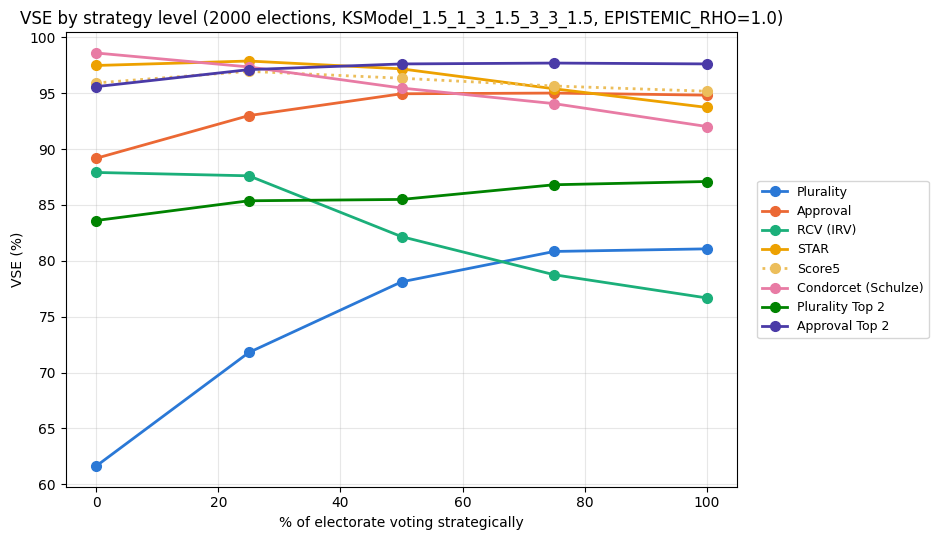

In [86]:
STRATEGY_AXIS = {
    "100% honest": 0,
    "25% strategic": 25,
    "50% strategic": 50,
    "75% strategic": 75,
    "100% strategic": 100,
}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for label, _ in PRE_NOISE_METHODS:
    points = sorted(
        (STRATEGY_AXIS[chooser_label], mean_)
        for chooser_label, mean_, _ in rows_by_method[label]
        if chooser_label in STRATEGY_AXIS
    )
    if not points:
        continue
    xs, ys = zip(*points)
    ax.plot(xs, [y * 100 for y in ys], marker="o", markersize=7, linewidth=2,
            color=METHOD_COLORS[label], linestyle=METHOD_LINESTYLES[label], label=label)

ax.set_xlabel("% of electorate voting strategically")
ax.set_ylabel("VSE (%)")
ax.set_title(f"VSE by strategy level ({NITER} elections, {MODEL}, EPISTEMIC_RHO={EPISTEMIC_RHO})")
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

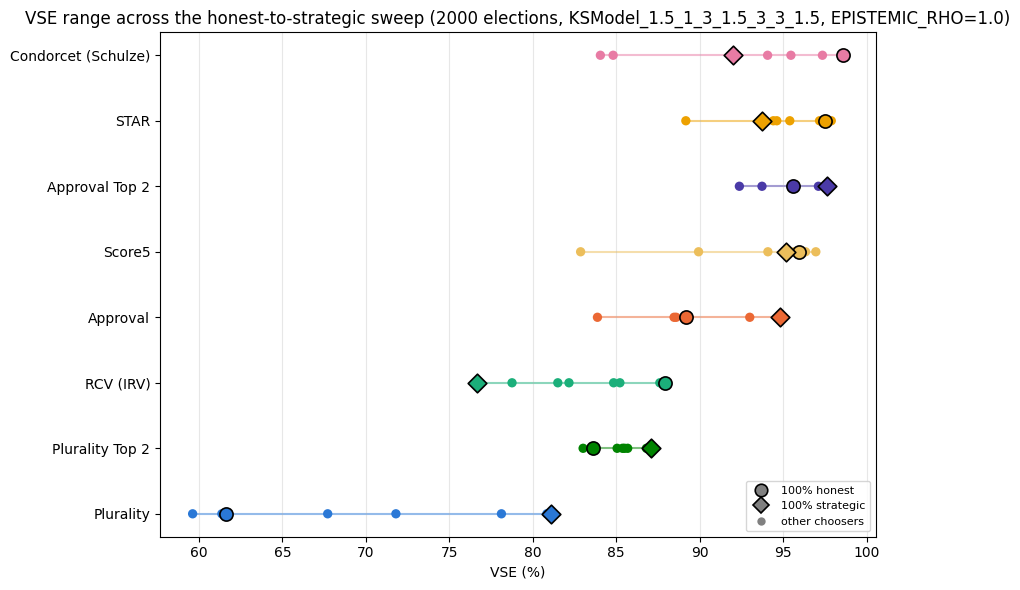

In [87]:
# sort methods by their max VSE across any chooser, so the worst method is at the bottom of the y-axis and the best method is at the top. 
_sorted_labels = sorted(
    (label for label, _ in PRE_NOISE_METHODS if rows_by_method[label]),
    key=lambda label: max(mean_ for _, mean_, _ in rows_by_method[label])
)

fig, ax = plt.subplots(figsize=(9, 6))
# _sorted_labels is ascending by max VSE across any chooser; plotting in that order puts the
# worst method at row 0 (the bottom of a matplotlib y-axis) and the best method at the top row,
# as intended.
for row_i, label in enumerate(_sorted_labels):
    vses = [mean_ * 100 for _, mean_, _ in rows_by_method[label]]
    color = METHOD_COLORS[label]
    ax.plot([min(vses), max(vses)], [row_i, row_i], color=color, linewidth=1.5, alpha=0.5, zorder=1)
    for chooser_label, mean_, _ in rows_by_method[label]:
        is_honest = chooser_label == "100% honest"
        is_strategic = chooser_label == "100% strategic"
        ax.scatter(mean_ * 100, row_i,
                   marker="D" if is_strategic else "o",
                   s=90 if (is_honest or is_strategic) else 45,
                   color=color,
                   edgecolors="black" if (is_honest or is_strategic) else "none",
                   linewidths=1.2 if (is_honest or is_strategic) else 0,
                   zorder=3 if (is_honest or is_strategic) else 2)

ax.set_yticks(range(len(_sorted_labels)))
ax.set_yticklabels(_sorted_labels)
ax.set_xlabel("VSE (%)")
ax.set_title(f"VSE range across the honest-to-strategic sweep ({NITER} elections, "
             f"{MODEL}, EPISTEMIC_RHO={EPISTEMIC_RHO})")
_marker_legend = [
    Line2D([0], [0], marker="o", linestyle="none", markersize=9,
           markerfacecolor="gray", markeredgecolor="black", markeredgewidth=1.2, label="100% honest"),
    Line2D([0], [0], marker="D", linestyle="none", markersize=8,
           markerfacecolor="gray", markeredgecolor="black", markeredgewidth=1.2, label="100% strategic"),
    Line2D([0], [0], marker="o", linestyle="none", markersize=6,
           markerfacecolor="gray", markeredgecolor="none", label="other choosers"),
]
ax.legend(handles=_marker_legend, fontsize=8, loc="lower right")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Sweeping all three degradation parameters: VSE vs. voter information

`EPISTEMIC_RHO`, `AWARENESS_ALPHA`, and `FATIGUE_BETA` each get swept independently (the other two held at
their ideal value of `1.0`), across every method for which the sweep is meaningful, honest ballots
only -- Section 9/10/12's baseline run is the one place this notebook studies strategic voting.
`AWARENESS_ALPHA`/`FATIGUE_BETA` sweeps are restricted to `PRE_NOISE_METHODS`: a
Clear-Eyed runoff variant is only ever different from its base method when the *primary's* own
epistemic noise varies -- the runoff already assumes full awareness by default regardless of the
primary's friction -- so simulating it under `AWARENESS_ALPHA`/`FATIGUE_BETA` would just be a wasted,
functionally-identical copy of its base method's row.

The reusable sweep tooling defined below (`sweep_methods`, `comparison_table`, `comparison_chart`)
is also what Section 14 and later sections use for smaller, focused comparisons.

In [88]:
def sweep_methods(labels, sweep_param, sweep_values, niter, electorates=None,
                   betrayal_targets=None, betrayal_sink_by_value=None, **fixed_overrides):
    """Run niter elections per value of sweep_param (one of 'epistemic_rho', 'awareness_alpha',
    'fatigue_beta'), holding the other two parameters at 1.0 (override via fixed_overrides),
    for just the given method labels (resolved against METHODS_LOOKUP). electorates: optional
    shared pool passed straight through to run_vse_simulation -- see its docstring; pass the
    SAME pool across every sweep_param call so all values, across all three parameters, are
    compared against the same underlying worlds (common random numbers).

    betrayal_targets/betrayal_sink_by_value: same convention as run_vse_simulation's own
    betrayal_targets/betrayal_sink (see its docstring), threaded straight through at every swept
    value -- populated as {value: betrayal_sink}, each value's sink built fresh. None (default)
    for either: no extra bookkeeping, no behavior change.

    Returns (results_by_value, ce_by_value): each {value: {(label, chooser): ...}}.
    results_by_value holds (mean, ci) VSE pairs; ce_by_value holds raw Condorcet efficiency.
    """
    methods_subset = [(label, METHODS_LOOKUP[label]) for label in labels]
    base_kwargs = dict(epistemic_rho=1.0, awareness_alpha=1.0, fatigue_beta=1.0)
    base_kwargs.update(fixed_overrides)
    results_by_value = {}
    ce_by_value = {}
    for value in sweep_values:
        kwargs = dict(base_kwargs)
        kwargs[sweep_param] = value
        value_betrayal_sink = {} if betrayal_sink_by_value is not None else None
        summary, ce_raw, _, _ = run_vse_simulation(MODEL, methods_subset, NVOT, NCAND, niter,
                                      CHOOSER_FUNS, MEDIA, electorates=electorates,
                                      betrayal_targets=betrayal_targets, betrayal_sink=value_betrayal_sink,
                                      **kwargs)
        results_by_value[value] = reduce_to_mean_ci(summary)
        ce_by_value[value] = reduce_to_ce(ce_raw, results_by_value[value].keys())
        if betrayal_sink_by_value is not None:
            betrayal_sink_by_value[value] = value_betrayal_sink
        print(f"{sweep_param}={value:.2f} done")
    return results_by_value, ce_by_value


def comparison_table(results_by_value, labels, sweep_param, ballot_type="honBallot"):
    """Markdown table: rows=label, columns=sweep_param values, cell=VSE% (+/- CI)."""
    values = sorted(results_by_value)
    header = ["Method"] + [f"{sweep_param}={v:.2f}" for v in values]
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    for label in labels:
        row = [label]
        for v in values:
            mean_, ci = results_by_value[v][(label, ballot_type)]
            row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
        lines.append("| " + " | ".join(row) + " |")
    display(Markdown("\n".join(lines)))


def comparison_chart(results_by_value, labels, sweep_param, ballot_type="honBallot",
                      baseline_label=None, title=None):
    """VSE-vs-sweep_param line chart; if baseline_label is given, a second panel shows
    label - baseline for every other label (the 'flip it ... minus STAR' framing)."""
    values = sorted(results_by_value)
    ncols = 2 if baseline_label else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5))
    ax_vse = axes[0] if baseline_label else axes
    for label in labels:
        vses = [results_by_value[v][(label, ballot_type)][0] * 100 for v in values]
        ax_vse.plot(values, vses, marker="o", markersize=7, linewidth=2,
                    color=METHOD_COLORS.get(label), linestyle=METHOD_LINESTYLES.get(label, "-"),
                    label=label)
    ax_vse.set_xlabel(sweep_param)
    ax_vse.set_ylabel("VSE (%)")
    ax_vse.set_title(title or f"VSE vs. {sweep_param}")
    ax_vse.legend(fontsize=8)
    ax_vse.grid(True, alpha=0.3)

    if baseline_label:
        ax_gap = axes[1]
        baseline_vses = [results_by_value[v][(baseline_label, ballot_type)][0] * 100 for v in values]
        for label in labels:
            if label == baseline_label:
                continue
            vses = [results_by_value[v][(label, ballot_type)][0] * 100 for v in values]
            gap = [a - b for a, b in zip(vses, baseline_vses)]
            ax_gap.plot(values, gap, marker="o", markersize=7, linewidth=2,
                        color=METHOD_COLORS.get(label), linestyle=METHOD_LINESTYLES.get(label, "-"),
                        label=f"{label} − {baseline_label}")
        ax_gap.axhline(0, color="gray", linewidth=1, linestyle=":")
        ax_gap.set_xlabel(sweep_param)
        ax_gap.set_ylabel("VSE gap (percentage points)")
        ax_gap.set_title(f"Gap vs. {baseline_label}")
        ax_gap.legend(fontsize=8)
        ax_gap.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [89]:
# Adjust SWEEP_NITER for this cell in Section 5 (Parameters).
SWEEP_VALUES = [0.0, 0.3, 0.5, 0.7, 0.85, 1.0]

# epistemic_rho sweeps every method; awareness_alpha/fatigue_beta are restricted to PRE_NOISE_METHODS --
# see the section markdown above for why. "Approval Top 2 (Coma)" reacts ONLY to awareness_alpha
# (its runoff reapplies friction at the primary's own awareness_alpha, fatigue pinned to 1.0 -- see
# Top2Base.__init__) -- both epistemic_rho and fatigue_beta are held at 1.0 throughout their own
# sweeps, so Coma would be identical to plain "Approval Top 2" at EVERY point of those two
# sweeps, not just one redundant endpoint. Excluded from both entirely rather than left in to
# silently overlap; kept in the awareness_alpha sweep (via PRE_NOISE_METHODS, unchanged) where it's
# genuinely distinct.
_COMA_LABEL = "Approval Top 2 (Coma)"
METHODS_NO_COMA = [(label, m) for label, m in METHODS if label != _COMA_LABEL]
PRE_NOISE_METHODS_NO_COMA = [(label, m) for label, m in PRE_NOISE_METHODS if label != _COMA_LABEL]
SWEEP_PARAMS = [
    ("epistemic_rho", METHODS_NO_COMA),
    ("awareness_alpha", PRE_NOISE_METHODS),
    ("fatigue_beta", PRE_NOISE_METHODS_NO_COMA),
]

sweep_results_by_param = {}  # param -> {value: {(label, chooser): (mean, ci)}}
sweep_ce_by_param = {}       # param -> {value: {(label, chooser): raw_ce}}
_sweep_values_to_run = [v for v in SWEEP_VALUES if v != 1.0]

# Section 23's epistemic_rho-alone betrayal diagnostic used to re-simulate its own separate batch
# of elections per rho value; folded into the epistemic_rho sweep below instead (see
# run_vse_simulation's betrayal_targets docstring), so it rides this sweep's own SWEEP_NITER-
# election _pool draws. Not needed for the awareness_alpha/fatigue_beta sweeps -- Section 23 never
# reads betrayal data for those two parameters -- so this is only passed when sweep_param is
# "epistemic_rho" below.
_epistemic_betrayal_targets = [("STAR", STAR_TOP_RANK)]
epistemic_rho_betrayal_by_value = {}  # {rho: {"STAR": betrayal_acc}}

In [90]:
for sweep_param, param_methods in SWEEP_PARAMS:
    _param_start = time.perf_counter()
    _labels = [label for label, _ in param_methods]
    # 1.0 ("Ideal") is the same scenario as Section 9's initial run for every parameter --
    # reuse its already-computed (higher-precision, NITER=1000) result instead of re-simulating
    # it, and share ONE electorate pool per parameter (common random numbers) across every value
    # that IS simulated, rather than each drawing its own independent batch.
    _pool = [MODEL(NVOT, NCAND) for _ in range(SWEEP_NITER)]
    _is_epistemic = sweep_param == "epistemic_rho"
    sweep_results_by_param[sweep_param], sweep_ce_by_param[sweep_param] = sweep_methods(
        _labels, sweep_param, _sweep_values_to_run, SWEEP_NITER, electorates=_pool, honest_only=True,
        betrayal_targets=_epistemic_betrayal_targets if _is_epistemic else None,
        betrayal_sink_by_value=epistemic_rho_betrayal_by_value if _is_epistemic else None,
    )
    sweep_results_by_param[sweep_param][1.0] = {k: v for k, v in results.items() if k[0] in _labels}
    sweep_ce_by_param[sweep_param][1.0] = {k: v for k, v in ce_results.items() if k[0] in _labels}
    print(f"{sweep_param} sweep done in {time.perf_counter() - _param_start:.1f}s")

epistemic_rho_betrayal_by_value[1.0] = ideal_betrayal_sink

Simulated 100/300 elections in 2.9s
Simulated 200/300 elections in 6.2s
Simulated 300/300 elections in 9.3s
Simulation done in 9.3s
epistemic_rho=0.00 done
Simulated 100/300 elections in 3.3s
Simulated 200/300 elections in 6.5s
Simulated 300/300 elections in 9.9s
Simulation done in 9.9s
epistemic_rho=0.30 done
Simulated 100/300 elections in 3.2s
Simulated 200/300 elections in 6.9s
Simulated 300/300 elections in 10.6s
Simulation done in 10.6s
epistemic_rho=0.50 done
Simulated 100/300 elections in 4.4s
Simulated 200/300 elections in 7.6s
Simulated 300/300 elections in 11.0s
Simulation done in 11.1s
epistemic_rho=0.70 done
Simulated 100/300 elections in 3.2s
Simulated 200/300 elections in 6.6s
Simulated 300/300 elections in 9.8s
Simulation done in 9.8s
epistemic_rho=0.85 done
epistemic_rho sweep done in 62.0s
Simulated 100/300 elections in 2.0s
Simulated 200/300 elections in 4.3s
Simulated 300/300 elections in 6.5s
Simulation done in 6.5s
awareness_alpha=0.00 done
Simulated 100/300 electi

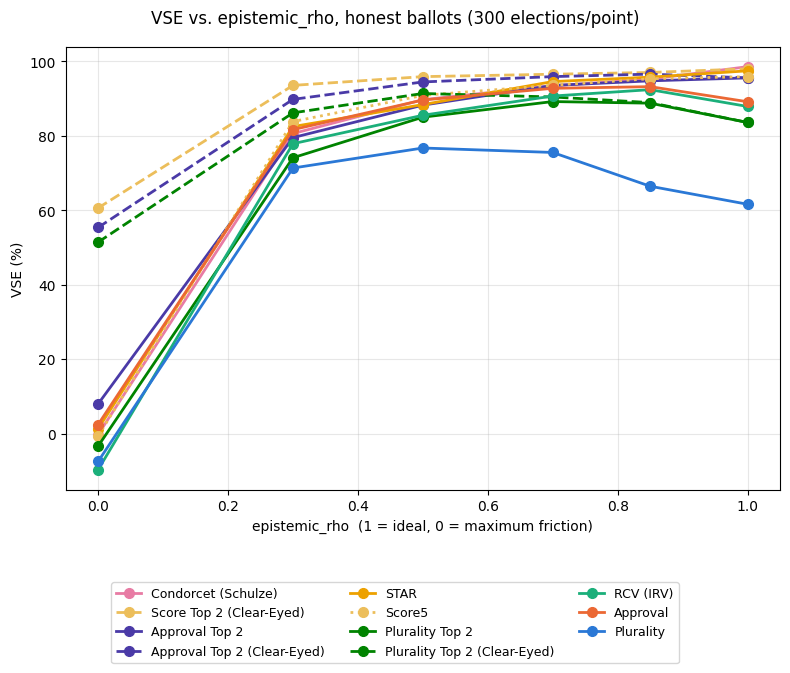

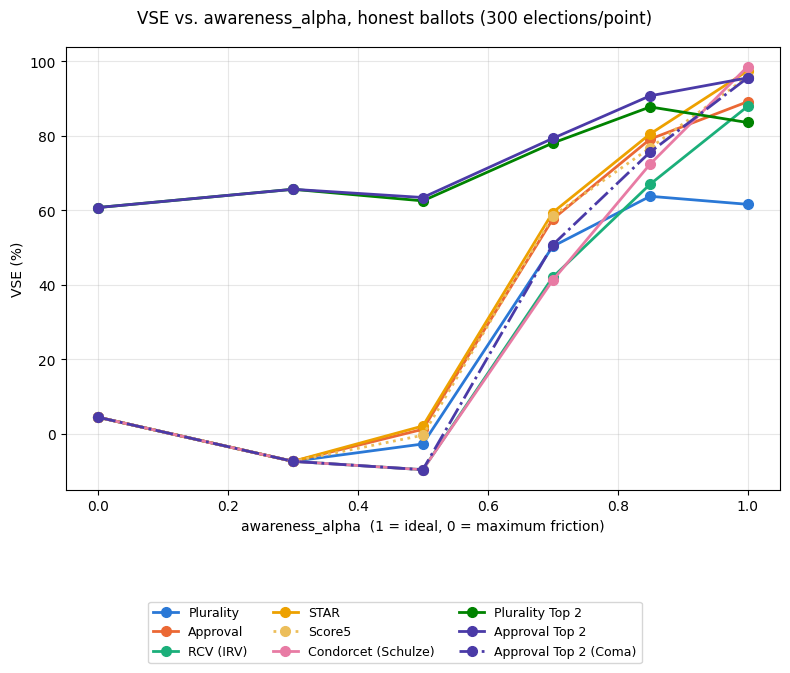

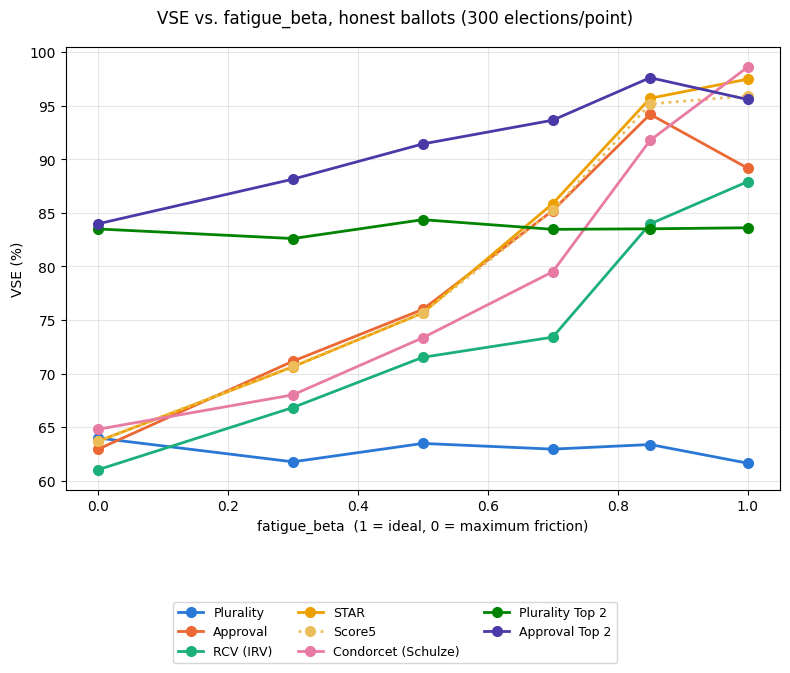

In [91]:
for sweep_param, param_methods in SWEEP_PARAMS:
    _by_value = sweep_results_by_param[sweep_param]
    _values = sorted(_by_value)
    fig, ax_hon = plt.subplots(figsize=(8, 5.5))
    for label, _ in param_methods:
        color = METHOD_COLORS[label]
        style = METHOD_LINESTYLES[label]
        hon_vses = [_by_value[v][(label, "honBallot")][0] * 100 for v in _values]
        ax_hon.plot(_values, hon_vses, marker="o", markersize=7, linewidth=2, color=color, linestyle=style, label=label)
    ax_hon.set_xlabel(f"{sweep_param}  (1 = ideal, 0 = maximum friction)")
    ax_hon.grid(True, alpha=0.3)
    ax_hon.set_ylabel("VSE (%)")
    handles, labels_ = ax_hon.get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", fontsize=9, ncol=3, bbox_to_anchor=(0.5, -0.22))
    fig.suptitle(f"VSE vs. {sweep_param}, honest ballots ({SWEEP_NITER} elections/point)")
    plt.tight_layout()
    plt.show()


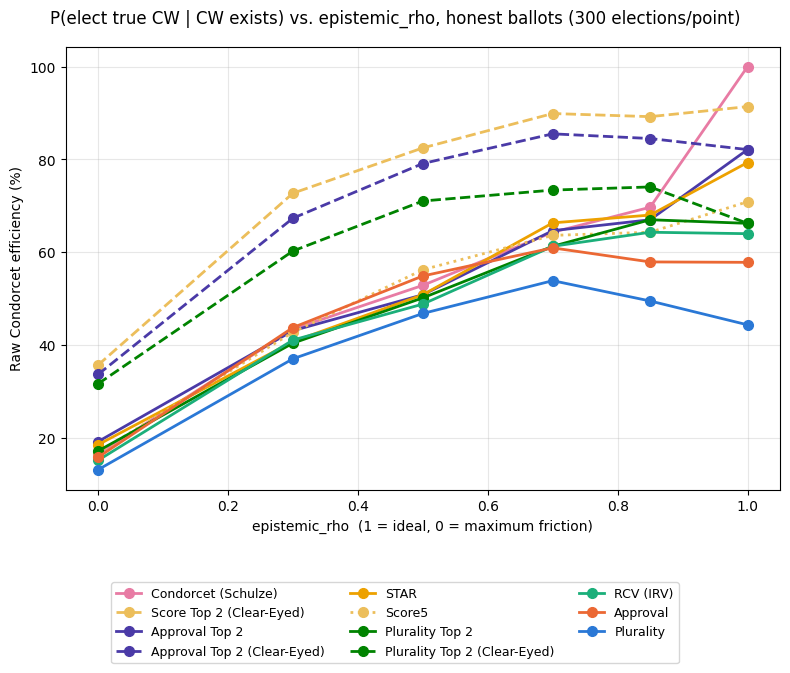

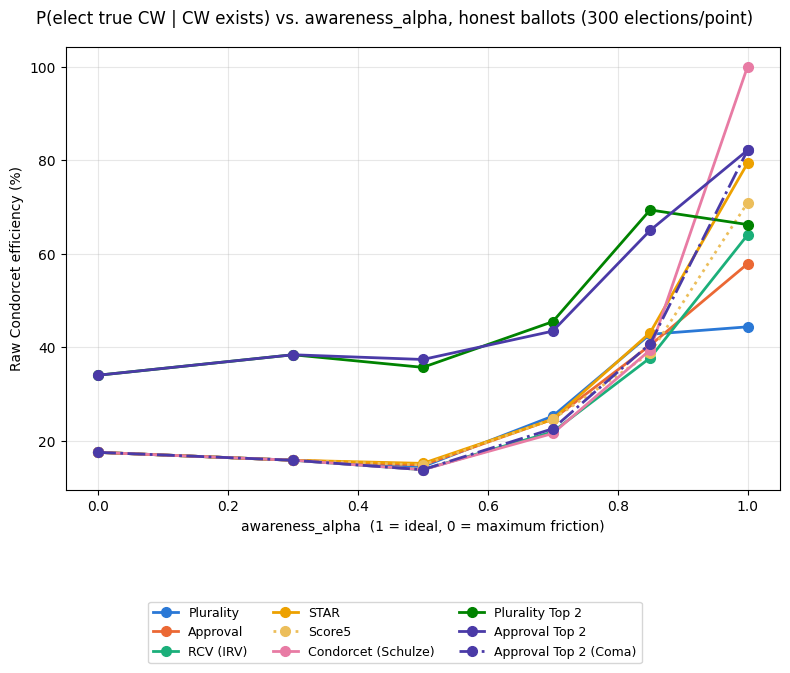

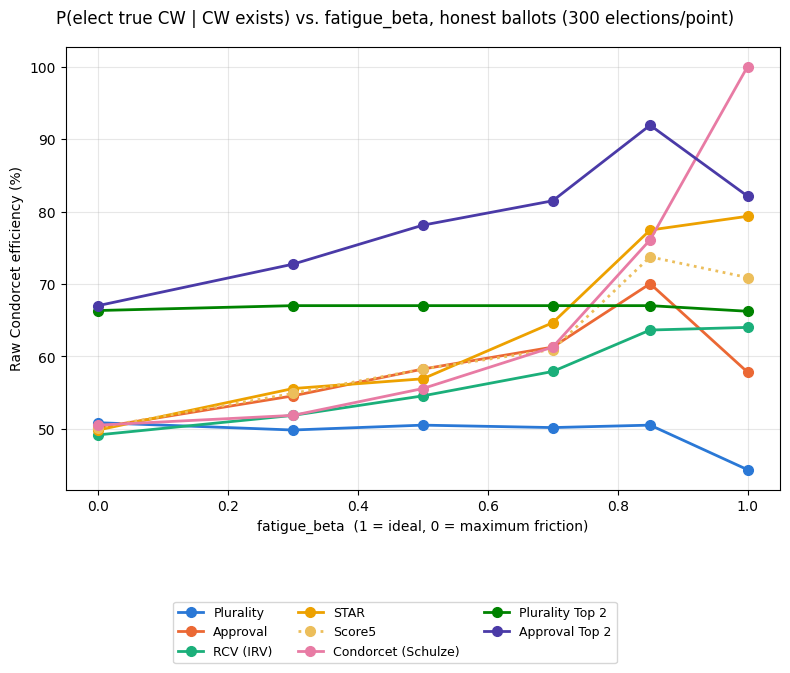

In [92]:
for sweep_param, param_methods in SWEEP_PARAMS:
    _ce_by_value = sweep_ce_by_param[sweep_param]
    _values = sorted(_ce_by_value)
    fig, ax_hon = plt.subplots(figsize=(8, 5.5))
    for label, _ in param_methods:
        color = METHOD_COLORS[label]
        style = METHOD_LINESTYLES[label]
        hon_ces = [_ce_by_value[v].get((label, "honBallot"), float("nan")) * 100 for v in _values]
        ax_hon.plot(_values, hon_ces, marker="o", markersize=7, linewidth=2, color=color, linestyle=style, label=label)
    ax_hon.set_xlabel(f"{sweep_param}  (1 = ideal, 0 = maximum friction)")
    ax_hon.grid(True, alpha=0.3)
    ax_hon.set_ylabel("Raw Condorcet efficiency (%)")
    handles, labels_ = ax_hon.get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", fontsize=9, ncol=3, bbox_to_anchor=(0.5, -0.22))
    fig.suptitle(f"P(elect true CW | CW exists) vs. {sweep_param}, honest ballots ({SWEEP_NITER} elections/point)")
    plt.tight_layout()
    plt.show()


## 14. Approval's flavors vs. STAR/Schulze, across noise and both friction mechanisms

The motivating question: Approval Top 2 (a coarse 0/1 ballot, decided over two rounds) is the
flavor of Approval actually being adopted (e.g. St. Louis). STAR and Schulze both let voters
express far more information in a single round. Does STAR/Schulze's honest-VSE edge over Approval
hold up once that richer signal degrades -- and does Approval Top 2's *delayed, two-candidate*
runoff let voters recover some of that edge, on the theory that deciding between just two finalists
is easy to get right even if the crowded primary wasn't?

Same `baseline_label="STAR"` framing, for all three parameters in turn -- `EPISTEMIC_RHO`,
`AWARENESS_ALPHA`, `FATIGUE_BETA` -- each swept alone with the other two held at `1.0`. `COMPARE_LABELS`
below is Approval's three flavors (base, Groggy Top 2, Clear-Eyed Top 2), STAR, Schulze, and
`Score5` -- Plurality and RCV are covered in Section 13's full sweep above if you want their
numbers. `Score5` (`Score(STAR_TOP_RANK)`, Section 7) is STAR's own ballots with the runoff
switched off; it rides along here as a free no-runoff reference line on every chart below.

In [93]:
# No new simulation here -- Section 13 already swept every method (epistemic_rho) or every
# PRE_NOISE_METHODS method (awareness_alpha/fatigue_beta) across all three parameters; this just
# filters those already-computed results down to COMPARE_LABELS (defined in Section 9, above --
# hoisted there so Section 9's own baseline run can build its paired-comparison lists from it
# too). "Approval Top 2 (clear-eyed runoff)" is simply absent from the awareness_alpha/fatigue_beta
# dicts (Section 13 never simulated it there), not filtered out here -- see Section 13's markdown
# for why. "Score5" is included so it rides along as a no-runoff reference line on every chart
# below; Section 22 reuses this same compare_by_param (and the joint_results built from
# COMPARE_LABELS further down) instead of running its own separate STAR-vs-Score5 simulation.
compare_by_param = {
    param: {value: {k: v for k, v in by_value.items() if k[0] in COMPARE_LABELS}
            for value, by_value in sweep_results_by_param[param].items()}
    for param, _ in SWEEP_PARAMS
}
compare_ce_by_param = {
    param: {value: {k: v for k, v in by_value.items() if k[0] in COMPARE_LABELS}
            for value, by_value in sweep_ce_by_param[param].items()}
    for param, _ in SWEEP_PARAMS
}

#### Epistemic noise (EPISTEMIC_RHO)

| Method | epistemic_rho=0.00 | epistemic_rho=0.30 | epistemic_rho=0.50 | epistemic_rho=0.70 | epistemic_rho=0.85 | epistemic_rho=1.00 |
|---|---|---|---|---|---|---|
| Plurality | -7.5% (+/-12.0) | 71.4% (+/-4.7) | 76.7% (+/-6.0) | 75.6% (+/-6.4) | 66.5% (+/-7.5) | 61.6% (+/-2.8) |
| Plurality Top 2 | -3.4% (+/-11.9) | 74.1% (+/-4.9) | 85.0% (+/-3.4) | 89.2% (+/-2.8) | 88.8% (+/-3.9) | 83.6% (+/-1.7) |
| Plurality Top 2 (Clear-Eyed) | 51.4% (+/-7.1) | 86.2% (+/-3.9) | 91.4% (+/-2.8) | 90.5% (+/-3.0) | 88.9% (+/-3.9) | 83.6% (+/-1.7) |
| RCV (IRV) | -9.7% (+/-12.5) | 77.9% (+/-4.1) | 85.5% (+/-3.3) | 90.7% (+/-2.2) | 92.4% (+/-1.9) | 87.9% (+/-1.3) |
| Approval | 2.4% (+/-11.7) | 81.7% (+/-3.7) | 89.6% (+/-2.1) | 92.8% (+/-1.7) | 93.2% (+/-1.5) | 89.2% (+/-0.8) |
| Approval Top 2 | 8.0% (+/-11.1) | 79.5% (+/-3.9) | 88.3% (+/-2.6) | 93.6% (+/-1.4) | 94.8% (+/-1.3) | 95.6% (+/-0.5) |
| Approval Top 2 (Clear-Eyed) | 55.4% (+/-6.0) | 89.8% (+/-2.7) | 94.5% (+/-1.6) | 95.9% (+/-1.4) | 96.6% (+/-1.1) | 95.6% (+/-0.5) |
| STAR | 1.3% (+/-11.6) | 82.5% (+/-3.2) | 88.4% (+/-2.5) | 94.6% (+/-1.2) | 95.8% (+/-1.1) | 97.5% (+/-0.3) |
| Score5 | -0.6% (+/-11.8) | 83.9% (+/-3.0) | 90.9% (+/-2.1) | 93.6% (+/-1.4) | 95.4% (+/-1.2) | 95.9% (+/-0.4) |
| Score Top 2 (Clear-Eyed) | 60.6% (+/-5.7) | 93.6% (+/-1.9) | 95.9% (+/-1.3) | 96.6% (+/-1.3) | 97.0% (+/-1.0) | 98.0% (+/-0.3) |
| Condorcet (Schulze) | -0.2% (+/-11.8) | 80.6% (+/-3.7) | 89.7% (+/-2.1) | 93.5% (+/-1.4) | 95.2% (+/-1.6) | 98.6% (+/-0.3) |

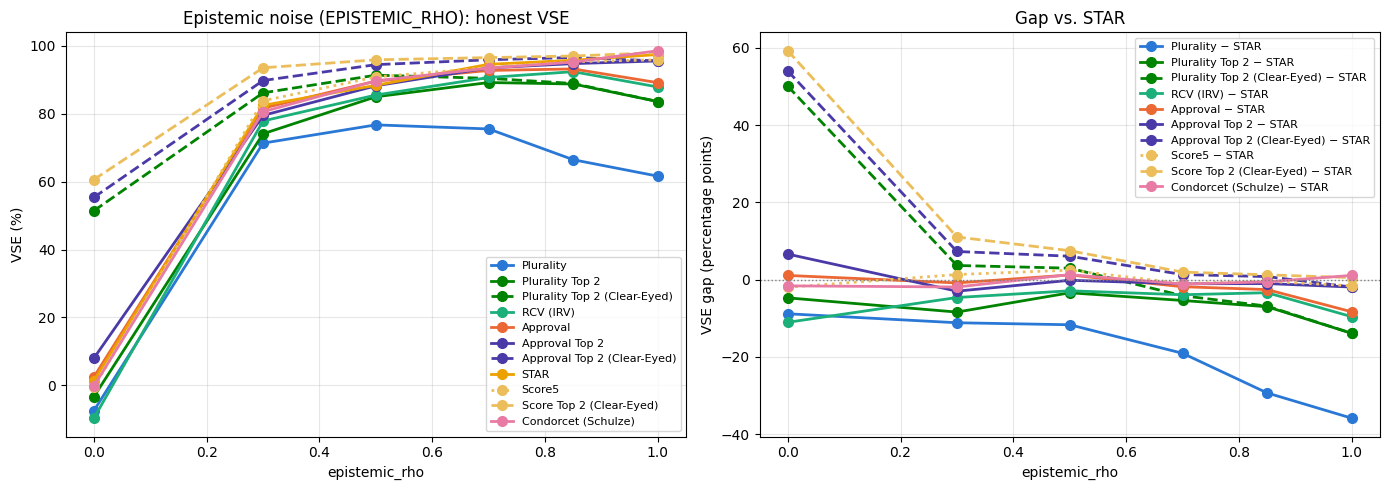

#### Unfamiliarity (AWARENESS_ALPHA)

| Method | awareness_alpha=0.00 | awareness_alpha=0.30 | awareness_alpha=0.50 | awareness_alpha=0.70 | awareness_alpha=0.85 | awareness_alpha=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 4.4% (+/-11.9) | -7.4% (+/-12.2) | -2.7% (+/-11.2) | 50.3% (+/-7.1) | 63.8% (+/-6.7) | 61.6% (+/-2.8) |
| Plurality Top 2 | 60.8% (+/-5.8) | 65.7% (+/-5.2) | 62.6% (+/-5.9) | 78.1% (+/-4.3) | 87.8% (+/-3.3) | 83.6% (+/-1.7) |
| RCV (IRV) | 4.4% (+/-11.9) | -7.4% (+/-12.2) | -9.6% (+/-11.7) | 42.0% (+/-8.0) | 67.0% (+/-5.7) | 87.9% (+/-1.3) |
| Approval | 4.4% (+/-11.9) | -7.4% (+/-12.2) | 1.2% (+/-10.9) | 57.6% (+/-5.8) | 79.1% (+/-3.3) | 89.2% (+/-0.8) |
| Approval Top 2 (Coma) | 4.4% (+/-11.9) | -7.4% (+/-12.2) | -9.6% (+/-11.7) | 50.7% (+/-6.5) | 75.7% (+/-4.3) | 95.6% (+/-0.5) |
| Approval Top 2 | 60.8% (+/-5.8) | 65.7% (+/-5.2) | 63.5% (+/-6.3) | 79.3% (+/-3.7) | 90.8% (+/-2.5) | 95.6% (+/-0.5) |
| STAR | 4.4% (+/-11.9) | -7.4% (+/-12.2) | 2.1% (+/-10.8) | 59.4% (+/-5.6) | 80.5% (+/-3.3) | 97.5% (+/-0.3) |
| Score5 | 4.4% (+/-11.9) | -7.4% (+/-12.2) | -0.4% (+/-11.0) | 58.5% (+/-5.7) | 76.8% (+/-3.7) | 95.9% (+/-0.4) |
| Condorcet (Schulze) | 4.4% (+/-11.9) | -7.4% (+/-12.2) | -9.6% (+/-11.7) | 41.2% (+/-8.1) | 72.4% (+/-5.1) | 98.6% (+/-0.3) |

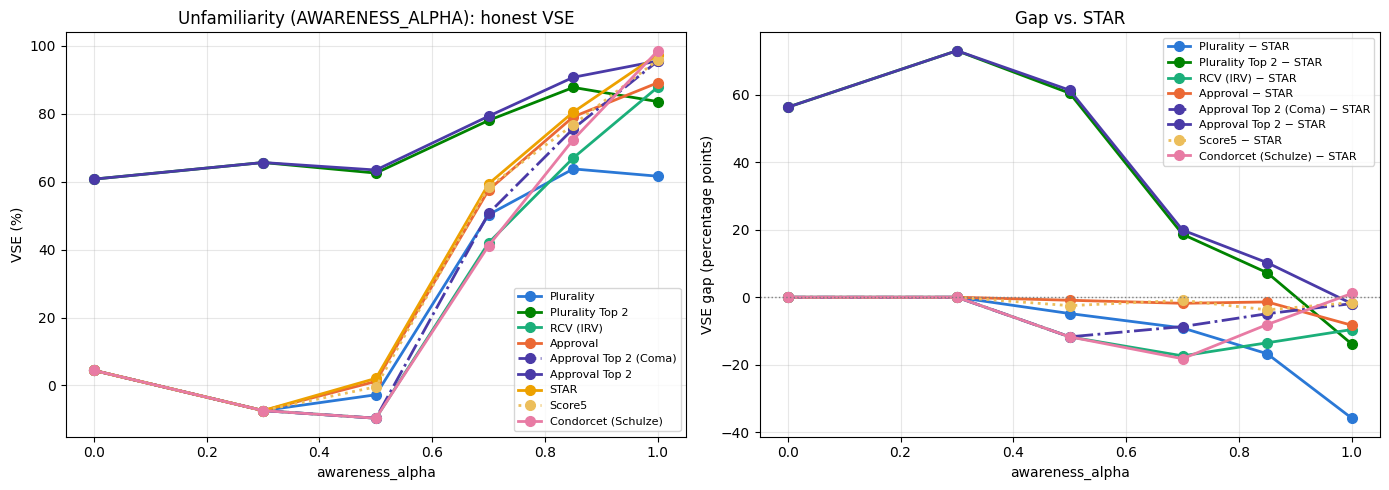

#### Ballot fatigue (FATIGUE_BETA)

| Method | fatigue_beta=0.00 | fatigue_beta=0.30 | fatigue_beta=0.50 | fatigue_beta=0.70 | fatigue_beta=0.85 | fatigue_beta=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 64.0% (+/-7.6) | 61.8% (+/-7.9) | 63.5% (+/-7.4) | 62.9% (+/-7.6) | 63.4% (+/-7.7) | 61.6% (+/-2.8) |
| Plurality Top 2 | 83.5% (+/-4.5) | 82.6% (+/-5.0) | 84.4% (+/-4.3) | 83.5% (+/-4.5) | 83.5% (+/-4.5) | 83.6% (+/-1.7) |
| RCV (IRV) | 61.0% (+/-7.6) | 66.8% (+/-7.0) | 71.5% (+/-6.4) | 73.4% (+/-6.2) | 84.0% (+/-4.2) | 87.9% (+/-1.3) |
| Approval | 62.9% (+/-7.8) | 71.2% (+/-6.5) | 76.0% (+/-5.9) | 85.2% (+/-4.6) | 94.2% (+/-1.6) | 89.2% (+/-0.8) |
| Approval Top 2 | 84.0% (+/-4.3) | 88.1% (+/-3.7) | 91.4% (+/-3.3) | 93.7% (+/-2.5) | 97.6% (+/-1.1) | 95.6% (+/-0.5) |
| STAR | 63.7% (+/-7.4) | 70.6% (+/-6.6) | 75.7% (+/-5.9) | 85.9% (+/-4.4) | 95.7% (+/-1.5) | 97.5% (+/-0.3) |
| Score5 | 63.7% (+/-7.5) | 70.7% (+/-6.5) | 75.7% (+/-5.9) | 85.2% (+/-4.5) | 95.2% (+/-1.6) | 95.9% (+/-0.4) |
| Condorcet (Schulze) | 64.8% (+/-7.0) | 68.0% (+/-6.7) | 73.3% (+/-6.2) | 79.5% (+/-5.2) | 91.8% (+/-3.1) | 98.6% (+/-0.3) |

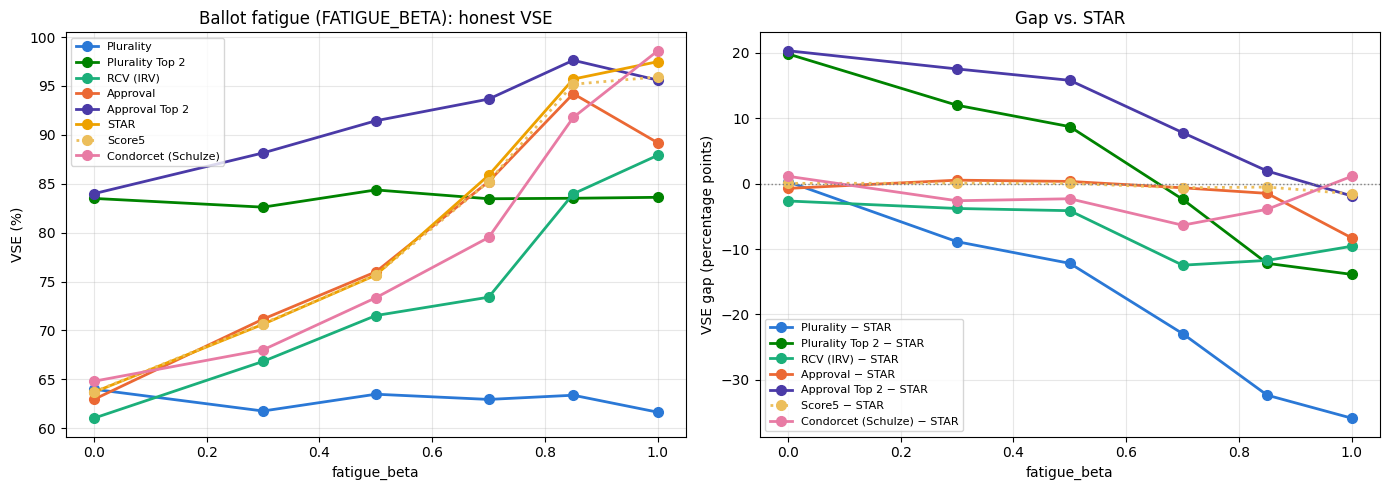

In [94]:
for sweep_param, param_title in [
    ("epistemic_rho", "Epistemic noise (EPISTEMIC_RHO)"),
    ("awareness_alpha", "Unfamiliarity (AWARENESS_ALPHA)"),
    ("fatigue_beta", "Ballot fatigue (FATIGUE_BETA)"),
]:
    display(Markdown(f"#### {param_title}"))
    # Derived from what's actually present rather than a hardcoded exclusion: "Approval Top 2
    # (Clear-Eyed)" is only in compare_by_param["epistemic_rho"] (see the cell above), so it
    # naturally drops out of the other two params' tables/charts here without special-casing.
    _some_value = next(iter(compare_by_param[sweep_param]))
    _present_labels = {k[0] for k in compare_by_param[sweep_param][_some_value]}
    _compare_labels_here = [l for l in COMPARE_LABELS if l in _present_labels]
    comparison_table(compare_by_param[sweep_param], _compare_labels_here, sweep_param)
    comparison_chart(compare_by_param[sweep_param], _compare_labels_here, sweep_param,
                      baseline_label="STAR", title=f"{param_title}: honest VSE")


#### Epistemic noise (EPISTEMIC_RHO) (baseline: Approval Top 2)

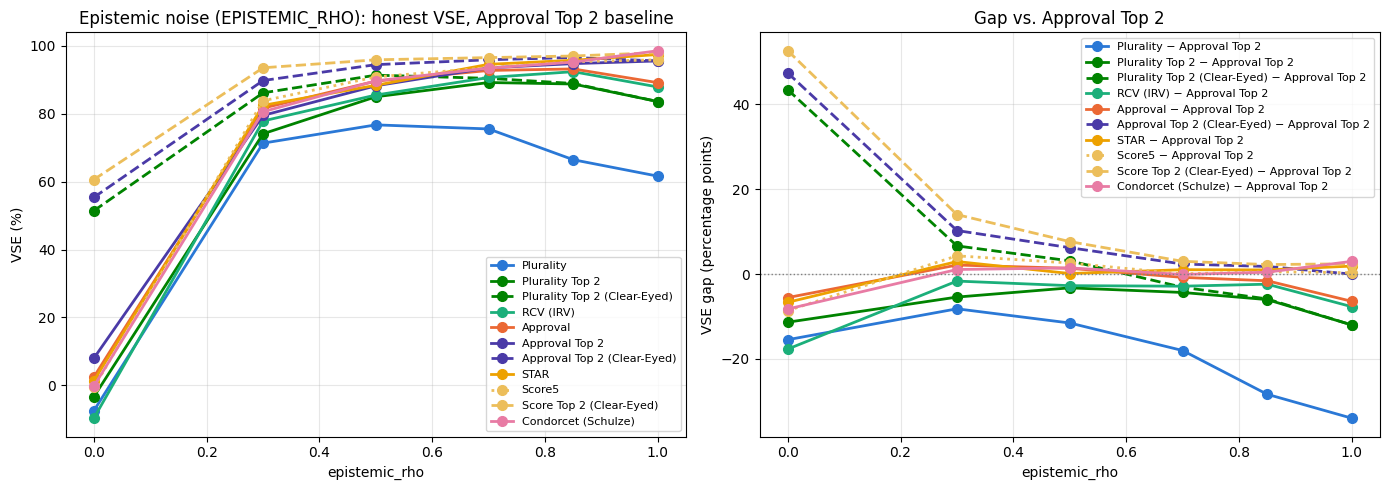

#### Unfamiliarity (AWARENESS_ALPHA) (baseline: Approval Top 2)

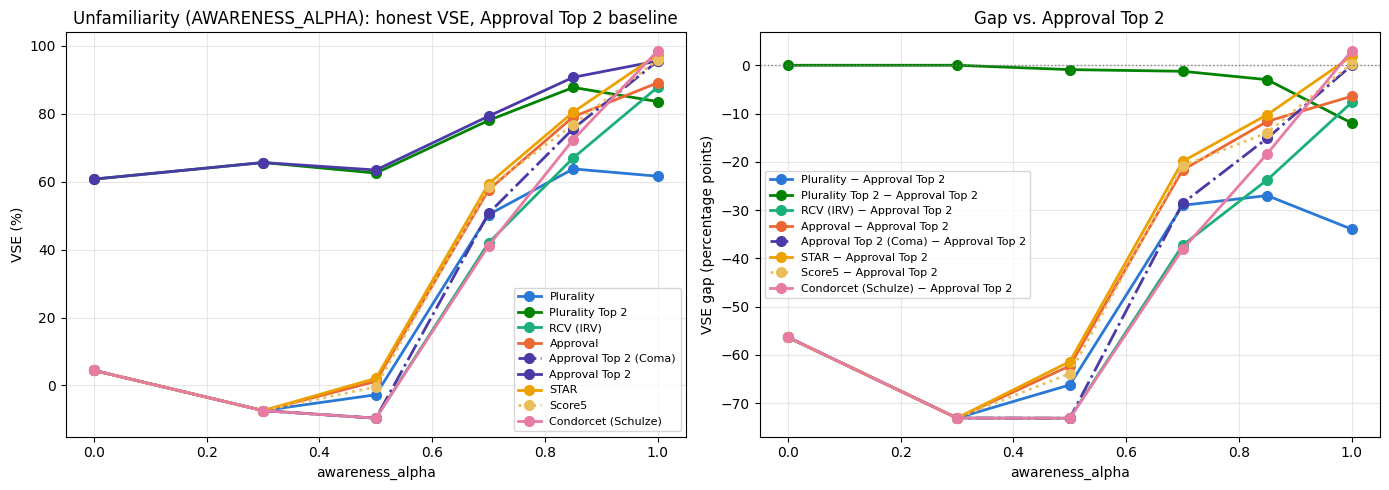

#### Ballot fatigue (FATIGUE_BETA) (baseline: Approval Top 2)

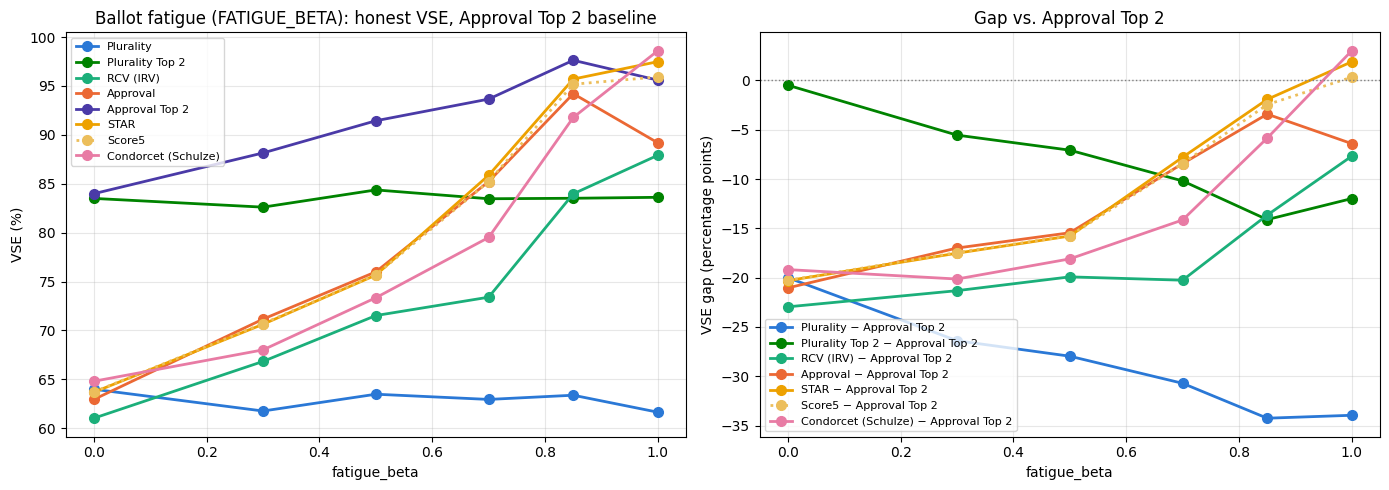

In [95]:
for sweep_param, param_title in [
    ("epistemic_rho", "Epistemic noise (EPISTEMIC_RHO)"),
    ("awareness_alpha", "Unfamiliarity (AWARENESS_ALPHA)"),
    ("fatigue_beta", "Ballot fatigue (FATIGUE_BETA)"),
]:
    display(Markdown(f"#### {param_title} (baseline: Approval Top 2)"))
    _some_value = next(iter(compare_by_param[sweep_param]))
    _present_labels = {k[0] for k in compare_by_param[sweep_param][_some_value]}
    _compare_labels_here = [l for l in COMPARE_LABELS if l in _present_labels]
    comparison_chart(compare_by_param[sweep_param], _compare_labels_here, sweep_param,
                      baseline_label="Approval Top 2",
                      title=f"{param_title}: honest VSE, Approval Top 2 baseline")


## 15. Condorcet Efficiency Under Sweeps

#### Epistemic noise (EPISTEMIC_RHO): raw Condorcet efficiency

| Method | epistemic_rho=0.00 | epistemic_rho=0.30 | epistemic_rho=0.50 | epistemic_rho=0.70 | epistemic_rho=0.85 | epistemic_rho=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 13.1% | 37.0% | 46.8% | 53.9% | 49.5% | 44.4% |
| Plurality Top 2 | 17.2% | 40.4% | 50.2% | 61.3% | 67.0% | 66.2% |
| Plurality Top 2 (Clear-Eyed) | 31.6% | 60.3% | 71.0% | 73.4% | 74.1% | 66.2% |
| RCV (IRV) | 15.2% | 41.1% | 48.8% | 61.3% | 64.3% | 64.0% |
| Approval | 15.8% | 43.8% | 54.9% | 60.9% | 57.9% | 57.8% |
| Approval Top 2 | 19.2% | 43.1% | 50.8% | 64.6% | 67.0% | 82.1% |
| Approval Top 2 (Clear-Eyed) | 33.7% | 67.3% | 79.1% | 85.5% | 84.5% | 82.1% |
| STAR | 18.5% | 40.7% | 50.8% | 66.3% | 68.0% | 79.3% |
| Score5 | 16.8% | 42.8% | 56.2% | 63.6% | 64.3% | 70.9% |
| Score Top 2 (Clear-Eyed) | 35.7% | 72.7% | 82.5% | 89.9% | 89.2% | 91.4% |
| Condorcet (Schulze) | 16.5% | 43.4% | 52.9% | 64.3% | 69.7% | 100.0% |

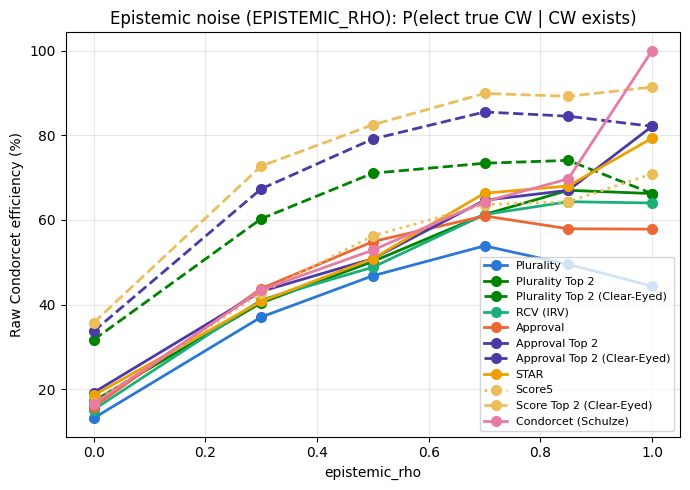

#### Unfamiliarity (AWARENESS_ALPHA): raw Condorcet efficiency

| Method | awareness_alpha=0.00 | awareness_alpha=0.30 | awareness_alpha=0.50 | awareness_alpha=0.70 | awareness_alpha=0.85 | awareness_alpha=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 17.5% | 15.8% | 14.5% | 25.3% | 42.8% | 44.4% |
| Plurality Top 2 | 34.0% | 38.4% | 35.7% | 45.5% | 69.4% | 66.2% |
| RCV (IRV) | 17.5% | 15.8% | 13.8% | 21.9% | 37.7% | 64.0% |
| Approval | 17.5% | 15.8% | 14.8% | 24.6% | 40.4% | 57.8% |
| Approval Top 2 (Coma) | 17.5% | 15.8% | 13.8% | 22.6% | 40.7% | 82.1% |
| Approval Top 2 | 34.0% | 38.4% | 37.4% | 43.4% | 65.0% | 82.1% |
| STAR | 17.5% | 15.8% | 15.2% | 24.6% | 43.1% | 79.3% |
| Score5 | 17.5% | 15.8% | 14.8% | 24.6% | 38.7% | 70.9% |
| Condorcet (Schulze) | 17.5% | 15.8% | 13.8% | 21.5% | 39.4% | 100.0% |

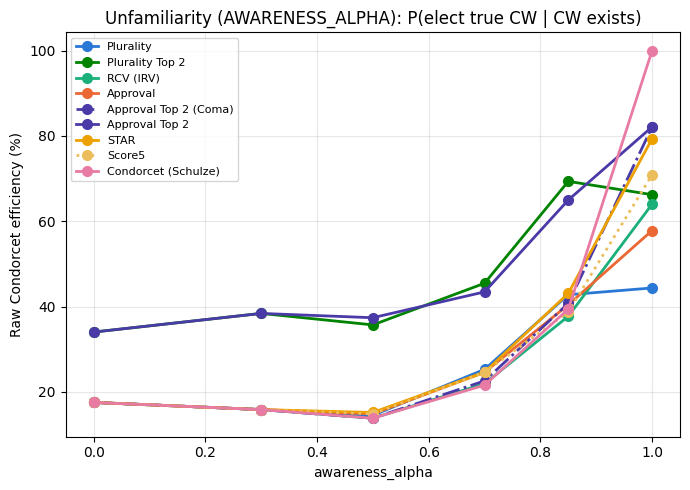

#### Ballot fatigue (FATIGUE_BETA): raw Condorcet efficiency

| Method | fatigue_beta=0.00 | fatigue_beta=0.30 | fatigue_beta=0.50 | fatigue_beta=0.70 | fatigue_beta=0.85 | fatigue_beta=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 50.8% | 49.8% | 50.5% | 50.2% | 50.5% | 44.4% |
| Plurality Top 2 | 66.3% | 67.0% | 67.0% | 67.0% | 67.0% | 66.2% |
| RCV (IRV) | 49.2% | 51.9% | 54.5% | 57.9% | 63.6% | 64.0% |
| Approval | 50.2% | 54.5% | 58.2% | 61.3% | 70.0% | 57.8% |
| Approval Top 2 | 67.0% | 72.7% | 78.1% | 81.5% | 91.9% | 82.1% |
| STAR | 49.8% | 55.6% | 56.9% | 64.6% | 77.4% | 79.3% |
| Score5 | 50.2% | 54.9% | 58.2% | 60.9% | 73.7% | 70.9% |
| Condorcet (Schulze) | 50.5% | 51.9% | 55.6% | 61.3% | 76.1% | 100.0% |

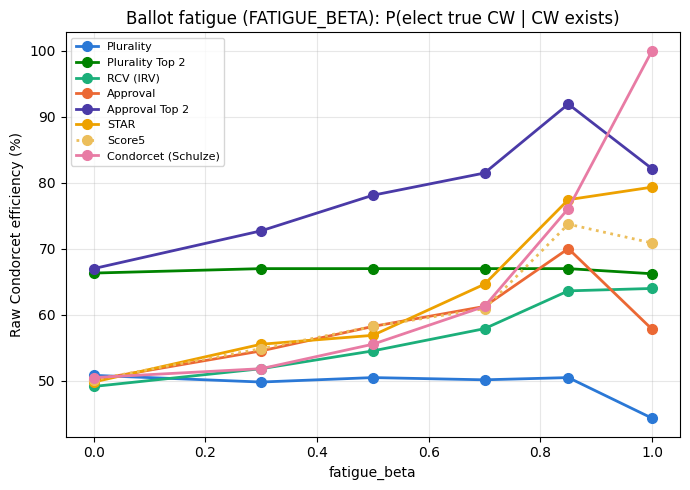

In [96]:
for sweep_param, param_title in [
    ("epistemic_rho", "Epistemic noise (EPISTEMIC_RHO)"),
    ("awareness_alpha", "Unfamiliarity (AWARENESS_ALPHA)"),
    ("fatigue_beta", "Ballot fatigue (FATIGUE_BETA)"),
]:
    display(Markdown(f"#### {param_title}: raw Condorcet efficiency"))
    _some_value = next(iter(compare_ce_by_param[sweep_param]))
    _present_labels = {k[0] for k in compare_ce_by_param[sweep_param][_some_value]}
    _compare_labels_here = [l for l in COMPARE_LABELS if l in _present_labels]
    ce_by_value = compare_ce_by_param[sweep_param]
    values = sorted(ce_by_value)
    header = ["Method"] + [f"{sweep_param}={v:.2f}" for v in values]
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    for label in _compare_labels_here:
        row = [label]
        for v in values:
            ce = ce_by_value[v].get((label, "honBallot"))
            row.append("n/a" if ce is None or ce != ce else f"{ce * 100:.1f}%")
        lines.append("| " + " | ".join(row) + " |")
    display(Markdown("\n".join(lines)))

    fig, ax = plt.subplots(figsize=(7, 5))
    for label in _compare_labels_here:
        ces = [ce_by_value[v].get((label, "honBallot"), float("nan")) * 100 for v in values]
        ax.plot(values, ces, marker="o", markersize=7, linewidth=2,
                color=METHOD_COLORS.get(label), linestyle=METHOD_LINESTYLES.get(label, "-"), label=label)
    ax.set_xlabel(sweep_param)
    ax.set_ylabel("Raw Condorcet efficiency (%)")
    ax.set_title(f"{param_title}: P(elect true CW | CW exists)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [97]:
# Plain-language readout: does each Approval flavor's gap to STAR shrink, hold, or reverse?
_narrowing_lines = [
    "| Method | Parameter | STAR VSE - method VSE (ideal) | STAR VSE - method VSE (min value) | STAR-lead change (pp) | Direction |",
    "|---|---|---|---|---|---|",
]

_target_methods = ["Approval", "Approval Top 2", "Approval Top 2 (Clear-Eyed)"]
_sweeps = [
    ("epistemic_rho", "Epistemic noise"),
    ("awareness_alpha", "Unfamiliarity"),
    ("fatigue_beta", "Ballot fatigue"),
]

for label in _target_methods:  # group by method first
    for sweep_param, param_title in _sweeps:
        results_by_value = compare_by_param[sweep_param]
        _values = sorted(results_by_value)
        _ideal_v = max(_values)
        _max_friction_v = min(_values)

        _ideal_results = results_by_value[_ideal_v]
        _max_results = results_by_value[_max_friction_v]

        if ("STAR", "honBallot") not in _ideal_results or (label, "honBallot") not in _ideal_results:
            continue

        star_ideal = _ideal_results[("STAR", "honBallot")][0] * 100
        meth_ideal = _ideal_results[(label, "honBallot")][0] * 100
        star_max = _max_results[("STAR", "honBallot")][0] * 100
        meth_max = _max_results[(label, "honBallot")][0] * 100

        lead_ideal = star_ideal - meth_ideal
        lead_max = star_max - meth_max
        lead_delta = lead_max - lead_ideal

        if lead_max < lead_ideal:
            direction = "narrowed"
        elif lead_max > lead_ideal:
            direction = "widened"
        else:
            direction = "unchanged"

        if (lead_ideal > 0 and lead_max < 0) or (lead_ideal < 0 and lead_max > 0):
            direction += " (reversed sign)"

        ideal_cell = f"{star_ideal:.1f}-{meth_ideal:.1f}<br>[{lead_ideal:+.1f} pp]"
        max_cell = f"{star_max:.1f}-{meth_max:.1f}<br>[{lead_max:+.1f} pp]"

        _narrowing_lines.append(
            f"| {label} | {param_title} | {ideal_cell} | {max_cell} | "
            f"{lead_ideal:+.1f} → {lead_max:+.1f} ({lead_delta:+.1f}) | {direction} |"
        )
display(Markdown("\n".join(_narrowing_lines)))


| Method | Parameter | STAR VSE - method VSE (ideal) | STAR VSE - method VSE (min value) | STAR-lead change (pp) | Direction |
|---|---|---|---|---|---|
| Approval | Epistemic noise | 97.5-89.2<br>[+8.3 pp] | 1.3-2.4<br>[-1.1 pp] | +8.3 → -1.1 (-9.4) | narrowed (reversed sign) |
| Approval | Unfamiliarity | 97.5-89.2<br>[+8.3 pp] | 4.4-4.4<br>[+0.0 pp] | +8.3 → +0.0 (-8.3) | narrowed |
| Approval | Ballot fatigue | 97.5-89.2<br>[+8.3 pp] | 63.7-62.9<br>[+0.7 pp] | +8.3 → +0.7 (-7.6) | narrowed |
| Approval Top 2 | Epistemic noise | 97.5-95.6<br>[+1.9 pp] | 1.3-8.0<br>[-6.6 pp] | +1.9 → -6.6 (-8.5) | narrowed (reversed sign) |
| Approval Top 2 | Unfamiliarity | 97.5-95.6<br>[+1.9 pp] | 4.4-60.8<br>[-56.3 pp] | +1.9 → -56.3 (-58.2) | narrowed (reversed sign) |
| Approval Top 2 | Ballot fatigue | 97.5-95.6<br>[+1.9 pp] | 63.7-84.0<br>[-20.3 pp] | +1.9 → -20.3 (-22.2) | narrowed (reversed sign) |
| Approval Top 2 (Clear-Eyed) | Epistemic noise | 97.5-95.6<br>[+1.9 pp] | 1.3-55.4<br>[-54.1 pp] | +1.9 → -54.1 (-55.9) | narrowed (reversed sign) |

## 16. Joint "realistic conditions": all three degradation parameters at once

Every sweep above holds two of `EPISTEMIC_RHO`/`AWARENESS_ALPHA`/`FATIGUE_BETA` at their ideal value (`1.0`)
while moving the third. That isolates each mechanism cleanly, but no real election holds two of
the three perfectly -- voters are simultaneously somewhat uncertain about their own preferences,
somewhat unfamiliar with minor candidates, and somewhat prone to not finishing a long ballot. STAR
and Schulze's honest-VSE edge over Approval's flavors was built entirely on the assumption that all
three hold at once (Section 8's main run: `EPISTEMIC_RHO=AWARENESS_ALPHA=FATIGUE_BETA=1.0`). This section
asks what's left of that edge once none of the three ideal assumptions hold simultaneously, and
puts a number on it rather than reading it off three separate charts.

Four fixed scenarios (not swept, all three parameters move together), same `COMPARE_LABELS` as
above, honest ballots only:

In [98]:
SCENARIO_VALUES = [1.0, 0.9, 0.8, 0.7]  # ideal -> heavy friction

JOINT_SCENARIOS = {
    "Ideal":              {"epistemic_rho": 1.0,  "awareness_alpha": 1.0,  "fatigue_beta": 1.0},
    "Mild friction":      {"epistemic_rho": SCENARIO_VALUES[1], "awareness_alpha": SCENARIO_VALUES[1], "fatigue_beta": SCENARIO_VALUES[1]},
    "Moderate friction":  {"epistemic_rho": SCENARIO_VALUES[2],  "awareness_alpha": SCENARIO_VALUES[2],  "fatigue_beta": SCENARIO_VALUES[2]},
    "Heavy friction":     {"epistemic_rho": SCENARIO_VALUES[3],  "awareness_alpha": SCENARIO_VALUES[3],  "fatigue_beta": SCENARIO_VALUES[3]},
}
# Adjust JOINT_NITER for this cell in Section 5 (Parameters).


def run_joint_scenarios(labels, scenarios, niter, electorates=None, paired_diff_pairs=None,
                         paired_ce_pairs=None, raw_vse_by_scenario=None,
                         betrayal_targets=None, betrayal_sink_by_scenario=None,
                         coma_targets=None, coma_sink_by_scenario=None):
    """scenarios: {scenario_name: {epistemic_rho, awareness_alpha, fatigue_beta}} (missing keys default
    to 1.0). electorates: optional shared pool passed straight through to run_vse_simulation --
    see its docstring; pass the SAME pool to every scenario so they're all compared against the
    same underlying worlds (common random numbers). Returns (results_by_scenario,
    ce_by_scenario, paired_diff_by_scenario, paired_ce_by_scenario), each
    {scenario_name: {(label, chooser): ...}} (or {scenario_name: {(label, baseline_label): ...}}
    for paired_diff_by_scenario/paired_ce_by_scenario) -- same shape sweep_methods returns, just
    keyed by scenario name instead of a swept parameter value. results_by_scenario holds
    (mean, ci) VSE pairs; ce_by_scenario holds raw Condorcet efficiency (checkpoint-4 addition);
    paired_diff_by_scenario holds (mean, ci) for the paired per-election (VSE[label] -
    VSE[baseline_label]) difference (honBallot only) for every pair in paired_diff_pairs;
    paired_ce_by_scenario holds (mean, ci) for the paired per-election (CW-hit[label] -
    CW-hit[baseline_label]) difference for every pair in paired_ce_pairs -- both empty per
    scenario when the corresponding pairs arg is None/empty -- see run_vse_simulation's own
    docstring for what "paired" means here.

    raw_vse_by_scenario: optional dict the caller pre-creates (e.g. {}); when given, populated
    as {scenario_name: {(label, chooser): [per-election vse, ...]}} -- same raw per-election
    values run_vse_simulation's own raw_vse_sink collects, just threaded through per scenario.
    Feeds Section 25's per-election VSE histograms. None (default): no extra bookkeeping.

    betrayal_targets/betrayal_sink_by_scenario, coma_targets/coma_sink_by_scenario: same
    convention as raw_vse_by_scenario above, threaded straight through to each scenario's
    run_vse_simulation call -- see its betrayal_targets/coma_targets docstring. Populated as
    {scenario_name: betrayal_sink} / {scenario_name: coma_sink}, each scenario's sink built fresh
    (a plain {} passed as run_vse_simulation's own betrayal_sink/coma_sink for that scenario).
    None (default) for either: no extra bookkeeping, no behavior change.

    Always runs with honest_only=True -- nothing downstream of this function (every joint-
    scenario table/chart) ever reads a non-honBallot chooser, so the strategic/one-sided/
    smart-one-sided ballots aren't computed at all here."""
    function_start_time = time.time()
    methods_subset = [(label, METHODS_LOOKUP[label]) for label in labels]
    results_by_scenario = {}
    ce_by_scenario = {}
    paired_diff_by_scenario = {}
    paired_ce_by_scenario = {}
    for name, params in scenarios.items():
        scenario_start_time = time.time()
        print(f"Running scenario '{name}' ({params}) ...")
        kwargs = dict(epistemic_rho=1.0, awareness_alpha=1.0, fatigue_beta=1.0)
        kwargs.update(params)
        raw_sink = defaultdict(list) if raw_vse_by_scenario is not None else None
        scenario_betrayal_sink = {} if betrayal_sink_by_scenario is not None else None
        scenario_coma_sink = {} if coma_sink_by_scenario is not None else None
        summary, ce_raw, paired_diff_raw, paired_ce_raw = run_vse_simulation(
            MODEL, methods_subset, NVOT, NCAND, niter, CHOOSER_FUNS, MEDIA,
            electorates=electorates, paired_diff_pairs=paired_diff_pairs,
            paired_ce_pairs=paired_ce_pairs, raw_vse_sink=raw_sink, honest_only=True,
            betrayal_targets=betrayal_targets, betrayal_sink=scenario_betrayal_sink,
            coma_targets=coma_targets, coma_sink=scenario_coma_sink, **kwargs
        )
        results_by_scenario[name] = reduce_to_mean_ci(summary)
        ce_by_scenario[name] = reduce_to_ce(ce_raw, results_by_scenario[name].keys())
        paired_diff_by_scenario[name] = reduce_to_mean_ci(paired_diff_raw)
        paired_ce_by_scenario[name] = reduce_to_mean_ci(paired_ce_raw)
        if raw_vse_by_scenario is not None:
            raw_vse_by_scenario[name] = dict(raw_sink)
        if betrayal_sink_by_scenario is not None:
            betrayal_sink_by_scenario[name] = scenario_betrayal_sink
        if coma_sink_by_scenario is not None:
            coma_sink_by_scenario[name] = scenario_coma_sink
        print(f"{name} done in {time.time() - scenario_start_time:.1f}s")
    print(f"Total time: {time.time() - function_start_time:.1f}s")
    return results_by_scenario, ce_by_scenario, paired_diff_by_scenario, paired_ce_by_scenario

In [99]:
# "Ideal" (epistemic_rho=awareness_alpha=fatigue_beta=1.0) is the exact same scenario as Section 9's
# initial run -- reuse that already-computed (higher-precision, NITER=1000) result instead of
# re-simulating it here, and share ONE electorate pool across the remaining 3 presets (common
# random numbers) instead of each drawing its own independent batch.
_joint_scenarios_to_run = {name: params for name, params in JOINT_SCENARIOS.items() if name != "Ideal"}
_joint_electorate_pool = [MODEL(NVOT, NCAND) for _ in range(JOINT_NITER)]

In [100]:
joint_results, joint_ce_results, paired_diff_by_scenario, paired_ce_by_scenario = run_joint_scenarios(
    COMPARE_LABELS, _joint_scenarios_to_run, JOINT_NITER, electorates=_joint_electorate_pool,
    paired_diff_pairs=_paired_diff_pairs, paired_ce_pairs=_paired_ce_pairs,
    raw_vse_by_scenario=joint_raw_vse_by_scenario,
    betrayal_targets=_betrayal_targets, betrayal_sink_by_scenario=joint_betrayal_by_scenario,
    coma_targets=_coma_targets, coma_sink_by_scenario=joint_coma_by_scenario,
)

Running scenario 'Mild friction' ({'epistemic_rho': 0.9, 'awareness_alpha': 0.9, 'fatigue_beta': 0.9}) ...
Simulated 100/6500 elections in 5.4s
Simulated 200/6500 elections in 10.9s
Simulated 300/6500 elections in 16.6s
Simulated 400/6500 elections in 21.1s
Simulated 500/6500 elections in 25.7s
Simulated 600/6500 elections in 30.8s
Simulated 700/6500 elections in 36.2s
Simulated 800/6500 elections in 40.9s
Simulated 900/6500 elections in 46.9s
Simulated 1000/6500 elections in 51.4s
Simulated 1100/6500 elections in 57.0s
Simulated 1200/6500 elections in 62.0s
Simulated 1300/6500 elections in 69.3s
Simulated 1400/6500 elections in 73.9s
Simulated 1500/6500 elections in 78.5s
Simulated 1600/6500 elections in 83.7s
Simulated 1700/6500 elections in 88.3s
Simulated 1800/6500 elections in 92.5s
Simulated 1900/6500 elections in 97.0s
Simulated 2000/6500 elections in 101.7s
Simulated 2100/6500 elections in 106.0s
Simulated 2200/6500 elections in 111.8s
Simulated 2300/6500 elections in 116.6s
Si

In [101]:
joint_results["Ideal"] = {k: v for k, v in results.items() if k[0] in COMPARE_LABELS}
joint_ce_results["Ideal"] = {k: v for k, v in ce_results.items() if k[0] in COMPARE_LABELS}
# "Ideal" reuses Section 9's own raw per-election values (ideal_raw_vse), captured by that
# section's run_vse_simulation call via the same raw_vse_sink mechanism -- not re-simulated here.
joint_raw_vse_by_scenario["Ideal"] = {k: v for k, v in ideal_raw_vse.items() if k[0] in COMPARE_LABELS}
# Same reuse for the betrayal/Coma diagnostics -- "Ideal" comes from Section 9's own
# betrayal_targets/coma_targets sinks (ideal_betrayal_sink/ideal_coma_sink), not re-simulated here.
joint_betrayal_by_scenario["Ideal"] = ideal_betrayal_sink
joint_coma_by_scenario["Ideal"] = ideal_coma_sink
# "Ideal" reuses Section 9's own paired-diff/paired-CE data (ideal_paired_diff/ideal_paired_ce),
# computed there from the SAME _paired_diff_pairs/_paired_ce_pairs this run uses below -- a valid
# WITHIN-scenario paired comparison (same election, same scenario) even though Ideal's electorate
# pool wasn't drawn alongside the other three scenarios' shared _joint_electorate_pool (that
# would only matter for a CROSS-scenario comparison, which nothing here does).
paired_diff_by_scenario["Ideal"] = ideal_paired_diff
paired_ce_by_scenario["Ideal"] = ideal_paired_ce

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 61.6% (+/-2.8) | 69.1% (+/-1.5) | 62.1% (+/-1.4) | 41.5% (+/-1.7) |
| Plurality Top 2 | 83.6% (+/-1.7) | 88.3% (+/-0.7) | 82.1% (+/-0.8) | 72.3% (+/-1.0) |
| Plurality Top 2 (Clear-Eyed) | 83.6% (+/-1.7) | 88.9% (+/-0.7) | 83.5% (+/-0.8) | 74.9% (+/-1.0) |
| RCV (IRV) | 87.9% (+/-1.3) | 74.3% (+/-1.1) | 51.0% (+/-1.6) | 27.9% (+/-2.0) |
| Approval | 89.2% (+/-0.8) | 82.7% (+/-0.7) | 66.5% (+/-1.1) | 42.9% (+/-1.7) |
| Approval Top 2 (Coma) | 95.6% (+/-0.5) | 80.8% (+/-0.8) | 58.2% (+/-1.3) | 31.3% (+/-1.9) |
| Approval Top 2 | 95.6% (+/-0.5) | 92.1% (+/-0.4) | 82.4% (+/-0.7) | 72.5% (+/-1.0) |
| Approval Top 2 (Clear-Eyed) | 95.6% (+/-0.5) | 92.9% (+/-0.4) | 83.6% (+/-0.7) | 75.1% (+/-1.0) |
| STAR | 97.5% (+/-0.3) | 83.1% (+/-0.7) | 66.3% (+/-1.1) | 43.7% (+/-1.7) |
| Score5 | 95.9% (+/-0.4) | 81.9% (+/-0.7) | 65.2% (+/-1.2) | 42.5% (+/-1.7) |
| Score Top 2 (Clear-Eyed) | 98.0% (+/-0.3) | 92.6% (+/-0.4) | 84.0% (+/-0.7) | 75.1% (+/-0.9) |
| Condorcet (Schulze) | 98.6% (+/-0.3) | 75.6% (+/-1.0) | 49.1% (+/-1.6) | 27.5% (+/-2.1) |

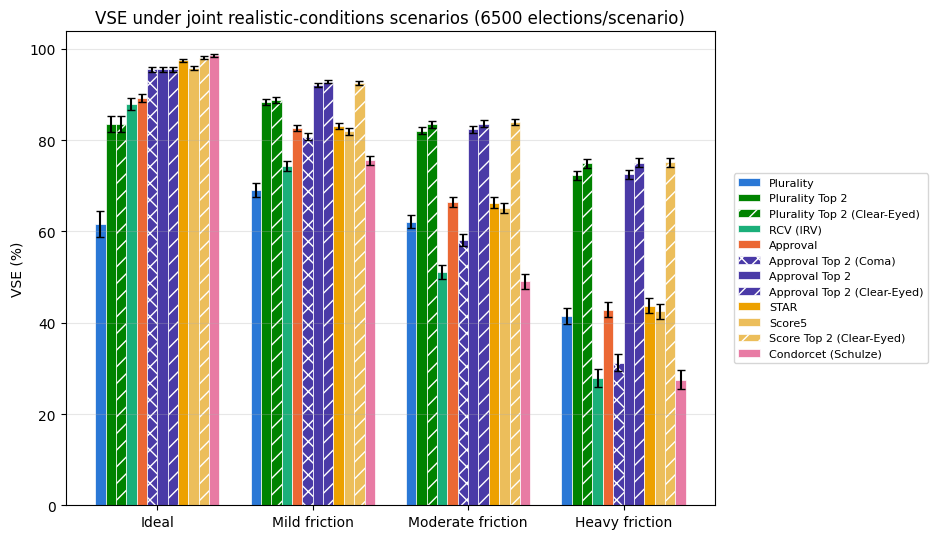

In [102]:
_scenario_names = list(JOINT_SCENARIOS)

def scenario_table_and_plot(method_labels):
    # Table: rows = method, columns = scenario, cell = VSE% (+/-CI)
    _joint_table_lines = ["| Method | " + " | ".join(_scenario_names) + " |",
                        "|---|" + "---|" * len(_scenario_names)]
    for label in method_labels:
        row = [label]
        for name in _scenario_names:
            mean_, ci = joint_results[name][(label, "honBallot")]
            row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
        _joint_table_lines.append("| " + " | ".join(row) + " |")
    display(Markdown("\n".join(_joint_table_lines)))

    # Grouped bar chart: one group per scenario, one bar per method.
    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    _n_labels = len(method_labels)
    _bar_width = 0.8 / _n_labels
    _x = np.arange(len(_scenario_names))
    for i, label in enumerate(method_labels):
        vses = [joint_results[name][(label, "honBallot")][0] * 100 for name in _scenario_names]
        cis = [joint_results[name][(label, "honBallot")][1] * 100 for name in _scenario_names]
        hatch = "//" if "Clear-Eyed" in label else ("xx" if "Coma" in label else None)
        ax.bar(_x + i * _bar_width, vses, _bar_width, yerr=cis, capsize=3,
            color=METHOD_COLORS[label], hatch=hatch, label=label, edgecolor="white", linewidth=0.5)
    ax.set_xticks(_x + _bar_width * (_n_labels - 1) / 2)
    ax.set_xticklabels(_scenario_names)
    ax.set_ylabel("VSE (%)")
    ax.set_title(f"VSE under joint realistic-conditions scenarios ({JOINT_NITER} elections/scenario)")
    ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

scenario_table_and_plot(COMPARE_LABELS)

## 17. Specific Method Groups in Joint Scenarios

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 61.6% (+/-2.8) | 69.1% (+/-1.5) | 62.1% (+/-1.4) | 41.5% (+/-1.7) |
| Plurality Top 2 | 83.6% (+/-1.7) | 88.3% (+/-0.7) | 82.1% (+/-0.8) | 72.3% (+/-1.0) |
| Plurality Top 2 (Clear-Eyed) | 83.6% (+/-1.7) | 88.9% (+/-0.7) | 83.5% (+/-0.8) | 74.9% (+/-1.0) |
| Approval Top 2 (Clear-Eyed) | 95.6% (+/-0.5) | 92.9% (+/-0.4) | 83.6% (+/-0.7) | 75.1% (+/-1.0) |

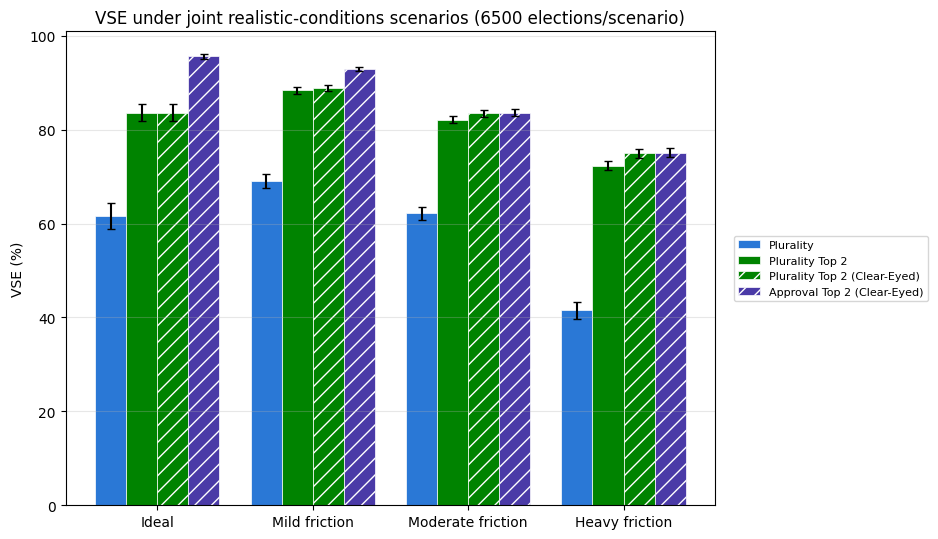

In [103]:
# Plot and table of JUST the plurality-based methods (Plurality, Plurality Top 2, Plurality Top 2 Clear-Eyed) across the joint scenarios
plurality_labels = [l for l in COMPARE_LABELS if "Plurality" in l]
# add clear-eyed AT2 for reference
plurality_labels.append("Approval Top 2 (Clear-Eyed)")
scenario_table_and_plot(plurality_labels)


| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 61.6% (+/-2.8) | 69.1% (+/-1.5) | 62.1% (+/-1.4) | 41.5% (+/-1.7) |
| Approval | 89.2% (+/-0.8) | 82.7% (+/-0.7) | 66.5% (+/-1.1) | 42.9% (+/-1.7) |

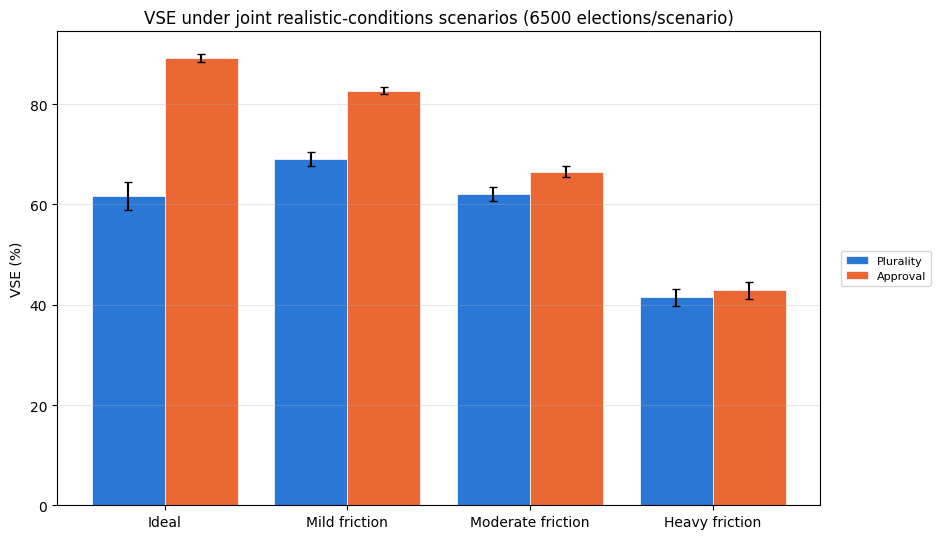

In [104]:
# just single round plurality and approval
simple_labels = ["Plurality", "Approval"]
scenario_table_and_plot(simple_labels)

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| RCV (IRV) | 87.9% (+/-1.3) | 74.3% (+/-1.1) | 51.0% (+/-1.6) | 27.9% (+/-2.0) |
| Condorcet (Schulze) | 98.6% (+/-0.3) | 75.6% (+/-1.0) | 49.1% (+/-1.6) | 27.5% (+/-2.1) |
| Plurality | 61.6% (+/-2.8) | 69.1% (+/-1.5) | 62.1% (+/-1.4) | 41.5% (+/-1.7) |
| STAR | 97.5% (+/-0.3) | 83.1% (+/-0.7) | 66.3% (+/-1.1) | 43.7% (+/-1.7) |
| Approval Top 2 | 95.6% (+/-0.5) | 92.1% (+/-0.4) | 82.4% (+/-0.7) | 72.5% (+/-1.0) |

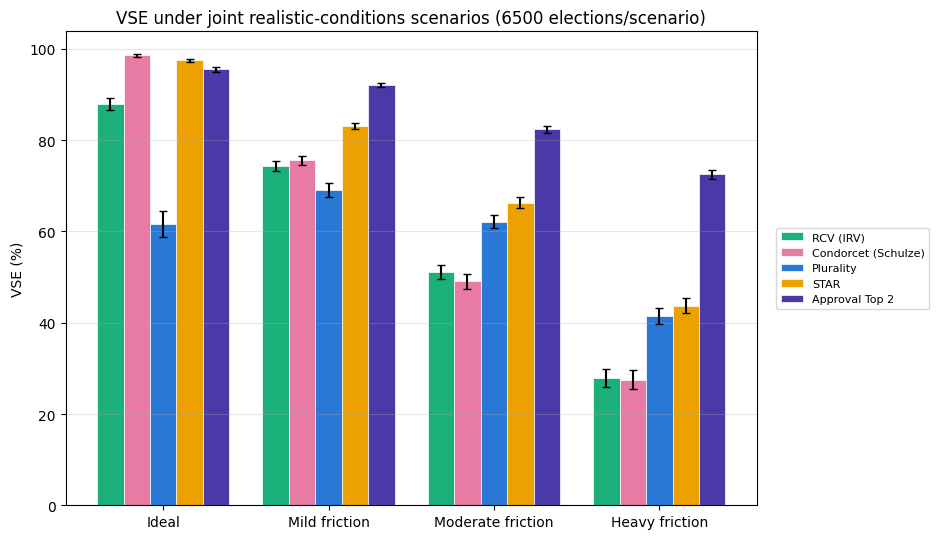

In [105]:
# ranked methods only (RCV, Condorcet) across the joint scenarios
ranked_labels = [l for l in COMPARE_LABELS if l in ("RCV (IRV)", "Condorcet (Schulze)")]
# add for context: approval top-2, plurality, and STAR
ranked_labels.append("Plurality")
ranked_labels.append("STAR")
ranked_labels.append("Approval Top 2")
scenario_table_and_plot(ranked_labels)

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Approval | 89.2% (+/-0.8) | 82.7% (+/-0.7) | 66.5% (+/-1.1) | 42.9% (+/-1.7) |
| Approval Top 2 (Coma) | 95.6% (+/-0.5) | 80.8% (+/-0.8) | 58.2% (+/-1.3) | 31.3% (+/-1.9) |

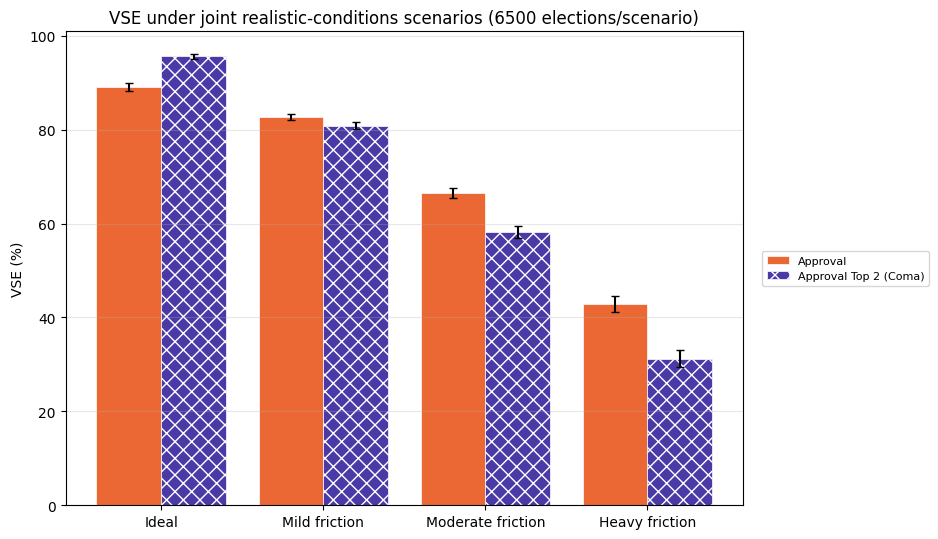

In [106]:
## AT2 Coma vs Approval
coma_single_round_labels = ["Approval", "Approval Top 2 (Coma)"]
scenario_table_and_plot(coma_single_round_labels)

## 18. Quantifying the swing

For each Approval flavor, its gap to STAR (percentage points) at
`Ideal` vs. at `Heavy friction`, and how much that gap moved -- same signed-gap convention as the
per-parameter readout above (a positive swing means STAR's lead shrank, possibly past zero).

### Approval/Runoffs vs STAR

In [107]:
from scipy.stats import norm

Z_95 = 1.96
Z_99 = norm.ppf(0.995)  # two-sided 99% CI multiplier, ~2.576

# {table_title: [(row_label, gap_pp, ci95_pp, positive_name, negative_name, spotlight), ...]} --
# every paired-gap "Significant?" row rendered anywhere below registers itself here (see
# _register_significance calls inside display_paired_gap_table and the standalone significance
# loops). positive_name/negative_name name whichever side a positive/negative gap favors (each
# call site already computes this for its own "(X better)" wording -- just passed through here
# too) so Section 26 can say WHICH side looked better, not just whether the gap was significant.
# Section 26 reads this to re-check every one of these already-computed gaps against a stricter
# confidence level -- new cells that register into it are picked up automatically, no separate
# list to keep in sync.
SIGNIFICANCE_LOG = defaultdict(list)

def _register_significance(table_title, row_label, gap_pp, ci95_pp, positive_name, negative_name, spotlight=False):
    """Record one already-displayed paired-gap row (gap and 95% CI half-width, both already in
    percentage points) for Section 26. ci_at_new_z = ci95_pp * (z_new / Z_95) -- a CI's
    half-width scales linearly with z for a fixed standard error, so this needs no new data and
    no re-run, just arithmetic on what's already been computed. positive_name is whichever side
    a positive gap_pp favors, negative_name the other side -- lets Section 26 report e.g. "STAR
    better by 2.3pp" instead of a bare "Yes". spotlight marks a curated set of headline
    comparisons Section 26 highlights on their own, separate from its comprehensive
    not-significant-at-99% table.

    Keyed by (table_title, row_label) and overwrites rather than appends -- re-running a single
    registration cell (without a full Restart & Run All) re-registers the same rows, which would
    otherwise pile up as duplicates every time that cell runs again."""
    _rows = SIGNIFICANCE_LOG[table_title]
    _entry = (row_label, gap_pp, ci95_pp, positive_name, negative_name, spotlight)
    for _i, _existing in enumerate(_rows):
        if _existing[0] == row_label:
            _rows[_i] = _entry
            return
    _rows.append(_entry)

In [108]:
_joint_quant_lines = []
_focus_labels = ("Approval", "Approval Top 2 (Coma)", "Approval Top 2", "Approval Top 2 (Clear-Eyed)", "Plurality Top 2", "Plurality Top 2 (Clear-Eyed)")

# keep track of method/scenario pairs that have a STAR VSE gap that is statistically indistinguishable from 0 (i.e., the 95% CI contains 0)
contains_zero_pairs = set()
# also keep track of method/scenario pairs where STAR beats the method, and where the method beats STAR
STAR_wins_pairs = set()
STAR_loses_pairs = set()

# Single unified loop over every scenario (including Ideal, now that paired_diff_by_scenario has
# a real "Ideal" entry -- see Section 9/16's merge step) instead of a hand-split Ideal-block +
# per-non-ideal-scenario block.
for scenario in _scenario_names:
    if _joint_quant_lines:
        _joint_quant_lines.append("")
    _joint_quant_lines.extend([
        f"#### {scenario}: Approval-flavor gaps vs STAR (honest ballots)",
        "",
        "| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |",
        "|---|---|---|---|---|---|",
    ])
    star_vse = joint_results[scenario][("STAR", "honBallot")][0] * 100
    for label in _focus_labels:
        if label not in COMPARE_LABELS:
            continue
        # at Ideal, Coma/Clear-Eyed runoff variants are mathematically identical to their base
        # method (see Section 9's _IDENTICAL_AT_IDEAL aliasing) -- skip the redundant duplicate rows
        if scenario == "Ideal" and ("Coma" in label or "Clear-Eyed" in label):
            continue
        method_vse = joint_results[scenario][(label, "honBallot")][0] * 100
        gap_vs_star = method_vse - star_vse
        _paired_ci = paired_diff_by_scenario[scenario][(label, "STAR")][1] * 100
        _ci_interval_str = f"[{gap_vs_star - _paired_ci:+.1f}, {gap_vs_star + _paired_ci:+.1f}]"
        _register_significance(f"Approval-flavor gaps vs STAR: {scenario}", label, gap_vs_star, _paired_ci,
                                label, "STAR", spotlight=(label in ("Approval Top 2", "Plurality Top 2")))
        sig = ""
        if gap_vs_star - _paired_ci <= 0 <= gap_vs_star + _paired_ci:
            sig = "No (CI contains 0)"
            contains_zero_pairs.add((label, scenario))
        elif gap_vs_star > 0:
            sig = "Yes (STAR worse)"
            STAR_loses_pairs.add((label, scenario))
        else:
            sig = "Yes (STAR better)"
            STAR_wins_pairs.add((label, scenario))
        _joint_quant_lines.append(
            f"| {label} | {method_vse:.1f} | {star_vse:.1f} | {gap_vs_star:+.1f} | {_ci_interval_str} | {sig} |"
        )
display(Markdown("\n".join(_joint_quant_lines)))

#### Ideal: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Approval | 89.2 | 97.5 | -8.3 | [-9.1, -7.5] | Yes (STAR better) |
| Approval Top 2 | 95.6 | 97.5 | -1.9 | [-2.4, -1.4] | Yes (STAR better) |
| Plurality Top 2 | 83.6 | 97.5 | -13.9 | [-15.7, -12.1] | Yes (STAR better) |

#### Mild friction: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Approval | 82.7 | 83.1 | -0.4 | [-0.9, +0.1] | No (CI contains 0) |
| Approval Top 2 (Coma) | 80.8 | 83.1 | -2.3 | [-2.8, -1.7] | Yes (STAR better) |
| Approval Top 2 | 92.1 | 83.1 | +9.0 | [+8.4, +9.6] | Yes (STAR worse) |
| Approval Top 2 (Clear-Eyed) | 92.9 | 83.1 | +9.8 | [+9.2, +10.4] | Yes (STAR worse) |
| Plurality Top 2 | 88.3 | 83.1 | +5.3 | [+4.5, +6.1] | Yes (STAR worse) |
| Plurality Top 2 (Clear-Eyed) | 88.9 | 83.1 | +5.8 | [+5.0, +6.6] | Yes (STAR worse) |

#### Moderate friction: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Approval | 66.5 | 66.3 | +0.2 | [-0.3, +0.7] | No (CI contains 0) |
| Approval Top 2 (Coma) | 58.2 | 66.3 | -8.1 | [-9.1, -7.2] | Yes (STAR better) |
| Approval Top 2 | 82.4 | 66.3 | +16.0 | [+15.1, +17.0] | Yes (STAR worse) |
| Approval Top 2 (Clear-Eyed) | 83.6 | 66.3 | +17.3 | [+16.4, +18.2] | Yes (STAR worse) |
| Plurality Top 2 | 82.1 | 66.3 | +15.7 | [+14.8, +16.7] | Yes (STAR worse) |
| Plurality Top 2 (Clear-Eyed) | 83.5 | 66.3 | +17.1 | [+16.2, +18.1] | Yes (STAR worse) |

#### Heavy friction: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Approval | 42.9 | 43.7 | -0.8 | [-1.4, -0.3] | Yes (STAR better) |
| Approval Top 2 (Coma) | 31.3 | 43.7 | -12.4 | [-13.6, -11.2] | Yes (STAR better) |
| Approval Top 2 | 72.5 | 43.7 | +28.8 | [+27.4, +30.3] | Yes (STAR worse) |
| Approval Top 2 (Clear-Eyed) | 75.1 | 43.7 | +31.4 | [+30.0, +32.8] | Yes (STAR worse) |
| Plurality Top 2 | 72.3 | 43.7 | +28.6 | [+27.2, +30.1] | Yes (STAR worse) |
| Plurality Top 2 (Clear-Eyed) | 74.9 | 43.7 | +31.2 | [+29.8, +32.6] | Yes (STAR worse) |

In [109]:
_scenario_order = {name: i for i, name in enumerate(_scenario_names)}

def _scenario_then_label(item):
    label, scenario = item
    return (_scenario_order.get(scenario, len(_scenario_order)), label)

# first display the method/scenario pairs that have a paired CI where STAR wins
_joint_quant_lines_star_wins = [
    "### Method/scenario pairs where STAR's VSE is significantly higher than the method's (95% CI does NOT contain 0)",
    "",
    "| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |",
    "|---|---|---|---|---|",
]
for label, scenario in sorted(STAR_wins_pairs, key=_scenario_then_label):
    method_vse = joint_results[scenario][(label, "honBallot")][0] * 100
    star_vse = joint_results[scenario][("STAR", "honBallot")][0] * 100
    gap_vs_star = method_vse - star_vse
    if scenario != "Ideal":
        _paired_ci = paired_diff_by_scenario[scenario][(label, "STAR")][1] * 100
    else:
        _paired_ci = ideal_paired_diff[(label, "STAR")][1] * 100
    _ci_interval_str = f"[{gap_vs_star - _paired_ci:+.1f}, {gap_vs_star + _paired_ci:+.1f}]"
    sig = "Yes (STAR better)"
    assert gap_vs_star < 0, f"STAR wins but gap is {gap_vs_star:+.1f} pp"
    _joint_quant_lines_star_wins.append(
        f"| {label} | {scenario} | {gap_vs_star:+.1f} | {_ci_interval_str} | {sig} |"
    )
display(Markdown("\n".join(_joint_quant_lines_star_wins)))

# display all method/scenario pairs that have a paired CI that includes 0
_joint_quant_lines_with_zero = [
    "### Method/scenario pairs with STAR VSE gap that is statistically indistinguishable from 0 (95% CI contains 0)",
    "",
    "| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |",
    "|---|---|---|---|---|",
]
for label, scenario in sorted(contains_zero_pairs, key=_scenario_then_label):
    method_vse = joint_results[scenario][(label, "honBallot")][0] * 100
    star_vse = joint_results[scenario][("STAR", "honBallot")][0] * 100
    gap_vs_star = method_vse - star_vse
    if scenario != "Ideal":
        _paired_ci = paired_diff_by_scenario[scenario][(label, "STAR")][1] * 100
    else:
        _paired_ci = ideal_paired_diff[(label, "STAR")][1] * 100
    _ci_interval_str = f"[{gap_vs_star - _paired_ci:+.1f}, {gap_vs_star + _paired_ci:+.1f}]"
    sig = "No (CI contains 0)"
    assert gap_vs_star - _paired_ci <= 0 <= gap_vs_star + _paired_ci, (
        f"CI does not contain 0 but gap is {gap_vs_star:+.1f} pp "
        f"with CI [{gap_vs_star - _paired_ci:+.1f}, {gap_vs_star + _paired_ci:+.1f}]"
    )
    _joint_quant_lines_with_zero.append(
        f"| {label} | {scenario} | {gap_vs_star:+.1f} | {_ci_interval_str} | {sig} |"
    )
display(Markdown("\n".join(_joint_quant_lines_with_zero)))

# finally display the method/scenario pairs where STAR loses
_joint_quant_lines_star_loses = [
    "### Method/scenario pairs where STAR's VSE is significantly lower than the method's (95% CI does NOT contain 0)",
    "",
    "| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |",
    "|---|---|---|---|---|",
]
for label, scenario in sorted(STAR_loses_pairs, key=_scenario_then_label):
    method_vse = joint_results[scenario][(label, "honBallot")][0] * 100
    star_vse = joint_results[scenario][("STAR", "honBallot")][0] * 100
    gap_vs_star = method_vse - star_vse
    if scenario != "Ideal":
        _paired_ci = paired_diff_by_scenario[scenario][(label, "STAR")][1] * 100
    else:
        _paired_ci = ideal_paired_diff[(label, "STAR")][1] * 100
    _ci_interval_str = f"[{gap_vs_star - _paired_ci:+.1f}, {gap_vs_star + _paired_ci:+.1f}]"
    sig = "Yes (STAR worse)"
    assert gap_vs_star > 0, f"STAR loses but gap is {gap_vs_star:+.1f} pp"
    _joint_quant_lines_star_loses.append(
        f"| {label} | {scenario} | {gap_vs_star:+.1f} | {_ci_interval_str} | {sig} |"
    )
display(Markdown("\n".join(_joint_quant_lines_star_loses)))

### Method/scenario pairs where STAR's VSE is significantly higher than the method's (95% CI does NOT contain 0)

| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|
| Approval | Ideal | -8.3 | [-9.1, -7.5] | Yes (STAR better) |
| Approval Top 2 | Ideal | -1.9 | [-2.4, -1.4] | Yes (STAR better) |
| Plurality Top 2 | Ideal | -13.9 | [-15.7, -12.1] | Yes (STAR better) |
| Approval Top 2 (Coma) | Mild friction | -2.3 | [-2.8, -1.7] | Yes (STAR better) |
| Approval Top 2 (Coma) | Moderate friction | -8.1 | [-9.1, -7.2] | Yes (STAR better) |
| Approval | Heavy friction | -0.8 | [-1.4, -0.3] | Yes (STAR better) |
| Approval Top 2 (Coma) | Heavy friction | -12.4 | [-13.6, -11.2] | Yes (STAR better) |

### Method/scenario pairs with STAR VSE gap that is statistically indistinguishable from 0 (95% CI contains 0)

| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|
| Approval | Mild friction | -0.4 | [-0.9, +0.1] | No (CI contains 0) |
| Approval | Moderate friction | +0.2 | [-0.3, +0.7] | No (CI contains 0) |

### Method/scenario pairs where STAR's VSE is significantly lower than the method's (95% CI does NOT contain 0)

| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|
| Approval Top 2 | Mild friction | +9.0 | [+8.4, +9.6] | Yes (STAR worse) |
| Approval Top 2 (Clear-Eyed) | Mild friction | +9.8 | [+9.2, +10.4] | Yes (STAR worse) |
| Plurality Top 2 | Mild friction | +5.3 | [+4.5, +6.1] | Yes (STAR worse) |
| Plurality Top 2 (Clear-Eyed) | Mild friction | +5.8 | [+5.0, +6.6] | Yes (STAR worse) |
| Approval Top 2 | Moderate friction | +16.0 | [+15.1, +17.0] | Yes (STAR worse) |
| Approval Top 2 (Clear-Eyed) | Moderate friction | +17.3 | [+16.4, +18.2] | Yes (STAR worse) |
| Plurality Top 2 | Moderate friction | +15.7 | [+14.8, +16.7] | Yes (STAR worse) |
| Plurality Top 2 (Clear-Eyed) | Moderate friction | +17.1 | [+16.2, +18.1] | Yes (STAR worse) |
| Approval Top 2 | Heavy friction | +28.8 | [+27.4, +30.3] | Yes (STAR worse) |
| Approval Top 2 (Clear-Eyed) | Heavy friction | +31.4 | [+30.0, +32.8] | Yes (STAR worse) |
| Plurality Top 2 | Heavy friction | +28.6 | [+27.2, +30.1] | Yes (STAR worse) |
| Plurality Top 2 (Clear-Eyed) | Heavy friction | +31.2 | [+29.8, +32.6] | Yes (STAR worse) |

In [110]:
def display_paired_gap_table(label, baseline_label, label_short=None, baseline_short=None,
                              label_better_name=None, baseline_better_name=None, title=None,
                              spotlight=False):
    """Display a "paired VSE gap by joint-friction scenario" markdown table for `label` vs
    `baseline_label`, reading off the already-computed `joint_results`/`paired_diff_by_scenario`
    (the main joint-scenario run above) -- no new simulation is run here.

    To add a NEW comparison: add the (label, baseline_label) pair to `_paired_diff_pairs` in the
    main run cell above and re-run it (this is where the actual per-election data gets collected,
    since it has to happen DURING the simulation pass to stay paired), then call this function.

    label_short/baseline_short: optional shorter names for the table header (VSE columns), e.g.
    "AT2"/"PT2" for "Approval Top 2"/"Plurality Top 2"; default to the full label.
    label_better_name/baseline_better_name: optional separate override for the "(X better)" text
    in the Significant? column, in case that should read differently than the column header (e.g.
    a fuller name there than the short header); default to label_short/baseline_short.
    title: optional heading override; defaults to "{label} vs {baseline_label}".
    """
    label_short = label_short or label
    baseline_short = baseline_short or baseline_label
    label_better_name = label_better_name or label_short
    baseline_better_name = baseline_better_name or baseline_short
    title = title or f"{label} vs {baseline_label}"
    missing = [name for name in _scenario_names
               if (label, baseline_label) not in paired_diff_by_scenario.get(name, {})]
    if missing:
        raise KeyError(
            f"({label!r}, {baseline_label!r}) missing from paired_diff_by_scenario for {missing} -- "
            "add this pair to _paired_diff_pairs in the main joint-scenario run cell above and "
            "re-run it before calling display_paired_gap_table for this pair."
        )
    lines = [
        f"#### {title}: paired VSE gap by joint-friction scenario",
        "",
        f"| Scenario | {label_short} VSE (%) | {baseline_short} VSE (%) | Gap vs {baseline_short} (pp) | 95% CI (paired, pp) | Significant? |",
        "|---|---|---|---|---|---|",
    ]
    for name in _scenario_names:
        label_vse = joint_results[name][(label, "honBallot")][0] * 100
        baseline_vse = joint_results[name][(baseline_label, "honBallot")][0] * 100
        gap = label_vse - baseline_vse
        ci = paired_diff_by_scenario[name][(label, baseline_label)][1] * 100
        _register_significance(title, name, gap, ci, label_better_name, baseline_better_name, spotlight)
        sig = "No (CI contains 0)" if gap - ci <= 0 <= gap + ci else "Yes"
        if sig == "Yes":
            sig += f" ({label_better_name} better)" if gap > 0 else f" ({baseline_better_name} better)"
        lines.append(f"| {name} | {label_vse:.1f} | {baseline_vse:.1f} | {gap:+.1f} | [{gap-ci:+.1f}, {gap+ci:+.1f}] | {sig} |")
    display(Markdown("\n".join(lines)))

### Paired VSE gap: RCV (IRV) vs Condorcet (Schulze)

Both methods are already registered `METHODS`/`METHODS_LOOKUP` entries and already run on the shared `_joint_electorate_pool` (Sections 13/16) -- this reads directly off the main joint-scenario run above (Section 16), which already folds an RCV-vs-Schulze paired diff into the SAME simulation pass -- no separate re-run needed. Scoped to the 3 friction scenarios, matching the existing precedent that `paired_diff_by_scenario` already excludes "Ideal" (its electorate pool was never captured as a reusable variable).

In [111]:
display_paired_gap_table("RCV (IRV)", "Condorcet (Schulze)", label_short="RCV", baseline_short="Schulze")

#### RCV (IRV) vs Condorcet (Schulze): paired VSE gap by joint-friction scenario

| Scenario | RCV VSE (%) | Schulze VSE (%) | Gap vs Schulze (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 87.9 | 98.6 | -10.7 | [-11.9, -9.5] | Yes (Schulze better) |
| Mild friction | 74.3 | 75.6 | -1.3 | [-1.9, -0.7] | Yes (Schulze better) |
| Moderate friction | 51.0 | 49.1 | +1.9 | [+1.3, +2.5] | Yes (RCV better) |
| Heavy friction | 27.9 | 27.5 | +0.4 | [-0.2, +1.0] | No (CI contains 0) |

### Paired VSE gap: Approval Top 2 vs Plurality Top 2

Reads directly off the main joint-scenario run above, which folds an Approval-Top-2-vs-Plurality-Top-2 (Groggy, the default runoff config and then Clear-Eyed) paired diff into the same simulation pass -- quantifies how close the two Top-2 hybrids' baseline configurations actually are, rather than just eyeballing the joint-scenario bar chart. Scoped to the 3 friction scenarios, same "Ideal" exclusion as above.

In [112]:
display_paired_gap_table("Approval Top 2", "Plurality Top 2", label_short="AT2", baseline_short="PT2", spotlight=True)
display_paired_gap_table("Approval Top 2 (Clear-Eyed)", "Plurality Top 2 (Clear-Eyed)", label_short="AT2", baseline_short="PT2", spotlight=True)

#### Approval Top 2 vs Plurality Top 2: paired VSE gap by joint-friction scenario

| Scenario | AT2 VSE (%) | PT2 VSE (%) | Gap vs PT2 (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 95.6 | 83.6 | +12.0 | [+10.1, +13.8] | Yes (AT2 better) |
| Mild friction | 92.1 | 88.3 | +3.7 | [+3.0, +4.4] | Yes (AT2 better) |
| Moderate friction | 82.4 | 82.1 | +0.3 | [-0.3, +0.8] | No (CI contains 0) |
| Heavy friction | 72.5 | 72.3 | +0.2 | [-0.3, +0.7] | No (CI contains 0) |

#### Approval Top 2 (Clear-Eyed) vs Plurality Top 2 (Clear-Eyed): paired VSE gap by joint-friction scenario

| Scenario | AT2 VSE (%) | PT2 VSE (%) | Gap vs PT2 (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 95.6 | 83.6 | +12.0 | [+10.1, +13.8] | Yes (AT2 better) |
| Mild friction | 92.9 | 88.9 | +4.0 | [+3.3, +4.7] | Yes (AT2 better) |
| Moderate friction | 83.6 | 83.5 | +0.2 | [-0.4, +0.7] | No (CI contains 0) |
| Heavy friction | 75.1 | 74.9 | +0.1 | [-0.3, +0.6] | No (CI contains 0) |

### Paired VSE gap: Approval vs Plurality

Reads directly off the main joint-scenario run above, which folds an Approval-vs-Plurality paired diff into the same simulation pass -- quantifies how close the two base (non-runoff) methods actually are. Scoped to the 3 friction scenarios, same "Ideal" exclusion as above.

In [113]:
display_paired_gap_table("Approval", "Plurality", spotlight=True)

#### Approval vs Plurality: paired VSE gap by joint-friction scenario

| Scenario | Approval VSE (%) | Plurality VSE (%) | Gap vs Plurality (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 89.2 | 61.6 | +27.5 | [+24.5, +30.6] | Yes (Approval better) |
| Mild friction | 82.7 | 69.1 | +13.6 | [+12.2, +15.1] | Yes (Approval better) |
| Moderate friction | 66.5 | 62.1 | +4.4 | [+3.4, +5.4] | Yes (Approval better) |
| Heavy friction | 42.9 | 41.5 | +1.4 | [+0.7, +2.1] | Yes (Approval better) |

### Paired VSE Gap: Approval vs Approval Top 2 (Coma)

In [114]:
display_paired_gap_table("Approval Top 2 (Coma)", "Approval", label_short="AT2 (Coma)", baseline_short="Approval")

#### Approval Top 2 (Coma) vs Approval: paired VSE gap by joint-friction scenario

| Scenario | AT2 (Coma) VSE (%) | Approval VSE (%) | Gap vs Approval (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 95.6 | 89.2 | +6.4 | [+5.7, +7.2] | Yes (AT2 (Coma) better) |
| Mild friction | 80.8 | 82.7 | -1.9 | [-2.5, -1.3] | Yes (Approval better) |
| Moderate friction | 58.2 | 66.5 | -8.3 | [-9.3, -7.4] | Yes (Approval better) |
| Heavy friction | 31.3 | 42.9 | -11.6 | [-12.8, -10.4] | Yes (Approval better) |

## 19. Condorcet efficiency under the same joint realistic-conditions scenarios

This is the comparison the whole Condorcet-efficiency section was really built for: as noise,
unfamiliarity, and ballot fatigue all degrade *together*, does each method's ability to actually
elect the true Condorcet winner hold up -- and how does that compare to Schulze, the method
literally designed to find it?

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 44.4% (0.44x Schulze) | 44.8% (1.06x Schulze) | 33.6% (1.21x Schulze) | 23.4% (1.13x Schulze) |
| Plurality Top 2 | 66.2% (0.66x Schulze) | 60.7% (1.44x Schulze) | 48.2% (1.74x Schulze) | 38.0% (1.84x Schulze) |
| Plurality Top 2 (Clear-Eyed) | 66.2% (0.66x Schulze) | 68.4% (1.62x Schulze) | 55.3% (1.99x Schulze) | 43.8% (2.12x Schulze) |
| RCV (IRV) | 64.0% (0.64x Schulze) | 41.9% (0.99x Schulze) | 28.3% (1.02x Schulze) | 20.7% (1.00x Schulze) |
| Approval | 57.8% (0.58x Schulze) | 45.2% (1.07x Schulze) | 33.3% (1.20x Schulze) | 23.6% (1.14x Schulze) |
| Approval Top 2 (Coma) | 82.1% (0.82x Schulze) | 44.3% (1.05x Schulze) | 28.9% (1.04x Schulze) | 20.5% (0.99x Schulze) |
| Approval Top 2 | 82.1% (0.82x Schulze) | 61.8% (1.47x Schulze) | 47.8% (1.72x Schulze) | 37.7% (1.82x Schulze) |
| Approval Top 2 (Clear-Eyed) | 82.1% (0.82x Schulze) | 71.4% (1.69x Schulze) | 55.1% (1.98x Schulze) | 43.8% (2.12x Schulze) |
| STAR | 79.3% (0.79x Schulze) | 46.6% (1.10x Schulze) | 33.6% (1.21x Schulze) | 23.5% (1.14x Schulze) |
| Score5 | 70.9% (0.71x Schulze) | 44.4% (1.05x Schulze) | 33.0% (1.19x Schulze) | 23.4% (1.13x Schulze) |
| Score Top 2 (Clear-Eyed) | 91.4% (0.91x Schulze) | 70.4% (1.67x Schulze) | 54.9% (1.98x Schulze) | 43.7% (2.11x Schulze) |
| Condorcet (Schulze) | 100.0% (1.00x Schulze) | 42.2% (1.00x Schulze) | 27.8% (1.00x Schulze) | 20.7% (1.00x Schulze) |

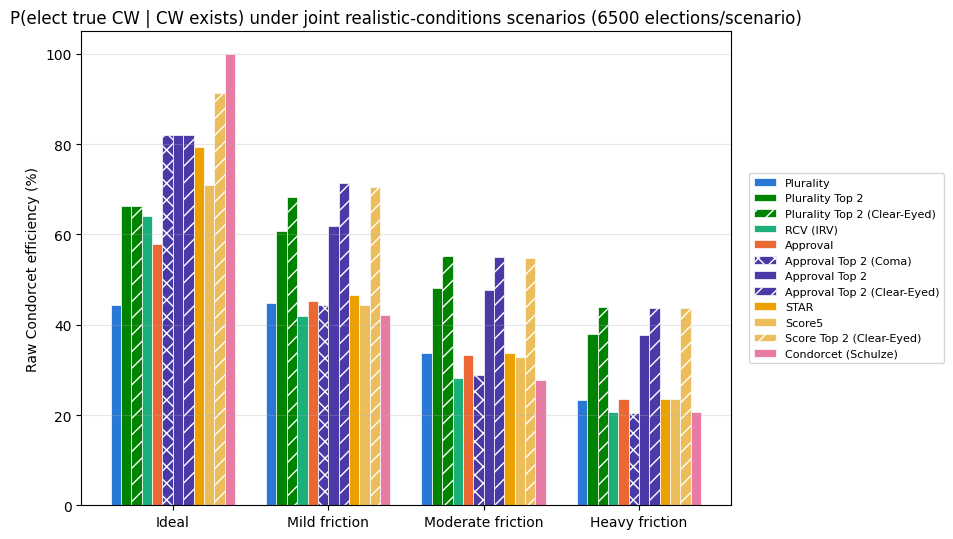

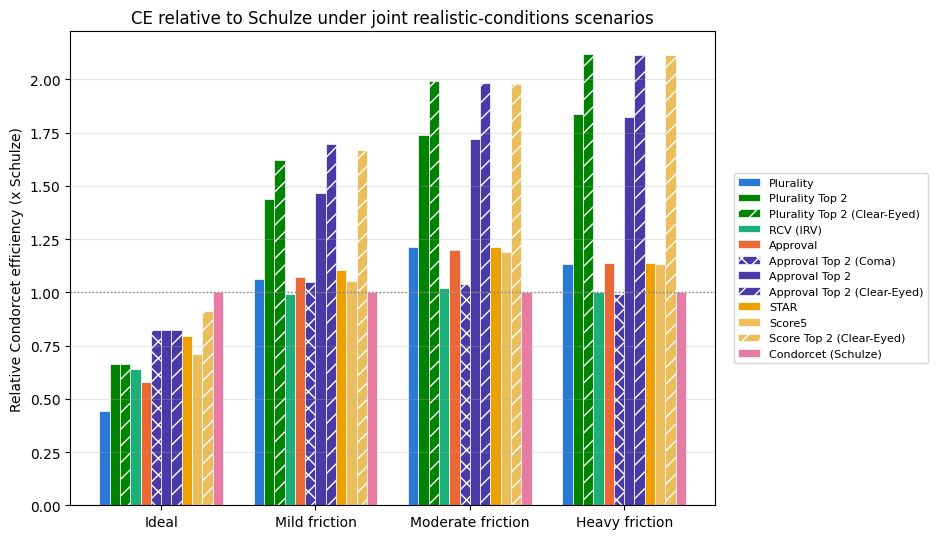

In [115]:
_joint_ce_table_lines = ["| Method | " + " | ".join(_scenario_names) + " |",
                         "|---|" + "---|" * len(_scenario_names)]
for label in COMPARE_LABELS:
    row = [label]
    for name in _scenario_names:
        raw = joint_ce_results[name].get((label, "honBallot"))
        rel = relative_ce(joint_ce_results[name]).get((label, "honBallot"))
        raw_str = "n/a" if raw is None or raw != raw else f"{raw * 100:.1f}%"
        rel_str = "" if rel is None else f" ({rel:.2f}x Schulze)"
        row.append(raw_str + rel_str)
    _joint_ce_table_lines.append("| " + " | ".join(row) + " |")
display(Markdown("\n".join(_joint_ce_table_lines)))

# Grouped bar chart: one group per scenario, one bar per method -- same layout as the VSE
# version above, but raw Condorcet efficiency instead of VSE (no error bars: CE has no CI
# computed here, unlike the VSE accumulator's mean/variance tracking).
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for i, label in enumerate(COMPARE_LABELS):
    ces = [
        (joint_ce_results[name].get((label, "honBallot")) or float("nan")) * 100
        for name in _scenario_names
    ]
    hatch = "//" if "Clear-Eyed" in label else ("xx" if "Coma" in label else None)
    _n_labels = len(COMPARE_LABELS)
    _bar_width = 0.8 / _n_labels
    _x = np.arange(len(_scenario_names))
    ax.bar(_x + i * _bar_width, ces, _bar_width,
           color=METHOD_COLORS[label], hatch=hatch, label=label, edgecolor="white", linewidth=0.5)
ax.set_xticks(_x + _bar_width * (_n_labels - 1) / 2)
ax.set_xticklabels(_scenario_names)
ax.set_ylabel("Raw Condorcet efficiency (%)")
ax.set_title(f"P(elect true CW | CW exists) under joint realistic-conditions scenarios ({JOINT_NITER} elections/scenario)")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Same layout as the raw-CE chart above, but relative to Schulze's own CE at each scenario --
# computed once here and reused, rather than recomputing relative_ce(...) per method per scenario.
joint_rel_ce_results = {name: relative_ce(joint_ce_results[name]) for name in _scenario_names}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for i, label in enumerate(COMPARE_LABELS):
    rels = [
        joint_rel_ce_results[name].get((label, "honBallot"), float("nan"))
        for name in _scenario_names
    ]
    hatch = "//" if "Clear-Eyed" in label else ("xx" if "Coma" in label else None)
    ax.bar(_x + i * _bar_width, rels, _bar_width,
           color=METHOD_COLORS[label], hatch=hatch, label=label, edgecolor="white", linewidth=0.5)
ax.axhline(1.0, color="gray", linewidth=1, linestyle=":")  # "same as Schulze"
ax.set_xticks(_x + _bar_width * (_n_labels - 1) / 2)
ax.set_xticklabels(_scenario_names)
ax.set_ylabel("Relative Condorcet efficiency (x Schulze)")
ax.set_title("CE relative to Schulze under joint realistic-conditions scenarios")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Condorcet efficiency: paired gap vs Schulze by joint-friction scenario

Reads directly off the main joint-scenario run above, which folds a paired CW-selection-rate diff
for every method vs Schulze into the same simulation pass (same design as the VSE-gap tables
elsewhere in this section) -- quantifies whether the raw-%/relative-to-Schulze numbers above are
actually significant, not just visually different. Scoped to the 3 friction scenarios (Mild/
Moderate/Heavy) -- "Ideal" excluded from paired comparisons throughout this section, same
precedent as every other paired-diff table here.

In [116]:
_ce_gap_lines = []
for name in _scenario_names:
    _ce_gap_lines.extend([
        f"#### {name}: paired Condorcet-efficiency gap vs Schulze (pp)",
        "",
        "| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |",
        "|---|---|---|---|",
    ])
    # sort the labels by the gap (descending) so that the most positive gaps (methods that beat Schulze) are at the top of the table, and the most negative gaps (methods that lose to Schulze) are at the bottom
    sorted_labels = sorted(COMPARE_LABELS, key=lambda label: paired_ce_by_scenario[name].get((label, "Condorcet (Schulze)"), (0, 0))[0], reverse=True)
    for label in sorted_labels:
        if label == "Condorcet (Schulze)":
            continue
        if ('Coma' in label or 'Clear-Eyed' in label) and name == "Ideal":
            # skip Coma/Clear-Eyed variants at Ideal, since they are mathematically identical to their base method (see Section 9's _IDENTICAL_AT_IDEAL aliasing)
            continue
        gap, ci = paired_ce_by_scenario[name][(label, "Condorcet (Schulze)")]
        gap *= 100
        ci *= 100
        _register_significance(f"CE gap vs Schulze: {name}", label, gap, ci, label, "Condorcet (Schulze)", spotlight=True)
        sig = "Yes" if gap - ci > 0 or gap + ci < 0 else ""
        if sig == "Yes":
            sig += f" ({label} better)" if gap > 0 else " (Schulze better)"
        _ce_gap_lines.append(f"| {label} | {gap:+.1f}% | [{gap-ci:+.1f}%, {gap+ci:+.1f}%] | {sig or 'No (CI contains 0)'} |")
    _ce_gap_lines.append("")
display(Markdown("\n".join(_ce_gap_lines)))

#### Ideal: paired Condorcet-efficiency gap vs Schulze (pp)

| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |
|---|---|---|---|
| Approval Top 2 | -17.9% | [-19.6%, -16.2%] | Yes (Schulze better) |
| STAR | -20.7% | [-22.4%, -18.9%] | Yes (Schulze better) |
| Score5 | -29.1% | [-31.1%, -27.1%] | Yes (Schulze better) |
| Plurality Top 2 | -33.8% | [-35.9%, -31.7%] | Yes (Schulze better) |
| RCV (IRV) | -36.0% | [-38.1%, -33.9%] | Yes (Schulze better) |
| Approval | -42.2% | [-44.4%, -40.0%] | Yes (Schulze better) |
| Plurality | -55.6% | [-57.8%, -53.5%] | Yes (Schulze better) |

#### Mild friction: paired Condorcet-efficiency gap vs Schulze (pp)

| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |
|---|---|---|---|
| Approval Top 2 (Clear-Eyed) | +29.3% | [+28.1%, +30.4%] | Yes (Approval Top 2 (Clear-Eyed) better) |
| Score Top 2 (Clear-Eyed) | +28.3% | [+27.2%, +29.4%] | Yes (Score Top 2 (Clear-Eyed) better) |
| Plurality Top 2 (Clear-Eyed) | +26.2% | [+25.0%, +27.4%] | Yes (Plurality Top 2 (Clear-Eyed) better) |
| Approval Top 2 | +19.7% | [+18.4%, +20.9%] | Yes (Approval Top 2 better) |
| Plurality Top 2 | +18.6% | [+17.3%, +19.8%] | Yes (Plurality Top 2 better) |
| STAR | +4.4% | [+3.7%, +5.1%] | Yes (STAR better) |
| Approval | +3.0% | [+2.3%, +3.8%] | Yes (Approval better) |
| Plurality | +2.6% | [+1.6%, +3.6%] | Yes (Plurality better) |
| Score5 | +2.2% | [+1.5%, +2.9%] | Yes (Score5 better) |
| Approval Top 2 (Coma) | +2.1% | [+1.4%, +2.8%] | Yes (Approval Top 2 (Coma) better) |
| RCV (IRV) | -0.3% | [-0.7%, +0.2%] | No (CI contains 0) |

#### Moderate friction: paired Condorcet-efficiency gap vs Schulze (pp)

| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |
|---|---|---|---|
| Plurality Top 2 (Clear-Eyed) | +27.5% | [+26.4%, +28.6%] | Yes (Plurality Top 2 (Clear-Eyed) better) |
| Approval Top 2 (Clear-Eyed) | +27.3% | [+26.2%, +28.4%] | Yes (Approval Top 2 (Clear-Eyed) better) |
| Score Top 2 (Clear-Eyed) | +27.1% | [+26.0%, +28.2%] | Yes (Score Top 2 (Clear-Eyed) better) |
| Plurality Top 2 | +20.5% | [+19.3%, +21.6%] | Yes (Plurality Top 2 better) |
| Approval Top 2 | +20.0% | [+18.8%, +21.2%] | Yes (Approval Top 2 better) |
| Plurality | +5.9% | [+5.2%, +6.5%] | Yes (Plurality better) |
| STAR | +5.9% | [+5.3%, +6.5%] | Yes (STAR better) |
| Approval | +5.6% | [+4.9%, +6.2%] | Yes (Approval better) |
| Score5 | +5.2% | [+4.6%, +5.8%] | Yes (Score5 better) |
| Approval Top 2 (Coma) | +1.1% | [+0.6%, +1.6%] | Yes (Approval Top 2 (Coma) better) |
| RCV (IRV) | +0.5% | [+0.2%, +0.8%] | Yes (RCV (IRV) better) |

#### Heavy friction: paired Condorcet-efficiency gap vs Schulze (pp)

| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |
|---|---|---|---|
| Plurality Top 2 (Clear-Eyed) | +23.2% | [+22.1%, +24.2%] | Yes (Plurality Top 2 (Clear-Eyed) better) |
| Approval Top 2 (Clear-Eyed) | +23.1% | [+22.1%, +24.1%] | Yes (Approval Top 2 (Clear-Eyed) better) |
| Score Top 2 (Clear-Eyed) | +23.0% | [+22.0%, +24.1%] | Yes (Score Top 2 (Clear-Eyed) better) |
| Plurality Top 2 | +17.3% | [+16.2%, +18.4%] | Yes (Plurality Top 2 better) |
| Approval Top 2 | +17.0% | [+15.9%, +18.1%] | Yes (Approval Top 2 better) |
| Approval | +2.9% | [+2.5%, +3.3%] | Yes (Approval better) |
| STAR | +2.8% | [+2.4%, +3.3%] | Yes (STAR better) |
| Score5 | +2.8% | [+2.3%, +3.2%] | Yes (Score5 better) |
| Plurality | +2.7% | [+2.3%, +3.2%] | Yes (Plurality better) |
| RCV (IRV) | +0.0% | [-0.1%, +0.2%] | No (CI contains 0) |
| Approval Top 2 (Coma) | -0.2% | [-0.5%, +0.1%] | No (CI contains 0) |


## 20. Method Robustness Rankings

In [117]:
def compute_robustness_rankings(scores_by_method):
    """scores_by_method: {label: [(mean, ci), (mean, ci), ...]} -- one (mean, ci) per axis
    point (a scenario, or a chooser/strategy level), same order/count for every method.

    Four methodologically distinct ways to collapse multi-point performance into one ranking:

    1. Mean across axis -- simplest, most transparent. Can hide a method that's great at one
       axis point and collapses at another, if the average still looks fine.
    2. Worst-case, using each axis point's 95% CI LOWER BOUND (not the raw point estimate) --
       the classic Rawlsian/robust-optimization "floor" framing. Using the lower bound rather
       than the raw min avoids the "min of several noisy estimates is biased downward" trap:
       whichever axis point got unlucky sampling would otherwise look artificially worse.
    3. Average regret vs. the best-performing method AT THAT SAME axis point -- normalizes
       away the fact that some axis points (e.g. Heavy friction) have a lower ceiling for
       EVERYONE, so raw VSE comparisons across axis points conflate "hard scenario" with
       "bad method." Lower is better (0 = always tied the best available option).
    4. Average rank across axis points (Borda-style) -- robust to VSE scores compressing
       together at harder axis points (a real effect under friction), since it only uses
       *ordering* within each axis point, not magnitude. Lower is better (1 = always best).
    """
    labels = list(scores_by_method)
    n_axis = len(next(iter(scores_by_method.values())))
    assert all(len(v) == n_axis for v in scores_by_method.values()), "mismatched axis lengths"

    mean_across = {label: sum(m for m, _ in vals) / n_axis for label, vals in scores_by_method.items()}

    worst_case = {label: min(m - ci for m, ci in vals) for label, vals in scores_by_method.items()}

    best_per_axis = [max(scores_by_method[l][j][0] for l in labels) for j in range(n_axis)]
    avg_regret = {
        label: sum(best_per_axis[j] - scores_by_method[label][j][0] for j in range(n_axis)) / n_axis
        for label in labels
    }

    avg_rank = {label: 0.0 for label in labels}
    for j in range(n_axis):
        order = sorted(labels, key=lambda l: -scores_by_method[l][j][0])
        for rank, label in enumerate(order, start=1):
            avg_rank[label] += rank
    avg_rank = {label: total / n_axis for label, total in avg_rank.items()}

    return {
        "1. Mean VSE across axis (higher better)": sorted(mean_across.items(), key=lambda x: -x[1]),
        "2. Worst-case VSE, CI lower bound (higher better)": sorted(worst_case.items(), key=lambda x: -x[1]),
        "3. Avg. regret vs. best-at-that-point (lower better)": sorted(avg_regret.items(), key=lambda x: x[1]),
        "4. Avg. rank across axis (lower better)": sorted(avg_rank.items(), key=lambda x: x[1]),
    }


def display_rankings(title, rankings, as_percent=True):
    lines = [f"### {title}", ""]
    for metric_name, ranked in rankings.items():
        lines.append(f"**{metric_name}**")
        lines.append("")
        lines.append("| Rank | Method | Score |")
        lines.append("|---|---|---|")
        for i, (label, score) in enumerate(ranked, start=1):
            score_str = f"{score * 100:.1f}%" if not metric_name.startswith("4.") else f"{score:.2f}"
            lines.append(f"| {i} | {label} | {score_str} |")
        lines.append("")
    display(Markdown("\n".join(lines)))

# --- 1. Ideal: VSE range across strategy/chooser levels (Section 9/10's own axis) ---
# exclude clear-eyed/coma from the used labels
ideal_labels = [l for l in COMPARE_LABELS if 'Coma' not in l and 'Clear-Eyed' not in l]
_ideal_scores_by_method = {
    label: [v for (l, c), v in results.items() if l == label]
    for label in ideal_labels
}
display_rankings("Ideal: robustness across strategy levels", _ideal_scores_by_method and
                  compute_robustness_rankings(_ideal_scores_by_method))

other_labels = [l for l in COMPARE_LABELS if 'Score Top' not in l]
# --- 2. Friction only: Mild / Moderate / Heavy (honest ballots) ---
_friction_scenarios = ["Mild friction", "Moderate friction", "Heavy friction"]
_friction_scores_by_method = {
    label: [joint_results[name][(label, "honBallot")] for name in _friction_scenarios]
    for label in other_labels
}
display_rankings("Friction only (Mild/Moderate/Heavy)", compute_robustness_rankings(_friction_scores_by_method))

# --- 3. Holistic: Ideal + Mild + Moderate + Heavy (honest ballots) ---
_all_scenarios = list(JOINT_SCENARIOS)
_holistic_scores_by_method = {
    label: [joint_results[name][(label, "honBallot")] for name in _all_scenarios]
    for label in other_labels
}
display_rankings("Holistic (Ideal + all friction scenarios)", compute_robustness_rankings(_holistic_scores_by_method))

### Ideal: robustness across strategy levels

**1. Mean VSE across axis (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 | 95.9% |
| 2 | STAR | 95.0% |
| 3 | Score5 | 93.4% |
| 4 | Condorcet (Schulze) | 92.3% |
| 5 | Approval | 91.0% |
| 6 | Plurality Top 2 | 85.3% |
| 7 | RCV (IRV) | 83.1% |
| 8 | Plurality | 70.3% |

**2. Worst-case VSE, CI lower bound (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 | 91.6% |
| 2 | STAR | 88.3% |
| 3 | Condorcet (Schulze) | 82.9% |
| 4 | Approval | 82.9% |
| 5 | Score5 | 81.8% |
| 6 | Plurality Top 2 | 81.3% |
| 7 | RCV (IRV) | 74.7% |
| 8 | Plurality | 56.6% |

**3. Avg. regret vs. best-at-that-point (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 | 0.6% |
| 2 | STAR | 1.5% |
| 3 | Score5 | 3.1% |
| 4 | Condorcet (Schulze) | 4.2% |
| 5 | Approval | 5.5% |
| 6 | Plurality Top 2 | 11.2% |
| 7 | RCV (IRV) | 13.4% |
| 8 | Plurality | 26.2% |

**4. Avg. rank across axis (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 | 1.88 |
| 2 | STAR | 2.12 |
| 3 | Score5 | 3.25 |
| 4 | Condorcet (Schulze) | 3.75 |
| 5 | Approval | 4.50 |
| 6 | Plurality Top 2 | 6.12 |
| 7 | RCV (IRV) | 6.62 |
| 8 | Plurality | 7.75 |


### Friction only (Mild/Moderate/Heavy)

**1. Mean VSE across axis (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 (Clear-Eyed) | 83.9% |
| 2 | Plurality Top 2 (Clear-Eyed) | 82.4% |
| 3 | Approval Top 2 | 82.3% |
| 4 | Plurality Top 2 | 80.9% |
| 5 | STAR | 64.4% |
| 6 | Approval | 64.0% |
| 7 | Score5 | 63.2% |
| 8 | Plurality | 57.6% |
| 9 | Approval Top 2 (Coma) | 56.8% |
| 10 | RCV (IRV) | 51.1% |
| 11 | Condorcet (Schulze) | 50.8% |

**2. Worst-case VSE, CI lower bound (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 (Clear-Eyed) | 74.1% |
| 2 | Plurality Top 2 (Clear-Eyed) | 74.0% |
| 3 | Approval Top 2 | 71.5% |
| 4 | Plurality Top 2 | 71.3% |
| 5 | STAR | 42.0% |
| 6 | Approval | 41.2% |
| 7 | Score5 | 40.8% |
| 8 | Plurality | 39.7% |
| 9 | Approval Top 2 (Coma) | 29.4% |
| 10 | RCV (IRV) | 25.9% |
| 11 | Condorcet (Schulze) | 25.5% |

**3. Avg. regret vs. best-at-that-point (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 (Clear-Eyed) | 0.0% |
| 2 | Plurality Top 2 (Clear-Eyed) | 1.4% |
| 3 | Approval Top 2 | 1.5% |
| 4 | Plurality Top 2 | 2.9% |
| 5 | STAR | 19.5% |
| 6 | Approval | 19.8% |
| 7 | Score5 | 20.7% |
| 8 | Plurality | 26.3% |
| 9 | Approval Top 2 (Coma) | 27.1% |
| 10 | RCV (IRV) | 32.8% |
| 11 | Condorcet (Schulze) | 33.1% |

**4. Avg. rank across axis (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 (Clear-Eyed) | 1.00 |
| 2 | Plurality Top 2 (Clear-Eyed) | 2.33 |
| 3 | Approval Top 2 | 2.67 |
| 4 | Plurality Top 2 | 4.00 |
| 5 | STAR | 5.33 |
| 6 | Approval | 5.67 |
| 7 | Score5 | 7.00 |
| 8 | Approval Top 2 (Coma) | 8.67 |
| 9 | Plurality | 9.00 |
| 10 | RCV (IRV) | 10.00 |
| 11 | Condorcet (Schulze) | 10.33 |


### Holistic (Ideal + all friction scenarios)

**1. Mean VSE across axis (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 (Clear-Eyed) | 86.8% |
| 2 | Approval Top 2 | 85.6% |
| 3 | Plurality Top 2 (Clear-Eyed) | 82.7% |
| 4 | Plurality Top 2 | 81.6% |
| 5 | STAR | 72.6% |
| 6 | Score5 | 71.4% |
| 7 | Approval | 70.3% |
| 8 | Approval Top 2 (Coma) | 66.5% |
| 9 | Condorcet (Schulze) | 62.7% |
| 10 | RCV (IRV) | 60.3% |
| 11 | Plurality | 58.6% |

**2. Worst-case VSE, CI lower bound (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 (Clear-Eyed) | 74.1% |
| 2 | Plurality Top 2 (Clear-Eyed) | 74.0% |
| 3 | Approval Top 2 | 71.5% |
| 4 | Plurality Top 2 | 71.3% |
| 5 | STAR | 42.0% |
| 6 | Approval | 41.2% |
| 7 | Score5 | 40.8% |
| 8 | Plurality | 39.7% |
| 9 | Approval Top 2 (Coma) | 29.4% |
| 10 | RCV (IRV) | 25.9% |
| 11 | Condorcet (Schulze) | 25.5% |

**3. Avg. regret vs. best-at-that-point (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 (Clear-Eyed) | 0.8% |
| 2 | Approval Top 2 | 1.9% |
| 3 | Plurality Top 2 (Clear-Eyed) | 4.8% |
| 4 | Plurality Top 2 | 6.0% |
| 5 | STAR | 14.9% |
| 6 | Score5 | 16.2% |
| 7 | Approval | 17.2% |
| 8 | Approval Top 2 (Coma) | 21.1% |
| 9 | Condorcet (Schulze) | 24.8% |
| 10 | RCV (IRV) | 27.2% |
| 11 | Plurality | 29.0% |

**4. Avg. rank across axis (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 (Clear-Eyed) | 2.25 |
| 2 | Approval Top 2 | 3.25 |
| 3 | Plurality Top 2 (Clear-Eyed) | 4.25 |
| 4 | STAR | 4.50 |
| 5 | Plurality Top 2 | 5.25 |
| 6 | Approval | 6.00 |
| 7 | Score5 | 6.00 |
| 8 | Approval Top 2 (Coma) | 7.50 |
| 9 | Condorcet (Schulze) | 8.00 |
| 10 | Plurality | 9.50 |
| 11 | RCV (IRV) | 9.50 |


## 21. Runoff epistemic-noise sweep: how much does a cleaner delayed runoff improve Approval Top 2?

`Top2Base` takes a continuous `runoff_rho` instead of a binary Coma toggle -- `runoff_rho=None`
reuses the primary's own (possibly noisy) epistemic-noise level for the runoff, but NOT its
participation friction (`runoff_awareness_alpha` defaults to `1.0`, full awareness, independently
of `runoff_rho`); `runoff_rho=1.0` uses the *true* electorate (Clear-Eyed); and any value in between
draws a **fresh, independent** perceived electorate from the *true* electorate at that knowledge
level -- never further noise stacked on the primary's own already-noisy perception, since `rho` is
defined as correlation with *true* utility.

This section asks: if the primary happens under realistic friction, how much does Approval Top
2's outcome recover as the *runoff's own* information quality improves from "no better than the
primary" up to "perfect"? Honest ballots throughout, isolating one question: does a well-informed
delayed runoff rescue a poorly-informed primary?

Two primary-friction baselines, reusing the `JOINT_SCENARIOS` presets from Section 16 directly,
with Schulze's own VSE at those same presets shown as a reference line. STAR's own runoff isn't
modeled here as a hypothetical delayed runoff -- STAR's actual, automatic, same-ballot runoff is
measured directly in Sections 22-23 below.

**Fatigue vs. awareness in the runoff -- two different kinds of assumption.** Fatigue is always
pinned at 1.0 for the runoff, unconditionally: the fatigue mechanism models giving up partway
down a *long* ballot, and 2 named finalists isn't a long ballot to get tired scanning through.

Awareness is a genuinely different, more contestable assumption, and it turns out to matter a
lot more than epistemic noise does (see the results below) -- so rather than assert one answer,
this section runs the sweep under **two**:
- **Awareness resets to 1.0**: voters become aware of all the finalists by runoff time --
  justified by real two-round elections concentrating media coverage and debates on whoever's
  left, which plausibly restores awareness even for a candidate nobody noticed in a crowded
  primary. Brackets the Groggy/Clear-Eyed models, so this is the mode computed at full precision
  below.
- **Awareness carries over from the primary** (the baseline's own `awareness_alpha`, e.g. 0.8 for
  "Moderate friction"): voters who didn't know a finalist during the primary still don't by the
  runoff -- the more conservative assumption. Doesn't bracket a named model, so it's computed
  separately at reduced precision in the secondary section further down instead of doubling this
  section's main runtime.

Each panel also marks `runoff_rho=None` (an "x") -- the plain registered "Approval Top 2" method
(Groggy), which reuses the primary's epistemic-noise level for the runoff. The gap from it to the
first swept point isolates how much of the recovery comes from having any dedicated runoff step
at all, before epistemic knowledge itself improves.

**Common random numbers:** `sweep_runoff_t` draws each election's true/primary electorate once
and reuses it across every `(method, runoff_rho)` combination for that election, the same
paired-comparison principle `run_vse_simulation` already applies across the `METHODS` list --
sharing randomness between the things being compared cancels most of it out of the comparison,
and cuts total simulation cost too.

In [118]:
def sweep_runoff_t(method_factories, runoff_t_values, primary_params, niter, awareness_modes,
                    electorates=None):
    """method_factories: {label: factory(runoff_rho, runoff_awareness_alpha) -> fresh method instance}.
    primary_params: epistemic_rho/awareness_alpha/fatigue_beta held FIXED for the primary. awareness_modes:
    {mode_name: (rt -> runoff_awareness_alpha)} -- ALL modes evaluated together, sharing the SAME
    primary electorate per election, rather than each mode drawing its own independent batch.
    This extends the paired-comparison (common-random-numbers) design already used for
    methods/runoff_rho to the awareness-mode axis too: the 2 awareness modes for a given baseline
    share identical primary_params (only the runoff differs between them), so there's no reason
    to redraw niter primary electorates per mode when niter total already covers both -- cuts
    primary-electorate draws from niter * len(awareness_modes) down to niter.

    Each election also draws ONE noise sample (draw_noise) that's reused across EVERY swept
    runoff_rho value for that election (via each method instance's _runoff_noise) -- so runoff_rho
    varies only the rho-weighting applied to the SAME underlying misperception, not an unrelated
    fresh draw at every point. This is what makes the runoff_rho axis itself a genuine paired sweep,
    not just the primary electorate.

    electorates: optional shared pool (same convention as sweep_methods/run_joint_scenarios) --
    pass the SAME pool used elsewhere at this baseline (e.g. the kappa sweep below) so
    every sweep at a given baseline compares against identical underlying elections instead of
    each drawing its own independent batch.

    Returns {mode_name: {runoff_rho: {(label, chooser): (mean, ci)}}}.
    """
    sweep_start_time = time.time()
    epistemic_rho = primary_params.get("epistemic_rho", 1.0)
    awareness_alpha = primary_params.get("awareness_alpha", 1.0)
    fatigue_beta = primary_params.get("fatigue_beta", 1.0)
    summary = {mode_name: {rt: defaultdict(lambda: [0, 0.0, 0.0]) for rt in runoff_t_values}
               for mode_name in awareness_modes}
    for i in range(niter):
        true_electorate = electorates[i] if electorates is not None else MODEL(NVOT, NCAND)
        election_noise = draw_noise(true_electorate)  # shared across every runoff_rho below
        perceived_electorate = make_perceived_electorate(true_electorate, epistemic_rho, noise=election_noise)
        ballot_electorate, _, _ = apply_participation_friction(
            perceived_electorate, true_electorate, awareness_alpha, fatigue_beta
        )  # this sweep's methods (Top2 variants) never feed Irv, so discard genuine_sets/aware_sets
        for mode_name, awareness_for_rt in awareness_modes.items():
            for label, factory in method_factories.items():
                for rt in runoff_t_values:
                    _method = factory(rt, awareness_for_rt(rt))
                    if rt is not None:
                        # Same z as the primary's own perceived_electorate -- isolates "how does
                        # runoff_rho alone change things" from "what if we'd drawn different noise".
                        _method._runoff_noise = election_noise
                    for row in _method.resultsTable(
                        i, str(MODEL), NCAND, ballot_electorate, CHOOSER_FUNS,
                        media=MEDIA, scoring_voters=true_electorate, perceived_voters=perceived_electorate,
                        honest_only=True,
                    ):
                        acc = summary[mode_name][rt][(label, row["chooser"])]
                        acc[0] += 1
                        acc[1] += row["vse"]
                        acc[2] += row["vse"] ** 2
        if (i + 1) % 50 == 0:
            print(f"{i + 1}/{niter} elections done in {time.time() - sweep_start_time:.1f}s")
    return {mode_name: {rt: reduce_to_mean_ci(dict(summary[mode_name][rt])) for rt in runoff_t_values}
            for mode_name in awareness_modes}

# Adjust RUNOFF_RHO_SWEEP_NITER for this cell in Section 5 (Parameters).
RUNOFF_BASELINE_NAMES = ["Mild friction", "Moderate friction", "Heavy friction"]  # reuse
# JOINT_SCENARIOS as-is -- Mild included for completeness/consistency with the learn sweep below,
# even though its curve is expected to be the flattest of the three (least friction to recover from).

MILD_BASELINE = JOINT_SCENARIOS["Mild friction"]["epistemic_rho"]
MODERATE_BASELINE = JOINT_SCENARIOS["Moderate friction"]["epistemic_rho"]
HEAVY_BASELINE = JOINT_SCENARIOS["Heavy friction"]["epistemic_rho"]

# Swept across the FULL 0-1 range (not just [own baseline, 1.0]) so the chart shows the real
# shape of the curve, not just its already-high-information tail. Each baseline's own primary
# epistemic_rho is explicitly unioned in as a real grid point (not just a nearby one) -- with the
# paired noise above, the fresh runoff_rho=<baseline> point should land on (or, given independent
# per-election draws, very near) the runoff_rho=None (Groggy) result plotted alongside it: a genuine
# sanity check, not just a visual approximation.
MILD_T_VALUES = np.array(sorted(set(np.linspace(0.0, 1.0, 6)) | {MILD_BASELINE}))
MODERATE_T_VALUES = np.array(sorted(set(np.linspace(0.0, 1.0, 6)) | {MODERATE_BASELINE}))
HEAVY_T_VALUES = np.array(sorted(set(np.linspace(0.0, 1.0, 6)) | {HEAVY_BASELINE}))

RUNOFF_T_VALUES_BY_BASELINE = {
    "Mild friction": [None] + list(MILD_T_VALUES),
    "Moderate friction": [None] + list(MODERATE_T_VALUES),
    "Heavy friction": [None] + list(HEAVY_T_VALUES),
}
RUNOFF_METHOD_FACTORIES = {
    "Approval Top 2": lambda rt, aw: ApprovalTop2(runoff_rho=rt, runoff_awareness_alpha=aw),
}
# Fatigue is always pinned at 1.0 for the runoff (low-controversy: 2 candidates isn't a long
# ballot to get fatigued by). Awareness is the real, contestable assumption -- run it two
# ways rather than asserting one, so the sensitivity of the whole story to this one modeling
# choice is visible rather than hidden. Each mode is a function of (rt, primary_awareness_alpha),
# so awareness can be pinned or held at the primary's own level. (A third mode used to tie
# awareness to move together with runoff_rho itself -- dropped: now that "chance to learn who the
# finalists are" and "chance to correct a noisy preference" are treated as genuinely separate
# mechanisms, see the kappa sweep below, yoking them to one shared slider no longer makes
# sense as something to test.)
RUNOFF_AWARENESS_MODES = {
    "Awareness resets to 1.0": lambda rt, primary_aw: 1.0,
    "Awareness carries over from primary": lambda rt, primary_aw: primary_aw,
}
# Only "resets to 1.0" runs at full precision below -- it's the mode that brackets the Groggy/
# Clear-Eyed models (see the runoff-t-sweep chart's X markers). "Carries over from primary"
# doesn't bracket any named model, so it's relegated to the lower-precision secondary section
# further down instead of doubling this section's main runtime.
RUNOFF_AWARENESS_MODES_MAIN = {"Awareness resets to 1.0": RUNOFF_AWARENESS_MODES["Awareness resets to 1.0"]}

In [119]:
# Adjust RUNOFF_SWEEP_NITER for this cell in Section 5 (Parameters).

RUNOFF_ELECTORATE_POOLS = {
    _baseline: [MODEL(NVOT, NCAND) for _ in range(RUNOFF_SWEEP_NITER)]
    for _baseline in RUNOFF_BASELINE_NAMES
}

In [120]:
runoff_sweep_results = {}  # {baseline: {mode_name: {runoff_rho: {(label, chooser): (mean, ci)}}}}
for _baseline in RUNOFF_BASELINE_NAMES:
    _primary_params = JOINT_SCENARIOS[_baseline]
    _primary_aw = _primary_params["awareness_alpha"]
    _awareness_fns = {
        mode_name: (lambda rt, _fn=fn: _fn(rt, _primary_aw))
        for mode_name, fn in RUNOFF_AWARENESS_MODES_MAIN.items()
    }
    print(f"{_baseline}:")
    runoff_sweep_results[_baseline] = sweep_runoff_t(
        RUNOFF_METHOD_FACTORIES, RUNOFF_T_VALUES_BY_BASELINE[_baseline],
        _primary_params, RUNOFF_RHO_SWEEP_NITER, _awareness_fns,
        electorates=RUNOFF_ELECTORATE_POOLS[_baseline],
    )

Mild friction:
50/150 elections done in 4.2s
100/150 elections done in 7.6s
150/150 elections done in 11.5s
Moderate friction:
50/150 elections done in 3.0s
100/150 elections done in 6.0s
150/150 elections done in 9.0s
Heavy friction:
50/150 elections done in 3.0s
100/150 elections done in 6.8s
150/150 elections done in 10.1s


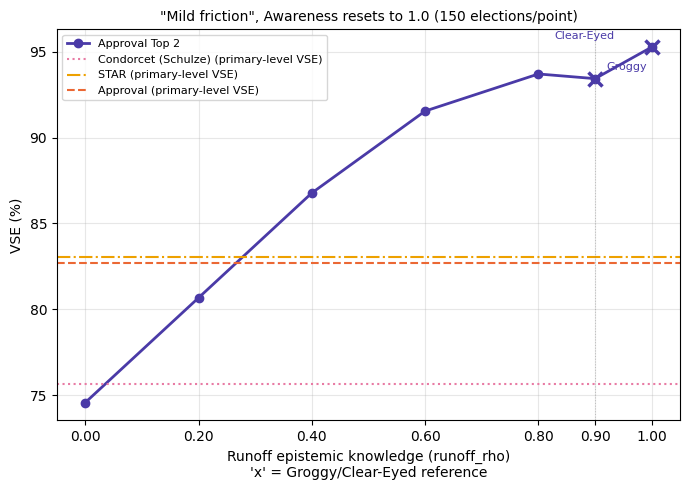

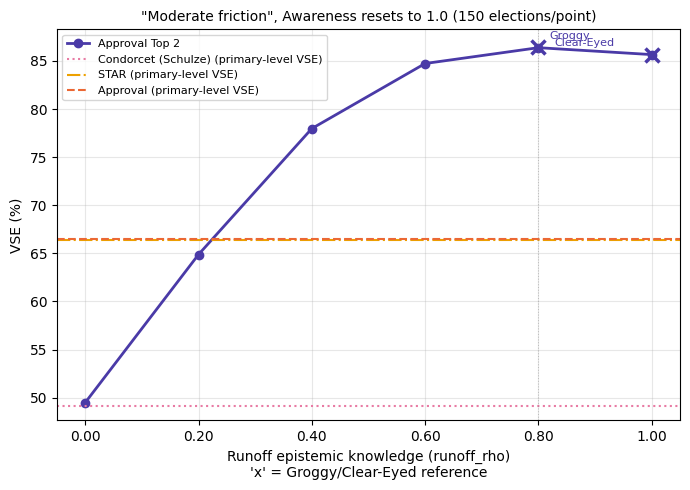

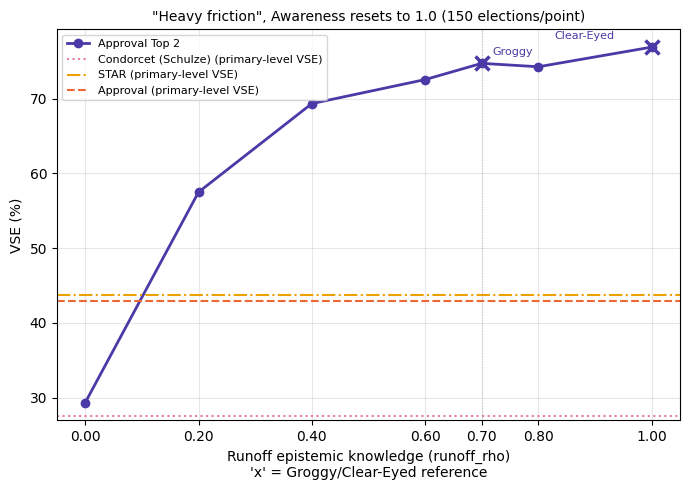

In [121]:
_mode_name = "Awareness resets to 1.0"
for _baseline in RUNOFF_BASELINE_NAMES:
    fig, ax = plt.subplots(figsize=(7, 5))
    results_by_rt = runoff_sweep_results[_baseline][_mode_name]
    rho_numeric = sorted(rt for rt in results_by_rt if rt is not None)
    _baseline_rho = JOINT_SCENARIOS[_baseline]["epistemic_rho"]
    for label in RUNOFF_METHOD_FACTORIES:
        color = METHOD_COLORS[label]
        style = METHOD_LINESTYLES.get(label, "-")
        vses = [results_by_rt[rt][(label, "honBallot")][0] * 100 for rt in rho_numeric]
        ax.plot(rho_numeric, vses, marker="o", markersize=6, linewidth=2, color=color, linestyle=style, label=label)
        # runoff_rho=None (Groggy) plotted AT rho=_baseline_rho, not offset to the side -- with the
        # paired noise in sweep_runoff_t, a fresh runoff_rho=_baseline_rho draw should land on (or
        # very near) this same point: a real sanity check, not just a visual approximation.
        # runoff_rho=1.0 (the curve's own right endpoint) is EXACTLY Clear-Eyed in this mode
        # (runoff_awareness_alpha=1.0 throughout) -- no separate computation needed.
        none_vse = results_by_rt[None][(label, "honBallot")][0] * 100
        ax.plot([_baseline_rho], [none_vse], marker="x", markersize=10, markeredgewidth=2.5, color=color, zorder=5)
        ax.annotate("Groggy", (_baseline_rho, none_vse), textcoords="offset points", xytext=(8, 6), fontsize=8, color=color)
        ax.plot([rho_numeric[-1]], [vses[-1]], marker="x", markersize=10, markeredgewidth=2.5, color=color, zorder=5)
        ax.annotate("Clear-Eyed", (rho_numeric[-1], vses[-1]), textcoords="offset points", xytext=(-70, 6), fontsize=8, color=color)
    for _ref_label, _ref_style in [("Condorcet (Schulze)", ":"), ("STAR", "-."), ("Approval", "--")]:
        _ref_vse = joint_results[_baseline][(_ref_label, "honBallot")][0] * 100
        ax.axhline(_ref_vse, color=METHOD_COLORS[_ref_label], linewidth=1.5, linestyle=_ref_style,
                   label=f"{_ref_label} (primary-level VSE)")
    ax.axvline(_baseline_rho, color="gray", linewidth=0.75, alpha=0.4, linestyle=":")
    ax.set_xticks(rho_numeric)
    ax.set_xticklabels([f"{rho:.2f}" for rho in rho_numeric])
    ax.set_xlabel("Runoff epistemic knowledge (runoff_rho)\n'x' = Groggy/Clear-Eyed reference")
    ax.set_ylabel("VSE (%)")
    ax.set_title(f'"{_baseline}", {_mode_name} ({RUNOFF_RHO_SWEEP_NITER} elections/point)', fontsize=10)
    ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [122]:
for _baseline in RUNOFF_BASELINE_NAMES:
    for _mode in runoff_sweep_results[_baseline]:
        display(Markdown(f"#### {_baseline}, {_mode.lower()}: VSE by runoff_rho (honest ballots)"))
        results_by_rt = runoff_sweep_results[_baseline][_mode]
        rho_numeric = sorted(rt for rt in results_by_rt if rt is not None)
        header = ["Method", "None (=primary reused)"] + [f"rho={rho:.2f}" for rho in rho_numeric]
        lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
        for label in RUNOFF_METHOD_FACTORIES:
            row = [label]
            none_mean, none_ci = results_by_rt[None][(label, "honBallot")]
            row.append(f"{none_mean * 100:.1f}% (+/-{none_ci * 100:.1f})")
            for rt in rho_numeric:
                mean_, ci = results_by_rt[rt][(label, "honBallot")]
                row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
            lines.append("| " + " | ".join(row) + " |")
        display(Markdown("\n".join(lines)))

#### Mild friction, awareness resets to 1.0: VSE by runoff_rho (honest ballots)

| Method | None (=primary reused) | rho=0.00 | rho=0.20 | rho=0.40 | rho=0.60 | rho=0.80 | rho=0.90 | rho=1.00 |
|---|---|---|---|---|---|---|---|---|
| Approval Top 2 | 93.4% (+/-2.4) | 74.6% (+/-6.4) | 80.7% (+/-6.3) | 86.8% (+/-4.2) | 91.5% (+/-2.9) | 93.7% (+/-2.2) | 93.4% (+/-2.4) | 95.3% (+/-2.0) |

#### Moderate friction, awareness resets to 1.0: VSE by runoff_rho (honest ballots)

| Method | None (=primary reused) | rho=0.00 | rho=0.20 | rho=0.40 | rho=0.60 | rho=0.80 | rho=1.00 |
|---|---|---|---|---|---|---|---|
| Approval Top 2 | 86.4% (+/-3.8) | 49.5% (+/-11.3) | 64.9% (+/-9.5) | 78.0% (+/-7.4) | 84.7% (+/-4.2) | 86.4% (+/-3.8) | 85.7% (+/-6.6) |

#### Heavy friction, awareness resets to 1.0: VSE by runoff_rho (honest ballots)

| Method | None (=primary reused) | rho=0.00 | rho=0.20 | rho=0.40 | rho=0.60 | rho=0.70 | rho=0.80 | rho=1.00 |
|---|---|---|---|---|---|---|---|---|
| Approval Top 2 | 74.7% (+/-6.5) | 29.3% (+/-12.8) | 57.5% (+/-8.8) | 69.4% (+/-7.8) | 72.6% (+/-7.0) | 74.7% (+/-6.5) | 74.3% (+/-6.8) | 76.9% (+/-6.3) |

### Isolating awareness alone: a genuine "chance to learn" sweep

The sweep above varies the runoff's epistemic knowledge (`runoff_rho`) under two different
assumptions about how much awareness the runoff carries in -- but never holds epistemic
knowledge FIXED and varies awareness on its own, in a way that's actually a clean "chance to
learn" story. This sweep does that directly, using `Top2Base`'s `runoff_kappa` mode: a voter
unaware of a given finalist in the primary gets one independent `Bernoulli(runoff_kappa)` roll
to become aware of that specific finalist by runoff day; a voter already aware stays aware, no
regression. `runoff_kappa=0.0` is an exact match for the Coma model -- no possible roll can
succeed; `runoff_kappa=1.0` is an exact match for the default Groggy model -- every roll is
certain to succeed. Everything in between is a genuine, monotonic interpolation: VSE can only
move in one direction as `runoff_kappa` rises, unlike the `runoff_awareness_alpha`-driven
sweep this replaces, which re-drew awareness fresh at every point.

`runoff_kappa` is swept from `0.0` to `1.0` (same range across all three friction baselines
below -- unlike `runoff_rho`, its meaning doesn't depend on the primary's own `AWARENESS_ALPHA`),
with `runoff_rho` pinned FIXED at one of two values: `None` (the runoff reuses the primary's own
already-noisy information -- no epistemic improvement, only learning) or `1.0` (the runoff has
perfect epistemic information regardless of learning). Only the `None` variant runs here at full
precision (`RUNOFF_SWEEP_NITER` elections/point) -- it's the one that brackets both the Coma
(`p=0`) and Groggy (`p=1`) models. The `runoff_rho=1.0` variant only brackets Clear-Eyed at its
`p=1` endpoint, so it's relegated to the secondary, lower-precision section further down instead
of doubling this section's runtime. Both reuse the same per-baseline electorate pool
(`RUNOFF_ELECTORATE_POOLS`, defined above) the `runoff_rho` sweep already drew, across all three
friction baselines. STAR and Schulze are shown as the same fixed reference lines as the sweep above.


In [123]:
def sweep_runoff_learn(method_factories, learn_kappa_values, primary_params, niter,
                        runoff_rho_fixed, electorates=None, paired_baseline=None):
    """Like sweep_runoff_t, but holds runoff_rho FIXED at runoff_rho_fixed for every point and
    sweeps runoff_kappa instead -- isolates the "chance to learn" axis alone, holding the
    runoff's own epistemic-noise level constant throughout. At each swept point, a voter unaware
    of a given finalist in the primary gets one independent Bernoulli(runoff_kappa) roll to
    become aware of THAT finalist by runoff day (see Top2Base._runoff_electorate's
    runoff_kappa branch above). runoff_kappa=0.0 is an exact match for Coma; runoff_kappa=
    1.0 is an exact match for Groggy -- not approximations. runoff_rho_fixed=None reuses the
    primary's own (possibly noisy) epistemic level for the runoff; runoff_rho_fixed=1.0 gives the
    runoff perfect epistemic information regardless of learning. electorates: optional shared
    pool, same convention as sweep_runoff_t/sweep_methods.

    paired_baseline: optional (label, method) pair, e.g. ("STAR", METHODS_LOOKUP["STAR"]) --
    evaluated ONCE per election (not once per swept kappa, since STAR's own automatic runoff doesn't
    depend on AT2's runoff_kappa axis at all), on the SAME ballot_electorate/perceived_electorate
    every swept (label, kappa) combination sees that election -- a genuine paired comparison, not an
    independent-samples one (unlike combining this sweep's own CI with a DIFFERENT electorate
    pool's CI, e.g. joint_results). Tracks the baseline's own (mean, ci) too, not just the diff,
    so a caller can display a self-consistent AT2/baseline/gap table computed from one shared set
    of elections. Returns (results_by_kappa, paired_diff_by_kappa, baseline_mean_ci) -- paired_diff_by_kappa
    empty and baseline_mean_ci None when paired_baseline isn't given.

    Returns (results_by_kappa, paired_diff_by_kappa, baseline_mean_ci); results_by_kappa is
    {runoff_kappa: {(label, chooser): (mean, ci)}}.
    """
    sweep_start_time = time.time()
    epistemic_rho = primary_params.get("epistemic_rho", 1.0)
    awareness_alpha = primary_params.get("awareness_alpha", 1.0)
    fatigue_beta = primary_params.get("fatigue_beta", 1.0)
    summary = {kappa: defaultdict(lambda: [0, 0.0, 0.0]) for kappa in learn_kappa_values}
    paired_diff_summary = {kappa: [0, 0.0, 0.0] for kappa in learn_kappa_values}
    baseline_summary = [0, 0.0, 0.0]
    baseline_label, baseline_method = paired_baseline if paired_baseline else (None, None)
    for i in range(niter):
        true_electorate = electorates[i] if electorates is not None else MODEL(NVOT, NCAND)
        perceived_electorate = make_perceived_electorate(true_electorate, epistemic_rho)
        ballot_electorate, _, aware_sets = apply_participation_friction(
            perceived_electorate, true_electorate, awareness_alpha, fatigue_beta
        )  # aware_sets IS needed here (unlike sweep_runoff_t/the old sweep_runoff_awareness) --
           # runoff_kappa reads self._aware_sets, so it must be threaded through below.
        baseline_vse = None
        if baseline_method is not None:
            baseline_row = next(
                r for r in baseline_method.resultsTable(
                    i, str(MODEL), NCAND, ballot_electorate, [],
                    media=MEDIA, scoring_voters=true_electorate, perceived_voters=perceived_electorate,
                    honest_only=True,
                ) if r["chooser"] == "honBallot"
            )
            baseline_vse = baseline_row["vse"]
            baseline_summary[0] += 1
            baseline_summary[1] += baseline_vse
            baseline_summary[2] += baseline_vse ** 2
        for label, factory in method_factories.items():
            for kappa in learn_kappa_values:
                for row in factory(runoff_rho_fixed, kappa).resultsTable(
                    i, str(MODEL), NCAND, ballot_electorate, CHOOSER_FUNS,
                    media=MEDIA, scoring_voters=true_electorate, perceived_voters=perceived_electorate,
                    aware_sets=aware_sets, honest_only=True,
                ):
                    acc = summary[kappa][(label, row["chooser"])]
                    acc[0] += 1
                    acc[1] += row["vse"]
                    acc[2] += row["vse"] ** 2
                    if baseline_vse is not None and row["chooser"] == "honBallot":
                        dacc = paired_diff_summary[kappa]
                        d = row["vse"] - baseline_vse
                        dacc[0] += 1
                        dacc[1] += d
                        dacc[2] += d ** 2
        if (i + 1) % 100 == 0:
            print(f"{i + 1}/{niter} elections done in {time.time() - sweep_start_time:.1f}s")
    results_by_kappa = {kappa: reduce_to_mean_ci(dict(summary[kappa])) for kappa in learn_kappa_values}
    paired_diff_by_kappa = (
        {kappa: reduce_to_mean_ci({"_": paired_diff_summary[kappa]})["_"] for kappa in learn_kappa_values}
        if paired_baseline else {}
    )
    baseline_mean_ci = reduce_to_mean_ci({"_": baseline_summary})["_"] if paired_baseline else None
    return results_by_kappa, paired_diff_by_kappa, baseline_mean_ci


### Sweeping the learn rate

In [124]:
RUNOFF_KAPPA_VALUES = np.array(
    sorted(
        set(np.linspace(0.0, 1.0, 6))
        | set(np.linspace(0.2, 0.4, 5))
        | {1 / 3}
    )
)  # adds 0.25/0.3/0.35 between the existing 0.2/0.4 grid points, to narrow down where AT2
    # crosses significantly ahead of STAR (see the paired threshold table below). Same range for
    # all three baselines -- unlike runoff_rho, runoff_kappa's meaning doesn't depend on the
    # primary's own AWARENESS_ALPHA.
RUNOFF_T_FIXED_VARIANTS = {
    "primary's own noise (runoff_rho=None)": None,
    "perfect runoff information (runoff_rho=1.0)": 1.0,
}
# Only "runoff_rho=None" runs at full precision below -- it's the variant that brackets both Coma
# (kappa=0) and Groggy (kappa=1). "runoff_rho=1.0" only brackets Clear-Eyed at its kappa=1 endpoint, so it's
# relegated to the lower-precision secondary section further down instead of doubling this
# section's main runtime.
RUNOFF_T_FIXED_VARIANTS_MAIN = {
    "primary's own noise (runoff_rho=None)": RUNOFF_T_FIXED_VARIANTS["primary's own noise (runoff_rho=None)"],
}
RUNOFF_LEARN_METHOD_FACTORIES = {
    "Approval Top 2": lambda rt, kappa: ApprovalTop2(runoff_rho=rt, runoff_kappa=kappa),
}

In [125]:
learn_sweep_results = {}  # {baseline: {variant_name: {kappa: {(label, chooser): (mean, ci)}}}}
learn_sweep_paired_diff = {}  # {baseline: {variant_name: {kappa: (mean, ci)}}} -- AT2 - STAR, paired
learn_sweep_baseline = {}  # {baseline: {variant_name: (mean, ci)}} -- STAR's own VSE, same electorates as AT2
for _baseline in RUNOFF_BASELINE_NAMES:
    learn_sweep_results[_baseline] = {}
    learn_sweep_paired_diff[_baseline] = {}
    learn_sweep_baseline[_baseline] = {}
    for _variant_name, _rt_fixed in RUNOFF_T_FIXED_VARIANTS_MAIN.items():
        print(f"{_baseline}, {_variant_name}:")
        (learn_sweep_results[_baseline][_variant_name],
         learn_sweep_paired_diff[_baseline][_variant_name],
         learn_sweep_baseline[_baseline][_variant_name]) = sweep_runoff_learn(
            RUNOFF_LEARN_METHOD_FACTORIES, RUNOFF_KAPPA_VALUES,
            JOINT_SCENARIOS[_baseline], RUNOFF_SWEEP_NITER, _rt_fixed,
            electorates=RUNOFF_ELECTORATE_POOLS[_baseline],
            paired_baseline=("STAR", METHODS_LOOKUP["STAR"]),
        )

Mild friction, primary's own noise (runoff_rho=None):
100/3000 elections done in 3.8s
200/3000 elections done in 7.4s
300/3000 elections done in 11.1s
400/3000 elections done in 16.4s
500/3000 elections done in 30.0s
600/3000 elections done in 34.6s
700/3000 elections done in 38.9s
800/3000 elections done in 42.8s
900/3000 elections done in 46.1s
1000/3000 elections done in 49.7s
1100/3000 elections done in 53.6s
1200/3000 elections done in 57.6s
1300/3000 elections done in 61.1s
1400/3000 elections done in 64.5s
1500/3000 elections done in 68.2s
1600/3000 elections done in 71.5s
1700/3000 elections done in 74.7s
1800/3000 elections done in 78.0s
1900/3000 elections done in 81.6s
2000/3000 elections done in 85.1s
2100/3000 elections done in 88.4s
2200/3000 elections done in 91.9s
2300/3000 elections done in 95.9s
2400/3000 elections done in 99.4s
2500/3000 elections done in 103.9s
2600/3000 elections done in 107.7s
2700/3000 elections done in 110.8s
2800/3000 elections done in 114.1s
2

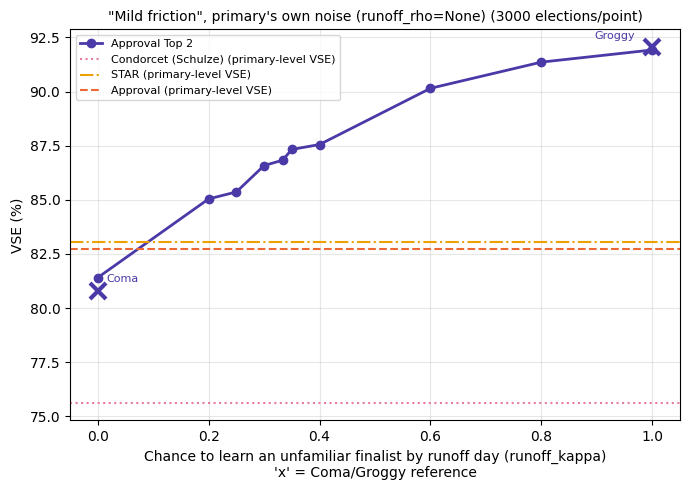

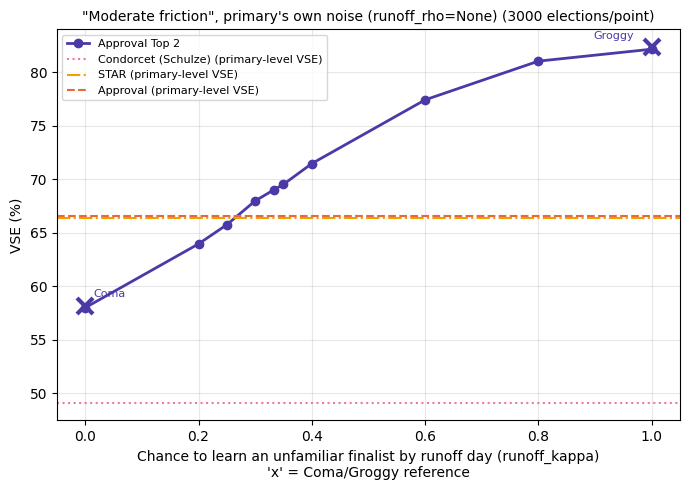

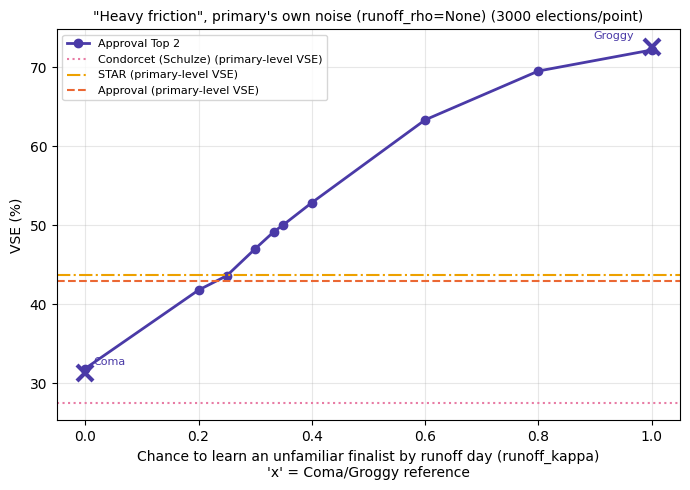

In [126]:
_variant_name = "primary's own noise (runoff_rho=None)"
_rt_fixed = RUNOFF_T_FIXED_VARIANTS[_variant_name]
for _baseline in RUNOFF_BASELINE_NAMES:
    fig, ax = plt.subplots(figsize=(7, 5))
    results_by_kappa = learn_sweep_results[_baseline][_variant_name]
    kappa_values = sorted(results_by_kappa)
    for label in RUNOFF_LEARN_METHOD_FACTORIES:
        color = METHOD_COLORS[label]
        style = METHOD_LINESTYLES.get(label, "-")
        vses = [results_by_kappa[kappa][(label, "honBallot")][0] * 100 for kappa in kappa_values]
        ax.plot(kappa_values, vses, marker="o", markersize=6, linewidth=2, color=color, linestyle=style, label=label)
        # kappa=0 is an EXACT match for "<label> (Coma)"; kappa=1 an EXACT match for plain
        # "<label>" (Groggy, the default) -- see RUNOFF_LEARN_METHOD_FACTORIES above.
        _coma_vse = joint_results[_baseline][(f"{label} (Coma)", "honBallot")][0] * 100
        ax.plot([0], [_coma_vse], marker="x", markersize=12, markeredgewidth=3, color=color, zorder=5)
        ax.annotate("Coma", (0, _coma_vse), textcoords="offset points", xytext=(6, 6), fontsize=8, color=color)
        _groggy_vse = joint_results[_baseline][(label, "honBallot")][0] * 100
        ax.plot([1], [_groggy_vse], marker="x", markersize=12, markeredgewidth=3, color=color, zorder=5)
        ax.annotate("Groggy", (1, _groggy_vse), textcoords="offset points", xytext=(-42, 6), fontsize=8, color=color)
    for _ref_label, _ref_style in [("Condorcet (Schulze)", ":"), ("STAR", "-."), ("Approval", "--")]:
        _ref_vse = joint_results[_baseline][(_ref_label, "honBallot")][0] * 100
        ax.axhline(_ref_vse, color=METHOD_COLORS[_ref_label], linewidth=1.5, linestyle=_ref_style,
                   label=f"{_ref_label} (primary-level VSE)")
    ax.set_xlabel("Chance to learn an unfamiliar finalist by runoff day (runoff_kappa)\n'x' = Coma/Groggy reference")
    ax.set_ylabel("VSE (%)")
    ax.set_title(f'"{_baseline}", {_variant_name} ({RUNOFF_SWEEP_NITER} elections/point)', fontsize=10)
    ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [127]:
_variant_name = "primary's own noise (runoff_rho=None)"
display(Markdown("### kappa threshold for AT2 VSE > STAR VSE (95% confidence, paired)\n"))
for _baseline in RUNOFF_BASELINE_NAMES:
    results_by_kappa = learn_sweep_results[_baseline][_variant_name]
    paired_diff_by_kappa = learn_sweep_paired_diff[_baseline][_variant_name]
    star_mean, star_ci = learn_sweep_baseline[_baseline][_variant_name]
    kappa_values = sorted(results_by_kappa)

    lines = [
        f"#### {_baseline}",
        "",
        "| kappa | AT2 VSE (%) | STAR VSE (%) | Gap (pp, paired) | 95% CI (paired, pp) | AT2 > STAR? |",
        "|---|---|---|---|---|---|",
    ]
    threshold_kappa = None
    for kappa in kappa_values:
        at2_mean, _ = results_by_kappa[kappa][("Approval Top 2", "honBallot")]
        gap_mean, ci = paired_diff_by_kappa[kappa]
        gap, ci = gap_mean * 100, ci * 100
        _register_significance(f"kappa threshold: {_baseline}", f"kappa={kappa:.2f}", gap, ci, "Approval Top 2", "STAR", spotlight=True)
        sig = "Yes" if gap - ci > 0 else ("No" if gap + ci < 0 else "No (CI contains 0)")
        if sig == "Yes" and threshold_kappa is None:
            threshold_kappa = kappa
        lines.append(
            f"| {kappa:.2f} | {at2_mean*100:.1f} | {star_mean*100:.1f} (+/-{star_ci*100:.1f}) | "
            f"{gap:+.1f} | [{gap-ci:+.1f}, {gap+ci:+.1f}] | {sig} |"
        )
    display(Markdown("\n".join(lines)))
    if threshold_kappa is not None:
        display(Markdown(
            f"**-> First kappa where AT2 is significantly better than STAR (95% CI gap > 0): `kappa ~ {threshold_kappa:.2f}`**\n"
        ))
    else:
        display(Markdown("**-> AT2 does not significantly exceed STAR at any tested kappa value.**\n"))

### kappa threshold for AT2 VSE > STAR VSE (95% confidence, paired)


#### Mild friction

| kappa | AT2 VSE (%) | STAR VSE (%) | Gap (pp, paired) | 95% CI (paired, pp) | AT2 > STAR? |
|---|---|---|---|---|---|
| 0.00 | 81.4 | 84.0 (+/-1.0) | -2.6 | [-3.4, -1.8] | No |
| 0.20 | 85.0 | 84.0 (+/-1.0) | +1.0 | [+0.3, +1.8] | Yes |
| 0.25 | 85.4 | 84.0 (+/-1.0) | +1.4 | [+0.6, +2.1] | Yes |
| 0.30 | 86.6 | 84.0 (+/-1.0) | +2.6 | [+1.9, +3.3] | Yes |
| 0.33 | 86.8 | 84.0 (+/-1.0) | +2.8 | [+2.1, +3.6] | Yes |
| 0.35 | 87.3 | 84.0 (+/-1.0) | +3.3 | [+2.6, +4.1] | Yes |
| 0.40 | 87.6 | 84.0 (+/-1.0) | +3.6 | [+2.8, +4.3] | Yes |
| 0.60 | 90.2 | 84.0 (+/-1.0) | +6.1 | [+5.3, +7.0] | Yes |
| 0.80 | 91.4 | 84.0 (+/-1.0) | +7.4 | [+6.6, +8.2] | Yes |
| 1.00 | 91.9 | 84.0 (+/-1.0) | +7.9 | [+7.1, +8.8] | Yes |

**-> First kappa where AT2 is significantly better than STAR (95% CI gap > 0): `kappa ~ 0.20`**


#### Moderate friction

| kappa | AT2 VSE (%) | STAR VSE (%) | Gap (pp, paired) | 95% CI (paired, pp) | AT2 > STAR? |
|---|---|---|---|---|---|
| 0.00 | 58.0 | 66.8 (+/-1.6) | -8.8 | [-10.2, -7.4] | No |
| 0.20 | 64.0 | 66.8 (+/-1.6) | -2.8 | [-4.0, -1.6] | No |
| 0.25 | 65.8 | 66.8 (+/-1.6) | -1.0 | [-2.2, +0.2] | No (CI contains 0) |
| 0.30 | 68.0 | 66.8 (+/-1.6) | +1.2 | [+0.1, +2.3] | Yes |
| 0.33 | 69.0 | 66.8 (+/-1.6) | +2.3 | [+1.1, +3.4] | Yes |
| 0.35 | 69.5 | 66.8 (+/-1.6) | +2.8 | [+1.6, +3.9] | Yes |
| 0.40 | 71.5 | 66.8 (+/-1.6) | +4.7 | [+3.6, +5.8] | Yes |
| 0.60 | 77.4 | 66.8 (+/-1.6) | +10.7 | [+9.4, +11.9] | Yes |
| 0.80 | 81.1 | 66.8 (+/-1.6) | +14.3 | [+12.9, +15.6] | Yes |
| 1.00 | 82.2 | 66.8 (+/-1.6) | +15.4 | [+14.1, +16.7] | Yes |

**-> First kappa where AT2 is significantly better than STAR (95% CI gap > 0): `kappa ~ 0.30`**


#### Heavy friction

| kappa | AT2 VSE (%) | STAR VSE (%) | Gap (pp, paired) | 95% CI (paired, pp) | AT2 > STAR? |
|---|---|---|---|---|---|
| 0.00 | 31.8 | 43.1 (+/-2.4) | -11.3 | [-13.0, -9.5] | No |
| 0.20 | 41.8 | 43.1 (+/-2.4) | -1.3 | [-2.8, +0.1] | No (CI contains 0) |
| 0.25 | 43.6 | 43.1 (+/-2.4) | +0.5 | [-0.9, +1.9] | No (CI contains 0) |
| 0.30 | 47.0 | 43.1 (+/-2.4) | +3.9 | [+2.4, +5.4] | Yes |
| 0.33 | 49.2 | 43.1 (+/-2.4) | +6.1 | [+4.5, +7.6] | Yes |
| 0.35 | 50.0 | 43.1 (+/-2.4) | +6.9 | [+5.4, +8.5] | Yes |
| 0.40 | 52.8 | 43.1 (+/-2.4) | +9.7 | [+8.1, +11.4] | Yes |
| 0.60 | 63.3 | 43.1 (+/-2.4) | +20.2 | [+18.3, +22.1] | Yes |
| 0.80 | 69.5 | 43.1 (+/-2.4) | +26.4 | [+24.4, +28.4] | Yes |
| 1.00 | 72.2 | 43.1 (+/-2.4) | +29.1 | [+27.0, +31.1] | Yes |

**-> First kappa where AT2 is significantly better than STAR (95% CI gap > 0): `kappa ~ 0.30`**


The following plots don't really capture a sweep between runoff models, but we measure the difference when noise or awareness is fixed, and we vary the other. Since neither variant brackets a named model, both sweeps are rerun separately here at a much smaller `SECONDARY_SWEEP_NITER` (100 elections/point, vs. the main sections' 2000) rather than paying full precision for a curiosity.

In [128]:
# Adjust SECONDARY_SWEEP_NITER for this cell in Section 5 (Parameters).
SKIP_CELL = True
if not SKIP_CELL: 
    _secondary_awareness_mode = {"Awareness carries over from primary": RUNOFF_AWARENESS_MODES["Awareness carries over from primary"]}
    _secondary_learn_variant = {"perfect runoff information (runoff_rho=1.0)": RUNOFF_T_FIXED_VARIANTS["perfect runoff information (runoff_rho=1.0)"]}

    secondary_runoff_sweep_results = {}  # {baseline: {"Awareness carries over from primary": {runoff_rho: {(label, chooser): (mean, ci)}}}}
    secondary_learn_sweep_results = {}  # {baseline: {"perfect runoff information (runoff_rho=1.0)": {kappa: {(label, chooser): (mean, ci)}}}}
    for _baseline in RUNOFF_BASELINE_NAMES:
        _primary_params = JOINT_SCENARIOS[_baseline]
        _primary_aw = _primary_params["awareness_alpha"]
        _secondary_electorates = RUNOFF_ELECTORATE_POOLS[_baseline][:SECONDARY_SWEEP_NITER]
        _awareness_fns = {
            mode_name: (lambda rt, _fn=fn: _fn(rt, _primary_aw))
            for mode_name, fn in _secondary_awareness_mode.items()
        }
        print(f"{_baseline} (secondary, runoff_rho sweep):")
        secondary_runoff_sweep_results[_baseline] = sweep_runoff_t(
            RUNOFF_METHOD_FACTORIES, RUNOFF_T_VALUES_BY_BASELINE[_baseline],
            _primary_params, SECONDARY_SWEEP_NITER, _awareness_fns,
            electorates=_secondary_electorates,
        )
        secondary_learn_sweep_results[_baseline] = {}
        for _variant_name, _rt_fixed in _secondary_learn_variant.items():
            print(f"{_baseline} (secondary, learn sweep), {_variant_name}:")
            secondary_learn_sweep_results[_baseline][_variant_name], _, _ = sweep_runoff_learn(
                RUNOFF_LEARN_METHOD_FACTORIES, RUNOFF_KAPPA_VALUES,
                _primary_params, SECONDARY_SWEEP_NITER, _rt_fixed,
                electorates=_secondary_electorates,
            )

In [129]:
if not SKIP_CELL:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

    # Row A: same runoff_rho sweep as the Groggy -> Clear-Eyed chart above, but awareness carries over
    # from the primary instead of resetting to 1.0. Neither endpoint matches a named model here
    # (runoff_awareness_alpha=primary_aw throughout, not 1.0) -- no Groggy/Clear-Eyed anchor to mark.
    _mode_name = "Awareness carries over from primary"
    for col_i, _baseline in enumerate(RUNOFF_BASELINE_NAMES):
        ax = axes[0, col_i]
        results_by_rt = secondary_runoff_sweep_results[_baseline][_mode_name]
        rho_numeric = sorted(rt for rt in results_by_rt if rt is not None)
        _baseline_rho = JOINT_SCENARIOS[_baseline]["epistemic_rho"]
        for label in RUNOFF_METHOD_FACTORIES:
            color = METHOD_COLORS[label]
            style = METHOD_LINESTYLES.get(label, "-")
            vses = [results_by_rt[rt][(label, "honBallot")][0] * 100 for rt in rho_numeric]
            ax.plot(rho_numeric, vses, marker="o", markersize=6, linewidth=2, color=color, linestyle=style, label=label)
        for _ref_label, _ref_style in [("Condorcet (Schulze)", ":"), ("STAR", "-.")]:
            _ref_vse = joint_results[_baseline][(_ref_label, "honBallot")][0] * 100
            ax.axhline(_ref_vse, color=METHOD_COLORS[_ref_label], linewidth=1.5, linestyle=_ref_style,
                    label=f"{_ref_label} (primary-level VSE)")
        ax.axvline(_baseline_rho, color="gray", linewidth=0.75, alpha=0.4, linestyle=":")
        ax.set_xticks(rho_numeric)
        ax.set_xticklabels([f"{rho:.2f}" for rho in rho_numeric])
        ax.set_xlabel("Runoff epistemic knowledge (runoff_rho)")
        ax.set_title(f'"{_baseline}", awareness carries over from primary', fontsize=10)
        ax.grid(True, alpha=0.3)
    axes[0, 0].set_ylabel("VSE (%)")

    # Row B: same runoff_kappa sweep as the Coma -> Groggy chart above, but with runoff_rho fixed at
    # 1.0 (perfect epistemic information) instead of None. Only the kappa=1 endpoint matches a named
    # model (Clear-Eyed) -- there's no independent reference at kappa=0 for this branch.
    _variant_name = "perfect runoff information (runoff_rho=1.0)"
    for col_i, _baseline in enumerate(RUNOFF_BASELINE_NAMES):
        ax = axes[1, col_i]
        results_by_kappa = secondary_learn_sweep_results[_baseline][_variant_name]
        kappa_values = sorted(results_by_kappa)
        for label in RUNOFF_LEARN_METHOD_FACTORIES:
            color = METHOD_COLORS[label]
            style = METHOD_LINESTYLES.get(label, "-")
            vses = [results_by_kappa[kappa][(label, "honBallot")][0] * 100 for kappa in kappa_values]
            ax.plot(kappa_values, vses, marker="o", markersize=6, linewidth=2, color=color, linestyle=style, label=label)
            _clear_eyed_vse = joint_results[_baseline][(f"{label} (Clear-Eyed)", "honBallot")][0] * 100
            ax.plot([1], [_clear_eyed_vse], marker="x", markersize=12, markeredgewidth=3, color=color, zorder=5)
            ax.annotate("Clear-Eyed", (1, _clear_eyed_vse), textcoords="offset points", xytext=(-60, 6), fontsize=8, color=color)
        for _ref_label, _ref_style in [("Condorcet (Schulze)", ":"), ("STAR", "-.")]:
            _ref_vse = joint_results[_baseline][(_ref_label, "honBallot")][0] * 100
            ax.axhline(_ref_vse, color=METHOD_COLORS[_ref_label], linewidth=1.5, linestyle=_ref_style,
                    label=f"{_ref_label} (primary-level VSE)")
        ax.set_xlabel("Chance to learn an unfamiliar finalist by runoff day (runoff_kappa)")
        ax.set_title(f'"{_baseline}", perfect runoff information (runoff_rho=1.0)', fontsize=10)
        ax.grid(True, alpha=0.3)
    axes[1, 0].set_ylabel("VSE (%)")

    handles, labels_ = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", fontsize=9, ncol=3, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(f"Secondary Section 21 sweeps: variants that don't bracket a single named model ({SECONDARY_SWEEP_NITER} elections/point)")
    plt.tight_layout()
    plt.show()

In [130]:
for _baseline in RUNOFF_BASELINE_NAMES:
    for _variant_name in learn_sweep_results[_baseline]:
        display(Markdown(f"#### {_baseline}, runoff learning swept, {_variant_name}: VSE by runoff_kappa (honest ballots)"))
        results_by_kappa = learn_sweep_results[_baseline][_variant_name]
        kappa_values = sorted(results_by_kappa)
        header = ["Method"] + [f"kappa={kappa:.2f}" for kappa in kappa_values]
        lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
        for label in RUNOFF_LEARN_METHOD_FACTORIES:
            row = [label]
            for kappa in kappa_values:
                mean_, ci = results_by_kappa[kappa][(label, "honBallot")]
                row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
            lines.append("| " + " | ".join(row) + " |")
        display(Markdown("\n".join(lines)))

#### Mild friction, runoff learning swept, primary's own noise (runoff_rho=None): VSE by runoff_kappa (honest ballots)

| Method | kappa=0.00 | kappa=0.20 | kappa=0.25 | kappa=0.30 | kappa=0.33 | kappa=0.35 | kappa=0.40 | kappa=0.60 | kappa=0.80 | kappa=1.00 |
|---|---|---|---|---|---|---|---|---|---|---|
| Approval Top 2 | 81.4% (+/-1.1) | 85.0% (+/-1.0) | 85.4% (+/-1.0) | 86.6% (+/-0.9) | 86.8% (+/-0.9) | 87.3% (+/-0.9) | 87.6% (+/-0.9) | 90.2% (+/-0.7) | 91.4% (+/-0.7) | 91.9% (+/-0.7) |

#### Moderate friction, runoff learning swept, primary's own noise (runoff_rho=None): VSE by runoff_kappa (honest ballots)

| Method | kappa=0.00 | kappa=0.20 | kappa=0.25 | kappa=0.30 | kappa=0.33 | kappa=0.35 | kappa=0.40 | kappa=0.60 | kappa=0.80 | kappa=1.00 |
|---|---|---|---|---|---|---|---|---|---|---|
| Approval Top 2 | 58.0% (+/-1.9) | 64.0% (+/-1.8) | 65.8% (+/-1.7) | 68.0% (+/-1.6) | 69.0% (+/-1.6) | 69.5% (+/-1.6) | 71.5% (+/-1.5) | 77.4% (+/-1.2) | 81.1% (+/-1.1) | 82.2% (+/-1.0) |

#### Heavy friction, runoff learning swept, primary's own noise (runoff_rho=None): VSE by runoff_kappa (honest ballots)

| Method | kappa=0.00 | kappa=0.20 | kappa=0.25 | kappa=0.30 | kappa=0.33 | kappa=0.35 | kappa=0.40 | kappa=0.60 | kappa=0.80 | kappa=1.00 |
|---|---|---|---|---|---|---|---|---|---|---|
| Approval Top 2 | 31.8% (+/-2.7) | 41.8% (+/-2.4) | 43.6% (+/-2.4) | 47.0% (+/-2.3) | 49.2% (+/-2.2) | 50.0% (+/-2.2) | 52.8% (+/-2.1) | 63.3% (+/-1.8) | 69.5% (+/-1.6) | 72.2% (+/-1.4) |

## 22. STAR vs. plain Score: isolating the runoff step's own effect

`Srv(STAR_TOP_RANK)` ("STAR") and `Score(STAR_TOP_RANK)` ("Score5") share IDENTICAL ballots --
`Srv0to` subclasses `Score0to` and never overrides `honBallot`, so both methods score the exact
same 0..5 ratings from the exact same voters (see Section 7's `METHODS` registration and Section
1's `Srv`/`Score` definitions). The ONLY difference between them is STAR's automatic pairwise
runoff between the top two. That makes any VSE gap between "STAR" and "Score5" a clean, direct
measurement of the runoff step's own net marginal effect.

The hypothesis under test: if the runoff step helps when ballots are honest and reasonably clean
(STAR > Score5), does that advantage shrink, vanish, or reverse (STAR < Score5) as `epistemic_rho`,
`awareness_alpha`, or `fatigue_beta` degrade the ballots the runoff has to work with? `Score5` is
already one of `COMPARE_LABELS` (Section 14), so this reuses that section's `compare_by_param`
(individual-parameter sweeps, `SWEEP_NITER=250`) and `joint_results` (the four friction scenarios,
`JOINT_NITER=3000`) directly.

#### STAR vs. Score5 by `epistemic_rho`

| Method | epistemic_rho=0.00 | epistemic_rho=0.30 | epistemic_rho=0.50 | epistemic_rho=0.70 | epistemic_rho=0.85 | epistemic_rho=1.00 |
|---|---|---|---|---|---|---|
| Score5 | -0.6% (+/-11.8) | 83.9% (+/-3.0) | 90.9% (+/-2.1) | 93.6% (+/-1.4) | 95.4% (+/-1.2) | 95.9% (+/-0.4) |
| STAR | 1.3% (+/-11.6) | 82.5% (+/-3.2) | 88.4% (+/-2.5) | 94.6% (+/-1.2) | 95.8% (+/-1.1) | 97.5% (+/-0.3) |

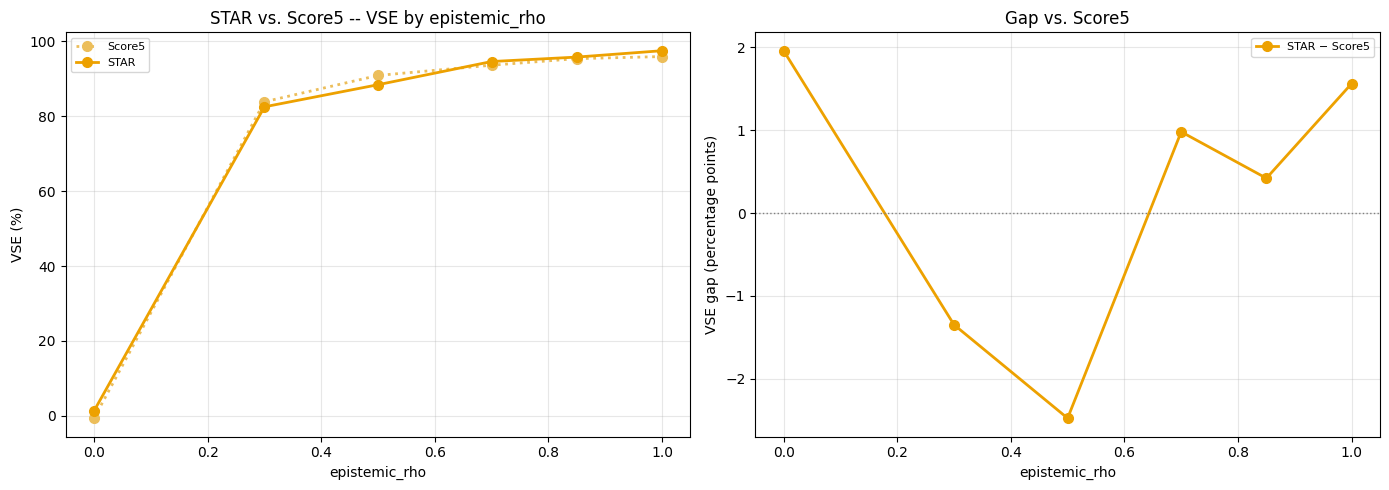

#### STAR vs. Score5 by `awareness_alpha`

| Method | awareness_alpha=0.00 | awareness_alpha=0.30 | awareness_alpha=0.50 | awareness_alpha=0.70 | awareness_alpha=0.85 | awareness_alpha=1.00 |
|---|---|---|---|---|---|---|
| Score5 | 4.4% (+/-11.9) | -7.4% (+/-12.2) | -0.4% (+/-11.0) | 58.5% (+/-5.7) | 76.8% (+/-3.7) | 95.9% (+/-0.4) |
| STAR | 4.4% (+/-11.9) | -7.4% (+/-12.2) | 2.1% (+/-10.8) | 59.4% (+/-5.6) | 80.5% (+/-3.3) | 97.5% (+/-0.3) |

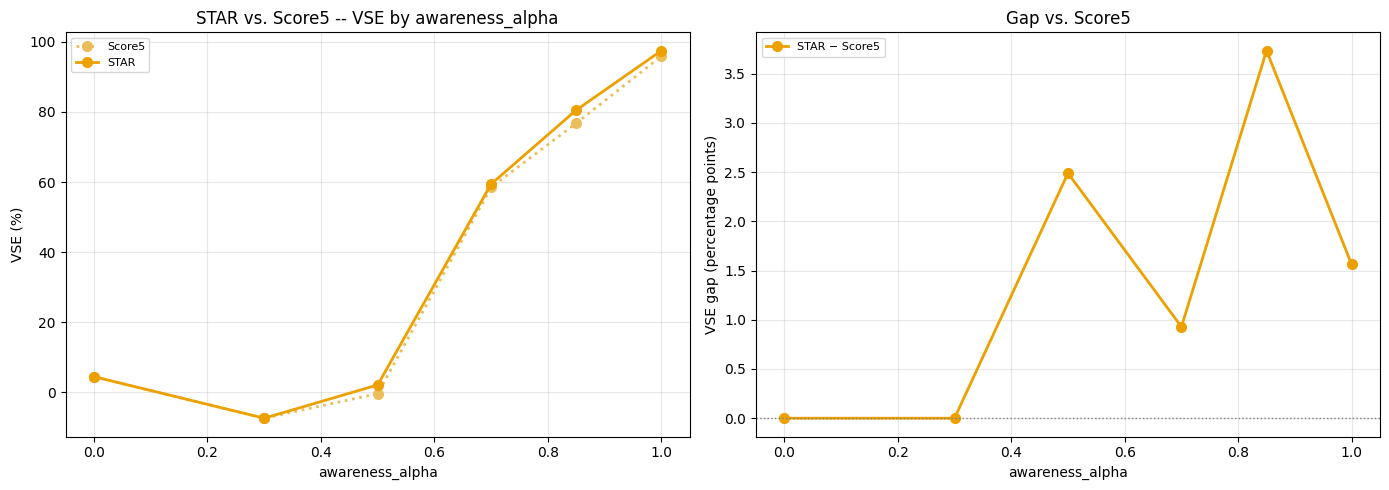

#### STAR vs. Score5 by `fatigue_beta`

| Method | fatigue_beta=0.00 | fatigue_beta=0.30 | fatigue_beta=0.50 | fatigue_beta=0.70 | fatigue_beta=0.85 | fatigue_beta=1.00 |
|---|---|---|---|---|---|---|
| Score5 | 63.7% (+/-7.5) | 70.7% (+/-6.5) | 75.7% (+/-5.9) | 85.2% (+/-4.5) | 95.2% (+/-1.6) | 95.9% (+/-0.4) |
| STAR | 63.7% (+/-7.4) | 70.6% (+/-6.6) | 75.7% (+/-5.9) | 85.9% (+/-4.4) | 95.7% (+/-1.5) | 97.5% (+/-0.3) |

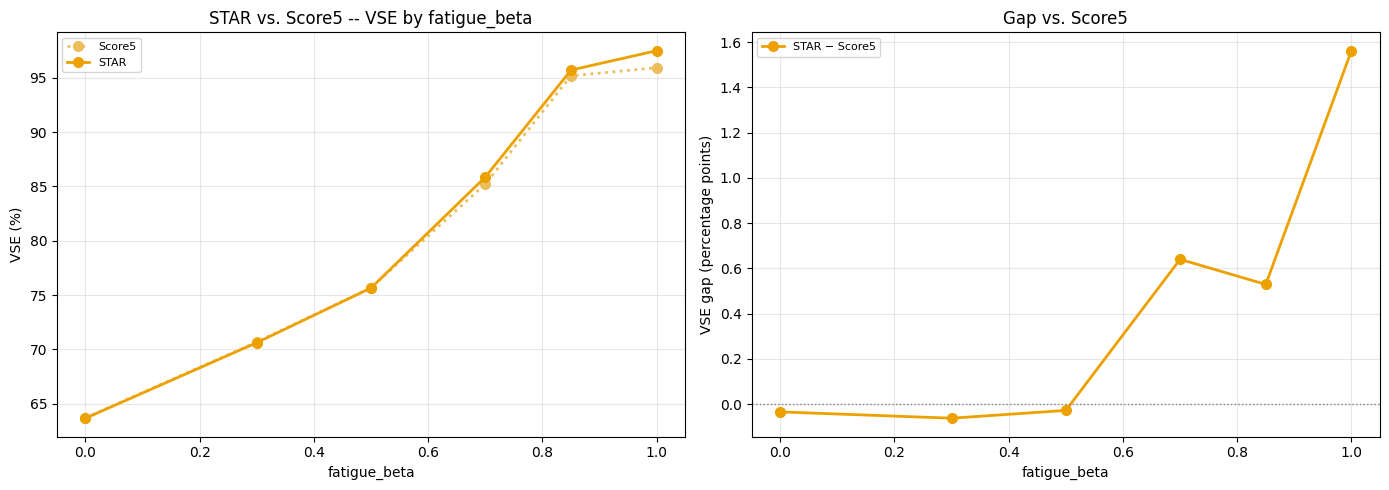

In [131]:
STAR_SCORE_LABELS = ["Score5", "STAR"]

for _param in ["epistemic_rho", "awareness_alpha", "fatigue_beta"]:
    display(Markdown(f"#### STAR vs. Score5 by `{_param}`"))
    comparison_table(compare_by_param[_param], STAR_SCORE_LABELS, _param)
    comparison_chart(compare_by_param[_param], STAR_SCORE_LABELS, _param, baseline_label="Score5",
                      title=f"STAR vs. Score5 -- VSE by {_param}")


| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Score5 | 95.9% (+/-0.4) | 81.9% (+/-0.7) | 65.2% (+/-1.2) | 42.5% (+/-1.7) |
| STAR | 97.5% (+/-0.3) | 83.1% (+/-0.7) | 66.3% (+/-1.1) | 43.7% (+/-1.7) |

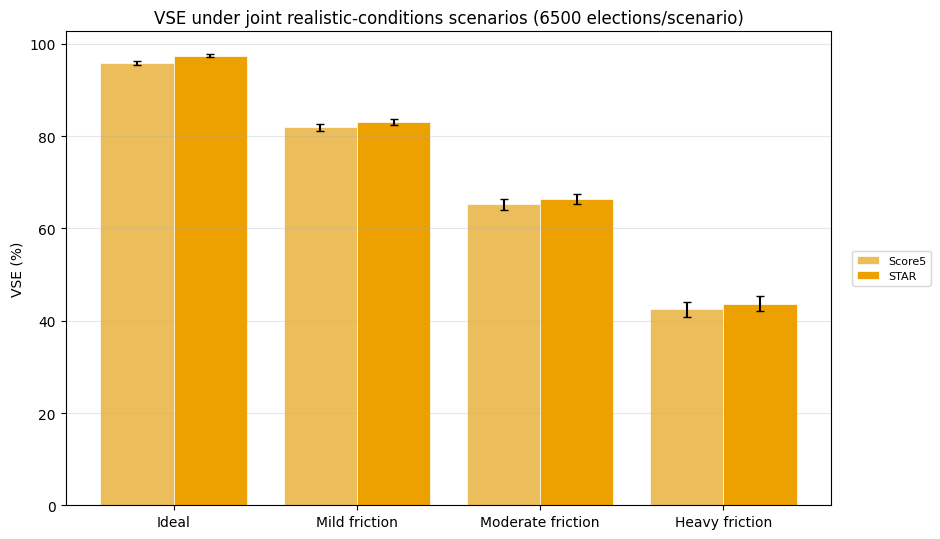

#### Score5 vs STAR: paired VSE gap by joint-friction scenario

| Scenario | Score VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 95.9 | 97.5 | -1.6 | [-1.9, -1.2] | Yes (STAR better) |
| Mild friction | 81.9 | 83.1 | -1.1 | [-1.6, -0.7] | Yes (STAR better) |
| Moderate friction | 65.2 | 66.3 | -1.1 | [-1.6, -0.7] | Yes (STAR better) |
| Heavy friction | 42.5 | 43.7 | -1.2 | [-1.7, -0.8] | Yes (STAR better) |

In [132]:
# Score5 and STAR
score5_star_labels = ["Score5", "STAR"]
scenario_table_and_plot(score5_star_labels)
display_paired_gap_table("Score5", "STAR", label_short="Score", baseline_short="STAR")

## 23. Per-election "runoff betrayal" diagnostic

**This measures something different from Section 22, not the same thing on a different scale.**
Section 22 asks whether STAR's runoff changes the winner away from Score5's raw top-score pick at
all -- it rarely does, so that aggregate gap is a wash. This section asks a broader question:
independent of whether the runoff visibly changes anything, does the pairwise decision it actually
makes for this specific pair of finalists agree with what the SAME voters' honest, uncorrupted
preferences would have decided? That also catches cases where the runoff keeps Score5's raw pick,
but that shared pick is itself wrong relative to honest preferences -- and it turns out to be
violated far more often than the runoff visibly flips anything, as the flip-rate section below
shows.

`voter_corruption_rate` is the more granular signal: among individual voters with a genuine
(nonzero) honest preference between the two finalists, how often does their ACTUAL (noisy/
friction-affected) ballot disagree in sign with it. `betrayal_rate` aggregates this to the level of
the runoff DECISION itself: among elections where both the actual and honest signals are decisive,
how often does STAR's automatic runoff produce the OPPOSITE outcome from what a perfectly-informed,
delayed runoff would have produced for that same pair.

The table reports three VSE numbers on the same 0-100(ish) scale as everywhere else in this
notebook: **VSE (STAR's actual runoff)** is STAR's already-known aggregate VSE at that scenario;
**VSE (honest/delayed-perfect runoff)** is the counterfactual if this specific runoff pair had
always used honest preferences instead; and **VSE (AT2 Clear-Eyed runoff)** is "Approval Top 2
(Clear-Eyed)"'s own aggregate VSE at the same scenario -- a real method combining a coarser
Approval primary with a perfect delayed runoff, for direct comparison.

This diagnostic (folded into `run_vse_simulation`'s `betrayal_targets` accumulator -- Section 8)
compares the pairwise upset sign from actual (noisy/friction-affected) ballots against the SAME
sign computed from HONEST ballots on the TRUE electorate -- both cast the same way (same
`honBallot` floor-to-`0..topRank` discretization), rather than against raw continuous utilities,
so a small honest margin that floors to a tie doesn't get counted as noise's fault.

### Does the runoff help or hurt, relative to no runoff at all?

Before digging into STAR's own automatic-runoff betrayal rate below, a more basic question: for
Approval Top 2 and Plurality Top 2, does adding a delayed runoff on top of the base (non-runoff)
method actually help, across each of the three runoff-information assumptions? Reads directly off
the main joint-scenario run (Section 16) -- `Approval Top 2 (Coma/Groggy/Clear-Eyed)` and
`Plurality Top 2 (Groggy/Clear-Eyed)` are each paired against their own family's base method
(`Approval`/`Plurality`), same paired-CI/significance convention as every other gap table in this
notebook.

In [133]:
def display_paired_gap_matrix(labels, baseline_label, title=None, sort_desc=True):
    """Same layout as Section 19's CE-gap-vs-Schulze tables: one table per _scenario_names
    scenario, every label in `labels` as a row (sorted by gap) vs the SAME baseline_label. Reads
    joint_results/paired_diff_by_scenario (already computed by the main joint-scenario run) -- no
    new simulation. Every (label, baseline_label) pair must already be in _paired_diff_pairs
    (cell defining it, Section 16) with the main run re-executed since."""
    title = title or f"{baseline_label} vs {', '.join(labels)}"
    missing = [
        (name, label) for name in _scenario_names for label in labels
        if (label, baseline_label) not in paired_diff_by_scenario.get(name, {})
    ]
    if missing:
        raise KeyError(
            f"missing pairs in paired_diff_by_scenario: {missing} -- add (label, {baseline_label!r}) "
            "to _paired_diff_pairs and re-run the main joint-scenario cell first."
        )
    lines = [f"### {title}", ""]
    for name in _scenario_names:
        baseline_vse = joint_results[name][(baseline_label, "honBallot")][0] * 100
        sorted_labels = sorted(
            labels, reverse=sort_desc,
            key=lambda l: paired_diff_by_scenario[name][(l, baseline_label)][0],
        )
        lines += [
            f"#### {name}", "",
            f"| Method | {baseline_label} VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |",
            "|---|---|---|---|---|---|",
        ]
        for label in sorted_labels:
            if name == "Ideal" and ('Coma' in label or 'Clear-Eyed' in label):
                continue
            label_vse = joint_results[name][(label, "honBallot")][0] * 100
            gap, ci = paired_diff_by_scenario[name][(label, baseline_label)]
            sig = "Yes" if gap - ci > 0 or gap + ci < 0 else ""
            if sig == "Yes":
                sig += " (runoff better)" if gap > 0 else " (runoff **worse**)"
            gap *= 100
            ci *= 100
            lines.append(f"| {label} | {baseline_vse:.1f} | {label_vse:.1f} | {gap:+.1f} | [{gap-ci:+.1f}, {gap+ci:+.1f}] | {sig or 'No (CI contains 0)'} |")
        lines.append("")
    display(Markdown("\n".join(lines)))

In [134]:
display_paired_gap_matrix(
    ["Approval Top 2 (Coma)", "Approval Top 2", "Approval Top 2 (Clear-Eyed)"], "Approval",
    title="Does the runoff help or hurt Approval?",
)
display_paired_gap_matrix(
    ["Plurality Top 2", "Plurality Top 2 (Clear-Eyed)"], "Plurality",
    title="Does the runoff help or hurt Plurality?",
)

### Does the runoff help or hurt Approval?

#### Ideal

| Method | Approval VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Approval Top 2 | 89.2 | 95.6 | +6.4 | [+5.7, +7.2] | Yes (runoff better) |

#### Mild friction

| Method | Approval VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Approval Top 2 (Clear-Eyed) | 82.7 | 92.9 | +10.2 | [+9.6, +10.8] | Yes (runoff better) |
| Approval Top 2 | 82.7 | 92.1 | +9.3 | [+8.7, +9.9] | Yes (runoff better) |
| Approval Top 2 (Coma) | 82.7 | 80.8 | -1.9 | [-2.5, -1.3] | Yes (runoff **worse**) |

#### Moderate friction

| Method | Approval VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Approval Top 2 (Clear-Eyed) | 66.5 | 83.6 | +17.1 | [+16.2, +18.0] | Yes (runoff better) |
| Approval Top 2 | 66.5 | 82.4 | +15.8 | [+14.9, +16.8] | Yes (runoff better) |
| Approval Top 2 (Coma) | 66.5 | 58.2 | -8.3 | [-9.3, -7.4] | Yes (runoff **worse**) |

#### Heavy friction

| Method | Approval VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Approval Top 2 (Clear-Eyed) | 42.9 | 75.1 | +32.2 | [+30.8, +33.6] | Yes (runoff better) |
| Approval Top 2 | 42.9 | 72.5 | +29.7 | [+28.2, +31.2] | Yes (runoff better) |
| Approval Top 2 (Coma) | 42.9 | 31.3 | -11.6 | [-12.8, -10.4] | Yes (runoff **worse**) |


### Does the runoff help or hurt Plurality?

#### Ideal

| Method | Plurality VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Plurality Top 2 | 61.6 | 83.6 | +22.0 | [+19.7, +24.3] | Yes (runoff better) |

#### Mild friction

| Method | Plurality VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Plurality Top 2 (Clear-Eyed) | 69.1 | 88.9 | +19.8 | [+18.5, +21.1] | Yes (runoff better) |
| Plurality Top 2 | 69.1 | 88.3 | +19.3 | [+18.0, +20.6] | Yes (runoff better) |

#### Moderate friction

| Method | Plurality VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Plurality Top 2 (Clear-Eyed) | 62.1 | 83.5 | +21.3 | [+20.1, +22.5] | Yes (runoff better) |
| Plurality Top 2 | 62.1 | 82.1 | +19.9 | [+18.7, +21.1] | Yes (runoff better) |

#### Heavy friction

| Method | Plurality VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Plurality Top 2 (Clear-Eyed) | 41.5 | 74.9 | +33.4 | [+31.9, +34.9] | Yes (runoff better) |
| Plurality Top 2 | 41.5 | 72.3 | +30.8 | [+29.3, +32.3] | Yes (runoff better) |


### Sanity check, then: why does Coma underperform?

The table above shows Coma AT2 scoring *below* plain Approval -- before trusting an explanation
for that, a sanity check: Coma, Groggy (the default `Approval Top 2`), and Clear-Eyed all collapse
to the exact same code path at zero friction (`epistemic_rho=awareness_alpha=fatigue_beta=1.0` --
`_perceived_voters` equals true utilities and `aware_sets` covers everyone regardless of which
runoff mode is active). Their VSE at Ideal must therefore be bit-for-bit identical; a mismatch
would mean a real implementation bug, not a friction effect.

In [135]:
_coma_ideal = results[("Approval Top 2 (Coma)", "honBallot")]
_groggy_ideal = results[("Approval Top 2", "honBallot")]
_ce_ideal = results[("Approval Top 2 (Clear-Eyed)", "honBallot")]
_sanity_ok = _coma_ideal == _groggy_ideal == _ce_ideal
display(Markdown(
    f"**Sanity check -- Coma/Groggy/Clear-Eyed AT2 at Ideal (should be identical):** "
    f"Coma={_coma_ideal[0]*100:.4f}%, Groggy={_groggy_ideal[0]*100:.4f}%, "
    f"Clear-Eyed={_ce_ideal[0]*100:.4f}% -- "
    + ("**MATCH** (no implementation bug at this boundary)." if _sanity_ok
       else "**MISMATCH -- this is a real bug, investigate before trusting the decomposition below.**")
))
assert _sanity_ok, "Coma/Groggy/Clear-Eyed AT2 must be identical at Ideal (same code path) -- mismatch means a bug, not friction."

**Sanity check -- Coma/Groggy/Clear-Eyed AT2 at Ideal (should be identical):** Coma=95.5905%, Groggy=95.5905%, Clear-Eyed=95.5905% -- **MATCH** (no implementation bug at this boundary).

In [136]:
# Reads the Coma-corruption accumulator folded into the main joint-scenario run above (Section
# 16, betrayal_targets/coma_targets on run_vse_simulation) instead of re-simulating its own
# separate AT2_COMA_NITER-election batch per scenario.
at2_coma_stats_by_scenario = {
    name: reduce_coma_summary(joint_coma_by_scenario[name]["Approval Top 2 (Coma)"])
    for name in JOINT_SCENARIOS
}

In [137]:
_coma_lines = [
    "#### Coma AT2: why voters end up voting against their own pairwise interest",
    "",
    "| Scenario | Aligned | Awareness-attributable | Noise-unfixable (even if Groggy) |",
    "|---|---|---|---|",
]
for name, stats in at2_coma_stats_by_scenario.items():
    _coma_lines.append(
        f"| {name} | {stats['aligned'] * 100:.1f}% | {stats['awareness_attributable'] * 100:.1f}% | "
        f"{stats['noise_unfixable'] * 100:.1f}% |"
    )
display(Markdown("\n".join(_coma_lines)))

_coma_detail_lines = [
    "#### Coma AT2: detailed breakdown",
    "",
    "| Scenario | Wrong (awareness-fixable) | Wrong (noise-unfixable) | Abstained (awareness-fixable) | Abstained (noise-unfixable) |",
    "|---|---|---|---|---|",
]
for name, stats in at2_coma_stats_by_scenario.items():
    _coma_detail_lines.append(
        f"| {name} | {stats['wrong_awareness_fixable'] * 100:.1f}% | {stats['wrong_noise_unfixable'] * 100:.1f}% | "
        f"{stats['abstained_awareness_fixable'] * 100:.1f}% | {stats['abstained_noise_unfixable'] * 100:.1f}% |"
    )
display(Markdown("\n".join(_coma_detail_lines)))

#### Coma AT2: why voters end up voting against their own pairwise interest

| Scenario | Aligned | Awareness-attributable | Noise-unfixable (even if Groggy) |
|---|---|---|---|
| Ideal | 100.0% | 0.0% | 0.0% |
| Mild friction | 71.2% | 11.1% | 17.7% |
| Moderate friction | 65.8% | 14.8% | 19.4% |
| Heavy friction | 62.9% | 16.1% | 21.0% |

#### Coma AT2: detailed breakdown

| Scenario | Wrong (awareness-fixable) | Wrong (noise-unfixable) | Abstained (awareness-fixable) | Abstained (noise-unfixable) |
|---|---|---|---|---|
| Ideal | 0.0% | 0.0% | 0.0% | 0.0% |
| Mild friction | 10.0% | 17.4% | 1.1% | 0.3% |
| Moderate friction | 13.3% | 18.9% | 1.5% | 0.5% |
| Heavy friction | 15.3% | 20.7% | 0.8% | 0.3% |

In [138]:
_election_lines = [
    "#### Coma vs Groggy: election-level aggregate-sign accuracy (does the runoff decision match the true preference?)",
    "",
    "| Scenario | Coma correct | Groggy correct | Both correct | Coma-only correct | Groggy-only correct | Both wrong |",
    "|---|---|---|---|---|---|---|",
]
for name, stats in at2_coma_stats_by_scenario.items():
    _election_lines.append(
        f"| {name} | {stats['coma_accuracy_rate'] * 100:.1f}% | {stats['groggy_accuracy_rate'] * 100:.1f}% | "
        f"{stats['both_correct_rate'] * 100:.1f}% | {stats['coma_only_correct_rate'] * 100:.1f}% | "
        f"{stats['groggy_only_correct_rate'] * 100:.1f}% | {stats['both_wrong_rate'] * 100:.1f}% |"
    )
display(Markdown("\n".join(_election_lines)))
display(Markdown(
    "This is the metric that actually drives the VSE gap -- an election's outcome depends on the "
    "AGGREGATE runoff decision, not per-voter accuracy. \"Groggy-only correct\" is the direct "
    "empirical signature of the amplification: elections where fixing awareness alone flips the "
    "runoff's aggregate decision from wrong to right, even though the underlying per-voter fix "
    "(the `awareness_attributable` rate above) is comparatively modest."
))

#### Coma vs Groggy: election-level aggregate-sign accuracy (does the runoff decision match the true preference?)

| Scenario | Coma correct | Groggy correct | Both correct | Coma-only correct | Groggy-only correct | Both wrong |
|---|---|---|---|---|---|---|
| Ideal | 100.0% | 100.0% | 100.0% | 0.0% | 0.0% | 0.0% |
| Mild friction | 60.2% | 85.2% | 53.7% | 6.5% | 31.5% | 8.3% |
| Moderate friction | 51.2% | 85.4% | 43.6% | 7.6% | 41.8% | 7.0% |
| Heavy friction | 46.0% | 85.8% | 38.5% | 7.5% | 47.4% | 6.6% |

This is the metric that actually drives the VSE gap -- an election's outcome depends on the AGGREGATE runoff decision, not per-voter accuracy. "Groggy-only correct" is the direct empirical signature of the amplification: elections where fixing awareness alone flips the runoff's aggregate decision from wrong to right, even though the underlying per-voter fix (the `awareness_attributable` rate above) is comparatively modest.

In [139]:
# Reads the betrayal/flip accumulator folded into the main joint-scenario run above (Section 16,
# betrayal_targets on run_vse_simulation) instead of re-simulating its own separate
# BETRAYAL_NITER-election batch per scenario -- same JOINT_NITER-election precision as every
# other joint-scenario number in this notebook.
betrayal_by_scenario = {
    name: reduce_betrayal_summary(joint_betrayal_by_scenario[name]["STAR"])
    for name in JOINT_SCENARIOS
}

In [140]:
# Reads the betrayal accumulator folded into Section 13's epistemic_rho sweep (see cell 53) --
# these values must match SWEEP_VALUES there, since that's what actually populated
# epistemic_rho_betrayal_by_value; not re-simulated here.
_epistemic_only_values = [0.0, 0.3, 0.5, 0.7, 0.85, 1.0]
betrayal_by_epistemic_rho = {
    rho: reduce_betrayal_summary(epistemic_rho_betrayal_by_value[rho]["STAR"])
    for rho in _epistemic_only_values
}

In [141]:
def _betrayal_table(stats_by_key, key_header, star_vse_lookup, at2_vse_lookup, key_fmt=str):
    """star_vse_lookup(key) -> STAR's own already-computed honest-ballot VSE (a 0..1 fraction) at
    this scenario/epistemic_rho value, pulled from Sections 13/16 data -- not recomputed here. The
    "honest/delayed-perfect runoff" column is derived as actual + population_vse_cost, so the two
    VSE columns are guaranteed to differ by exactly the "VSE gap" column.

    at2_vse_lookup(key) -> "Approval Top 2 (Clear-Eyed)"'s already-computed honest-ballot
    VSE (a 0..1 fraction) at the SAME scenario/epistemic_rho value, also pulled from Sections 13/16
    data (COMPARE_LABELS/METHODS_NO_COMA already include it -- no new simulation). Placed next
    to STAR's own two VSE columns so a coarse (Approval) vs. fine-grained (0..5 Score) noisy
    primary ballot can be compared directly once BOTH have a perfect delayed runoff available to
    correct their pick -- STAR's "honest/delayed-perfect" column IS exactly that comparison for
    the Score primary, restricted to the decisive runoff pairs."""
    header = [key_header, "Betrayal rate", "Voter corruption rate",
              "VSE (STAR's actual runoff)", "VSE (honest/delayed-perfect runoff)",
              "VSE (AT2 Clear-Eyed runoff)"]
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    for key, stats in stats_by_key.items():
        n_dec = stats["n_decisive"]
        actual_vse = star_vse_lookup(key) * 100
        gap = stats["population_vse_cost"] * 100 if n_dec else 0.0
        honest_vse = actual_vse + gap
        at2_vse = at2_vse_lookup(key) * 100
        at2_star_gap = at2_vse - actual_vse
        lines.append("| " + " | ".join([
            key_fmt(key),
            f"{stats['betrayal_rate'] * 100:.1f}%" if n_dec else "n/a",
            f"{stats['voter_corruption_rate'] * 100:.2f}%",
            f"{actual_vse:.1f}%",
            f"{honest_vse:.1f}% ({gap:+.1f} pts over actual)" if n_dec else "n/a",
            #f"{gap:+.1f} pts" if n_dec else "n/a",
            f"{at2_vse:.1f}% ({at2_star_gap:+.1f} pts over STAR)" if n_dec else "n/a",
        ]) + " |")
    display(Markdown("\n".join(lines)))

In [142]:
display(Markdown("#### Runoff betrayal rate by joint-friction scenario"))
_betrayal_table(betrayal_by_scenario, "Scenario",
                 star_vse_lookup=lambda name: joint_results[name][("STAR", "honBallot")][0],
                 at2_vse_lookup=lambda name: joint_results[name][("Approval Top 2 (Clear-Eyed)", "honBallot")][0])

#### Runoff betrayal rate by joint-friction scenario

| Scenario | Betrayal rate | Voter corruption rate | VSE (STAR's actual runoff) | VSE (honest/delayed-perfect runoff) | VSE (AT2 Clear-Eyed runoff) |
|---|---|---|---|---|---|
| Ideal | 0.0% | 0.00% | 97.5% | 97.5% (+0.0 pts over actual) | 95.6% (-1.9 pts over STAR) |
| Mild friction | 33.8% | 35.68% | 83.1% | 90.7% (+7.7 pts over actual) | 92.9% (+9.8 pts over STAR) |
| Moderate friction | 39.0% | 45.56% | 66.3% | 82.1% (+15.7 pts over actual) | 83.6% (+17.3 pts over STAR) |
| Heavy friction | 44.8% | 49.26% | 43.7% | 71.4% (+27.7 pts over actual) | 75.1% (+31.4 pts over STAR) |

### Paired VSE gap: Score Top 2 (Clear-Eyed) vs Approval Top 2 (Clear-Eyed)

"Score Top 2 (Clear-Eyed)" (Section 6) is now a real registered method -- a Score(STAR_TOP_RANK)
primary with an idealized/delayed clear-eyed runoff, the Top2Base analogue of "Approval Top 2
(Clear-Eyed)" but with STAR's finer 0..5 ballot instead of Approval's 0/1 ballot. It rides the same
`_joint_electorate_pool` simulation pass as every other `COMPARE_LABELS` method (Section 16), so
this reads directly off `paired_diff_by_scenario` -- no separate re-simulation, unlike the old
bespoke "theoretical SCORE Top 2" computation this replaces. Directly answers whether a coarse
(Approval) ballot is actually more effective than a fine-grained (0..5 Score) ballot once both get
an idealized/delayed runoff to correct their pick.

In [143]:
display_paired_gap_table("Score Top 2 (Clear-Eyed)", "Approval Top 2 (Clear-Eyed)", label_short="Score Top 2", baseline_short="AT2")

#### Score Top 2 (Clear-Eyed) vs Approval Top 2 (Clear-Eyed): paired VSE gap by joint-friction scenario

| Scenario | Score Top 2 VSE (%) | AT2 VSE (%) | Gap vs AT2 (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 98.0 | 95.6 | +2.4 | [+2.0, +2.9] | Yes (Score Top 2 better) |
| Mild friction | 92.6 | 92.9 | -0.3 | [-0.6, -0.0] | Yes (AT2 better) |
| Moderate friction | 84.0 | 83.6 | +0.3 | [-0.0, +0.7] | No (CI contains 0) |
| Heavy friction | 75.1 | 75.1 | +0.1 | [-0.2, +0.4] | No (CI contains 0) |

In [144]:
display_paired_gap_table("Score Top 2 (Clear-Eyed)", "STAR", label_short="Score Top 2", baseline_short="STAR")

#### Score Top 2 (Clear-Eyed) vs STAR: paired VSE gap by joint-friction scenario

| Scenario | Score Top 2 VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 98.0 | 97.5 | +0.5 | [+0.3, +0.7] | Yes (Score Top 2 better) |
| Mild friction | 92.6 | 83.1 | +9.5 | [+8.9, +10.1] | Yes (Score Top 2 better) |
| Moderate friction | 84.0 | 66.3 | +17.6 | [+16.7, +18.5] | Yes (Score Top 2 better) |
| Heavy friction | 75.1 | 43.7 | +31.4 | [+30.0, +32.8] | Yes (Score Top 2 better) |

In [145]:
display(Markdown("#### Runoff betrayal rate by `epistemic_rho` alone (`awareness_alpha=fatigue_beta=1.0`)"))
_betrayal_table(betrayal_by_epistemic_rho, "epistemic_rho",
                 star_vse_lookup=lambda rho: sweep_results_by_param["epistemic_rho"][rho][("STAR", "honBallot")][0],
                 at2_vse_lookup=lambda rho: sweep_results_by_param["epistemic_rho"][rho][("Approval Top 2 (Clear-Eyed)", "honBallot")][0],
                 key_fmt=lambda rho: f"{rho:.2f}")

#### Runoff betrayal rate by `epistemic_rho` alone (`awareness_alpha=fatigue_beta=1.0`)

| epistemic_rho | Betrayal rate | Voter corruption rate | VSE (STAR's actual runoff) | VSE (honest/delayed-perfect runoff) | VSE (AT2 Clear-Eyed runoff) |
|---|---|---|---|---|---|
| 0.00 | 53.0% | 57.78% | 1.3% | 57.9% (+56.5 pts over actual) | 55.4% (+54.1 pts over STAR) |
| 0.30 | 40.4% | 49.36% | 82.5% | 91.6% (+9.1 pts over actual) | 89.8% (+7.3 pts over STAR) |
| 0.50 | 40.1% | 43.64% | 88.4% | 96.4% (+8.0 pts over actual) | 94.5% (+6.1 pts over STAR) |
| 0.70 | 30.6% | 36.52% | 94.6% | 97.1% (+2.5 pts over actual) | 95.9% (+1.3 pts over STAR) |
| 0.85 | 23.8% | 30.15% | 95.8% | 96.8% (+1.0 pts over actual) | 96.6% (+0.8 pts over STAR) |
| 1.00 | 0.0% | 0.00% | 97.5% | 97.5% (+0.0 pts over actual) | 95.6% (-1.9 pts over STAR) |

### Why does a near-zero aggregate gap coexist with a much higher betrayal rate? The flip rate.

Section 22's STAR-minus-Score5 gap is a wash because the runoff rarely changes the winner away
from Score5's naive top-score pick at all -- and when it does, roughly as many of those flips are
"good" (agree with what honest ballots would have decided) as "bad" (betrayals, per the diagnostic
above), canceling out in the aggregate VSE average. That cancellation is real, but it's the wrong
comfort for a one-shot election: it says the runoff's mistakes average out across many
*hypothetical* elections, not that any *given* election's flip is safe. The table below reports,
per scenario: how often the runoff changes the winner away from Score5's pick at all (the
"flip rate"), and -- of those flips -- what fraction are good vs. bad. This reuses the exact same
noisy/honest upset signs the betrayal diagnostic above already computed (see run_vse_simulation's
betrayal_targets docstring) -- just a different bucketing of the same per-election values, not a
separate computation.


In [146]:
# Flip stats are bucketed from the exact same noisy/honest upset signs the betrayal diagnostic
# above already computed, in the same run_vse_simulation pass -- reduce_betrayal_summary returns
# both sets of fields together, so this is literally the same reduced dict, not a new computation.
flip_by_scenario = betrayal_by_scenario

In [147]:
_flip_lines = ["#### Runoff flip rate by joint-friction scenario",
               "",
                "| Scenario | Flip rate (of all elections) | Good flips | Bad flips (betrayals) | Honest-tied |",
               "|---|---|---|---|---|"]
for name, stats in flip_by_scenario.items():
    _flip_lines.append(
        f"| {name} | {stats['flip_rate'] * 100:.1f}% ({stats['n_flips']}/{stats['n_elections']}) | "
        f"{stats['good_flip_rate'] * 100:.1f}% | "
        f"{stats['bad_flip_rate'] * 100:.1f}% | "
        f"{stats['n_honest_tied_flips']} |"
    )
display(Markdown("\n".join(_flip_lines)))

#### Runoff flip rate by joint-friction scenario

| Scenario | Flip rate (of all elections) | Good flips | Bad flips (betrayals) | Honest-tied |
|---|---|---|---|---|
| Ideal | 11.2% (225/2000) | 100.0% | 0.0% | 0 |
| Mild friction | 8.9% (580/6500) | 67.2% | 30.9% | 11 |
| Moderate friction | 4.0% (262/6500) | 67.9% | 30.5% | 4 |
| Heavy friction | 1.6% (105/6500) | 71.4% | 28.6% | 0 |

## 24. AT2 vs PT2 as a function of candidates

In [148]:
def sweep_ncand(labels, ncand_values, niter, friction_params=None, electorates_by_ncand=None,
                 paired_diff_pairs=None):
    """Run niter elections per value of ncand, holding friction fixed.

    friction_params defaults to Ideal if omitted.
    electorates_by_ncand: optional {ncand: [true_electorates...]} pool for CRN reuse.
    paired_diff_pairs: optional list of (label, baseline_label) pairs -- see run_vse_simulation's
      own docstring; passed straight through so callers get a genuine paired VSE-gap CI (not an
      approximated one) at every ncand value, same convention as Section 16.
    Returns (results_by_ncand, ce_by_ncand, paired_diff_by_ncand).
    """
    start_time = time.time()
    methods_subset = [(label, METHODS_LOOKUP[label]) for label in labels]
    kwargs = dict(epistemic_rho=1.0, awareness_alpha=1.0, fatigue_beta=1.0)
    kwargs.update(friction_params or {})
    required_labels = {"Approval Top 2", "Plurality Top 2"}
    missing_labels = sorted(required_labels - set(labels))
    if missing_labels:
        raise ValueError(
            "AT2 vs PT2 paired-gap CI needs both labels present. "
            f"Missing: {', '.join(missing_labels)}"
        )

    # Keep friction args strict so typos don't silently pass through.
    valid_friction_keys = {"epistemic_rho", "awareness_alpha", "fatigue_beta"}
    extra_keys = set((friction_params or {}).keys()) - valid_friction_keys
    if extra_keys:
        raise ValueError(f"Unknown friction_params keys: {sorted(extra_keys)}")
    results_by_ncand = {}
    ce_by_ncand = {}
    paired_diff_by_ncand = {}

    for ncand in ncand_values:
        start_time_ncand = time.time()
        electorates = None if electorates_by_ncand is None else electorates_by_ncand[ncand]
        summary, ce_raw, paired_diff_raw, _paired_ce_raw = run_vse_simulation(
            MODEL,
            methods_subset,
            NVOT,
            ncand,
            niter,
            CHOOSER_FUNS,
            MEDIA,
            electorates=electorates,
            paired_diff_pairs=paired_diff_pairs,
            honest_only=True,
            **kwargs,
        )
        results_by_ncand[ncand] = reduce_to_mean_ci(summary)
        ce_by_ncand[ncand] = reduce_to_ce(ce_raw, results_by_ncand[ncand].keys())
        paired_diff_by_ncand[ncand] = reduce_to_mean_ci(paired_diff_raw)
        print(f"ncand={ncand} done in {time.time() - start_time_ncand:.1f}s (total elapsed: {time.time() - start_time:.1f}s)")

    return results_by_ncand, ce_by_ncand, paired_diff_by_ncand


def run_ncand_under_joint_scenarios(
    labels,
    ncand_values,
    niter,
    scenarios=None,
    use_common_random_numbers=True,
    paired_diff_pairs=None,
):
    """Run sweep_ncand across all joint friction scenarios.

    Returns:
      results_by_scenario: {scenario_name: {ncand: {(label, chooser): (mean, ci)}}}
      ce_by_scenario:      {scenario_name: {ncand: {(label, chooser): raw_ce}}}
      paired_diff_by_scenario: {scenario_name: {ncand: {(label, baseline_label): (mean, ci)}}}
    """
    scenarios = JOINT_SCENARIOS if scenarios is None else scenarios

    electorates_by_ncand = None
    if use_common_random_numbers:
        electorates_by_ncand = {
            ncand: [MODEL(NVOT, ncand) for _ in range(niter)]
            for ncand in ncand_values
        }

    results_by_scenario = {}
    ce_by_scenario = {}
    paired_diff_by_scenario = {}

    for scenario_name, params in scenarios.items():
        print(f"{scenario_name}:")
        r_ncand, ce_ncand, paired_diff_ncand = sweep_ncand(
            labels,
            ncand_values,
            niter,
            friction_params=params,
            electorates_by_ncand=electorates_by_ncand,
            paired_diff_pairs=paired_diff_pairs,
        )
        results_by_scenario[scenario_name] = r_ncand
        ce_by_scenario[scenario_name] = ce_ncand
        paired_diff_by_scenario[scenario_name] = paired_diff_ncand

    return results_by_scenario, ce_by_scenario, paired_diff_by_scenario

NCAND_SWEEP_LABELS = ["Approval Top 2", "Plurality Top 2"]
# Adjust NCAND_SWEEP_NITER for this cell in Section 5 (Parameters).
NCAND_VALUES = [3, 5, 6, 8, 10, 15]  

In [149]:
results_by_scenario_ncand, ce_by_scenario_ncand, paired_diff_by_scenario_ncand = run_ncand_under_joint_scenarios(
    NCAND_SWEEP_LABELS,
    NCAND_VALUES,
    NCAND_SWEEP_NITER,
    paired_diff_pairs=[("Approval Top 2", "Plurality Top 2")],
)

Ideal:
Simulated 100/1000 elections in 0.3s
Simulated 200/1000 elections in 0.6s
Simulated 300/1000 elections in 1.1s
Simulated 400/1000 elections in 1.4s
Simulated 500/1000 elections in 1.7s
Simulated 600/1000 elections in 1.9s
Simulated 700/1000 elections in 2.4s
Simulated 800/1000 elections in 2.8s
Simulated 900/1000 elections in 3.1s
Simulated 1000/1000 elections in 3.4s
Simulation done in 3.4s
ncand=3 done in 3.4s (total elapsed: 3.4s)
Simulated 100/1000 elections in 0.5s
Simulated 200/1000 elections in 1.1s
Simulated 300/1000 elections in 1.6s
Simulated 400/1000 elections in 2.3s
Simulated 500/1000 elections in 2.8s
Simulated 600/1000 elections in 3.3s
Simulated 700/1000 elections in 3.8s
Simulated 800/1000 elections in 4.3s
Simulated 900/1000 elections in 4.9s
Simulated 1000/1000 elections in 5.4s
Simulation done in 5.4s
ncand=5 done in 5.4s (total elapsed: 8.8s)
Simulated 100/1000 elections in 0.5s
Simulated 200/1000 elections in 1.2s
Simulated 300/1000 elections in 1.7s
Simula

#### Ideal: VSE by candidate count (NCAND)

| ncand | Approval Top 2 VSE (%) | Plurality Top 2 VSE (%) | Gap (pp) |
|---|---|---|---|
| 3 | 97.1% (+/-1.1) | 90.5% (+/-2.1) | +6.6 |
| 5 | 97.2% (+/-0.5) | 85.2% (+/-2.4) | +12.0 |
| 6 | 95.5% (+/-0.8) | 81.4% (+/-2.8) | +14.0 |
| 8 | 94.2% (+/-0.9) | 80.4% (+/-2.6) | +13.8 |
| 10 | 93.7% (+/-0.8) | 79.8% (+/-2.4) | +13.9 |
| 15 | 88.3% (+/-1.2) | 74.2% (+/-2.8) | +14.1 |

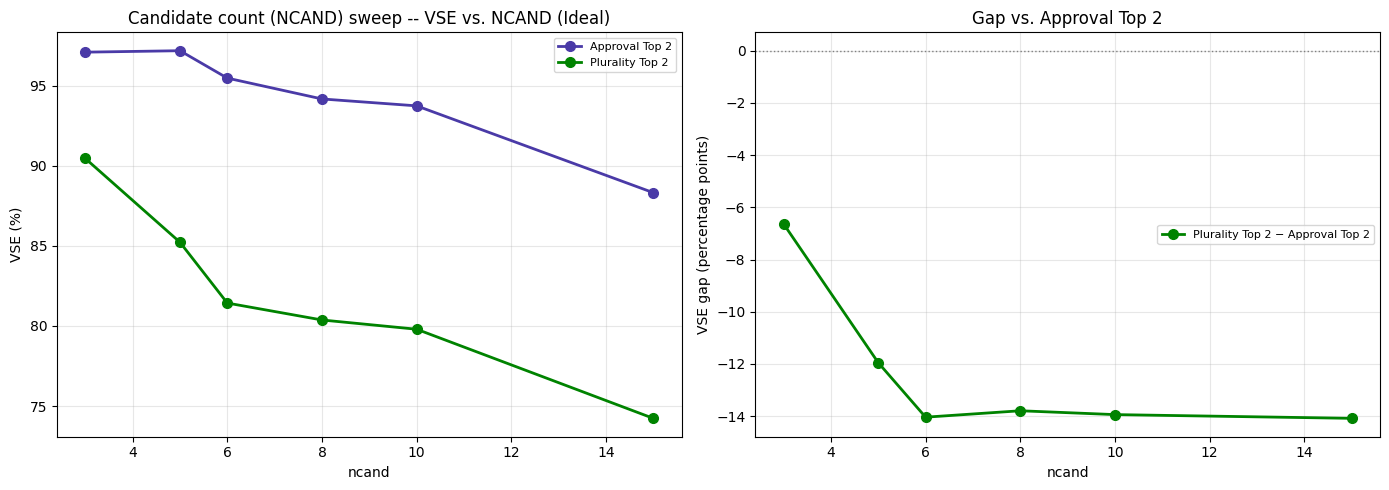

#### Mild friction: VSE by candidate count (NCAND)

| ncand | Approval Top 2 VSE (%) | Plurality Top 2 VSE (%) | Gap (pp) |
|---|---|---|---|
| 3 | 95.9% (+/-1.3) | 92.3% (+/-1.9) | +3.6 |
| 5 | 93.7% (+/-1.0) | 90.3% (+/-1.6) | +3.4 |
| 6 | 91.6% (+/-1.1) | 87.3% (+/-1.8) | +4.3 |
| 8 | 89.6% (+/-1.1) | 85.9% (+/-1.8) | +3.7 |
| 10 | 86.7% (+/-1.3) | 82.3% (+/-2.1) | +4.4 |
| 15 | 85.8% (+/-1.2) | 83.2% (+/-1.7) | +2.5 |

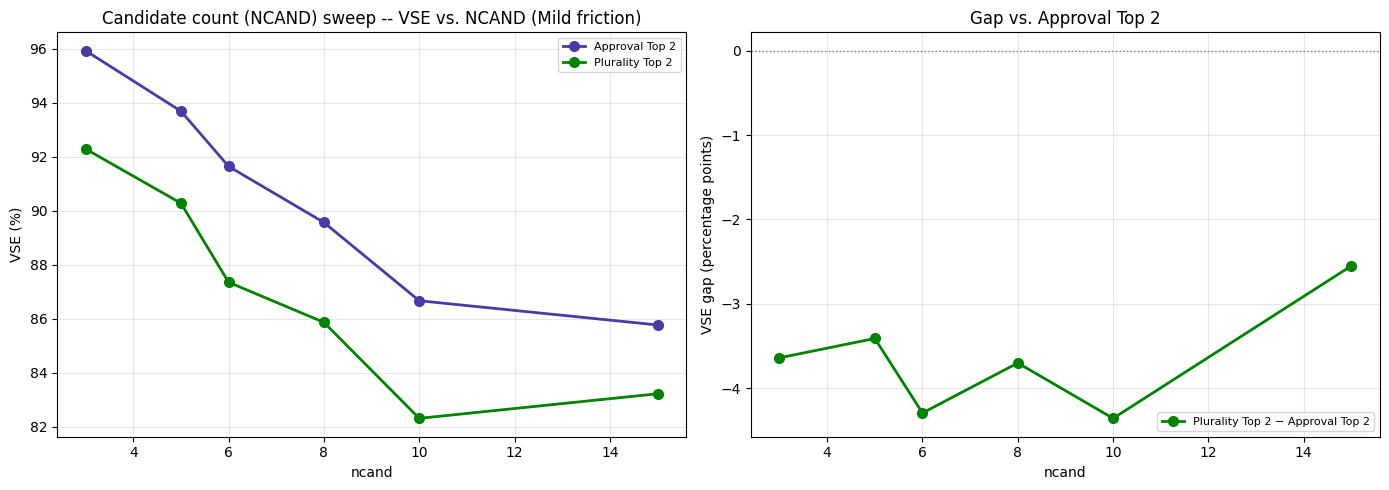

#### Moderate friction: VSE by candidate count (NCAND)

| ncand | Approval Top 2 VSE (%) | Plurality Top 2 VSE (%) | Gap (pp) |
|---|---|---|---|
| 3 | 92.1% (+/-1.7) | 90.2% (+/-2.0) | +1.8 |
| 5 | 84.6% (+/-2.0) | 84.6% (+/-1.9) | -0.0 |
| 6 | 81.4% (+/-1.9) | 82.1% (+/-1.9) | -0.6 |
| 8 | 79.7% (+/-1.9) | 80.0% (+/-1.8) | -0.3 |
| 10 | 78.5% (+/-1.8) | 76.7% (+/-2.0) | +1.7 |
| 15 | 76.2% (+/-1.9) | 76.1% (+/-1.8) | +0.1 |

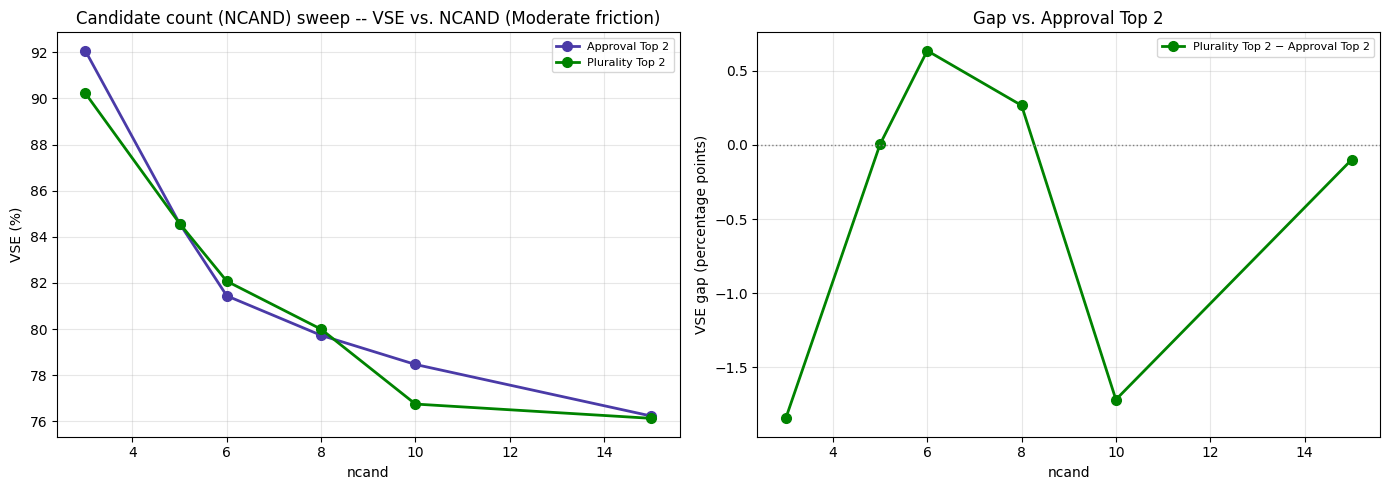

#### Heavy friction: VSE by candidate count (NCAND)

| ncand | Approval Top 2 VSE (%) | Plurality Top 2 VSE (%) | Gap (pp) |
|---|---|---|---|
| 3 | 86.4% (+/-2.2) | 85.6% (+/-2.3) | +0.9 |
| 5 | 75.5% (+/-2.4) | 74.7% (+/-2.5) | +0.9 |
| 6 | 72.2% (+/-2.6) | 72.3% (+/-2.6) | -0.2 |
| 8 | 69.6% (+/-2.5) | 70.2% (+/-2.5) | -0.6 |
| 10 | 69.6% (+/-2.5) | 70.0% (+/-2.4) | -0.4 |
| 15 | 67.0% (+/-2.3) | 67.5% (+/-2.3) | -0.5 |

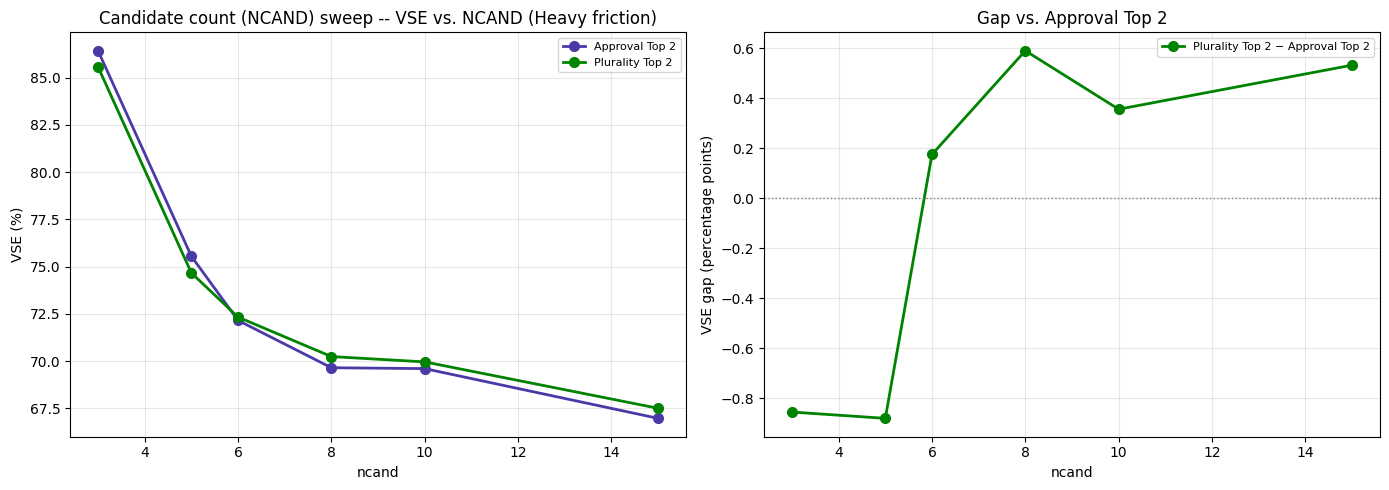

In [150]:
def candidate_comparison_table(results_by_ncand, labels, ncand_key):
    """Display a Markdown table comparing VSE by candidate count (NCAND) for the given labels.

    results_by_ncand: {ncand: {(label, chooser): (mean, ci)}}
    labels: list of method labels to include in the table
    ncand_key: string label for the candidate count column
    """
    header = [ncand_key] + [f"{label} VSE (%)" for label in labels] + ["Gap (pp)"]
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    for ncand in sorted(results_by_ncand):
        row = [str(ncand)]
        for label in labels:
            mean_, ci = results_by_ncand[ncand][(label, "honBallot")]
            row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
        if len(labels) == 2:
            gap = (results_by_ncand[ncand][(labels[0], "honBallot")][0] -
                   results_by_ncand[ncand][(labels[1], "honBallot")][0]) * 100
            row.append(f"{gap:+.1f}")
        lines.append("| " + " | ".join(row) + " |")
    display(Markdown("\n".join(lines)))

for scenario_name, ncand_results in results_by_scenario_ncand.items():
    plot_title = f"Candidate count (NCAND) sweep -- VSE vs. NCAND ({scenario_name})"
    display(Markdown(f"#### {scenario_name}: VSE by candidate count (NCAND)"))
    candidate_comparison_table(ncand_results, NCAND_SWEEP_LABELS, "ncand")
    comparison_chart(ncand_results, NCAND_SWEEP_LABELS, "ncand",
                  baseline_label="Approval Top 2", title=plot_title)


In [151]:
# Per-scenario NCAND tables: AT2 vs PT2 with a genuine paired 95% CI on the VSE gap. Both methods
# already run on the SAME per-election data (electorates_by_ncand is shared), and the gap itself
# is now accumulated per election via run_vse_simulation's paired_diff_pairs -- not approximated
# afterward from the two methods' independent CIs the way this cell used to. Gap is (AT2 - PT2),
# in percentage points, matching Section 18's convention.

for scenario_name, ncand_results in results_by_scenario_ncand.items():
    lines = [
        f"#### {scenario_name}",
        "",
        "| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |",
        "|---:|---:|---:|---:|---:|---:|",
    ]

    for ncand in sorted(ncand_results):
        pt2_mean, _ = ncand_results[ncand][("Plurality Top 2", "honBallot")]
        at2_mean, _ = ncand_results[ncand][("Approval Top 2", "honBallot")]

        gap_pp = (at2_mean - pt2_mean) * 100
        gap_ci_pp = paired_diff_by_scenario_ncand[scenario_name][ncand][("Approval Top 2", "Plurality Top 2")][1] * 100
        _register_significance(f"AT2 vs PT2 by candidate count: {scenario_name}", f"NCAND={ncand}", gap_pp, gap_ci_pp, "Approval Top 2", "Plurality Top 2", spotlight=True)
        lo, hi = gap_pp - gap_ci_pp, gap_pp + gap_ci_pp
        sig = "No (CI contains 0)" if lo <= 0 <= hi else "Yes"
        if sig == "Yes":
            sig += " (Approval better)" if gap_pp > 0 else " (Plurality better)"
        lines.append(
            f"| {ncand} | {at2_mean * 100:.2f}% | {pt2_mean * 100:.2f}% | {gap_pp:+.2f} | [{lo:+.2f}, {hi:+.2f}] | {sig} |"
        )

    display(Markdown("\n".join(lines)))


#### Ideal

| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |
|---:|---:|---:|---:|---:|---:|
| 3 | 97.09% | 90.46% | +6.64 | [+4.74, +8.54] | Yes (Approval better) |
| 5 | 97.18% | 85.23% | +11.95 | [+9.46, +14.45] | Yes (Approval better) |
| 6 | 95.47% | 81.43% | +14.04 | [+11.14, +16.94] | Yes (Approval better) |
| 8 | 94.17% | 80.38% | +13.80 | [+11.04, +16.55] | Yes (Approval better) |
| 10 | 93.74% | 79.80% | +13.94 | [+11.32, +16.56] | Yes (Approval better) |
| 15 | 88.32% | 74.24% | +14.09 | [+11.01, +17.16] | Yes (Approval better) |

#### Mild friction

| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |
|---:|---:|---:|---:|---:|---:|
| 3 | 95.93% | 92.29% | +3.64 | [+2.09, +5.19] | Yes (Approval better) |
| 5 | 93.69% | 90.28% | +3.41 | [+1.83, +4.99] | Yes (Approval better) |
| 6 | 91.64% | 87.35% | +4.29 | [+2.53, +6.05] | Yes (Approval better) |
| 8 | 89.56% | 85.86% | +3.70 | [+1.91, +5.49] | Yes (Approval better) |
| 10 | 86.66% | 82.31% | +4.36 | [+2.33, +6.39] | Yes (Approval better) |
| 15 | 85.77% | 83.22% | +2.55 | [+0.92, +4.18] | Yes (Approval better) |

#### Moderate friction

| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |
|---:|---:|---:|---:|---:|---:|
| 3 | 92.07% | 90.23% | +1.84 | [+0.38, +3.30] | Yes (Approval better) |
| 5 | 84.57% | 84.58% | -0.00 | [-1.48, +1.47] | No (CI contains 0) |
| 6 | 81.44% | 82.07% | -0.63 | [-1.84, +0.57] | No (CI contains 0) |
| 8 | 79.73% | 79.99% | -0.27 | [-1.58, +1.05] | No (CI contains 0) |
| 10 | 78.46% | 76.75% | +1.72 | [+0.42, +3.02] | Yes (Approval better) |
| 15 | 76.23% | 76.13% | +0.10 | [-0.89, +1.09] | No (CI contains 0) |

#### Heavy friction

| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |
|---:|---:|---:|---:|---:|---:|
| 3 | 86.42% | 85.57% | +0.86 | [-0.19, +1.90] | No (CI contains 0) |
| 5 | 75.55% | 74.66% | +0.88 | [-0.38, +2.14] | No (CI contains 0) |
| 6 | 72.15% | 72.33% | -0.18 | [-1.47, +1.12] | No (CI contains 0) |
| 8 | 69.65% | 70.24% | -0.59 | [-1.63, +0.45] | No (CI contains 0) |
| 10 | 69.60% | 69.96% | -0.36 | [-1.54, +0.83] | No (CI contains 0) |
| 15 | 66.97% | 67.50% | -0.53 | [-1.19, +0.12] | No (CI contains 0) |

## 25. Per-election VSE spread: what's behind the average

Every VSE number reported above is a mean over hundreds of individual elections, each
contributing exactly one value of `(u(winner) - mean(u(c))) / (max(u(c)) - mean(u(c)))`. A bar
chart with a 95% CI whisker summarizes that distribution but doesn't show its shape. This section
histograms the per-election values directly -- honest ballots only, for the six methods that
matter most to the Approval-vs-STAR-vs-Schulze comparisons above (STAR, Approval, Approval Top 2,
Plurality, Plurality Top 2, Condorcet (Schulze)) -- across the same four joint-friction scenarios
as Section 16, with a dashed line at the mean already reported there.

No new simulation: `ideal_raw_vse` (Section 9) and `joint_raw_vse_by_scenario` (Section 16, via
`run_vse_simulation`'s `raw_vse_sink`) capture every election's `vse` value as it's computed,
instead of only the running sums `reduce_to_mean_ci` needs -- so the dashed mean line below is
computed from, and therefore matches exactly, the number already shown in Section 16's table and
bar chart for that method and scenario.

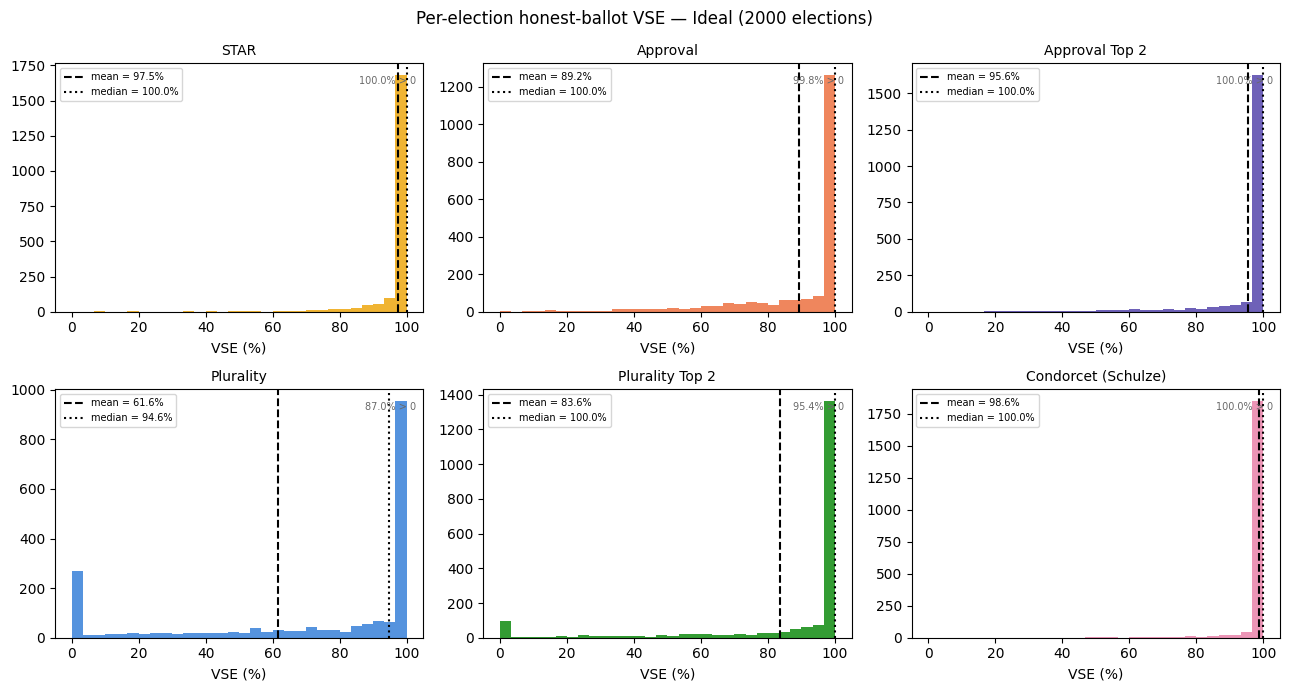

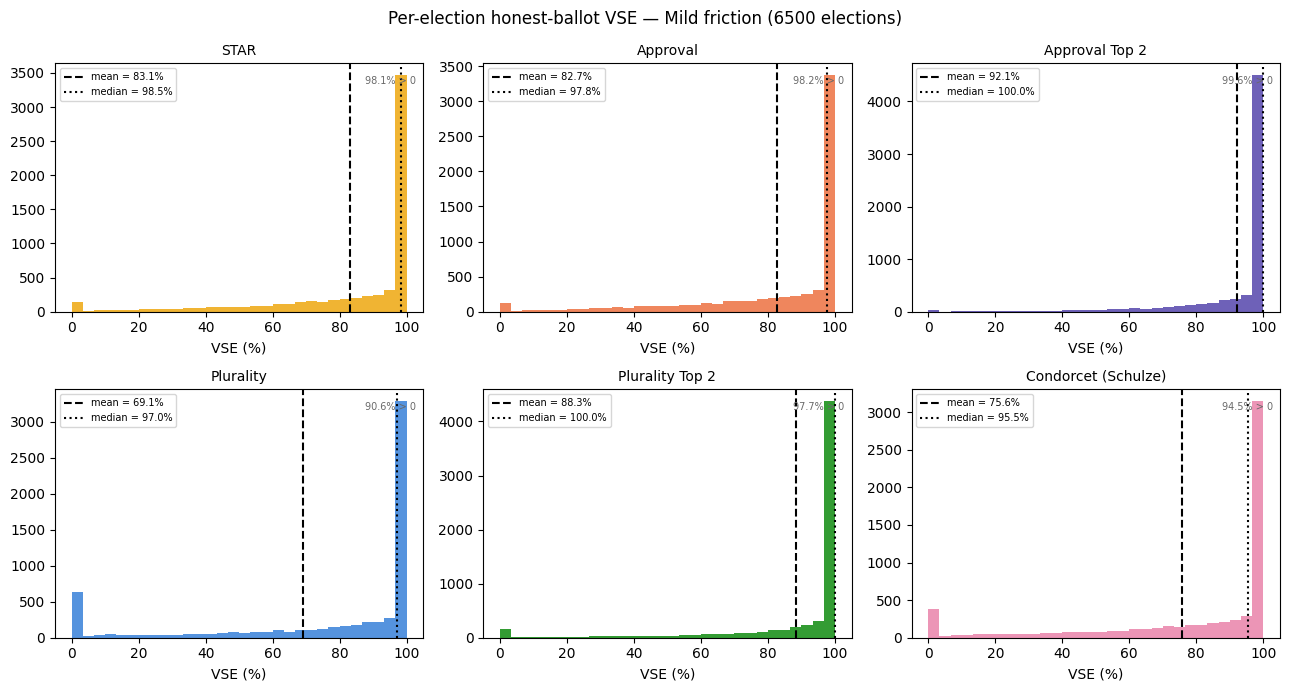

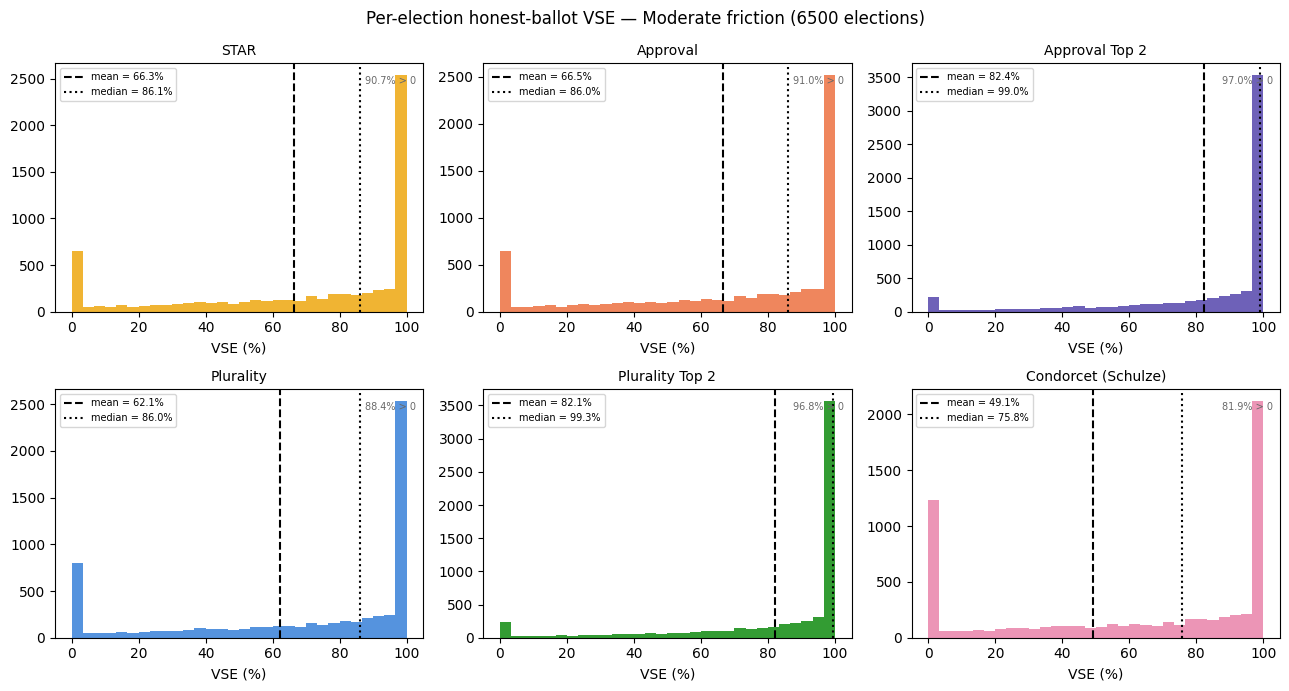

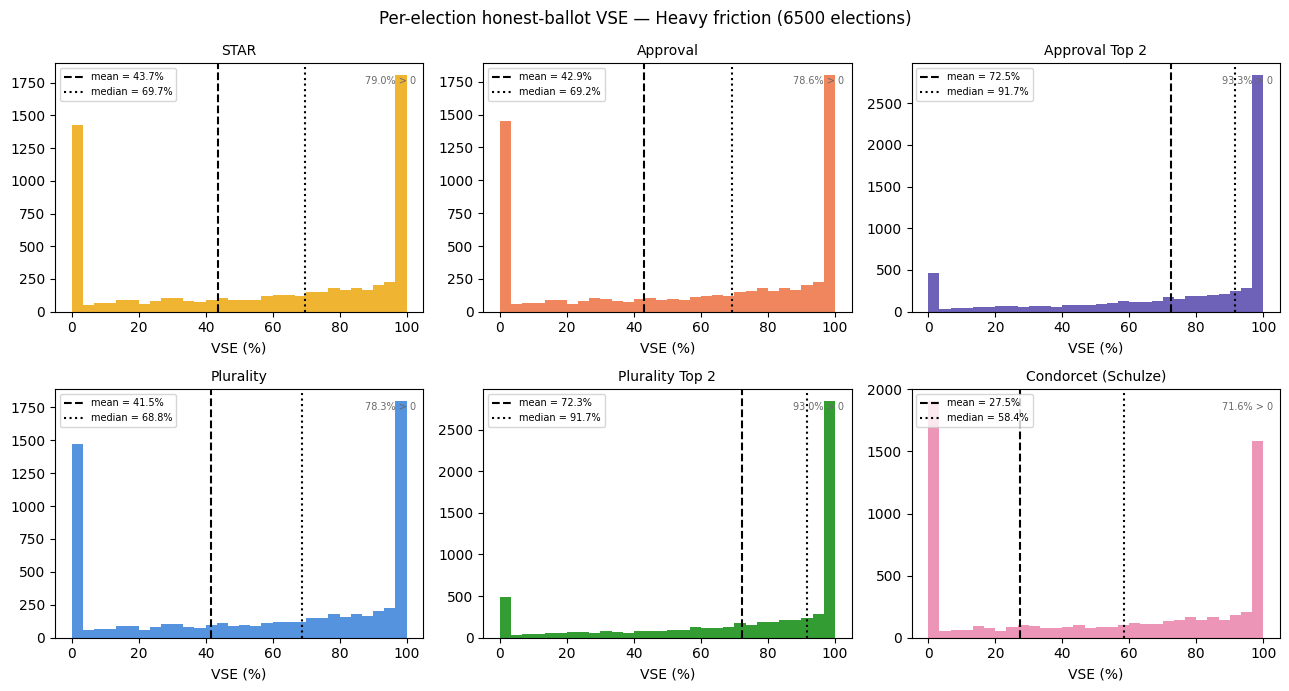

In [152]:
HIST_LABELS = ["STAR", "Approval", "Approval Top 2", "Plurality", "Plurality Top 2", "Condorcet (Schulze)"]
_scenario_names = list(JOINT_SCENARIOS)  # Ideal, Mild friction, Moderate friction, Heavy friction

CLAMP_NEGATIVE_VALUES = True  # True: collapse every VSE < 0 into the single leftmost bucket (at
                               # 0%) instead of stretching the x-axis to fit an absurdly long,
                               # sparse negative tail that hides the shape of the real (mostly
                               # positive) distribution. Flip to False to see the true unclamped
                               # tail, with an x=0 reference line instead.

# Shared x-range per method (pooled across all 4 scenarios) so the four separate figures below
# are visually comparable panel-to-panel for a given method -- the whole point is spotting
# whether Ideal is tighter than Heavy friction, which a per-figure autoscaled axis would hide.
_hist_range = {}
for _label in HIST_LABELS:
    _all_vals = [v for _name in _scenario_names for v in joint_raw_vse_by_scenario[_name][(_label, "honBallot")]]
    _lo = 0.0 if CLAMP_NEGATIVE_VALUES else min(_all_vals)
    _hist_range[_label] = (_lo, max(_all_vals))

for _name in _scenario_names:
    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    for ax, _label in zip(axes.flat, HIST_LABELS):
        raw_vals = joint_raw_vse_by_scenario[_name][(_label, "honBallot")]
        frac_positive = np.mean([v > 0 for v in raw_vals]) * 100
        vals = [(max(v, 0.0) if CLAMP_NEGATIVE_VALUES else v) * 100 for v in raw_vals]
        mean_, _ci = joint_results[_name][(_label, "honBallot")]
        median_ = np.median(raw_vals)
        lo, hi = _hist_range[_label]
        ax.hist(vals, bins=30, range=(lo * 100, hi * 100), color=METHOD_COLORS[_label], alpha=0.8)
        ax.axvline(mean_ * 100, color="black", ls="--", lw=1.5, label=f"mean = {mean_ * 100:.1f}%")
        ax.axvline(median_ * 100, color="black", ls=":", lw=1.5, label=f"median = {median_ * 100:.1f}%")
        if not CLAMP_NEGATIVE_VALUES:
            ax.axvline(0, color="red", ls="-", lw=1, alpha=0.6, label="0%")
        ax.set_title(_label, fontsize=10)
        ax.set_xlabel("VSE (%)")
        ax.legend(fontsize=7, loc="upper left")
        ax.text(0.98, 0.95, f"{frac_positive:.1f}% > 0", transform=ax.transAxes, fontsize=7,
                 ha="right", va="top", color="dimgray")
    fig.suptitle(f"Per-election honest-ballot VSE \u2014 {_name} ({JOINT_NITER if _name != 'Ideal' else NITER} elections)")
    plt.tight_layout()
    plt.show()

In [153]:
## Check if the mode of all of these histograms is at 100%
# Check histogram modes allowing either scale:
# - raw fraction scale (mode ~= 1.0)
# - percent scale (mode ~= 100.0)
_mode_check_lines = [
    "| Scenario | Method | Inferred scale | Mode (raw) | Mode (%) | Count at mode | N | Mode is 1.0/100%? |",
    "|---|---|---|---:|---:|---:|---:|---|",
]

_mode_failures = []

for _name in _scenario_names:
    for _label in HIST_LABELS:
        _vals = np.asarray(joint_raw_vse_by_scenario[_name][(_label, "honBallot")], dtype=float)
        _vals = _vals[np.isfinite(_vals)]
        if _vals.size == 0:
            _mode_failures.append((_name, _label, "empty"))
            _mode_check_lines.append(f"| {_name} | {_label} | n/a | n/a | n/a | 0 | 0 | No |")
            continue

        # Empirical mode on raw values.
        _raw_rounded = np.round(_vals, 6)
        _raw_uniq, _raw_counts = np.unique(_raw_rounded, return_counts=True)
        _mode_raw = float(_raw_uniq[np.argmax(_raw_counts)])
        _mode_count = int(_raw_counts.max())

        # Convert to percent for display/comparison.
        _mode_pct = _mode_raw * 100.0

        # Infer likely storage scale for readability only.
        _scale = "percent-like" if np.nanmax(np.abs(_vals)) > 2 else "fraction-like"

        # Accept either canonical representation.
        _ok = np.isclose(_mode_raw, 1.0, atol=1e-6) or np.isclose(_mode_pct, 100.0, atol=1e-4)
        if not _ok:
            _mode_failures.append((_name, _label, _mode_raw, _mode_pct, _mode_count, len(_vals)))

        _mode_check_lines.append(
            f"| {_name} | {_label} | {_scale} | {_mode_raw:.6g} | {_mode_pct:.6g} | {_mode_count} | {len(_vals)} | {'Yes' if _ok else 'No'} |"
        )

display(Markdown("\n".join(_mode_check_lines)))

if _mode_failures:
    raise AssertionError(
        "Mode is neither 1.0 nor 100% for: "
        + ", ".join(
            f"{s}/{m} (raw={r:.6g}, pct={p:.6g})"
            for s, m, r, p, *_ in _mode_failures
            if len(_) >= 0
        )
    )
    
## Check if any systems have negative values occur more often than 1.0 or 100%. This is actually possible
for _name in _scenario_names:
    for _label in HIST_LABELS:
        _vals = np.asarray(joint_raw_vse_by_scenario[_name][(_label, "honBallot")], dtype=float)
        _vals = _vals[np.isfinite(_vals)]
        if _vals.size == 0:
            continue

        _neg_count = np.sum(_vals < 0)
        _neg_frac = _neg_count / len(_vals)
        hundred_pct_count = np.sum(np.isclose(_vals, 1.0, atol=1e-6) | np.isclose(_vals, 100.0, atol=1e-4))
        if _neg_frac > hundred_pct_count / len(_vals):
            print(f"{_name}/{_label} has more negative values ({_neg_count}/{len(_vals)} = {_neg_frac:.4f}) than count of 1.0/100% values ({hundred_pct_count}/{len(_vals)} = {hundred_pct_count/len(_vals):.4f})")

| Scenario | Method | Inferred scale | Mode (raw) | Mode (%) | Count at mode | N | Mode is 1.0/100%? |
|---|---|---|---:|---:|---:|---:|---|
| Ideal | STAR | fraction-like | 1 | 100 | 1571 | 2000 | Yes |
| Ideal | Approval | fraction-like | 1 | 100 | 1159 | 2000 | Yes |
| Ideal | Approval Top 2 | fraction-like | 1 | 100 | 1530 | 2000 | Yes |
| Ideal | Plurality | percent-like | 1 | 100 | 877 | 2000 | Yes |
| Ideal | Plurality Top 2 | percent-like | 1 | 100 | 1260 | 2000 | Yes |
| Ideal | Condorcet (Schulze) | fraction-like | 1 | 100 | 1782 | 2000 | Yes |
| Mild friction | STAR | percent-like | 1 | 100 | 3039 | 6500 | Yes |
| Mild friction | Approval | percent-like | 1 | 100 | 2948 | 6500 | Yes |
| Mild friction | Approval Top 2 | fraction-like | 1 | 100 | 4037 | 6500 | Yes |
| Mild friction | Plurality | percent-like | 1 | 100 | 2906 | 6500 | Yes |
| Mild friction | Plurality Top 2 | percent-like | 1 | 100 | 3937 | 6500 | Yes |
| Mild friction | Condorcet (Schulze) | percent-like | 1 | 100 | 2743 | 6500 | Yes |
| Moderate friction | STAR | percent-like | 1 | 100 | 2176 | 6500 | Yes |
| Moderate friction | Approval | percent-like | 1 | 100 | 2152 | 6500 | Yes |
| Moderate friction | Approval Top 2 | fraction-like | 1 | 100 | 3092 | 6500 | Yes |
| Moderate friction | Plurality | percent-like | 1 | 100 | 2170 | 6500 | Yes |
| Moderate friction | Plurality Top 2 | fraction-like | 1 | 100 | 3132 | 6500 | Yes |
| Moderate friction | Condorcet (Schulze) | percent-like | 1 | 100 | 1800 | 6500 | Yes |
| Heavy friction | STAR | percent-like | 1 | 100 | 1533 | 6500 | Yes |
| Heavy friction | Approval | percent-like | 1 | 100 | 1528 | 6500 | Yes |
| Heavy friction | Approval Top 2 | percent-like | 1 | 100 | 2450 | 6500 | Yes |
| Heavy friction | Plurality | percent-like | 1 | 100 | 1526 | 6500 | Yes |
| Heavy friction | Plurality Top 2 | percent-like | 1 | 100 | 2460 | 6500 | Yes |
| Heavy friction | Condorcet (Schulze) | percent-like | 1 | 100 | 1349 | 6500 | Yes |

Heavy friction/Condorcet (Schulze) has more negative values (1843/6500 = 0.2835) than count of 1.0/100% values (1349/6500 = 0.2075)


## 26. Results Under a 99% Confidence Bar

Every paired-gap "Significant?" verdict shown earlier in this notebook uses a 95% CI (`Z_95 =
1.96`). This section re-checks every one of those SAME already-computed gaps against a stricter
99% CI (`Z_99 ~= 2.576`) -- since a CI's half-width scales linearly with z for a fixed standard
error, this is pure arithmetic on the already-stored 95% half-widths, not a re-run of anything
(`SIGNIFICANCE_LOG`, populated as each table above renders).

**Run this after a full Restart & Run All, not standalone** -- same caveat as the Claims
Dashboard below, which this section precedes: it only reads globals already computed earlier in
the notebook, no new simulation of its own.

Two tables, not one big flat dump. First, a **comprehensive** table of every row that was
significant at 95% but loses that status at 99% -- since a 99% CI is strictly wider than a 95%
one, a result can only ever move from significant to not-significant here, never the reverse, so
this table is exactly the fragile claims worth knowing about (expected to stay short). Second, a
**curated spotlight** on specific headline claims -- marked explicitly at their own call site via
a `spotlight=True` flag, not picked out here by matching table titles -- showing whether each one
holds up at the stricter bar: Groggy AT2/PT2 vs STAR, the kappa threshold, Condorcet efficiency
vs Schulze, and Approval vs Plurality across every flavor (single-round, Groggy/Clear-Eyed Top-2,
and the candidate-count sweep).

In [154]:
_PART2_TABLE_KEYWORDS = ("Schulze", "Condorcet", "CE gap")

_not_sig_bullets = []
for _table_title, _rows in SIGNIFICANCE_LOG.items():
    if any(_kw in _table_title for _kw in _PART2_TABLE_KEYWORDS):
        continue
    for _row_label, _gap, _ci95, _pos_name, _neg_name, _spotlight in _rows:
        _ci99 = _ci95 * (Z_99 / Z_95)
        _sig_95 = not (_gap - _ci95 <= 0 <= _gap + _ci95)
        _sig_99 = not (_gap - _ci99 <= 0 <= _gap + _ci99)
        if _sig_95 and not _sig_99:
            _better, _worse = (_pos_name, _neg_name) if _gap > 0 else (_neg_name, _pos_name)
            _not_sig_bullets.append(
                f"- **{_table_title} -- {_row_label}**: at 95% confidence, **{_better}** appeared "
                f"better than **{_worse}** by {abs(_gap):.1f}pp (95% CI [{_gap-_ci95:+.1f}, {_gap+_ci95:+.1f}]) -- "
                f"but at 99% confidence that edge is no longer significant "
                f"(99% CI [{_gap-_ci99:+.1f}, {_gap+_ci99:+.1f}], which contains 0)."
            )
display(Markdown(f"### {len(_not_sig_bullets)} result(s) lose significance at 99% confidence\n"))
if _not_sig_bullets:
    display(Markdown("\n".join(_not_sig_bullets)))
else:
    display(Markdown("None -- every 95%-significant result in this post's scope also holds at 99%."))

### 3 result(s) lose significance at 99% confidence


- **kappa threshold: Moderate friction -- kappa=0.30**: at 95% confidence, **Approval Top 2** appeared better than **STAR** by 1.2pp (95% CI [+0.1, +2.3]) -- but at 99% confidence that edge is no longer significant (99% CI [-0.2, +2.6], which contains 0).
- **Score Top 2 (Clear-Eyed) vs Approval Top 2 (Clear-Eyed) -- Mild friction**: at 95% confidence, **AT2** appeared better than **Score Top 2** by 0.3pp (95% CI [-0.6, -0.0]) -- but at 99% confidence that edge is no longer significant (99% CI [-0.7, +0.1], which contains 0).
- **AT2 vs PT2 by candidate count: Moderate friction -- NCAND=3**: at 95% confidence, **Approval Top 2** appeared better than **Plurality Top 2** by 1.8pp (95% CI [+0.4, +3.3]) -- but at 99% confidence that edge is no longer significant (99% CI [-0.1, +3.8], which contains 0).

In [155]:
_PART2_TABLE_KEYWORDS = ("Schulze", "Condorcet", "CE gap")

display(Markdown("### Spotlight: does each headline claim hold up at 99% confidence?\n"))
for _table_title, _rows in SIGNIFICANCE_LOG.items():
    if any(_kw in _table_title for _kw in _PART2_TABLE_KEYWORDS):
        continue
    _spotlight_rows = [r for r in _rows if r[5]]
    if not _spotlight_rows:
        continue
    _lines = [
        f"#### {_table_title}",
        "",
        "| Row | Gap (pp) | 95% verdict | 99% verdict |",
        "|---|---|---|---|",
    ]
    for _row_label, _gap, _ci95, _pos_name, _neg_name, _ in _spotlight_rows:
        _ci99 = _ci95 * (Z_99 / Z_95)
        _sig_95 = not (_gap - _ci95 <= 0 <= _gap + _ci95)
        _sig_99 = not (_gap - _ci99 <= 0 <= _gap + _ci99)
        _better = _pos_name if _gap > 0 else _neg_name
        _verdict_95 = f"{_better} better" if _sig_95 else "No sig. difference"
        _verdict_99 = f"{_better} better" if _sig_99 else "No sig. difference"
        if _verdict_95 != _verdict_99:
            _verdict_99 = f"**{_verdict_99}**"
        _lines.append(f"| {_row_label} | {_gap:+.1f} | {_verdict_95} | {_verdict_99} |")
    display(Markdown("\n".join(_lines)))


### Spotlight: does each headline claim hold up at 99% confidence?


#### Approval-flavor gaps vs STAR: Ideal

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top 2 | -1.9 | STAR better | STAR better |
| Plurality Top 2 | -13.9 | STAR better | STAR better |

#### Approval-flavor gaps vs STAR: Mild friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top 2 | +9.0 | Approval Top 2 better | Approval Top 2 better |
| Plurality Top 2 | +5.3 | Plurality Top 2 better | Plurality Top 2 better |

#### Approval-flavor gaps vs STAR: Moderate friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top 2 | +16.0 | Approval Top 2 better | Approval Top 2 better |
| Plurality Top 2 | +15.7 | Plurality Top 2 better | Plurality Top 2 better |

#### Approval-flavor gaps vs STAR: Heavy friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top 2 | +28.8 | Approval Top 2 better | Approval Top 2 better |
| Plurality Top 2 | +28.6 | Plurality Top 2 better | Plurality Top 2 better |

...

#### kappa threshold: Heavy friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| kappa=0.00 | -11.3 | STAR better | STAR better |
| kappa=0.20 | -1.3 | No sig. difference | No sig. difference |
| kappa=0.25 | +0.5 | No sig. difference | No sig. difference |
| kappa=0.30 | +3.9 | Approval Top 2 better | Approval Top 2 better |
| kappa=0.33 | +6.1 | Approval Top 2 better | Approval Top 2 better |
| kappa=0.35 | +6.9 | Approval Top 2 better | Approval Top 2 better |
| kappa=0.40 | +9.7 | Approval Top 2 better | Approval Top 2 better |
| kappa=0.60 | +20.2 | Approval Top 2 better | Approval Top 2 better |
| kappa=0.80 | +26.4 | Approval Top 2 better | Approval Top 2 better |
| kappa=1.00 | +29.1 | Approval Top 2 better | Approval Top 2 better |

#### AT2 vs PT2 by candidate count: Ideal

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| NCAND=3 | +6.6 | Approval Top 2 better | Approval Top 2 better |
| NCAND=5 | +12.0 | Approval Top 2 better | Approval Top 2 better |
| NCAND=6 | +14.0 | Approval Top 2 better | Approval Top 2 better |
| NCAND=8 | +13.8 | Approval Top 2 better | Approval Top 2 better |
| NCAND=10 | +13.9 | Approval Top 2 better | Approval Top 2 better |
| NCAND=15 | +14.1 | Approval Top 2 better | Approval Top 2 better |

#### AT2 vs PT2 by candidate count: Mild friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| NCAND=3 | +3.6 | Approval Top 2 better | Approval Top 2 better |
| NCAND=5 | +3.4 | Approval Top 2 better | Approval Top 2 better |
| NCAND=6 | +4.3 | Approval Top 2 better | Approval Top 2 better |
| NCAND=8 | +3.7 | Approval Top 2 better | Approval Top 2 better |
| NCAND=10 | +4.4 | Approval Top 2 better | Approval Top 2 better |
| NCAND=15 | +2.5 | Approval Top 2 better | Approval Top 2 better |

#### AT2 vs PT2 by candidate count: Moderate friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| NCAND=3 | +1.8 | Approval Top 2 better | **No sig. difference** |
| NCAND=5 | -0.0 | No sig. difference | No sig. difference |
| NCAND=6 | -0.6 | No sig. difference | No sig. difference |
| NCAND=8 | -0.3 | No sig. difference | No sig. difference |
| NCAND=10 | +1.7 | Approval Top 2 better | Approval Top 2 better |
| NCAND=15 | +0.1 | No sig. difference | No sig. difference |

#### AT2 vs PT2 by candidate count: Heavy friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| NCAND=3 | +0.9 | No sig. difference | No sig. difference |
| NCAND=5 | +0.9 | No sig. difference | No sig. difference |
| NCAND=6 | -0.2 | No sig. difference | No sig. difference |
| NCAND=8 | -0.6 | No sig. difference | No sig. difference |
| NCAND=10 | -0.4 | No sig. difference | No sig. difference |
| NCAND=15 | -0.5 | No sig. difference | No sig. difference |

In [156]:
_PART2_TABLE_KEYWORDS = ("Schulze", "Condorcet", "CE gap")

_not_sig_bullets = []
for _table_title, _rows in SIGNIFICANCE_LOG.items():
    if not any(_kw in _table_title for _kw in _PART2_TABLE_KEYWORDS):
        continue
    for _row_label, _gap, _ci95, _pos_name, _neg_name, _spotlight in _rows:
        _ci99 = _ci95 * (Z_99 / Z_95)
        _sig_95 = not (_gap - _ci95 <= 0 <= _gap + _ci95)
        _sig_99 = not (_gap - _ci99 <= 0 <= _gap + _ci99)
        if _sig_95 and not _sig_99:
            _better, _worse = (_pos_name, _neg_name) if _gap > 0 else (_neg_name, _pos_name)
            _not_sig_bullets.append(
                f"- **{_table_title} -- {_row_label}**: at 95% confidence, **{_better}** appeared "
                f"better than **{_worse}** by {abs(_gap):.1f}pp (95% CI [{_gap-_ci95:+.1f}, {_gap+_ci95:+.1f}]) -- "
                f"but at 99% confidence that edge is no longer significant "
                f"(99% CI [{_gap-_ci99:+.1f}, {_gap+_ci99:+.1f}], which contains 0)."
            )
display(Markdown(f"### {len(_not_sig_bullets)} result(s) lose significance at 99% confidence\n"))
if _not_sig_bullets:
    display(Markdown("\n".join(_not_sig_bullets)))
else:
    display(Markdown("None -- every 95%-significant result in this post's scope also holds at 99%."))


### 0 result(s) lose significance at 99% confidence


None -- every 95%-significant result in this post's scope also holds at 99%.

In [157]:
_PART2_TABLE_KEYWORDS = ("Schulze", "Condorcet", "CE gap")

display(Markdown("### Spotlight: does each headline claim hold up at 99% confidence?\n"))
for _table_title, _rows in SIGNIFICANCE_LOG.items():
    if not any(_kw in _table_title for _kw in _PART2_TABLE_KEYWORDS):
        continue
    _spotlight_rows = [r for r in _rows if r[5]]
    if not _spotlight_rows:
        continue
    _lines = [
        f"#### {_table_title}",
        "",
        "| Row | Gap (pp) | 95% verdict | 99% verdict |",
        "|---|---|---|---|",
    ]
    for _row_label, _gap, _ci95, _pos_name, _neg_name, _ in _spotlight_rows:
        _ci99 = _ci95 * (Z_99 / Z_95)
        _sig_95 = not (_gap - _ci95 <= 0 <= _gap + _ci95)
        _sig_99 = not (_gap - _ci99 <= 0 <= _gap + _ci99)
        _better = _pos_name if _gap > 0 else _neg_name
        _verdict_95 = f"{_better} better" if _sig_95 else "No sig. difference"
        _verdict_99 = f"{_better} better" if _sig_99 else "No sig. difference"
        if _verdict_95 != _verdict_99:
            _verdict_99 = f"**{_verdict_99}**"
        _lines.append(f"| {_row_label} | {_gap:+.1f} | {_verdict_95} | {_verdict_99} |")
    display(Markdown("\n".join(_lines)))


### Spotlight: does each headline claim hold up at 99% confidence?


#### CE gap vs Schulze: Ideal

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top 2 | -17.9 | Condorcet (Schulze) better | Condorcet (Schulze) better |
| STAR | -20.7 | Condorcet (Schulze) better | Condorcet (Schulze) better |
| Score5 | -29.1 | Condorcet (Schulze) better | Condorcet (Schulze) better |
| Plurality Top 2 | -33.8 | Condorcet (Schulze) better | Condorcet (Schulze) better |
| RCV (IRV) | -36.0 | Condorcet (Schulze) better | Condorcet (Schulze) better |
| Approval | -42.2 | Condorcet (Schulze) better | Condorcet (Schulze) better |
| Plurality | -55.6 | Condorcet (Schulze) better | Condorcet (Schulze) better |

#### CE gap vs Schulze: Mild friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top 2 (Clear-Eyed) | +29.3 | Approval Top 2 (Clear-Eyed) better | Approval Top 2 (Clear-Eyed) better |
| Score Top 2 (Clear-Eyed) | +28.3 | Score Top 2 (Clear-Eyed) better | Score Top 2 (Clear-Eyed) better |
| Plurality Top 2 (Clear-Eyed) | +26.2 | Plurality Top 2 (Clear-Eyed) better | Plurality Top 2 (Clear-Eyed) better |
| Approval Top 2 | +19.7 | Approval Top 2 better | Approval Top 2 better |
| Plurality Top 2 | +18.6 | Plurality Top 2 better | Plurality Top 2 better |
| STAR | +4.4 | STAR better | STAR better |
| Approval | +3.0 | Approval better | Approval better |
| Plurality | +2.6 | Plurality better | Plurality better |
| Score5 | +2.2 | Score5 better | Score5 better |
| Approval Top 2 (Coma) | +2.1 | Approval Top 2 (Coma) better | Approval Top 2 (Coma) better |
| RCV (IRV) | -0.3 | No sig. difference | No sig. difference |

#### CE gap vs Schulze: Moderate friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Plurality Top 2 (Clear-Eyed) | +27.5 | Plurality Top 2 (Clear-Eyed) better | Plurality Top 2 (Clear-Eyed) better |
| Approval Top 2 (Clear-Eyed) | +27.3 | Approval Top 2 (Clear-Eyed) better | Approval Top 2 (Clear-Eyed) better |
| Score Top 2 (Clear-Eyed) | +27.1 | Score Top 2 (Clear-Eyed) better | Score Top 2 (Clear-Eyed) better |
| Plurality Top 2 | +20.5 | Plurality Top 2 better | Plurality Top 2 better |
| Approval Top 2 | +20.0 | Approval Top 2 better | Approval Top 2 better |
| Plurality | +5.9 | Plurality better | Plurality better |
| STAR | +5.9 | STAR better | STAR better |
| Approval | +5.6 | Approval better | Approval better |
| Score5 | +5.2 | Score5 better | Score5 better |
| Approval Top 2 (Coma) | +1.1 | Approval Top 2 (Coma) better | Approval Top 2 (Coma) better |
| RCV (IRV) | +0.5 | RCV (IRV) better | RCV (IRV) better |

#### CE gap vs Schulze: Heavy friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Plurality Top 2 (Clear-Eyed) | +23.2 | Plurality Top 2 (Clear-Eyed) better | Plurality Top 2 (Clear-Eyed) better |
| Approval Top 2 (Clear-Eyed) | +23.1 | Approval Top 2 (Clear-Eyed) better | Approval Top 2 (Clear-Eyed) better |
| Score Top 2 (Clear-Eyed) | +23.0 | Score Top 2 (Clear-Eyed) better | Score Top 2 (Clear-Eyed) better |
| Plurality Top 2 | +17.3 | Plurality Top 2 better | Plurality Top 2 better |
| Approval Top 2 | +17.0 | Approval Top 2 better | Approval Top 2 better |
| Approval | +2.9 | Approval better | Approval better |
| STAR | +2.8 | STAR better | STAR better |
| Score5 | +2.8 | Score5 better | Score5 better |
| Plurality | +2.7 | Plurality better | Plurality better |
| RCV (IRV) | +0.0 | No sig. difference | No sig. difference |
| Approval Top 2 (Coma) | -0.2 | No sig. difference | No sig. difference |

# Claims Dashboard

## Part 1

Every `jupyter_cell_embed` the companion blog post
(`_previews/2026-07-24-runoff-accuracy.md`) embeds from this notebook, re-displayed here in one
place, in the same order the post reads them. After changing a parameter (`NITER`, a friction
value, ...) and re-running, scroll through this one section to see at a glance whether any of
the numbers/tables/charts the post relies on have moved -- instead of hunting back through each
individual section.

**Run this after a full Restart & Run All, not standalone.** Every cell below only reads globals
already computed earlier in the notebook (`joint_results`, `paired_diff_by_scenario`,
`betrayal_by_scenario`, `results_by_scenario_ncand`, ...) -- it runs no new simulation of its own.

Each group's code cell below calls `replay("tag-name")` (defined just below), which re-reads this
notebook's own saved `.ipynb` file, finds the cell tagged `"tag-name"`, and `exec`s its current
source in place -- so it's always the SAME code as the original tagged cell, not a copy that can
drift out of sync. Edit the original cell anywhere else in the notebook, save, re-run this
section, and the dashboard picks up the change automatically.

In [158]:
# Re-reads this notebook's own saved file, finds the cell(s) tagged `tag`, and execs their
# current source into this kernel's namespace -- see Section 27's intro above for why.
import json as _json

_NB_SELF_PATH = "vse_simulation.ipynb"

def replay(tag):
    with open(_NB_SELF_PATH, encoding="utf-8") as f:
        _nb = _json.load(f)
    _matches = [c for c in _nb["cells"] if tag in c.get("metadata", {}).get("tags", [])]
    assert len(_matches) == 1, f"expected exactly 1 cell tagged {tag!r}, found {len(_matches)}"
    _src = "".join(_matches[0]["source"])
    exec(compile(_src, f"<tag:{tag}>", "exec"), globals())


### Introduction

In [159]:
replay("evc-vse")


| Method | Computed | Honest VSE |
|---|---|---|
| Plurality | 59.62% - 81.07% | 61.63% |
| Plurality Top 2 | 83.01% - 87.10% | 83.61% |
| RCV (IRV) | 76.68% - 87.91% | 87.91% |
| Approval | 83.87% - 95.02% | 89.18% |
| Approval Top 2 | 92.38% - 97.70% | 95.59% |
| STAR | 89.17% - 97.88% | 97.49% |
| Condorcet (Schulze) | 84.05% - 98.60% | 98.60% |

### Other Relevant Methodology

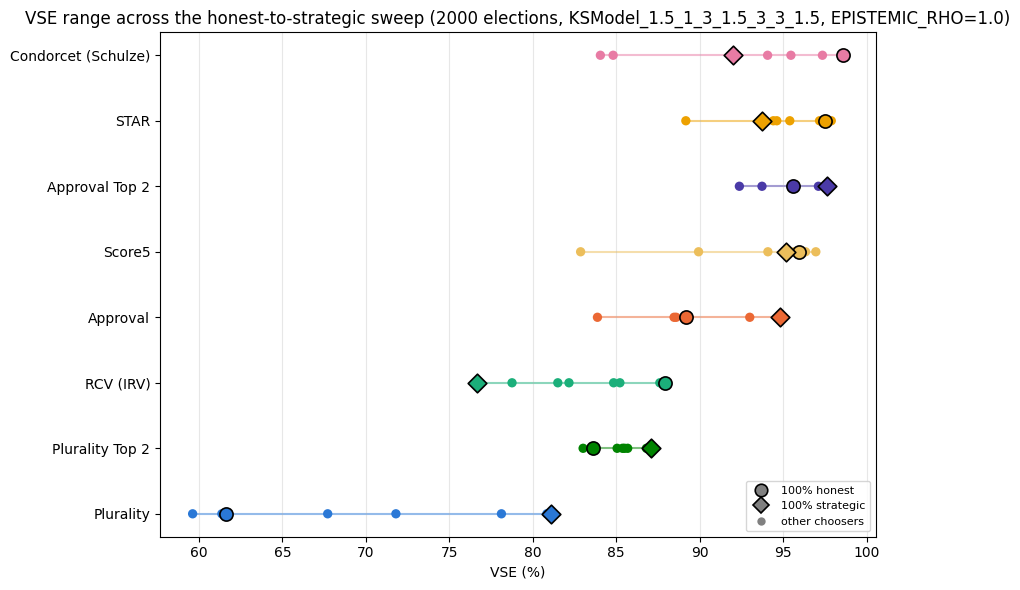

| Method | Computed | Documented |
|---|---|---|
| Condorcet (Schulze) | 84.05% - 98.60% | 86-98% |
| Approval Top 2 | 92.38% - 97.70% | (no documented range on file) |
| STAR | 89.17% - 97.88% | 91-98% |
| Score5 | 82.87% - 96.96% | 84-96% |
| Plurality Top 2 | 83.01% - 87.10% | (no documented range on file) |
| RCV (IRV) | 76.68% - 87.91% | up to 87% |
| Approval | 83.87% - 95.02% | 89-95% |
| Plurality | 59.62% - 81.07% | ~75% |

**Condorcet (Schulze)**

| Chooser | VSE | 95% CI |
|---|---|---|
| 100% honest | 98.60% | +/-0.31 |
| 25% strategic | 97.35% | +/-0.43 |
| 50% strategic | 95.47% | +/-0.56 |
| 75% strategic | 94.07% | +/-0.66 |
| 50% one-sided strategic | 92.03% | +/-0.83 |
| 100% strategic | 92.02% | +/-0.83 |
| smart one-sided strategic | 84.81% | +/-1.18 |
| 100% one-sided strategic | 84.05% | +/-1.18 |
| **range** | 84.05% - 98.60% | |

**Approval Top 2**

| Chooser | VSE | 95% CI |
|---|---|---|
| 75% strategic | 97.70% | +/-0.38 |
| 100% strategic | 97.63% | +/-0.41 |
| 50% strategic | 97.62% | +/-0.37 |
| 25% strategic | 97.12% | +/-0.41 |
| 50% one-sided strategic | 95.67% | +/-0.52 |
| 100% honest | 95.59% | +/-0.54 |
| smart one-sided strategic | 93.73% | +/-0.67 |
| 100% one-sided strategic | 92.38% | +/-0.74 |
| **range** | 92.38% - 97.70% | |

...

| Prominence rank \ Fatigue position | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|---|
| 0 | 100.0% | 90.0% | 81.0% | 72.9% | 65.6% | 59.0% |
| 1 | 90.0% | 81.0% | 72.9% | 65.6% | 59.0% | 53.1% |
| 2 | 81.0% | 72.9% | 65.6% | 59.0% | 53.1% | 47.8% |
| 3 | 72.9% | 65.6% | 59.0% | 53.1% | 47.8% | 43.0% |
| 4 | 65.6% | 59.0% | 53.1% | 47.8% | 43.0% | 38.7% |
| 5 | 59.0% | 53.1% | 47.8% | 43.0% | 38.7% | 34.9% |

### Probability table for moderate friction (alpha=0.8, beta=0.8)

| Prominence rank \ Fatigue position | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|---|
| 0 | 100.0% | 80.0% | 64.0% | 51.2% | 41.0% | 32.8% |
| 1 | 80.0% | 64.0% | 51.2% | 41.0% | 32.8% | 26.2% |
| 2 | 64.0% | 51.2% | 41.0% | 32.8% | 26.2% | 21.0% |
| 3 | 51.2% | 41.0% | 32.8% | 26.2% | 21.0% | 16.8% |
| 4 | 41.0% | 32.8% | 26.2% | 21.0% | 16.8% | 13.4% |
| 5 | 32.8% | 26.2% | 21.0% | 16.8% | 13.4% | 10.7% |

### Probability table for heavy friction (alpha=0.7, beta=0.7)

| Prominence rank \ Fatigue position | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|---|
| 0 | 100.0% | 70.0% | 49.0% | 34.3% | 24.0% | 16.8% |
| 1 | 70.0% | 49.0% | 34.3% | 24.0% | 16.8% | 11.8% |
| 2 | 49.0% | 34.3% | 24.0% | 16.8% | 11.8% | 8.2% |
| 3 | 34.3% | 24.0% | 16.8% | 11.8% | 8.2% | 5.8% |
| 4 | 24.0% | 16.8% | 11.8% | 8.2% | 5.8% | 4.0% |
| 5 | 16.8% | 11.8% | 8.2% | 5.8% | 4.0% | 2.8% |

In [160]:
replay("strategy-sweep-chart")
replay("vse-range-baseline")
replay("vse-tables")
replay("friction-table")


### Findings: The Approval-STAR Gap

#### Ideal: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Approval | 89.2 | 97.5 | -8.3 | [-9.1, -7.5] | Yes (STAR better) |
| Approval Top 2 | 95.6 | 97.5 | -1.9 | [-2.4, -1.4] | Yes (STAR better) |
| Plurality Top 2 | 83.6 | 97.5 | -13.9 | [-15.7, -12.1] | Yes (STAR better) |

#### Mild friction: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Approval | 82.7 | 83.1 | -0.4 | [-0.9, +0.1] | No (CI contains 0) |
| Approval Top 2 (Coma) | 80.8 | 83.1 | -2.3 | [-2.8, -1.7] | Yes (STAR better) |
| Approval Top 2 | 92.1 | 83.1 | +9.0 | [+8.4, +9.6] | Yes (STAR worse) |
| Approval Top 2 (Clear-Eyed) | 92.9 | 83.1 | +9.8 | [+9.2, +10.4] | Yes (STAR worse) |
| Plurality Top 2 | 88.3 | 83.1 | +5.3 | [+4.5, +6.1] | Yes (STAR worse) |
| Plurality Top 2 (Clear-Eyed) | 88.9 | 83.1 | +5.8 | [+5.0, +6.6] | Yes (STAR worse) |

#### Moderate friction: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Approval | 66.5 | 66.3 | +0.2 | [-0.3, +0.7] | No (CI contains 0) |
| Approval Top 2 (Coma) | 58.2 | 66.3 | -8.1 | [-9.1, -7.2] | Yes (STAR better) |
| Approval Top 2 | 82.4 | 66.3 | +16.0 | [+15.1, +17.0] | Yes (STAR worse) |
| Approval Top 2 (Clear-Eyed) | 83.6 | 66.3 | +17.3 | [+16.4, +18.2] | Yes (STAR worse) |
| Plurality Top 2 | 82.1 | 66.3 | +15.7 | [+14.8, +16.7] | Yes (STAR worse) |
| Plurality Top 2 (Clear-Eyed) | 83.5 | 66.3 | +17.1 | [+16.2, +18.1] | Yes (STAR worse) |

#### Heavy friction: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Approval | 42.9 | 43.7 | -0.8 | [-1.4, -0.3] | Yes (STAR better) |
| Approval Top 2 (Coma) | 31.3 | 43.7 | -12.4 | [-13.6, -11.2] | Yes (STAR better) |
| Approval Top 2 | 72.5 | 43.7 | +28.8 | [+27.4, +30.3] | Yes (STAR worse) |
| Approval Top 2 (Clear-Eyed) | 75.1 | 43.7 | +31.4 | [+30.0, +32.8] | Yes (STAR worse) |
| Plurality Top 2 | 72.3 | 43.7 | +28.6 | [+27.2, +30.1] | Yes (STAR worse) |
| Plurality Top 2 (Clear-Eyed) | 74.9 | 43.7 | +31.2 | [+29.8, +32.6] | Yes (STAR worse) |

### Method/scenario pairs where STAR's VSE is significantly higher than the method's (95% CI does NOT contain 0)

| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|
| Approval | Ideal | -8.3 | [-9.1, -7.5] | Yes (STAR better) |
| Approval Top 2 | Ideal | -1.9 | [-2.4, -1.4] | Yes (STAR better) |
| Plurality Top 2 | Ideal | -13.9 | [-15.7, -12.1] | Yes (STAR better) |
| Approval Top 2 (Coma) | Mild friction | -2.3 | [-2.8, -1.7] | Yes (STAR better) |
| Approval Top 2 (Coma) | Moderate friction | -8.1 | [-9.1, -7.2] | Yes (STAR better) |
| Approval | Heavy friction | -0.8 | [-1.4, -0.3] | Yes (STAR better) |
| Approval Top 2 (Coma) | Heavy friction | -12.4 | [-13.6, -11.2] | Yes (STAR better) |

### Method/scenario pairs with STAR VSE gap that is statistically indistinguishable from 0 (95% CI contains 0)

| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|
| Approval | Mild friction | -0.4 | [-0.9, +0.1] | No (CI contains 0) |
| Approval | Moderate friction | +0.2 | [-0.3, +0.7] | No (CI contains 0) |

### Method/scenario pairs where STAR's VSE is significantly lower than the method's (95% CI does NOT contain 0)

| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|
| Approval Top 2 | Mild friction | +9.0 | [+8.4, +9.6] | Yes (STAR worse) |
| Approval Top 2 (Clear-Eyed) | Mild friction | +9.8 | [+9.2, +10.4] | Yes (STAR worse) |
| Plurality Top 2 | Mild friction | +5.3 | [+4.5, +6.1] | Yes (STAR worse) |
| Plurality Top 2 (Clear-Eyed) | Mild friction | +5.8 | [+5.0, +6.6] | Yes (STAR worse) |
| Approval Top 2 | Moderate friction | +16.0 | [+15.1, +17.0] | Yes (STAR worse) |
| Approval Top 2 (Clear-Eyed) | Moderate friction | +17.3 | [+16.4, +18.2] | Yes (STAR worse) |
| Plurality Top 2 | Moderate friction | +15.7 | [+14.8, +16.7] | Yes (STAR worse) |
| Plurality Top 2 (Clear-Eyed) | Moderate friction | +17.1 | [+16.2, +18.1] | Yes (STAR worse) |
| Approval Top 2 | Heavy friction | +28.8 | [+27.4, +30.3] | Yes (STAR worse) |
| Approval Top 2 (Clear-Eyed) | Heavy friction | +31.4 | [+30.0, +32.8] | Yes (STAR worse) |
| Plurality Top 2 | Heavy friction | +28.6 | [+27.2, +30.1] | Yes (STAR worse) |
| Plurality Top 2 (Clear-Eyed) | Heavy friction | +31.2 | [+29.8, +32.6] | Yes (STAR worse) |

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 61.6% (+/-2.8) | 69.1% (+/-1.5) | 62.1% (+/-1.4) | 41.5% (+/-1.7) |
| Plurality Top 2 | 83.6% (+/-1.7) | 88.3% (+/-0.7) | 82.1% (+/-0.8) | 72.3% (+/-1.0) |
| Plurality Top 2 (Clear-Eyed) | 83.6% (+/-1.7) | 88.9% (+/-0.7) | 83.5% (+/-0.8) | 74.9% (+/-1.0) |
| RCV (IRV) | 87.9% (+/-1.3) | 74.3% (+/-1.1) | 51.0% (+/-1.6) | 27.9% (+/-2.0) |
| Approval | 89.2% (+/-0.8) | 82.7% (+/-0.7) | 66.5% (+/-1.1) | 42.9% (+/-1.7) |
| Approval Top 2 (Coma) | 95.6% (+/-0.5) | 80.8% (+/-0.8) | 58.2% (+/-1.3) | 31.3% (+/-1.9) |
| Approval Top 2 | 95.6% (+/-0.5) | 92.1% (+/-0.4) | 82.4% (+/-0.7) | 72.5% (+/-1.0) |
| Approval Top 2 (Clear-Eyed) | 95.6% (+/-0.5) | 92.9% (+/-0.4) | 83.6% (+/-0.7) | 75.1% (+/-1.0) |
| STAR | 97.5% (+/-0.3) | 83.1% (+/-0.7) | 66.3% (+/-1.1) | 43.7% (+/-1.7) |
| Score5 | 95.9% (+/-0.4) | 81.9% (+/-0.7) | 65.2% (+/-1.2) | 42.5% (+/-1.7) |
| Score Top 2 (Clear-Eyed) | 98.0% (+/-0.3) | 92.6% (+/-0.4) | 84.0% (+/-0.7) | 75.1% (+/-0.9) |
| Condorcet (Schulze) | 98.6% (+/-0.3) | 75.6% (+/-1.0) | 49.1% (+/-1.6) | 27.5% (+/-2.1) |

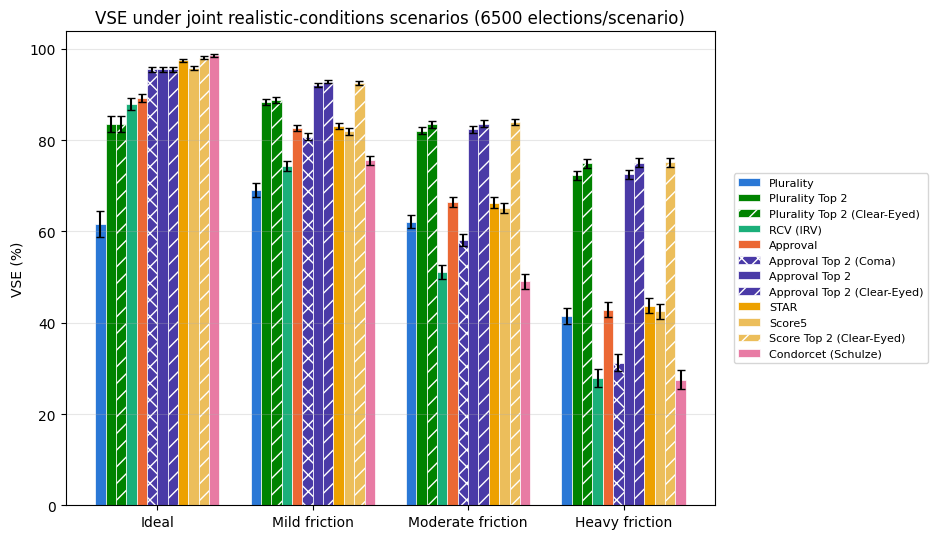

#### Epistemic noise (EPISTEMIC_RHO)

| Method | epistemic_rho=0.00 | epistemic_rho=0.30 | epistemic_rho=0.50 | epistemic_rho=0.70 | epistemic_rho=0.85 | epistemic_rho=1.00 |
|---|---|---|---|---|---|---|
| Plurality | -7.5% (+/-12.0) | 71.4% (+/-4.7) | 76.7% (+/-6.0) | 75.6% (+/-6.4) | 66.5% (+/-7.5) | 61.6% (+/-2.8) |
| Plurality Top 2 | -3.4% (+/-11.9) | 74.1% (+/-4.9) | 85.0% (+/-3.4) | 89.2% (+/-2.8) | 88.8% (+/-3.9) | 83.6% (+/-1.7) |
| Plurality Top 2 (Clear-Eyed) | 51.4% (+/-7.1) | 86.2% (+/-3.9) | 91.4% (+/-2.8) | 90.5% (+/-3.0) | 88.9% (+/-3.9) | 83.6% (+/-1.7) |
| RCV (IRV) | -9.7% (+/-12.5) | 77.9% (+/-4.1) | 85.5% (+/-3.3) | 90.7% (+/-2.2) | 92.4% (+/-1.9) | 87.9% (+/-1.3) |
| Approval | 2.4% (+/-11.7) | 81.7% (+/-3.7) | 89.6% (+/-2.1) | 92.8% (+/-1.7) | 93.2% (+/-1.5) | 89.2% (+/-0.8) |
| Approval Top 2 | 8.0% (+/-11.1) | 79.5% (+/-3.9) | 88.3% (+/-2.6) | 93.6% (+/-1.4) | 94.8% (+/-1.3) | 95.6% (+/-0.5) |
| Approval Top 2 (Clear-Eyed) | 55.4% (+/-6.0) | 89.8% (+/-2.7) | 94.5% (+/-1.6) | 95.9% (+/-1.4) | 96.6% (+/-1.1) | 95.6% (+/-0.5) |
| STAR | 1.3% (+/-11.6) | 82.5% (+/-3.2) | 88.4% (+/-2.5) | 94.6% (+/-1.2) | 95.8% (+/-1.1) | 97.5% (+/-0.3) |
| Score5 | -0.6% (+/-11.8) | 83.9% (+/-3.0) | 90.9% (+/-2.1) | 93.6% (+/-1.4) | 95.4% (+/-1.2) | 95.9% (+/-0.4) |
| Score Top 2 (Clear-Eyed) | 60.6% (+/-5.7) | 93.6% (+/-1.9) | 95.9% (+/-1.3) | 96.6% (+/-1.3) | 97.0% (+/-1.0) | 98.0% (+/-0.3) |
| Condorcet (Schulze) | -0.2% (+/-11.8) | 80.6% (+/-3.7) | 89.7% (+/-2.1) | 93.5% (+/-1.4) | 95.2% (+/-1.6) | 98.6% (+/-0.3) |

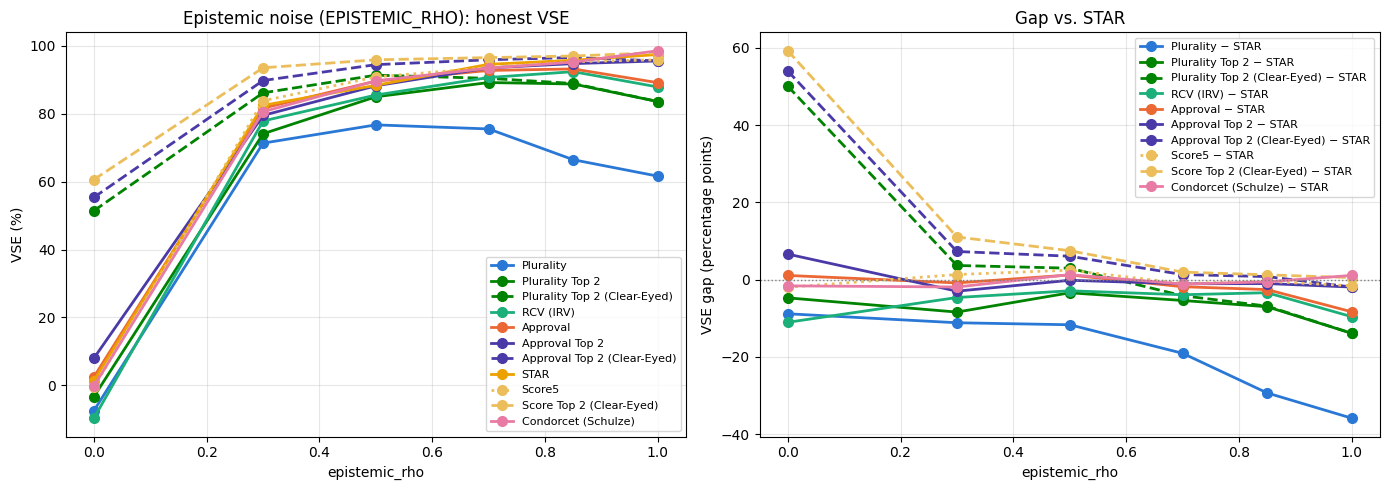

#### Unfamiliarity (AWARENESS_ALPHA)

| Method | awareness_alpha=0.00 | awareness_alpha=0.30 | awareness_alpha=0.50 | awareness_alpha=0.70 | awareness_alpha=0.85 | awareness_alpha=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 4.4% (+/-11.9) | -7.4% (+/-12.2) | -2.7% (+/-11.2) | 50.3% (+/-7.1) | 63.8% (+/-6.7) | 61.6% (+/-2.8) |
| Plurality Top 2 | 60.8% (+/-5.8) | 65.7% (+/-5.2) | 62.6% (+/-5.9) | 78.1% (+/-4.3) | 87.8% (+/-3.3) | 83.6% (+/-1.7) |
| RCV (IRV) | 4.4% (+/-11.9) | -7.4% (+/-12.2) | -9.6% (+/-11.7) | 42.0% (+/-8.0) | 67.0% (+/-5.7) | 87.9% (+/-1.3) |
| Approval | 4.4% (+/-11.9) | -7.4% (+/-12.2) | 1.2% (+/-10.9) | 57.6% (+/-5.8) | 79.1% (+/-3.3) | 89.2% (+/-0.8) |
| Approval Top 2 (Coma) | 4.4% (+/-11.9) | -7.4% (+/-12.2) | -9.6% (+/-11.7) | 50.7% (+/-6.5) | 75.7% (+/-4.3) | 95.6% (+/-0.5) |
| Approval Top 2 | 60.8% (+/-5.8) | 65.7% (+/-5.2) | 63.5% (+/-6.3) | 79.3% (+/-3.7) | 90.8% (+/-2.5) | 95.6% (+/-0.5) |
| STAR | 4.4% (+/-11.9) | -7.4% (+/-12.2) | 2.1% (+/-10.8) | 59.4% (+/-5.6) | 80.5% (+/-3.3) | 97.5% (+/-0.3) |
| Score5 | 4.4% (+/-11.9) | -7.4% (+/-12.2) | -0.4% (+/-11.0) | 58.5% (+/-5.7) | 76.8% (+/-3.7) | 95.9% (+/-0.4) |
| Condorcet (Schulze) | 4.4% (+/-11.9) | -7.4% (+/-12.2) | -9.6% (+/-11.7) | 41.2% (+/-8.1) | 72.4% (+/-5.1) | 98.6% (+/-0.3) |

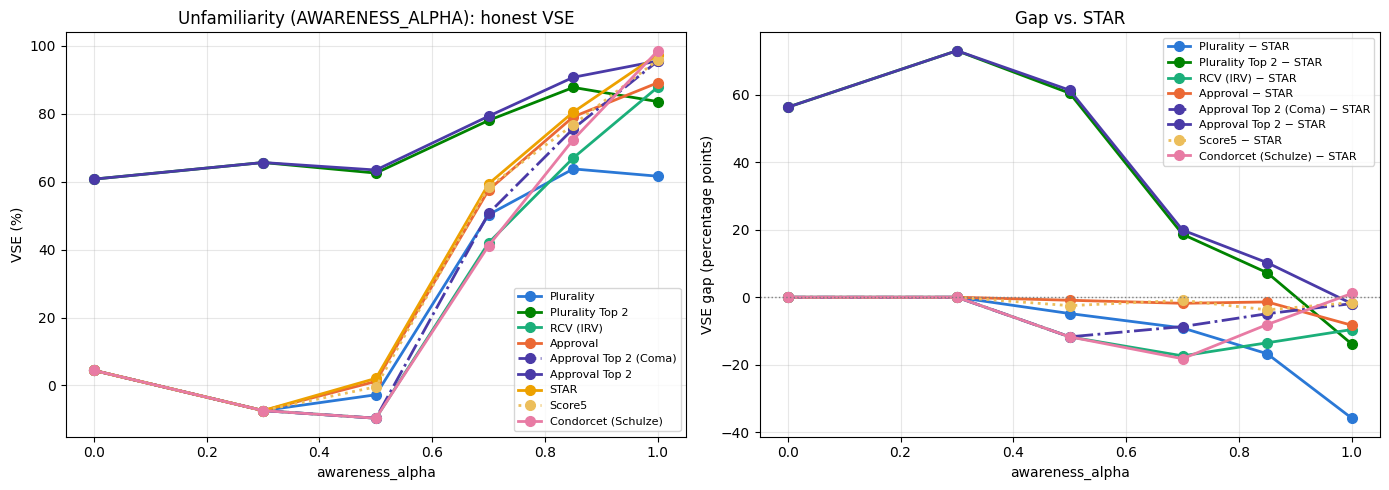

#### Ballot fatigue (FATIGUE_BETA)

| Method | fatigue_beta=0.00 | fatigue_beta=0.30 | fatigue_beta=0.50 | fatigue_beta=0.70 | fatigue_beta=0.85 | fatigue_beta=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 64.0% (+/-7.6) | 61.8% (+/-7.9) | 63.5% (+/-7.4) | 62.9% (+/-7.6) | 63.4% (+/-7.7) | 61.6% (+/-2.8) |
| Plurality Top 2 | 83.5% (+/-4.5) | 82.6% (+/-5.0) | 84.4% (+/-4.3) | 83.5% (+/-4.5) | 83.5% (+/-4.5) | 83.6% (+/-1.7) |
| RCV (IRV) | 61.0% (+/-7.6) | 66.8% (+/-7.0) | 71.5% (+/-6.4) | 73.4% (+/-6.2) | 84.0% (+/-4.2) | 87.9% (+/-1.3) |
| Approval | 62.9% (+/-7.8) | 71.2% (+/-6.5) | 76.0% (+/-5.9) | 85.2% (+/-4.6) | 94.2% (+/-1.6) | 89.2% (+/-0.8) |
| Approval Top 2 | 84.0% (+/-4.3) | 88.1% (+/-3.7) | 91.4% (+/-3.3) | 93.7% (+/-2.5) | 97.6% (+/-1.1) | 95.6% (+/-0.5) |
| STAR | 63.7% (+/-7.4) | 70.6% (+/-6.6) | 75.7% (+/-5.9) | 85.9% (+/-4.4) | 95.7% (+/-1.5) | 97.5% (+/-0.3) |
| Score5 | 63.7% (+/-7.5) | 70.7% (+/-6.5) | 75.7% (+/-5.9) | 85.2% (+/-4.5) | 95.2% (+/-1.6) | 95.9% (+/-0.4) |
| Condorcet (Schulze) | 64.8% (+/-7.0) | 68.0% (+/-6.7) | 73.3% (+/-6.2) | 79.5% (+/-5.2) | 91.8% (+/-3.1) | 98.6% (+/-0.3) |

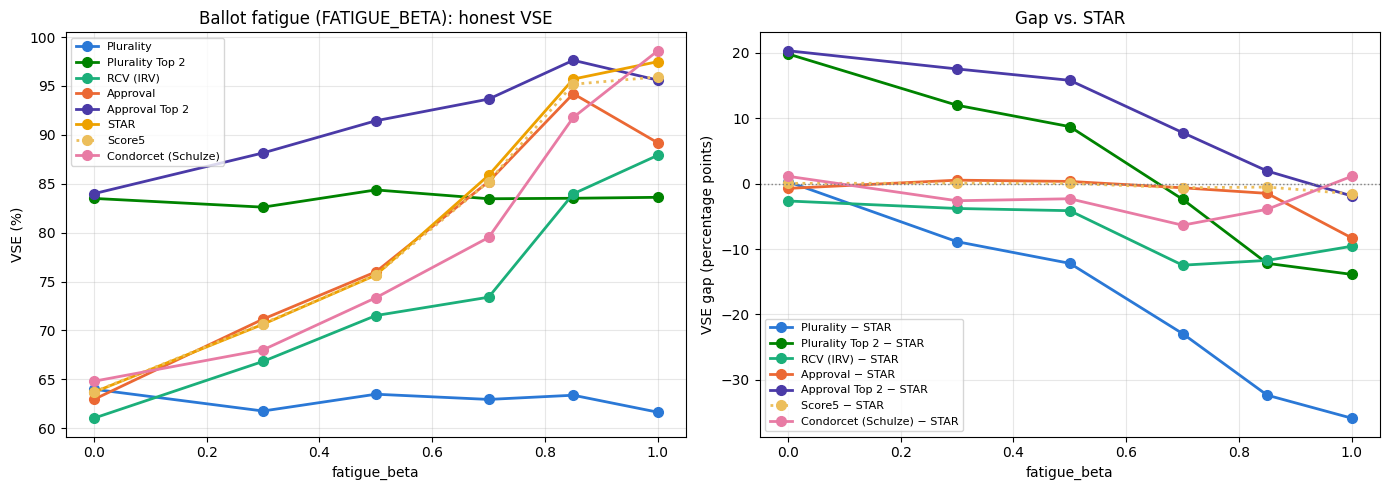

In [161]:
replay("approval-star-gap-scenarios")
replay("star-vse-gap-significant")
replay("vse-joint")
replay("runoff-help-sweep")


### Findings: How much does a delayed runoff actually help?

In [162]:
replay("runoff-vs-baseline")
replay("coma-diagnostic")
replay("coma-vs-groggy")

### Does the runoff help or hurt Approval?

#### Ideal

| Method | Approval VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Approval Top 2 | 89.2 | 95.6 | +6.4 | [+5.7, +7.2] | Yes (runoff better) |

#### Mild friction

| Method | Approval VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Approval Top 2 (Clear-Eyed) | 82.7 | 92.9 | +10.2 | [+9.6, +10.8] | Yes (runoff better) |
| Approval Top 2 | 82.7 | 92.1 | +9.3 | [+8.7, +9.9] | Yes (runoff better) |
| Approval Top 2 (Coma) | 82.7 | 80.8 | -1.9 | [-2.5, -1.3] | Yes (runoff **worse**) |

#### Moderate friction

| Method | Approval VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Approval Top 2 (Clear-Eyed) | 66.5 | 83.6 | +17.1 | [+16.2, +18.0] | Yes (runoff better) |
| Approval Top 2 | 66.5 | 82.4 | +15.8 | [+14.9, +16.8] | Yes (runoff better) |
| Approval Top 2 (Coma) | 66.5 | 58.2 | -8.3 | [-9.3, -7.4] | Yes (runoff **worse**) |

#### Heavy friction

| Method | Approval VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Approval Top 2 (Clear-Eyed) | 42.9 | 75.1 | +32.2 | [+30.8, +33.6] | Yes (runoff better) |
| Approval Top 2 | 42.9 | 72.5 | +29.7 | [+28.2, +31.2] | Yes (runoff better) |
| Approval Top 2 (Coma) | 42.9 | 31.3 | -11.6 | [-12.8, -10.4] | Yes (runoff **worse**) |


### Does the runoff help or hurt Plurality?

#### Ideal

| Method | Plurality VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Plurality Top 2 | 61.6 | 83.6 | +22.0 | [+19.7, +24.3] | Yes (runoff better) |

#### Mild friction

| Method | Plurality VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Plurality Top 2 (Clear-Eyed) | 69.1 | 88.9 | +19.8 | [+18.5, +21.1] | Yes (runoff better) |
| Plurality Top 2 | 69.1 | 88.3 | +19.3 | [+18.0, +20.6] | Yes (runoff better) |

#### Moderate friction

| Method | Plurality VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Plurality Top 2 (Clear-Eyed) | 62.1 | 83.5 | +21.3 | [+20.1, +22.5] | Yes (runoff better) |
| Plurality Top 2 | 62.1 | 82.1 | +19.9 | [+18.7, +21.1] | Yes (runoff better) |

#### Heavy friction

| Method | Plurality VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Plurality Top 2 (Clear-Eyed) | 41.5 | 74.9 | +33.4 | [+31.9, +34.9] | Yes (runoff better) |
| Plurality Top 2 | 41.5 | 72.3 | +30.8 | [+29.3, +32.3] | Yes (runoff better) |


#### Coma AT2: why voters end up voting against their own pairwise interest

| Scenario | Aligned | Awareness-attributable | Noise-unfixable (even if Groggy) |
|---|---|---|---|
| Ideal | 100.0% | 0.0% | 0.0% |
| Mild friction | 71.2% | 11.1% | 17.7% |
| Moderate friction | 65.8% | 14.8% | 19.4% |
| Heavy friction | 62.9% | 16.1% | 21.0% |

#### Coma AT2: detailed breakdown

| Scenario | Wrong (awareness-fixable) | Wrong (noise-unfixable) | Abstained (awareness-fixable) | Abstained (noise-unfixable) |
|---|---|---|---|---|
| Ideal | 0.0% | 0.0% | 0.0% | 0.0% |
| Mild friction | 10.0% | 17.4% | 1.1% | 0.3% |
| Moderate friction | 13.3% | 18.9% | 1.5% | 0.5% |
| Heavy friction | 15.3% | 20.7% | 0.8% | 0.3% |

#### Coma vs Groggy: election-level aggregate-sign accuracy (does the runoff decision match the true preference?)

| Scenario | Coma correct | Groggy correct | Both correct | Coma-only correct | Groggy-only correct | Both wrong |
|---|---|---|---|---|---|---|
| Ideal | 100.0% | 100.0% | 100.0% | 0.0% | 0.0% | 0.0% |
| Mild friction | 60.2% | 85.2% | 53.7% | 6.5% | 31.5% | 8.3% |
| Moderate friction | 51.2% | 85.4% | 43.6% | 7.6% | 41.8% | 7.0% |
| Heavy friction | 46.0% | 85.8% | 38.5% | 7.5% | 47.4% | 6.6% |

This is the metric that actually drives the VSE gap -- an election's outcome depends on the AGGREGATE runoff decision, not per-voter accuracy. "Groggy-only correct" is the direct empirical signature of the amplification: elections where fixing awareness alone flips the runoff's aggregate decision from wrong to right, even though the underlying per-voter fix (the `awareness_attributable` rate above) is comparatively modest.

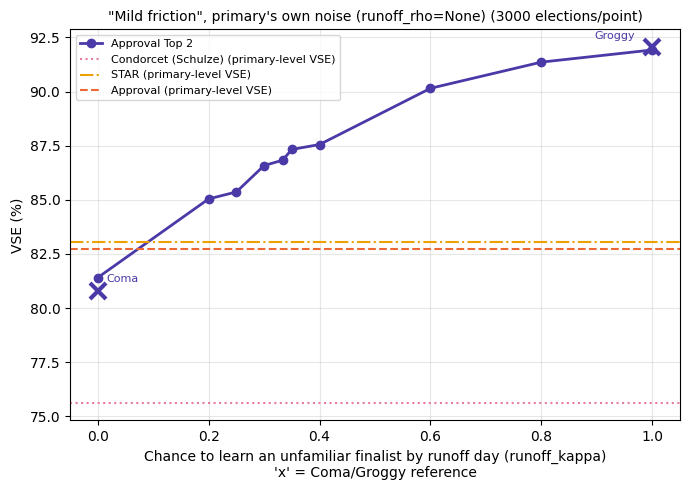

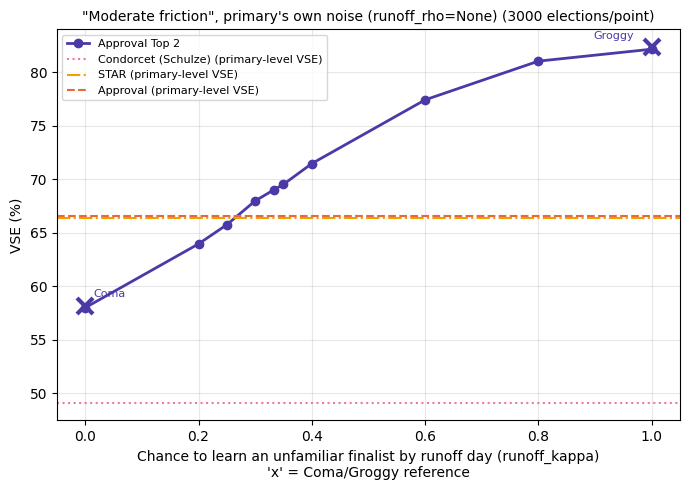

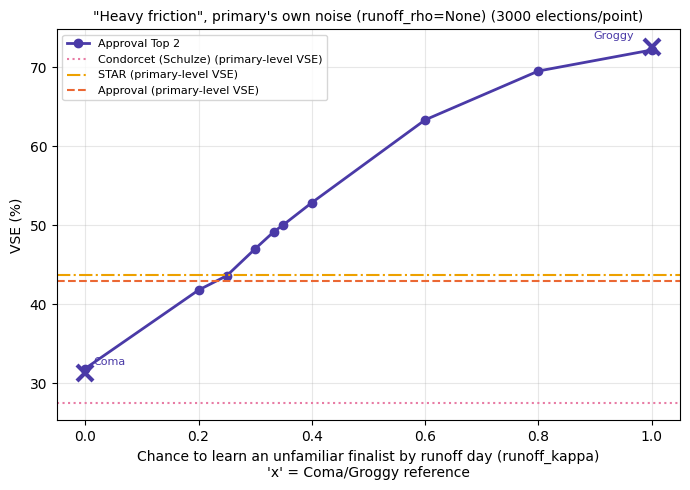

### kappa threshold for AT2 VSE > STAR VSE (95% confidence, paired)


#### Mild friction

| kappa | AT2 VSE (%) | STAR VSE (%) | Gap (pp, paired) | 95% CI (paired, pp) | AT2 > STAR? |
|---|---|---|---|---|---|
| 0.00 | 81.4 | 84.0 (+/-1.0) | -2.6 | [-3.4, -1.8] | No |
| 0.20 | 85.0 | 84.0 (+/-1.0) | +1.0 | [+0.3, +1.8] | Yes |
| 0.25 | 85.4 | 84.0 (+/-1.0) | +1.4 | [+0.6, +2.1] | Yes |
| 0.30 | 86.6 | 84.0 (+/-1.0) | +2.6 | [+1.9, +3.3] | Yes |
| 0.33 | 86.8 | 84.0 (+/-1.0) | +2.8 | [+2.1, +3.6] | Yes |
| 0.35 | 87.3 | 84.0 (+/-1.0) | +3.3 | [+2.6, +4.1] | Yes |
| 0.40 | 87.6 | 84.0 (+/-1.0) | +3.6 | [+2.8, +4.3] | Yes |
| 0.60 | 90.2 | 84.0 (+/-1.0) | +6.1 | [+5.3, +7.0] | Yes |
| 0.80 | 91.4 | 84.0 (+/-1.0) | +7.4 | [+6.6, +8.2] | Yes |
| 1.00 | 91.9 | 84.0 (+/-1.0) | +7.9 | [+7.1, +8.8] | Yes |

**-> First kappa where AT2 is significantly better than STAR (95% CI gap > 0): `kappa ~ 0.20`**


#### Moderate friction

| kappa | AT2 VSE (%) | STAR VSE (%) | Gap (pp, paired) | 95% CI (paired, pp) | AT2 > STAR? |
|---|---|---|---|---|---|
| 0.00 | 58.0 | 66.8 (+/-1.6) | -8.8 | [-10.2, -7.4] | No |
| 0.20 | 64.0 | 66.8 (+/-1.6) | -2.8 | [-4.0, -1.6] | No |
| 0.25 | 65.8 | 66.8 (+/-1.6) | -1.0 | [-2.2, +0.2] | No (CI contains 0) |
| 0.30 | 68.0 | 66.8 (+/-1.6) | +1.2 | [+0.1, +2.3] | Yes |
| 0.33 | 69.0 | 66.8 (+/-1.6) | +2.3 | [+1.1, +3.4] | Yes |
| 0.35 | 69.5 | 66.8 (+/-1.6) | +2.8 | [+1.6, +3.9] | Yes |
| 0.40 | 71.5 | 66.8 (+/-1.6) | +4.7 | [+3.6, +5.8] | Yes |
| 0.60 | 77.4 | 66.8 (+/-1.6) | +10.7 | [+9.4, +11.9] | Yes |
| 0.80 | 81.1 | 66.8 (+/-1.6) | +14.3 | [+12.9, +15.6] | Yes |
| 1.00 | 82.2 | 66.8 (+/-1.6) | +15.4 | [+14.1, +16.7] | Yes |

**-> First kappa where AT2 is significantly better than STAR (95% CI gap > 0): `kappa ~ 0.30`**


#### Heavy friction

| kappa | AT2 VSE (%) | STAR VSE (%) | Gap (pp, paired) | 95% CI (paired, pp) | AT2 > STAR? |
|---|---|---|---|---|---|
| 0.00 | 31.8 | 43.1 (+/-2.4) | -11.3 | [-13.0, -9.5] | No |
| 0.20 | 41.8 | 43.1 (+/-2.4) | -1.3 | [-2.8, +0.1] | No (CI contains 0) |
| 0.25 | 43.6 | 43.1 (+/-2.4) | +0.5 | [-0.9, +1.9] | No (CI contains 0) |
| 0.30 | 47.0 | 43.1 (+/-2.4) | +3.9 | [+2.4, +5.4] | Yes |
| 0.33 | 49.2 | 43.1 (+/-2.4) | +6.1 | [+4.5, +7.6] | Yes |
| 0.35 | 50.0 | 43.1 (+/-2.4) | +6.9 | [+5.4, +8.5] | Yes |
| 0.40 | 52.8 | 43.1 (+/-2.4) | +9.7 | [+8.1, +11.4] | Yes |
| 0.60 | 63.3 | 43.1 (+/-2.4) | +20.2 | [+18.3, +22.1] | Yes |
| 0.80 | 69.5 | 43.1 (+/-2.4) | +26.4 | [+24.4, +28.4] | Yes |
| 1.00 | 72.2 | 43.1 (+/-2.4) | +29.1 | [+27.0, +31.1] | Yes |

**-> First kappa where AT2 is significantly better than STAR (95% CI gap > 0): `kappa ~ 0.30`**


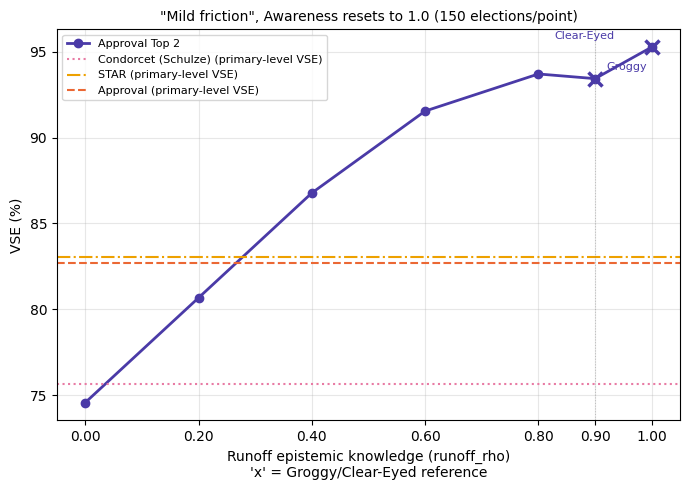

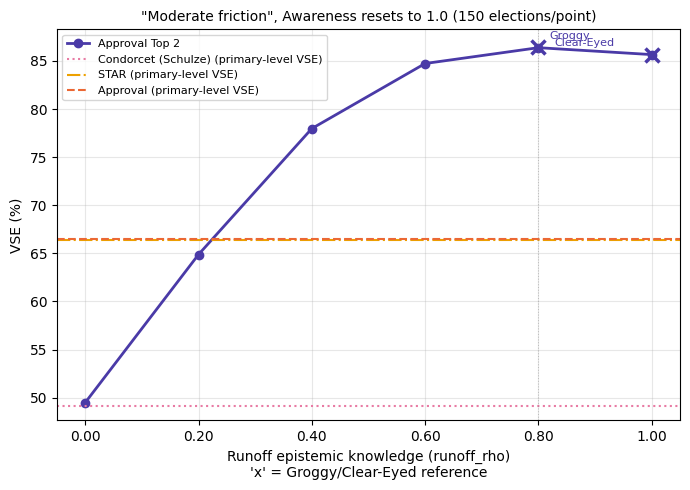

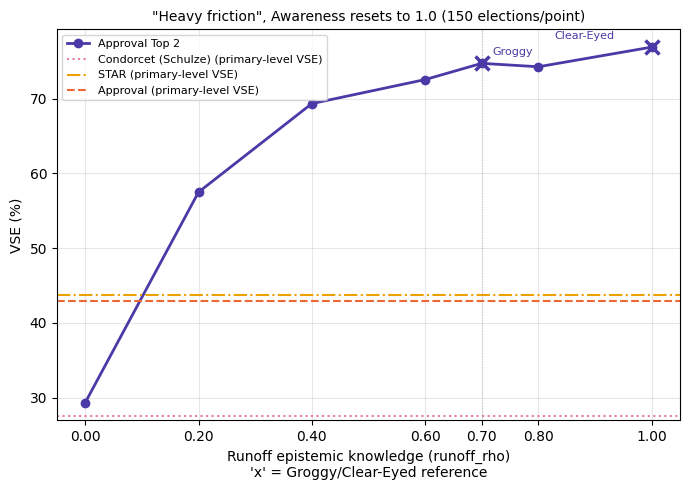

In [163]:
replay("runoff-learn-sweep")
replay("p-learn-ci-table")
replay("runoff-t-sweep")

### Findings: STAR Runoff Betrayal

In [164]:
replay("star-betrayal-tables")
replay("scoret2-vs-at2")

#### Runoff betrayal rate by joint-friction scenario

| Scenario | Betrayal rate | Voter corruption rate | VSE (STAR's actual runoff) | VSE (honest/delayed-perfect runoff) | VSE (AT2 Clear-Eyed runoff) |
|---|---|---|---|---|---|
| Ideal | 0.0% | 0.00% | 97.5% | 97.5% (+0.0 pts over actual) | 95.6% (-1.9 pts over STAR) |
| Mild friction | 33.8% | 35.68% | 83.1% | 90.7% (+7.7 pts over actual) | 92.9% (+9.8 pts over STAR) |
| Moderate friction | 39.0% | 45.56% | 66.3% | 82.1% (+15.7 pts over actual) | 83.6% (+17.3 pts over STAR) |
| Heavy friction | 44.8% | 49.26% | 43.7% | 71.4% (+27.7 pts over actual) | 75.1% (+31.4 pts over STAR) |

#### Score Top 2 (Clear-Eyed) vs Approval Top 2 (Clear-Eyed): paired VSE gap by joint-friction scenario

| Scenario | Score Top 2 VSE (%) | AT2 VSE (%) | Gap vs AT2 (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 98.0 | 95.6 | +2.4 | [+2.0, +2.9] | Yes (Score Top 2 better) |
| Mild friction | 92.6 | 92.9 | -0.3 | [-0.6, -0.0] | Yes (AT2 better) |
| Moderate friction | 84.0 | 83.6 | +0.3 | [-0.0, +0.7] | No (CI contains 0) |
| Heavy friction | 75.1 | 75.1 | +0.1 | [-0.2, +0.4] | No (CI contains 0) |

### Appendix: The Plurality Bump

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 61.6% (+/-2.8) | 69.1% (+/-1.5) | 62.1% (+/-1.4) | 41.5% (+/-1.7) |
| Plurality Top 2 | 83.6% (+/-1.7) | 88.3% (+/-0.7) | 82.1% (+/-0.8) | 72.3% (+/-1.0) |
| Plurality Top 2 (Clear-Eyed) | 83.6% (+/-1.7) | 88.9% (+/-0.7) | 83.5% (+/-0.8) | 74.9% (+/-1.0) |
| Approval Top 2 (Clear-Eyed) | 95.6% (+/-0.5) | 92.9% (+/-0.4) | 83.6% (+/-0.7) | 75.1% (+/-1.0) |

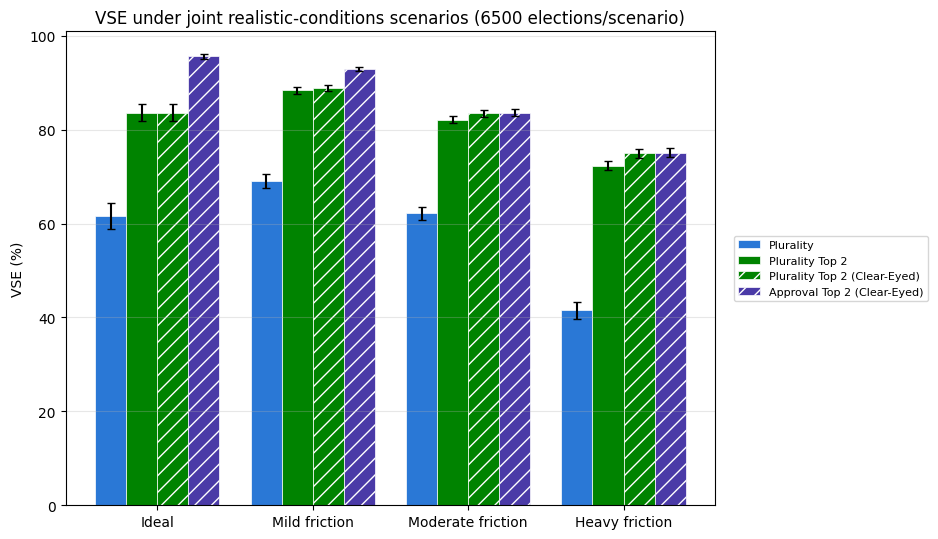

In [165]:
replay("plurality-bump")

### Appendix: Approval vs Plurality

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 61.6% (+/-2.8) | 69.1% (+/-1.5) | 62.1% (+/-1.4) | 41.5% (+/-1.7) |
| Approval | 89.2% (+/-0.8) | 82.7% (+/-0.7) | 66.5% (+/-1.1) | 42.9% (+/-1.7) |

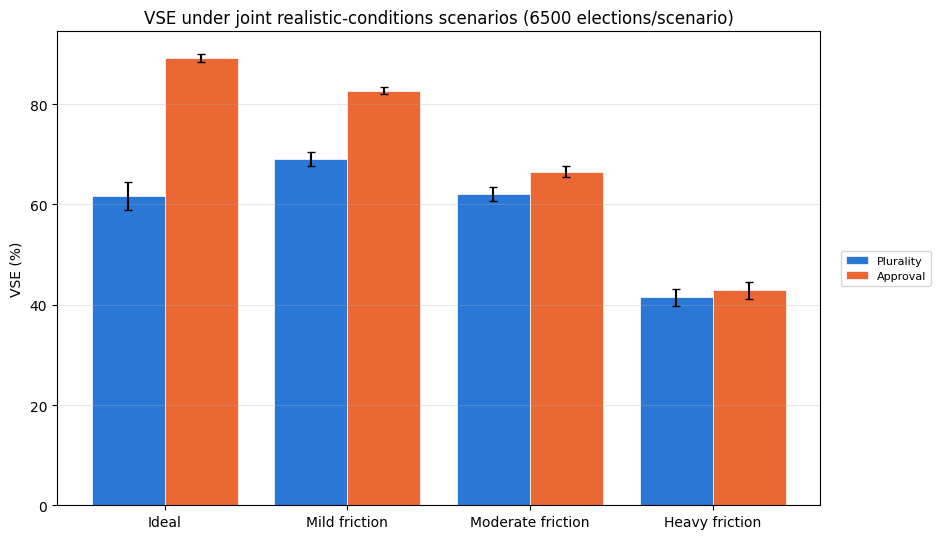

#### Approval vs Plurality: paired VSE gap by joint-friction scenario

| Scenario | Approval VSE (%) | Plurality VSE (%) | Gap vs Plurality (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 89.2 | 61.6 | +27.5 | [+24.5, +30.6] | Yes (Approval better) |
| Mild friction | 82.7 | 69.1 | +13.6 | [+12.2, +15.1] | Yes (Approval better) |
| Moderate friction | 66.5 | 62.1 | +4.4 | [+3.4, +5.4] | Yes (Approval better) |
| Heavy friction | 42.9 | 41.5 | +1.4 | [+0.7, +2.1] | Yes (Approval better) |

#### Approval Top 2 vs Plurality Top 2: paired VSE gap by joint-friction scenario

| Scenario | AT2 VSE (%) | PT2 VSE (%) | Gap vs PT2 (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 95.6 | 83.6 | +12.0 | [+10.1, +13.8] | Yes (AT2 better) |
| Mild friction | 92.1 | 88.3 | +3.7 | [+3.0, +4.4] | Yes (AT2 better) |
| Moderate friction | 82.4 | 82.1 | +0.3 | [-0.3, +0.8] | No (CI contains 0) |
| Heavy friction | 72.5 | 72.3 | +0.2 | [-0.3, +0.7] | No (CI contains 0) |

#### Approval Top 2 (Clear-Eyed) vs Plurality Top 2 (Clear-Eyed): paired VSE gap by joint-friction scenario

| Scenario | AT2 VSE (%) | PT2 VSE (%) | Gap vs PT2 (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 95.6 | 83.6 | +12.0 | [+10.1, +13.8] | Yes (AT2 better) |
| Mild friction | 92.9 | 88.9 | +4.0 | [+3.3, +4.7] | Yes (AT2 better) |
| Moderate friction | 83.6 | 83.5 | +0.2 | [-0.4, +0.7] | No (CI contains 0) |
| Heavy friction | 75.1 | 74.9 | +0.1 | [-0.3, +0.6] | No (CI contains 0) |

#### Ideal: VSE by candidate count (NCAND)

| ncand | Approval Top 2 VSE (%) | Plurality Top 2 VSE (%) | Gap (pp) |
|---|---|---|---|
| 3 | 97.1% (+/-1.1) | 90.5% (+/-2.1) | +6.6 |
| 5 | 97.2% (+/-0.5) | 85.2% (+/-2.4) | +12.0 |
| 6 | 95.5% (+/-0.8) | 81.4% (+/-2.8) | +14.0 |
| 8 | 94.2% (+/-0.9) | 80.4% (+/-2.6) | +13.8 |
| 10 | 93.7% (+/-0.8) | 79.8% (+/-2.4) | +13.9 |
| 15 | 88.3% (+/-1.2) | 74.2% (+/-2.8) | +14.1 |

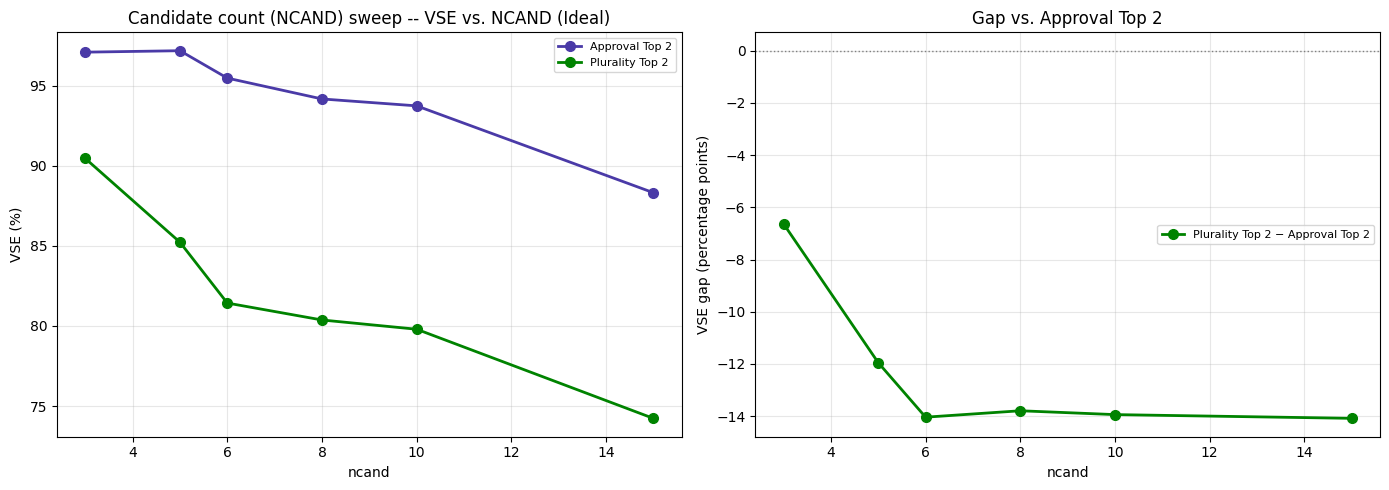

#### Mild friction: VSE by candidate count (NCAND)

| ncand | Approval Top 2 VSE (%) | Plurality Top 2 VSE (%) | Gap (pp) |
|---|---|---|---|
| 3 | 95.9% (+/-1.3) | 92.3% (+/-1.9) | +3.6 |
| 5 | 93.7% (+/-1.0) | 90.3% (+/-1.6) | +3.4 |
| 6 | 91.6% (+/-1.1) | 87.3% (+/-1.8) | +4.3 |
| 8 | 89.6% (+/-1.1) | 85.9% (+/-1.8) | +3.7 |
| 10 | 86.7% (+/-1.3) | 82.3% (+/-2.1) | +4.4 |
| 15 | 85.8% (+/-1.2) | 83.2% (+/-1.7) | +2.5 |

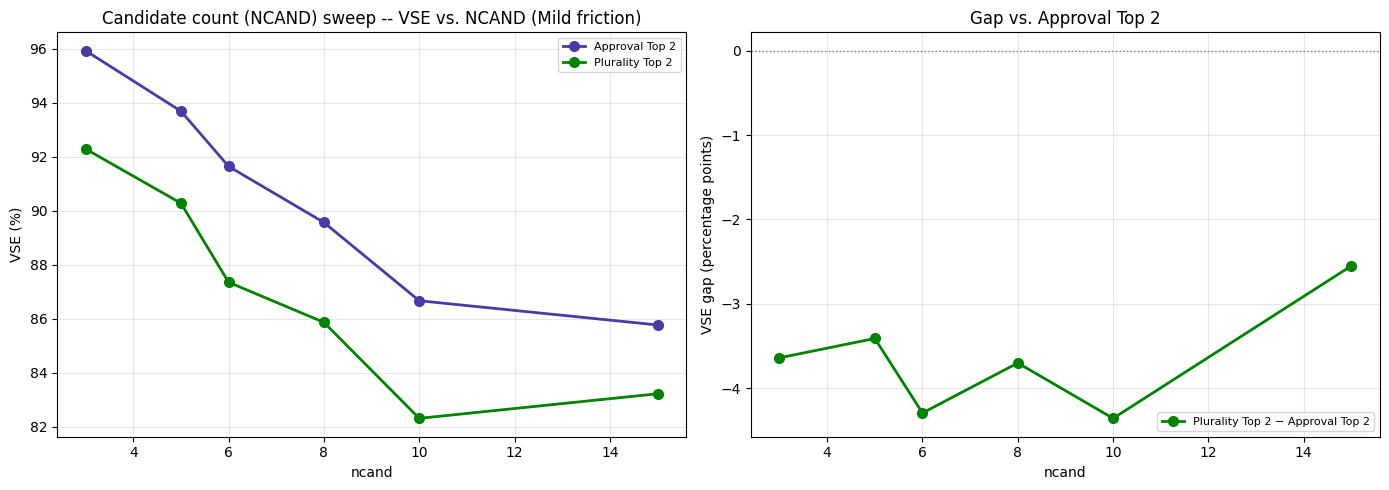

#### Moderate friction: VSE by candidate count (NCAND)

| ncand | Approval Top 2 VSE (%) | Plurality Top 2 VSE (%) | Gap (pp) |
|---|---|---|---|
| 3 | 92.1% (+/-1.7) | 90.2% (+/-2.0) | +1.8 |
| 5 | 84.6% (+/-2.0) | 84.6% (+/-1.9) | -0.0 |
| 6 | 81.4% (+/-1.9) | 82.1% (+/-1.9) | -0.6 |
| 8 | 79.7% (+/-1.9) | 80.0% (+/-1.8) | -0.3 |
| 10 | 78.5% (+/-1.8) | 76.7% (+/-2.0) | +1.7 |
| 15 | 76.2% (+/-1.9) | 76.1% (+/-1.8) | +0.1 |

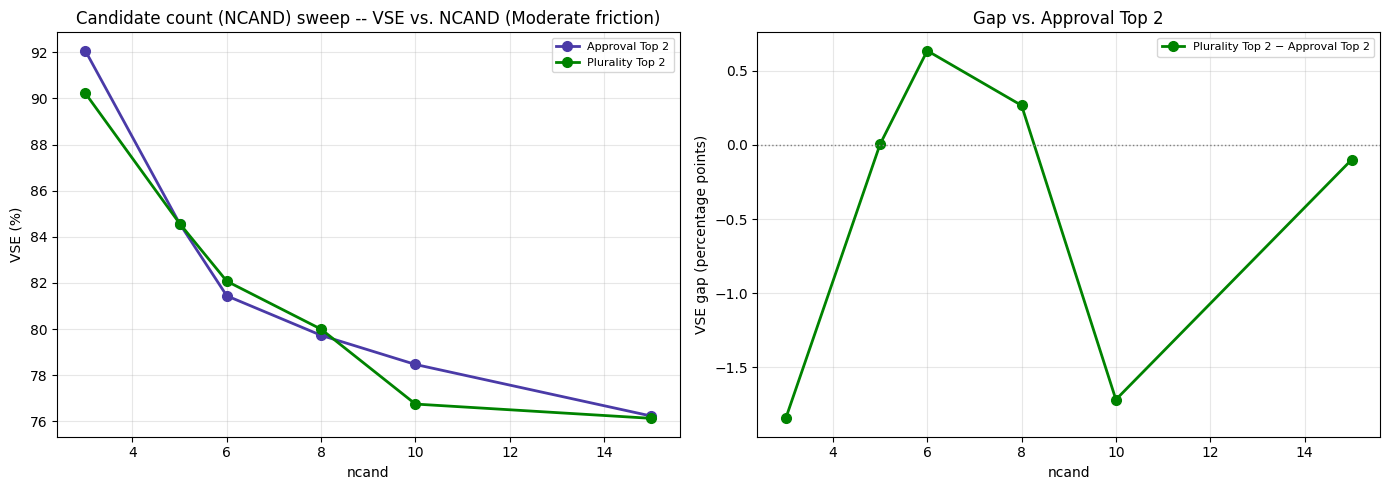

#### Heavy friction: VSE by candidate count (NCAND)

| ncand | Approval Top 2 VSE (%) | Plurality Top 2 VSE (%) | Gap (pp) |
|---|---|---|---|
| 3 | 86.4% (+/-2.2) | 85.6% (+/-2.3) | +0.9 |
| 5 | 75.5% (+/-2.4) | 74.7% (+/-2.5) | +0.9 |
| 6 | 72.2% (+/-2.6) | 72.3% (+/-2.6) | -0.2 |
| 8 | 69.6% (+/-2.5) | 70.2% (+/-2.5) | -0.6 |
| 10 | 69.6% (+/-2.5) | 70.0% (+/-2.4) | -0.4 |
| 15 | 67.0% (+/-2.3) | 67.5% (+/-2.3) | -0.5 |

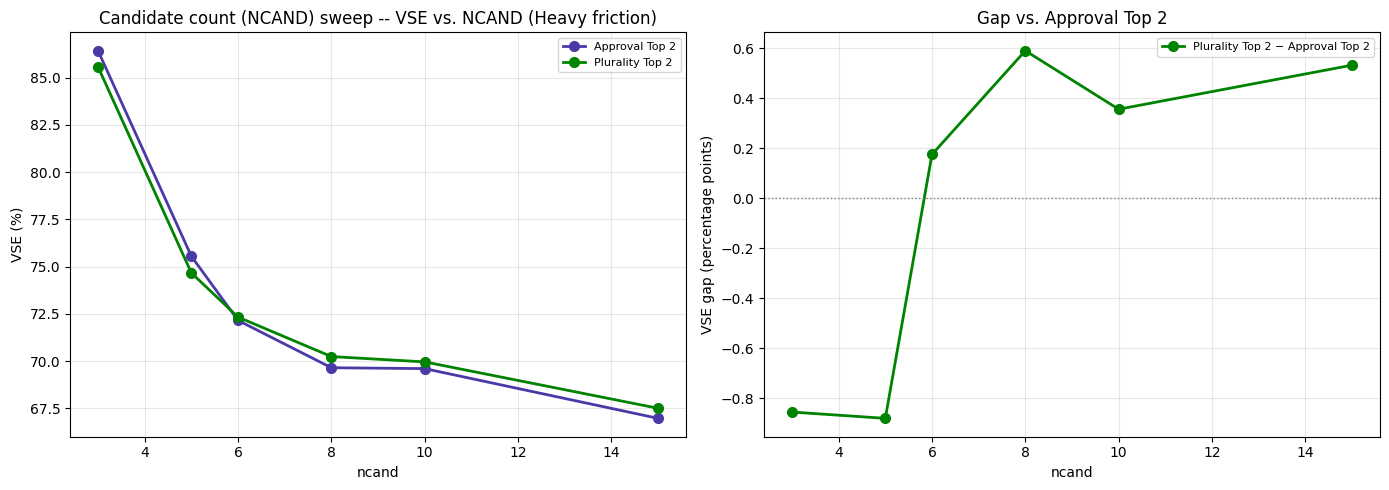

#### Ideal

| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |
|---:|---:|---:|---:|---:|---:|
| 3 | 97.09% | 90.46% | +6.64 | [+4.74, +8.54] | Yes (Approval better) |
| 5 | 97.18% | 85.23% | +11.95 | [+9.46, +14.45] | Yes (Approval better) |
| 6 | 95.47% | 81.43% | +14.04 | [+11.14, +16.94] | Yes (Approval better) |
| 8 | 94.17% | 80.38% | +13.80 | [+11.04, +16.55] | Yes (Approval better) |
| 10 | 93.74% | 79.80% | +13.94 | [+11.32, +16.56] | Yes (Approval better) |
| 15 | 88.32% | 74.24% | +14.09 | [+11.01, +17.16] | Yes (Approval better) |

#### Mild friction

| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |
|---:|---:|---:|---:|---:|---:|
| 3 | 95.93% | 92.29% | +3.64 | [+2.09, +5.19] | Yes (Approval better) |
| 5 | 93.69% | 90.28% | +3.41 | [+1.83, +4.99] | Yes (Approval better) |
| 6 | 91.64% | 87.35% | +4.29 | [+2.53, +6.05] | Yes (Approval better) |
| 8 | 89.56% | 85.86% | +3.70 | [+1.91, +5.49] | Yes (Approval better) |
| 10 | 86.66% | 82.31% | +4.36 | [+2.33, +6.39] | Yes (Approval better) |
| 15 | 85.77% | 83.22% | +2.55 | [+0.92, +4.18] | Yes (Approval better) |

#### Moderate friction

| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |
|---:|---:|---:|---:|---:|---:|
| 3 | 92.07% | 90.23% | +1.84 | [+0.38, +3.30] | Yes (Approval better) |
| 5 | 84.57% | 84.58% | -0.00 | [-1.48, +1.47] | No (CI contains 0) |
| 6 | 81.44% | 82.07% | -0.63 | [-1.84, +0.57] | No (CI contains 0) |
| 8 | 79.73% | 79.99% | -0.27 | [-1.58, +1.05] | No (CI contains 0) |
| 10 | 78.46% | 76.75% | +1.72 | [+0.42, +3.02] | Yes (Approval better) |
| 15 | 76.23% | 76.13% | +0.10 | [-0.89, +1.09] | No (CI contains 0) |

#### Heavy friction

| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |
|---:|---:|---:|---:|---:|---:|
| 3 | 86.42% | 85.57% | +0.86 | [-0.19, +1.90] | No (CI contains 0) |
| 5 | 75.55% | 74.66% | +0.88 | [-0.38, +2.14] | No (CI contains 0) |
| 6 | 72.15% | 72.33% | -0.18 | [-1.47, +1.12] | No (CI contains 0) |
| 8 | 69.65% | 70.24% | -0.59 | [-1.63, +0.45] | No (CI contains 0) |
| 10 | 69.60% | 69.96% | -0.36 | [-1.54, +0.83] | No (CI contains 0) |
| 15 | 66.97% | 67.50% | -0.53 | [-1.19, +0.12] | No (CI contains 0) |

In [166]:
replay("plurality-vs-approval")
replay("plurality-approval-ci")
replay("at2-pt2-ci")
replay("at2-pt2-candidate-sweep")
replay("at2-pt2-candidate-ci")

### Appendix: SCORE vs STAR

#### STAR vs. Score5 by `epistemic_rho`

| Method | epistemic_rho=0.00 | epistemic_rho=0.30 | epistemic_rho=0.50 | epistemic_rho=0.70 | epistemic_rho=0.85 | epistemic_rho=1.00 |
|---|---|---|---|---|---|---|
| Score5 | -0.6% (+/-11.8) | 83.9% (+/-3.0) | 90.9% (+/-2.1) | 93.6% (+/-1.4) | 95.4% (+/-1.2) | 95.9% (+/-0.4) |
| STAR | 1.3% (+/-11.6) | 82.5% (+/-3.2) | 88.4% (+/-2.5) | 94.6% (+/-1.2) | 95.8% (+/-1.1) | 97.5% (+/-0.3) |

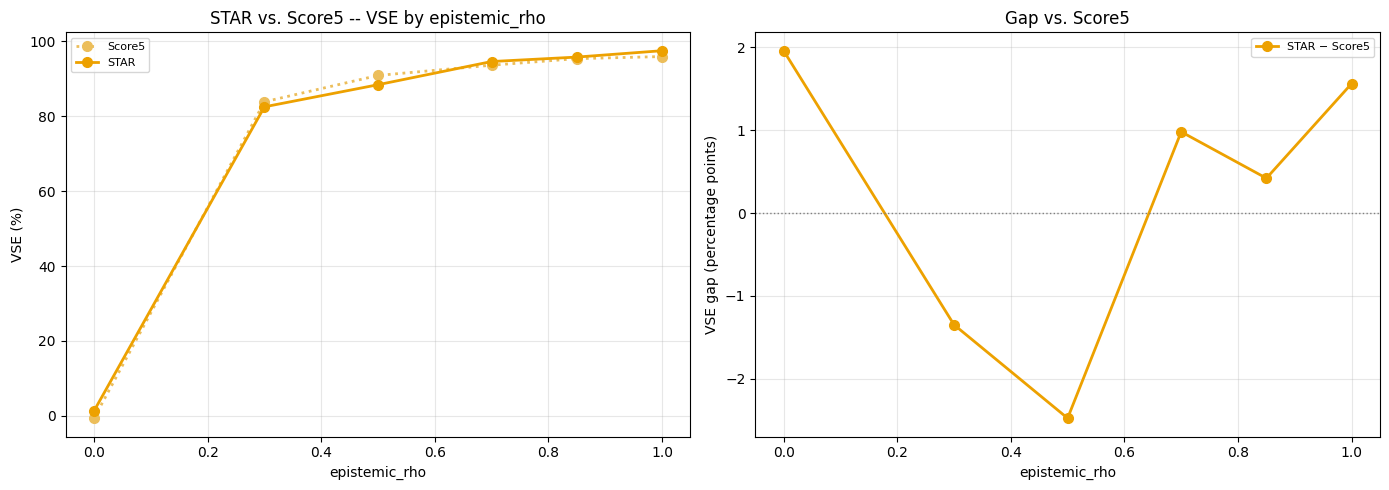

#### STAR vs. Score5 by `awareness_alpha`

| Method | awareness_alpha=0.00 | awareness_alpha=0.30 | awareness_alpha=0.50 | awareness_alpha=0.70 | awareness_alpha=0.85 | awareness_alpha=1.00 |
|---|---|---|---|---|---|---|
| Score5 | 4.4% (+/-11.9) | -7.4% (+/-12.2) | -0.4% (+/-11.0) | 58.5% (+/-5.7) | 76.8% (+/-3.7) | 95.9% (+/-0.4) |
| STAR | 4.4% (+/-11.9) | -7.4% (+/-12.2) | 2.1% (+/-10.8) | 59.4% (+/-5.6) | 80.5% (+/-3.3) | 97.5% (+/-0.3) |

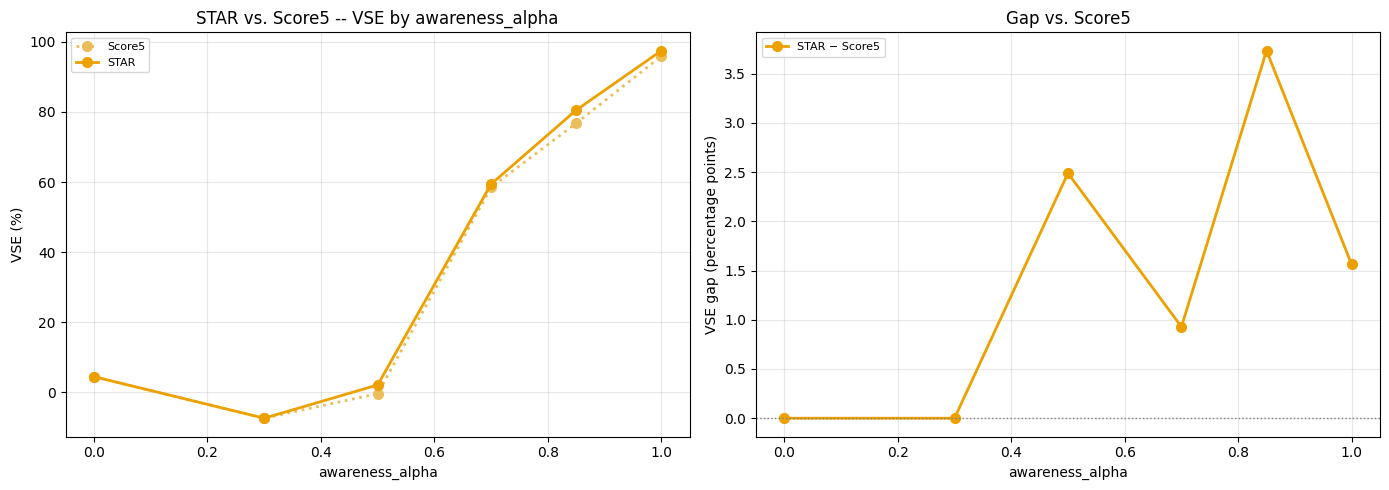

#### STAR vs. Score5 by `fatigue_beta`

| Method | fatigue_beta=0.00 | fatigue_beta=0.30 | fatigue_beta=0.50 | fatigue_beta=0.70 | fatigue_beta=0.85 | fatigue_beta=1.00 |
|---|---|---|---|---|---|---|
| Score5 | 63.7% (+/-7.5) | 70.7% (+/-6.5) | 75.7% (+/-5.9) | 85.2% (+/-4.5) | 95.2% (+/-1.6) | 95.9% (+/-0.4) |
| STAR | 63.7% (+/-7.4) | 70.6% (+/-6.6) | 75.7% (+/-5.9) | 85.9% (+/-4.4) | 95.7% (+/-1.5) | 97.5% (+/-0.3) |

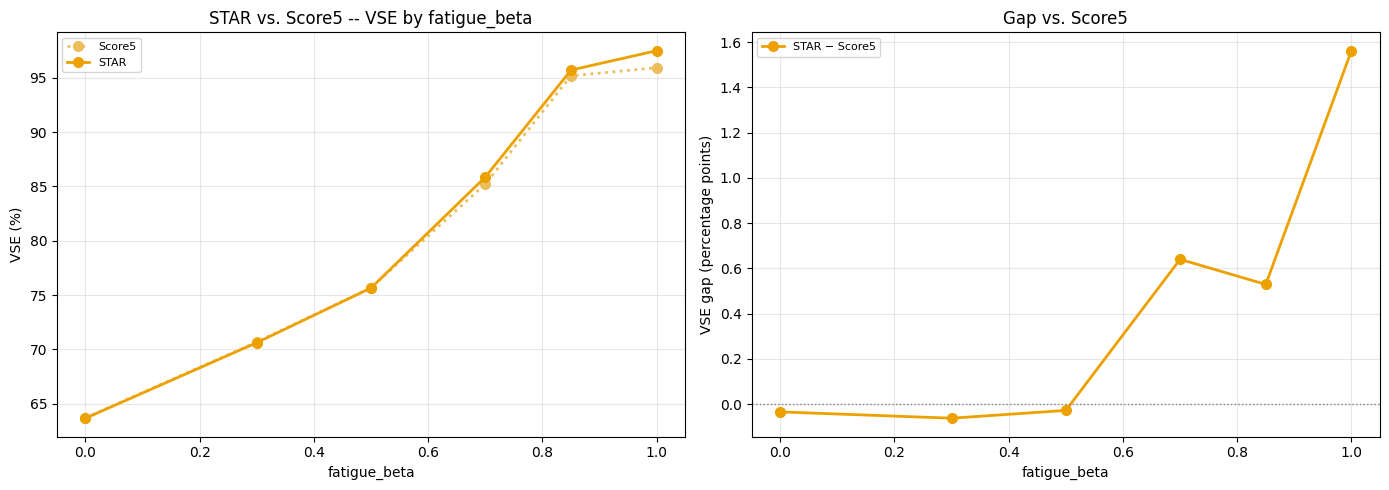

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Score5 | 95.9% (+/-0.4) | 81.9% (+/-0.7) | 65.2% (+/-1.2) | 42.5% (+/-1.7) |
| STAR | 97.5% (+/-0.3) | 83.1% (+/-0.7) | 66.3% (+/-1.1) | 43.7% (+/-1.7) |

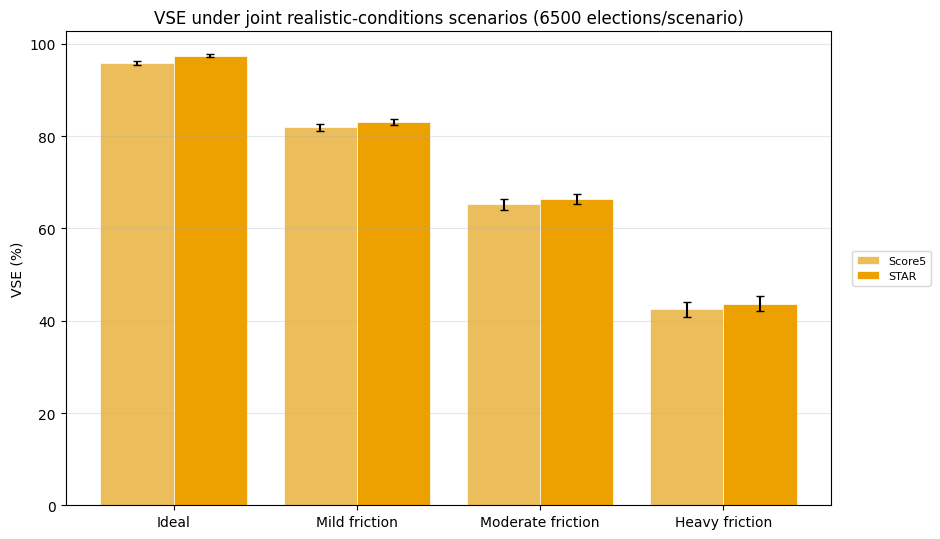

#### Score5 vs STAR: paired VSE gap by joint-friction scenario

| Scenario | Score VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 95.9 | 97.5 | -1.6 | [-1.9, -1.2] | Yes (STAR better) |
| Mild friction | 81.9 | 83.1 | -1.1 | [-1.6, -0.7] | Yes (STAR better) |
| Moderate friction | 65.2 | 66.3 | -1.1 | [-1.6, -0.7] | Yes (STAR better) |
| Heavy friction | 42.5 | 43.7 | -1.2 | [-1.7, -0.8] | Yes (STAR better) |

In [167]:
replay("score-vs-star")
replay("score-vs-star-scenarios")

### Appendix: 99% Confidence Check

In [168]:
replay("not-sig-at-99-part1")

### 3 result(s) lose significance at 99% confidence


- **kappa threshold: Moderate friction -- kappa=0.30**: at 95% confidence, **Approval Top 2** appeared better than **STAR** by 1.2pp (95% CI [+0.1, +2.3]) -- but at 99% confidence that edge is no longer significant (99% CI [-0.2, +2.6], which contains 0).
- **Score Top 2 (Clear-Eyed) vs Approval Top 2 (Clear-Eyed) -- Mild friction**: at 95% confidence, **AT2** appeared better than **Score Top 2** by 0.3pp (95% CI [-0.6, -0.0]) -- but at 99% confidence that edge is no longer significant (99% CI [-0.7, +0.1], which contains 0).
- **AT2 vs PT2 by candidate count: Moderate friction -- NCAND=3**: at 95% confidence, **Approval Top 2** appeared better than **Plurality Top 2** by 1.8pp (95% CI [+0.4, +3.3]) -- but at 99% confidence that edge is no longer significant (99% CI [-0.1, +3.8], which contains 0).

In [169]:
replay("still-sig-at-99-part1")

### Spotlight: does each headline claim hold up at 99% confidence?


#### Approval-flavor gaps vs STAR: Ideal

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top 2 | -1.9 | STAR better | STAR better |
| Plurality Top 2 | -13.9 | STAR better | STAR better |

#### Approval-flavor gaps vs STAR: Mild friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top 2 | +9.0 | Approval Top 2 better | Approval Top 2 better |
| Plurality Top 2 | +5.3 | Plurality Top 2 better | Plurality Top 2 better |

#### Approval-flavor gaps vs STAR: Moderate friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top 2 | +16.0 | Approval Top 2 better | Approval Top 2 better |
| Plurality Top 2 | +15.7 | Plurality Top 2 better | Plurality Top 2 better |

#### Approval-flavor gaps vs STAR: Heavy friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top 2 | +28.8 | Approval Top 2 better | Approval Top 2 better |
| Plurality Top 2 | +28.6 | Plurality Top 2 better | Plurality Top 2 better |

...

#### kappa threshold: Heavy friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| kappa=0.00 | -11.3 | STAR better | STAR better |
| kappa=0.20 | -1.3 | No sig. difference | No sig. difference |
| kappa=0.25 | +0.5 | No sig. difference | No sig. difference |
| kappa=0.30 | +3.9 | Approval Top 2 better | Approval Top 2 better |
| kappa=0.33 | +6.1 | Approval Top 2 better | Approval Top 2 better |
| kappa=0.35 | +6.9 | Approval Top 2 better | Approval Top 2 better |
| kappa=0.40 | +9.7 | Approval Top 2 better | Approval Top 2 better |
| kappa=0.60 | +20.2 | Approval Top 2 better | Approval Top 2 better |
| kappa=0.80 | +26.4 | Approval Top 2 better | Approval Top 2 better |
| kappa=1.00 | +29.1 | Approval Top 2 better | Approval Top 2 better |

#### AT2 vs PT2 by candidate count: Ideal

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| NCAND=3 | +6.6 | Approval Top 2 better | Approval Top 2 better |
| NCAND=5 | +12.0 | Approval Top 2 better | Approval Top 2 better |
| NCAND=6 | +14.0 | Approval Top 2 better | Approval Top 2 better |
| NCAND=8 | +13.8 | Approval Top 2 better | Approval Top 2 better |
| NCAND=10 | +13.9 | Approval Top 2 better | Approval Top 2 better |
| NCAND=15 | +14.1 | Approval Top 2 better | Approval Top 2 better |

#### AT2 vs PT2 by candidate count: Mild friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| NCAND=3 | +3.6 | Approval Top 2 better | Approval Top 2 better |
| NCAND=5 | +3.4 | Approval Top 2 better | Approval Top 2 better |
| NCAND=6 | +4.3 | Approval Top 2 better | Approval Top 2 better |
| NCAND=8 | +3.7 | Approval Top 2 better | Approval Top 2 better |
| NCAND=10 | +4.4 | Approval Top 2 better | Approval Top 2 better |
| NCAND=15 | +2.5 | Approval Top 2 better | Approval Top 2 better |

#### AT2 vs PT2 by candidate count: Moderate friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| NCAND=3 | +1.8 | Approval Top 2 better | **No sig. difference** |
| NCAND=5 | -0.0 | No sig. difference | No sig. difference |
| NCAND=6 | -0.6 | No sig. difference | No sig. difference |
| NCAND=8 | -0.3 | No sig. difference | No sig. difference |
| NCAND=10 | +1.7 | Approval Top 2 better | Approval Top 2 better |
| NCAND=15 | +0.1 | No sig. difference | No sig. difference |

#### AT2 vs PT2 by candidate count: Heavy friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| NCAND=3 | +0.9 | No sig. difference | No sig. difference |
| NCAND=5 | +0.9 | No sig. difference | No sig. difference |
| NCAND=6 | -0.2 | No sig. difference | No sig. difference |
| NCAND=8 | -0.6 | No sig. difference | No sig. difference |
| NCAND=10 | -0.4 | No sig. difference | No sig. difference |
| NCAND=15 | -0.5 | No sig. difference | No sig. difference |

## Part 2

Every `jupyter_cell_embed` the companion blog post's second half
(`_previews/2026-08-08-ranked-implosion.md`) embeds from this notebook, re-displayed here in one
place, in the same order the post reads them. After changing a parameter (`NITER`, a friction
value, ...) and re-running, scroll through this one section to see at a glance whether any of
the numbers/tables/charts that post relies on have moved -- instead of hunting back through each
individual section.

**Run this after a full Restart & Run All, not standalone.** Every cell below only reads globals
already computed earlier in the notebook (`joint_results`, `paired_diff_by_scenario`,
`betrayal_by_scenario`, `results_by_scenario_ncand`, ...) -- it runs no new simulation of its own.

Each group's code cell below calls `replay("tag-name")` (defined in Part 1's section above), which
re-reads this notebook's own saved `.ipynb` file, finds the cell tagged `"tag-name"`, and `exec`s
its current source in place -- so it's always the SAME code as the original tagged cell, not a
copy that can drift out of sync.


### The Ranked Methods Implosion

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| RCV (IRV) | 87.9% (+/-1.3) | 74.3% (+/-1.1) | 51.0% (+/-1.6) | 27.9% (+/-2.0) |
| Condorcet (Schulze) | 98.6% (+/-0.3) | 75.6% (+/-1.0) | 49.1% (+/-1.6) | 27.5% (+/-2.1) |
| Plurality | 61.6% (+/-2.8) | 69.1% (+/-1.5) | 62.1% (+/-1.4) | 41.5% (+/-1.7) |
| STAR | 97.5% (+/-0.3) | 83.1% (+/-0.7) | 66.3% (+/-1.1) | 43.7% (+/-1.7) |
| Approval Top 2 | 95.6% (+/-0.5) | 92.1% (+/-0.4) | 82.4% (+/-0.7) | 72.5% (+/-1.0) |

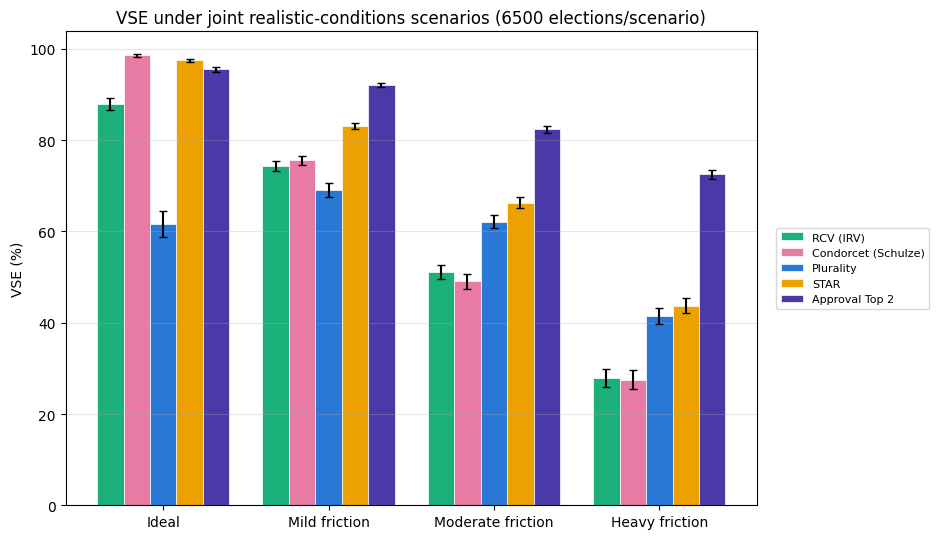

#### RCV (IRV) vs Condorcet (Schulze): paired VSE gap by joint-friction scenario

| Scenario | RCV VSE (%) | Schulze VSE (%) | Gap vs Schulze (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 87.9 | 98.6 | -10.7 | [-11.9, -9.5] | Yes (Schulze better) |
| Mild friction | 74.3 | 75.6 | -1.3 | [-1.9, -0.7] | Yes (Schulze better) |
| Moderate friction | 51.0 | 49.1 | +1.9 | [+1.3, +2.5] | Yes (RCV better) |
| Heavy friction | 27.9 | 27.5 | +0.4 | [-0.2, +1.0] | No (CI contains 0) |

In [170]:
replay("ranked-implosion")
replay("rcv-schulze-ci")

### Condorcet Efficiency

| Method | Raw CE (honest) | Relative to Schulze |
|---|---|---|
| Condorcet (Schulze) | 100.0% | 1.00x |
| Approval Top 2 | 82.1% | 0.82x |
| STAR | 79.3% | 0.79x |
| Score5 | 70.9% | 0.71x |
| Plurality Top 2 | 66.2% | 0.66x |
| RCV (IRV) | 64.0% | 0.64x |
| Approval | 57.8% | 0.58x |
| Plurality | 44.4% | 0.44x |

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 44.4% (0.44x Schulze) | 44.8% (1.06x Schulze) | 33.6% (1.21x Schulze) | 23.4% (1.13x Schulze) |
| Plurality Top 2 | 66.2% (0.66x Schulze) | 60.7% (1.44x Schulze) | 48.2% (1.74x Schulze) | 38.0% (1.84x Schulze) |
| Plurality Top 2 (Clear-Eyed) | 66.2% (0.66x Schulze) | 68.4% (1.62x Schulze) | 55.3% (1.99x Schulze) | 43.8% (2.12x Schulze) |
| RCV (IRV) | 64.0% (0.64x Schulze) | 41.9% (0.99x Schulze) | 28.3% (1.02x Schulze) | 20.7% (1.00x Schulze) |
| Approval | 57.8% (0.58x Schulze) | 45.2% (1.07x Schulze) | 33.3% (1.20x Schulze) | 23.6% (1.14x Schulze) |
| Approval Top 2 (Coma) | 82.1% (0.82x Schulze) | 44.3% (1.05x Schulze) | 28.9% (1.04x Schulze) | 20.5% (0.99x Schulze) |
| Approval Top 2 | 82.1% (0.82x Schulze) | 61.8% (1.47x Schulze) | 47.8% (1.72x Schulze) | 37.7% (1.82x Schulze) |
| Approval Top 2 (Clear-Eyed) | 82.1% (0.82x Schulze) | 71.4% (1.69x Schulze) | 55.1% (1.98x Schulze) | 43.8% (2.12x Schulze) |
| STAR | 79.3% (0.79x Schulze) | 46.6% (1.10x Schulze) | 33.6% (1.21x Schulze) | 23.5% (1.14x Schulze) |
| Score5 | 70.9% (0.71x Schulze) | 44.4% (1.05x Schulze) | 33.0% (1.19x Schulze) | 23.4% (1.13x Schulze) |
| Score Top 2 (Clear-Eyed) | 91.4% (0.91x Schulze) | 70.4% (1.67x Schulze) | 54.9% (1.98x Schulze) | 43.7% (2.11x Schulze) |
| Condorcet (Schulze) | 100.0% (1.00x Schulze) | 42.2% (1.00x Schulze) | 27.8% (1.00x Schulze) | 20.7% (1.00x Schulze) |

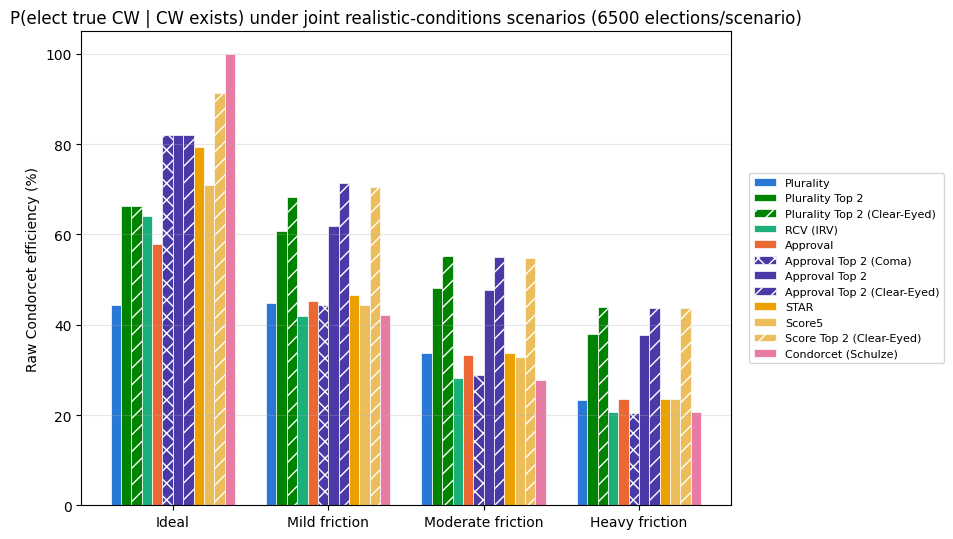

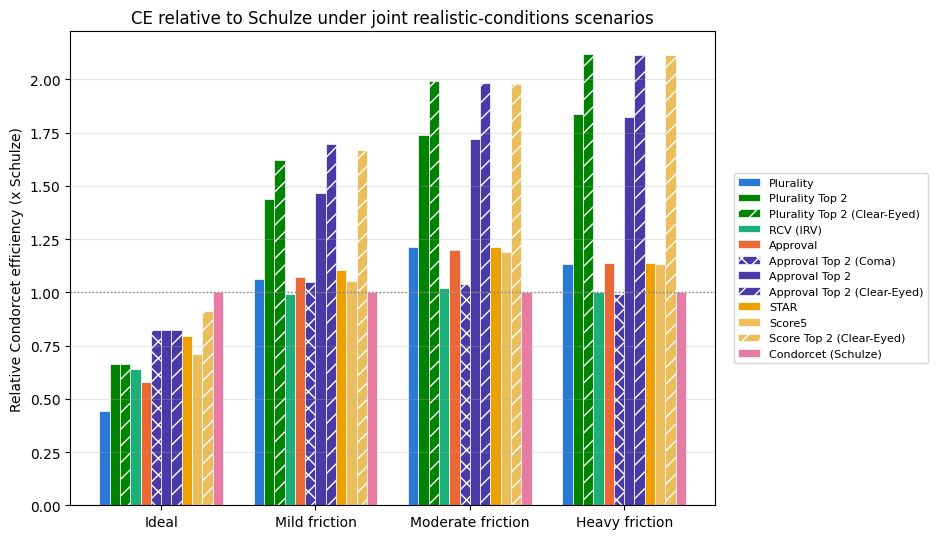

#### Ideal: paired Condorcet-efficiency gap vs Schulze (pp)

| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |
|---|---|---|---|
| Approval Top 2 | -17.9% | [-19.6%, -16.2%] | Yes (Schulze better) |
| STAR | -20.7% | [-22.4%, -18.9%] | Yes (Schulze better) |
| Score5 | -29.1% | [-31.1%, -27.1%] | Yes (Schulze better) |
| Plurality Top 2 | -33.8% | [-35.9%, -31.7%] | Yes (Schulze better) |
| RCV (IRV) | -36.0% | [-38.1%, -33.9%] | Yes (Schulze better) |
| Approval | -42.2% | [-44.4%, -40.0%] | Yes (Schulze better) |
| Plurality | -55.6% | [-57.8%, -53.5%] | Yes (Schulze better) |

#### Mild friction: paired Condorcet-efficiency gap vs Schulze (pp)

| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |
|---|---|---|---|
| Approval Top 2 (Clear-Eyed) | +29.3% | [+28.1%, +30.4%] | Yes (Approval Top 2 (Clear-Eyed) better) |
| Score Top 2 (Clear-Eyed) | +28.3% | [+27.2%, +29.4%] | Yes (Score Top 2 (Clear-Eyed) better) |
| Plurality Top 2 (Clear-Eyed) | +26.2% | [+25.0%, +27.4%] | Yes (Plurality Top 2 (Clear-Eyed) better) |
| Approval Top 2 | +19.7% | [+18.4%, +20.9%] | Yes (Approval Top 2 better) |
| Plurality Top 2 | +18.6% | [+17.3%, +19.8%] | Yes (Plurality Top 2 better) |
| STAR | +4.4% | [+3.7%, +5.1%] | Yes (STAR better) |
| Approval | +3.0% | [+2.3%, +3.8%] | Yes (Approval better) |
| Plurality | +2.6% | [+1.6%, +3.6%] | Yes (Plurality better) |
| Score5 | +2.2% | [+1.5%, +2.9%] | Yes (Score5 better) |
| Approval Top 2 (Coma) | +2.1% | [+1.4%, +2.8%] | Yes (Approval Top 2 (Coma) better) |
| RCV (IRV) | -0.3% | [-0.7%, +0.2%] | No (CI contains 0) |

#### Moderate friction: paired Condorcet-efficiency gap vs Schulze (pp)

| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |
|---|---|---|---|
| Plurality Top 2 (Clear-Eyed) | +27.5% | [+26.4%, +28.6%] | Yes (Plurality Top 2 (Clear-Eyed) better) |
| Approval Top 2 (Clear-Eyed) | +27.3% | [+26.2%, +28.4%] | Yes (Approval Top 2 (Clear-Eyed) better) |
| Score Top 2 (Clear-Eyed) | +27.1% | [+26.0%, +28.2%] | Yes (Score Top 2 (Clear-Eyed) better) |
| Plurality Top 2 | +20.5% | [+19.3%, +21.6%] | Yes (Plurality Top 2 better) |
| Approval Top 2 | +20.0% | [+18.8%, +21.2%] | Yes (Approval Top 2 better) |
| Plurality | +5.9% | [+5.2%, +6.5%] | Yes (Plurality better) |
| STAR | +5.9% | [+5.3%, +6.5%] | Yes (STAR better) |
| Approval | +5.6% | [+4.9%, +6.2%] | Yes (Approval better) |
| Score5 | +5.2% | [+4.6%, +5.8%] | Yes (Score5 better) |
| Approval Top 2 (Coma) | +1.1% | [+0.6%, +1.6%] | Yes (Approval Top 2 (Coma) better) |
| RCV (IRV) | +0.5% | [+0.2%, +0.8%] | Yes (RCV (IRV) better) |

#### Heavy friction: paired Condorcet-efficiency gap vs Schulze (pp)

| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |
|---|---|---|---|
| Plurality Top 2 (Clear-Eyed) | +23.2% | [+22.1%, +24.2%] | Yes (Plurality Top 2 (Clear-Eyed) better) |
| Approval Top 2 (Clear-Eyed) | +23.1% | [+22.1%, +24.1%] | Yes (Approval Top 2 (Clear-Eyed) better) |
| Score Top 2 (Clear-Eyed) | +23.0% | [+22.0%, +24.1%] | Yes (Score Top 2 (Clear-Eyed) better) |
| Plurality Top 2 | +17.3% | [+16.2%, +18.4%] | Yes (Plurality Top 2 better) |
| Approval Top 2 | +17.0% | [+15.9%, +18.1%] | Yes (Approval Top 2 better) |
| Approval | +2.9% | [+2.5%, +3.3%] | Yes (Approval better) |
| STAR | +2.8% | [+2.4%, +3.3%] | Yes (STAR better) |
| Score5 | +2.8% | [+2.3%, +3.2%] | Yes (Score5 better) |
| Plurality | +2.7% | [+2.3%, +3.2%] | Yes (Plurality better) |
| RCV (IRV) | +0.0% | [-0.1%, +0.2%] | No (CI contains 0) |
| Approval Top 2 (Coma) | -0.2% | [-0.5%, +0.1%] | No (CI contains 0) |


In [171]:
replay("ideal-honest-ce-table")
replay("condorcet-joint")
replay("ce-ci-table")

### Robustness Rankings

In [172]:
replay("robustness-rankings")

### Ideal: robustness across strategy levels

**1. Mean VSE across axis (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 | 95.9% |
| 2 | STAR | 95.0% |
| 3 | Score5 | 93.4% |
| 4 | Condorcet (Schulze) | 92.3% |
| 5 | Approval | 91.0% |
| 6 | Plurality Top 2 | 85.3% |
| 7 | RCV (IRV) | 83.1% |
| 8 | Plurality | 70.3% |

**2. Worst-case VSE, CI lower bound (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 | 91.6% |
| 2 | STAR | 88.3% |
| 3 | Condorcet (Schulze) | 82.9% |
| 4 | Approval | 82.9% |
| 5 | Score5 | 81.8% |
| 6 | Plurality Top 2 | 81.3% |
| 7 | RCV (IRV) | 74.7% |
| 8 | Plurality | 56.6% |

**3. Avg. regret vs. best-at-that-point (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 | 0.6% |
| 2 | STAR | 1.5% |
| 3 | Score5 | 3.1% |
| 4 | Condorcet (Schulze) | 4.2% |
| 5 | Approval | 5.5% |
| 6 | Plurality Top 2 | 11.2% |
| 7 | RCV (IRV) | 13.4% |
| 8 | Plurality | 26.2% |

**4. Avg. rank across axis (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 | 1.88 |
| 2 | STAR | 2.12 |
| 3 | Score5 | 3.25 |
| 4 | Condorcet (Schulze) | 3.75 |
| 5 | Approval | 4.50 |
| 6 | Plurality Top 2 | 6.12 |
| 7 | RCV (IRV) | 6.62 |
| 8 | Plurality | 7.75 |


### Friction only (Mild/Moderate/Heavy)

**1. Mean VSE across axis (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 (Clear-Eyed) | 83.9% |
| 2 | Plurality Top 2 (Clear-Eyed) | 82.4% |
| 3 | Approval Top 2 | 82.3% |
| 4 | Plurality Top 2 | 80.9% |
| 5 | STAR | 64.4% |
| 6 | Approval | 64.0% |
| 7 | Score5 | 63.2% |
| 8 | Plurality | 57.6% |
| 9 | Approval Top 2 (Coma) | 56.8% |
| 10 | RCV (IRV) | 51.1% |
| 11 | Condorcet (Schulze) | 50.8% |

**2. Worst-case VSE, CI lower bound (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 (Clear-Eyed) | 74.1% |
| 2 | Plurality Top 2 (Clear-Eyed) | 74.0% |
| 3 | Approval Top 2 | 71.5% |
| 4 | Plurality Top 2 | 71.3% |
| 5 | STAR | 42.0% |
| 6 | Approval | 41.2% |
| 7 | Score5 | 40.8% |
| 8 | Plurality | 39.7% |
| 9 | Approval Top 2 (Coma) | 29.4% |
| 10 | RCV (IRV) | 25.9% |
| 11 | Condorcet (Schulze) | 25.5% |

**3. Avg. regret vs. best-at-that-point (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 (Clear-Eyed) | 0.0% |
| 2 | Plurality Top 2 (Clear-Eyed) | 1.4% |
| 3 | Approval Top 2 | 1.5% |
| 4 | Plurality Top 2 | 2.9% |
| 5 | STAR | 19.5% |
| 6 | Approval | 19.8% |
| 7 | Score5 | 20.7% |
| 8 | Plurality | 26.3% |
| 9 | Approval Top 2 (Coma) | 27.1% |
| 10 | RCV (IRV) | 32.8% |
| 11 | Condorcet (Schulze) | 33.1% |

**4. Avg. rank across axis (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 (Clear-Eyed) | 1.00 |
| 2 | Plurality Top 2 (Clear-Eyed) | 2.33 |
| 3 | Approval Top 2 | 2.67 |
| 4 | Plurality Top 2 | 4.00 |
| 5 | STAR | 5.33 |
| 6 | Approval | 5.67 |
| 7 | Score5 | 7.00 |
| 8 | Approval Top 2 (Coma) | 8.67 |
| 9 | Plurality | 9.00 |
| 10 | RCV (IRV) | 10.00 |
| 11 | Condorcet (Schulze) | 10.33 |


### Holistic (Ideal + all friction scenarios)

**1. Mean VSE across axis (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 (Clear-Eyed) | 86.8% |
| 2 | Approval Top 2 | 85.6% |
| 3 | Plurality Top 2 (Clear-Eyed) | 82.7% |
| 4 | Plurality Top 2 | 81.6% |
| 5 | STAR | 72.6% |
| 6 | Score5 | 71.4% |
| 7 | Approval | 70.3% |
| 8 | Approval Top 2 (Coma) | 66.5% |
| 9 | Condorcet (Schulze) | 62.7% |
| 10 | RCV (IRV) | 60.3% |
| 11 | Plurality | 58.6% |

**2. Worst-case VSE, CI lower bound (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 (Clear-Eyed) | 74.1% |
| 2 | Plurality Top 2 (Clear-Eyed) | 74.0% |
| 3 | Approval Top 2 | 71.5% |
| 4 | Plurality Top 2 | 71.3% |
| 5 | STAR | 42.0% |
| 6 | Approval | 41.2% |
| 7 | Score5 | 40.8% |
| 8 | Plurality | 39.7% |
| 9 | Approval Top 2 (Coma) | 29.4% |
| 10 | RCV (IRV) | 25.9% |
| 11 | Condorcet (Schulze) | 25.5% |

**3. Avg. regret vs. best-at-that-point (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 (Clear-Eyed) | 0.8% |
| 2 | Approval Top 2 | 1.9% |
| 3 | Plurality Top 2 (Clear-Eyed) | 4.8% |
| 4 | Plurality Top 2 | 6.0% |
| 5 | STAR | 14.9% |
| 6 | Score5 | 16.2% |
| 7 | Approval | 17.2% |
| 8 | Approval Top 2 (Coma) | 21.1% |
| 9 | Condorcet (Schulze) | 24.8% |
| 10 | RCV (IRV) | 27.2% |
| 11 | Plurality | 29.0% |

**4. Avg. rank across axis (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top 2 (Clear-Eyed) | 2.25 |
| 2 | Approval Top 2 | 3.25 |
| 3 | Plurality Top 2 (Clear-Eyed) | 4.25 |
| 4 | STAR | 4.50 |
| 5 | Plurality Top 2 | 5.25 |
| 6 | Approval | 6.00 |
| 7 | Score5 | 6.00 |
| 8 | Approval Top 2 (Coma) | 7.50 |
| 9 | Condorcet (Schulze) | 8.00 |
| 10 | Plurality | 9.50 |
| 11 | RCV (IRV) | 9.50 |


### The Shape of the Data

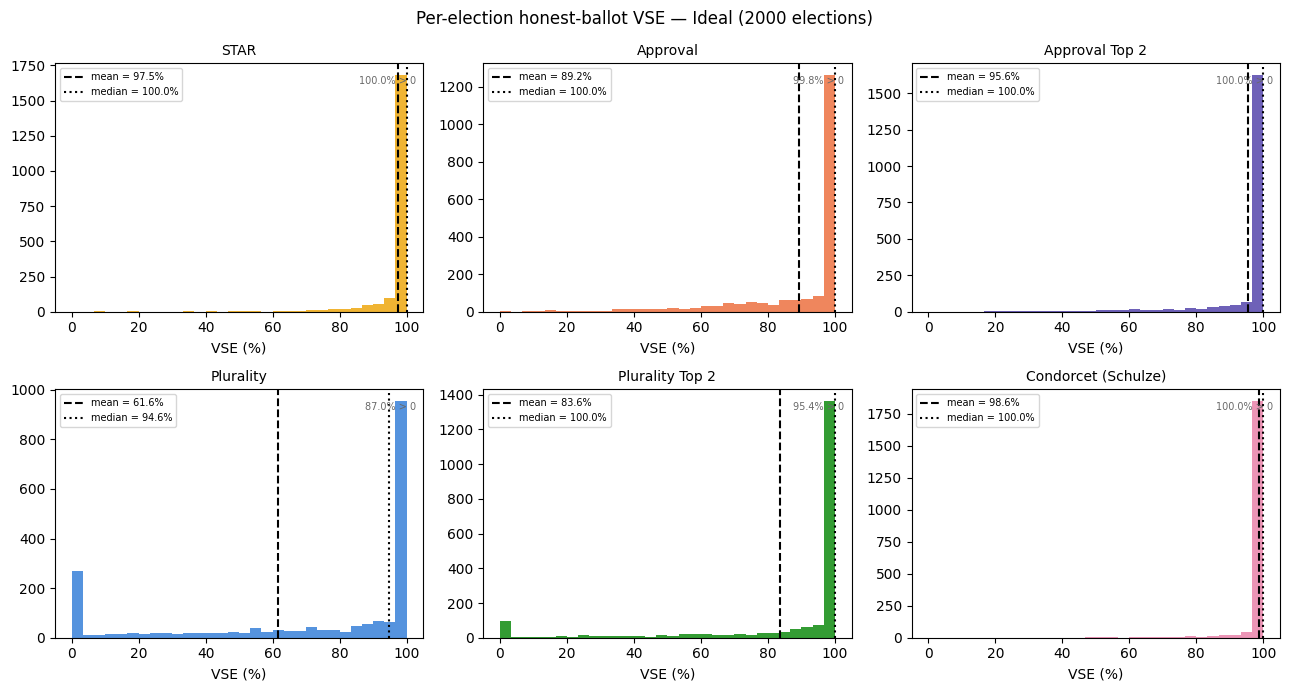

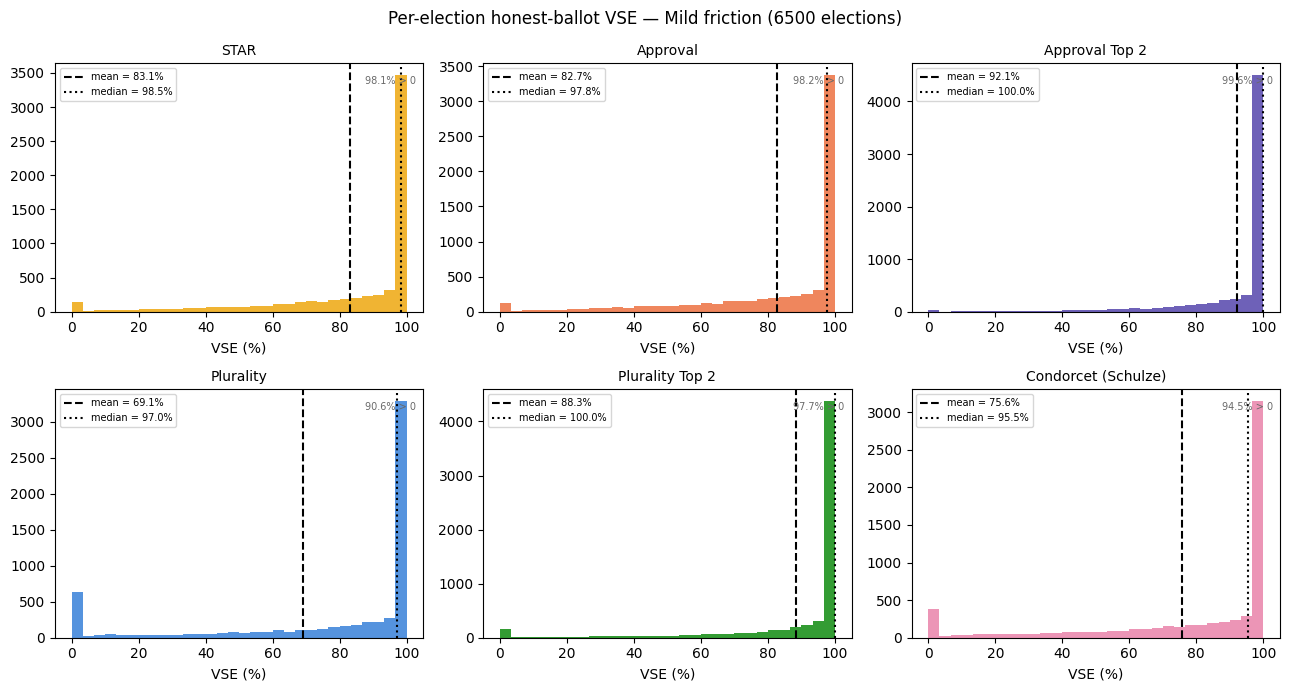

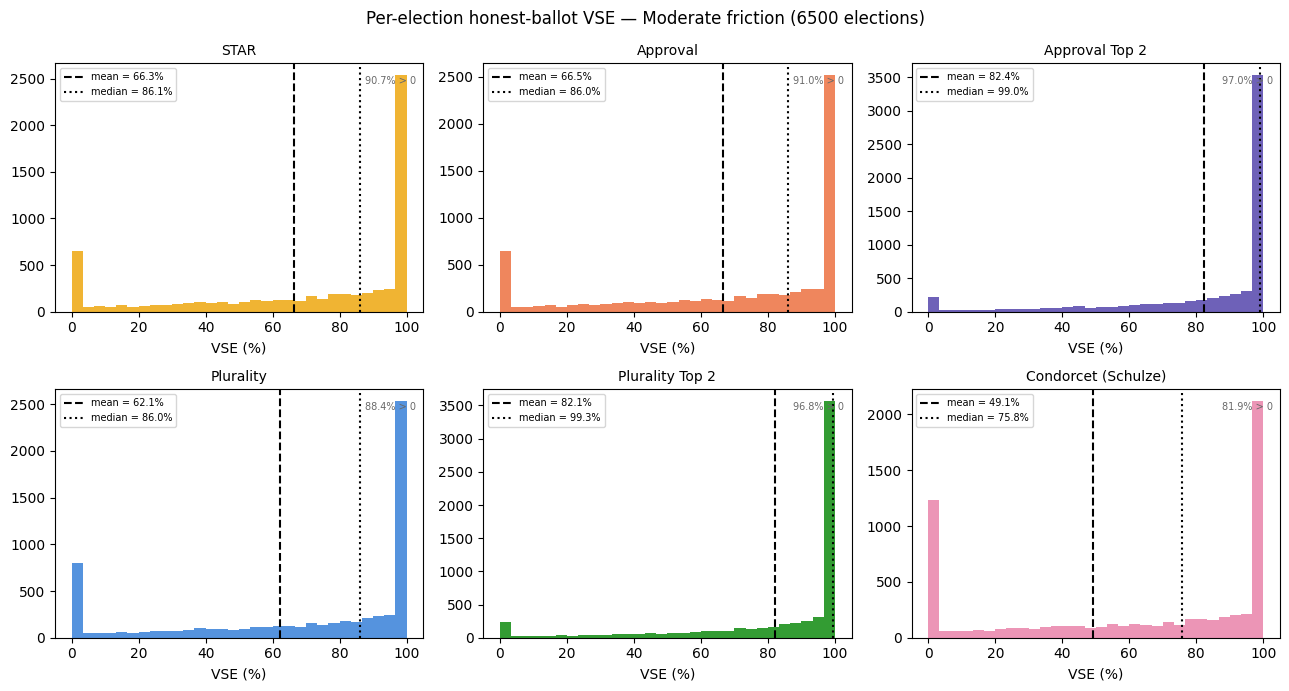

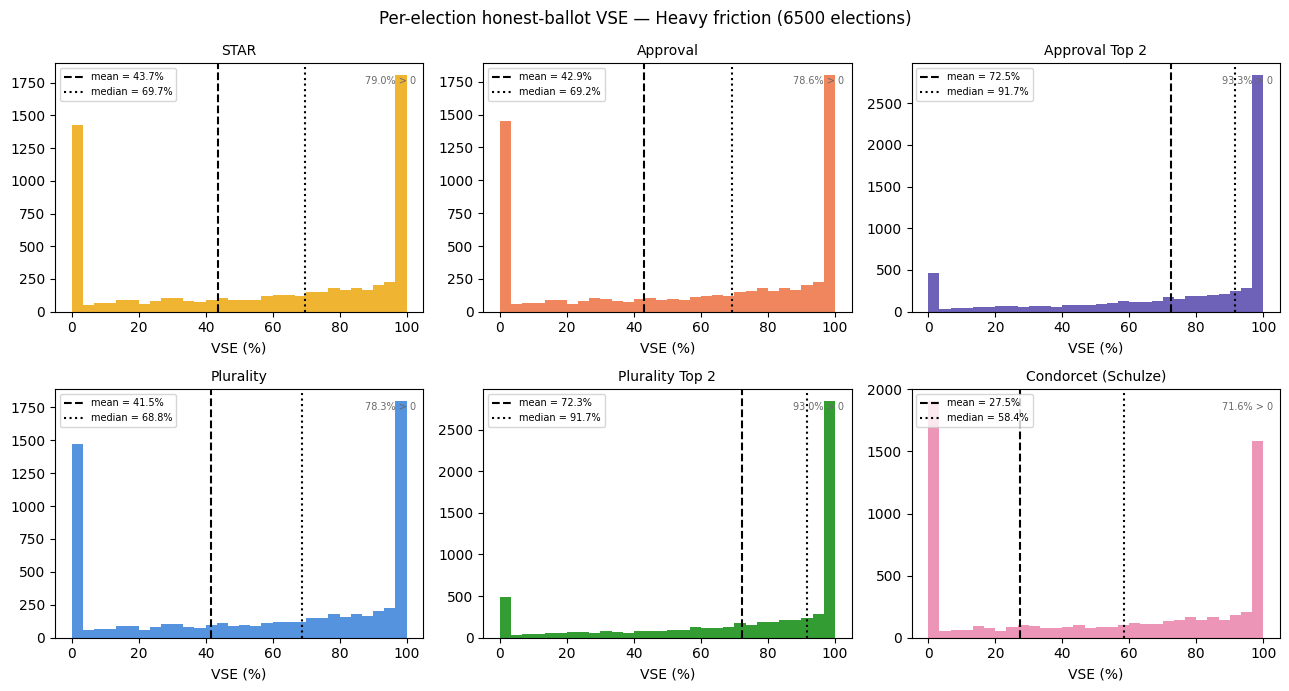

In [173]:
replay("histogram-data")

### 99% Confidence Check Part 2

In [174]:
replay("not-sig-at-99-part2")
replay("still-sig-at-99-part2")

### 0 result(s) lose significance at 99% confidence


None -- every 95%-significant result in this post's scope also holds at 99%.

### Spotlight: does each headline claim hold up at 99% confidence?


#### CE gap vs Schulze: Ideal

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top 2 | -17.9 | Condorcet (Schulze) better | Condorcet (Schulze) better |
| STAR | -20.7 | Condorcet (Schulze) better | Condorcet (Schulze) better |
| Score5 | -29.1 | Condorcet (Schulze) better | Condorcet (Schulze) better |
| Plurality Top 2 | -33.8 | Condorcet (Schulze) better | Condorcet (Schulze) better |
| RCV (IRV) | -36.0 | Condorcet (Schulze) better | Condorcet (Schulze) better |
| Approval | -42.2 | Condorcet (Schulze) better | Condorcet (Schulze) better |
| Plurality | -55.6 | Condorcet (Schulze) better | Condorcet (Schulze) better |

#### CE gap vs Schulze: Mild friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top 2 (Clear-Eyed) | +29.3 | Approval Top 2 (Clear-Eyed) better | Approval Top 2 (Clear-Eyed) better |
| Score Top 2 (Clear-Eyed) | +28.3 | Score Top 2 (Clear-Eyed) better | Score Top 2 (Clear-Eyed) better |
| Plurality Top 2 (Clear-Eyed) | +26.2 | Plurality Top 2 (Clear-Eyed) better | Plurality Top 2 (Clear-Eyed) better |
| Approval Top 2 | +19.7 | Approval Top 2 better | Approval Top 2 better |
| Plurality Top 2 | +18.6 | Plurality Top 2 better | Plurality Top 2 better |
| STAR | +4.4 | STAR better | STAR better |
| Approval | +3.0 | Approval better | Approval better |
| Plurality | +2.6 | Plurality better | Plurality better |
| Score5 | +2.2 | Score5 better | Score5 better |
| Approval Top 2 (Coma) | +2.1 | Approval Top 2 (Coma) better | Approval Top 2 (Coma) better |
| RCV (IRV) | -0.3 | No sig. difference | No sig. difference |

#### CE gap vs Schulze: Moderate friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Plurality Top 2 (Clear-Eyed) | +27.5 | Plurality Top 2 (Clear-Eyed) better | Plurality Top 2 (Clear-Eyed) better |
| Approval Top 2 (Clear-Eyed) | +27.3 | Approval Top 2 (Clear-Eyed) better | Approval Top 2 (Clear-Eyed) better |
| Score Top 2 (Clear-Eyed) | +27.1 | Score Top 2 (Clear-Eyed) better | Score Top 2 (Clear-Eyed) better |
| Plurality Top 2 | +20.5 | Plurality Top 2 better | Plurality Top 2 better |
| Approval Top 2 | +20.0 | Approval Top 2 better | Approval Top 2 better |
| Plurality | +5.9 | Plurality better | Plurality better |
| STAR | +5.9 | STAR better | STAR better |
| Approval | +5.6 | Approval better | Approval better |
| Score5 | +5.2 | Score5 better | Score5 better |
| Approval Top 2 (Coma) | +1.1 | Approval Top 2 (Coma) better | Approval Top 2 (Coma) better |
| RCV (IRV) | +0.5 | RCV (IRV) better | RCV (IRV) better |

#### CE gap vs Schulze: Heavy friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Plurality Top 2 (Clear-Eyed) | +23.2 | Plurality Top 2 (Clear-Eyed) better | Plurality Top 2 (Clear-Eyed) better |
| Approval Top 2 (Clear-Eyed) | +23.1 | Approval Top 2 (Clear-Eyed) better | Approval Top 2 (Clear-Eyed) better |
| Score Top 2 (Clear-Eyed) | +23.0 | Score Top 2 (Clear-Eyed) better | Score Top 2 (Clear-Eyed) better |
| Plurality Top 2 | +17.3 | Plurality Top 2 better | Plurality Top 2 better |
| Approval Top 2 | +17.0 | Approval Top 2 better | Approval Top 2 better |
| Approval | +2.9 | Approval better | Approval better |
| STAR | +2.8 | STAR better | STAR better |
| Score5 | +2.8 | Score5 better | Score5 better |
| Plurality | +2.7 | Plurality better | Plurality better |
| RCV (IRV) | +0.0 | No sig. difference | No sig. difference |
| Approval Top 2 (Coma) | -0.2 | No sig. difference | No sig. difference |

## Part 3

to be continued...

## Notebook End

In [175]:
total_notebook_time_end = time.time()

In [176]:
print(f"Total notebook execution time: {total_notebook_time_end - total_notebook_time_start:.1f} seconds\nIn minutes: {(total_notebook_time_end - total_notebook_time_start)/60:.1f} minutes")
print(f"Total elections run: {TOTAL_ELECTIONS_RUN}")

Total notebook execution time: 3285.3 seconds
In minutes: 54.8 minutes
Total elections run: 50000
